[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T01_B_cross_country_facts.ipynb)
> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.


In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Module 1 — National Accounts and Cross-Country Stylized Facts

**Supplementary course · puremacro**

### Learning Objectives
By the end of this lesson you will be able to:
1. **Build the expenditure accounts from scratch**, in ten steps, for every country the OECD publishes them for — discovering the country list with `qna_countries()` rather than hard-coding it, and ending with the **three products** of a national accounts build: nominal levels, implicit deflators and volume measures, tied together by $\text{nominal} = \text{real} \times \text{deflator}/100$.
- This can make the notebook slow to run, but it shows how the analysis can be done from a tablet.
2. **Know which product answers which question** — why the identity $Y = C + I + G + NX$ closes in current prices but not in chain-linked volumes, why each country's deflator sits at 100 in a different year, and why real growth is decomposed with previous-period weights rather than added up.
3. **Build the other two approaches to the same GDP** — output (value added by industry) and income (what GDP is paid out as) — score all three identities, and read the residuals: the memo columns that double-count if summed, the flows that disagree about GDP itself, and the **GDP–GDI statistical discrepancy** that runs to $\pm2\%$ in the United States.
4. **Understand the relative prices** ($P_{eq}/P_{C^{*}}$, $P_{cd}/P_{C^{*}}$, $P_X/P_M$) that only deflators deliver — splitting GFCF into **traded equipment** and **non-traded structures**, whose prices have moved in opposite directions for thirty years, and deflating both by consumption **net of durables**, because the price of a car does not belong in the denominator of the price of a machine.
5. Split household consumption by **durability** and ask whether durables belong in $C$ or in $I$ (Cooley & Prescott 1995; Gomme & Rupert 2007), testing and seasonally adjusting the series that need it.
6. Tell apart the statistics that are **immune to the exchange rate** (nominal shares in local currency) from those it **contaminates**, using equipment vs. structures as a within-country placebo.
7. Analyze the **capital-output ratio ($K/Y$)** and the **labor share** — and see why the obvious formula, compensation of employees over value added, does not measure the production-function parameter: correct it for **self-employment** (Gollin 2002) and, where ILOSTAT publishes the **quarterly** rate, for the margin of **informal employees** too, which is the only correction that can change a trend because it is the only one that moves.
8. Perform the **Mankiw–Shapiro (1986) news vs. noise test** — both of its regressions, not just the famous one — on real-time GDP vintages for **every one of the 42 reference areas** the OECD's revisions archive covers — detecting first the editions in which it silently changes what it is measuring, and seasonally adjusting them **all** with one filter rather than dropping the guilty ones, because dropping them promotes estimates published years later to the rank of "preliminary datum". Then run the same test on **all nine measures the archive carries** — the two faces of GDP, the deflator, five expenditure components and employment — and find that GDP is the *quietest* of the things it is made of, because it is an average of errors that barely move together.
9. Explore how far stylized facts move with the methodology of the national accounts themselves — **data vintages and SNA revisions** — and test the structural determinants of $\sigma(c)/\sigma(y)$ — openness, financial depth (World Bank) and the **unprotected labour margin**, joining informality (ILOSTAT) and self-employment into the union they overlap in rather than adding them — with data from four databases and not one number typed by hand.
10. Document stylized facts about the **labor market**, which growth courses rarely cover: the two margins of labour input — heads and hours — that the accounts themselves measure, and the **Beveridge curve**, with the matching-function $\alpha$ its slope identifies and the outward shift the pandemic left behind.
11. **Leave the data ready for what comes next**: four files — expenditure with its deflators, income, output and labor market — all quarterly and seasonally adjusted, which are the input to the notebooks that follow.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from puremacro.data import hp_filter

_cwd = __import__("pathlib").Path.cwd()


def _here(p):
    # A sandboxed filesystem (iOS) raises PermissionError from .exists()
    # instead of returning False; treat unreadable as absent.
    try:
        return p.exists()
    except OSError:
        return False


_nb = _cwd if _here(_cwd / "_nbstyle.py") else _cwd / "notebooks"
sys.path.insert(0, str(_nb))
import _nbstyle; _nbstyle.apply_style()
from _tutor import tutor

## 1. Building the accounts from scratch

This lesson stands on one object, so we build it first — and we build it slowly, because almost every mistake made with national accounts is made in this step and never noticed afterwards.

The expenditure decomposition of GDP is
$$ Y = C + I + G + NX, \qquad NX = X - M, $$
and a statistical office publishes every one of those aggregates in **three products** that must never be confused:

| | what it is | in the panel |
|---|---|---|
| **Nominal** | the value actually transacted, in national currency at current prices | `gdp`, `cons_hh`, `inv`, … |
| **Deflator** | the implicit price index of that same aggregate | `gdp_defl`, `cons_hh_defl`, … |
| **Real (volume)** | the same aggregate with the price movement taken out | `gdp_real`, `cons_hh_real`, … |

They are not three independent datasets. Component by component,
$$ \text{nominal} \;=\; \text{real} \times \frac{\text{deflator}}{100}, $$
so **any two of the three determine the third** — a fact we will check to machine precision rather than assert, and one worth holding on to: a frozen file that carries only two of them has lost nothing.

Which two the source treats as primary matters, though. The office measures **nominal** (it is what the tax returns and surveys report) and **volume** (it deflates each elementary series by its own price index), and the deflator falls out as the ratio. We keep the same order of primacy for a reason developed in §1.6: the identity above closes *exactly* in current prices and *does not* close in chain-linked volumes.

We will break our first bulk query of the national accounts into ten steps:

### 1.1 Step 1 — Who publishes what?

The first question is not "which countries do I want" but "which countries are there". Hard-coding a list is how a panel silently goes stale: the OECD onboards a reference area, your list does not, and nothing complains.

`qna_countries()` asks the SDMX **availability** endpoint which values of `REF_AREA` actually carry data in the dataflow, so the panel covers the largest set the source supports. It drops the country *groupings* — `OECD`, `EA20`, `G7`, `NAFTA` — by default, because a panel that mixes `OECD` in with `USA` double-counts every aggregate it touches; pass `include_aggregates=True` if you want them.

In [3]:
from pathlib import Path

# So it is clear what happened if this does not run on a tablet under Jupyter
try:
    from puremacro.fetch import (qna_panel, qna_meta, qna_countries,
                                 qna_rebase, qna_identity, qna_contributions,
                                 QNA_COMPONENTS, QNA_AGGREGATES, QNA_ASSETS,
                                 QNA_DURABILITY, QNA_ACTIVITIES, QNA_INCOME,
                                 QNA_LABOR, QNA_LABOR_UNITS)
except ImportError as exc:
    import puremacro
    raise ImportError(
        f"This notebook needs puremacro >= 1.8.0 for the quarterly national "
        f"accounts API; the installed version is {puremacro.__version__}, from "
        f"{Path(puremacro.__file__).parent}. It reports: {getattr(exc, 'msg', None) or exc}. "
        f"Run `pip install -U puremacro` (on an iPad, from Juno's console), then "
        f"restart the kernel."
    ) from exc

# Live query vs. frozen course snapshot (offline by default)
VIVO = os.environ.get("MAV_QNA_VIVO", "").strip().lower() not in ("", "0", "false", "no")

if VIVO:
    try:
        COUNTRIES = qna_countries()
        ALL_AREAS = qna_countries(include_aggregates=True)
    except Exception as exc:
        print(f"Notice: live SDMX query failed ({exc}); falling back to cached country list.")
        VIVO = False

if not VIVO:
    # Offline resolution from local frozen bundle metadata
    try:
        import _datos
        _meta_p = _datos.ruta_dato("oecd_qna_panel_meta.csv")
    except Exception:
        _meta_p = Path("data_curso") / "bundle_2026A" / "oecd_qna_panel_meta.csv"
        if not _meta_p.is_file():
            _meta_p = Path("data_curso") / "oecd_qna_panel_meta.csv"

    if _meta_p.is_file():
        COUNTRIES = sorted(pd.read_csv(_meta_p)["code"].dropna().unique().tolist())
    else:
        from puremacro.fetch.oecd_qna_panel import _QNA_COUNTRIES_FALLBACK
        COUNTRIES = sorted(_QNA_COUNTRIES_FALLBACK)

    ALL_AREAS = sorted(set(COUNTRIES) | set(QNA_AGGREGATES))

print(f"Reference areas the OECD publishes quarterly expenditure accounts for: "
      f"{len(ALL_AREAS)}")
print(f"  of which country groupings ({len(ALL_AREAS) - len(COUNTRIES)}): "
      f"{', '.join(sorted(set(ALL_AREAS) - set(COUNTRIES)))}")
print(f"  individual countries ({len(COUNTRIES)}):\n  {', '.join(COUNTRIES)}\n")

print("The expenditure components the panel will carry, and their SDMX coordinates:")
for name, (txn, sector, desc) in QNA_COMPONENTS.items():
    print(f"  {name:9s} {txn:5s} / {sector:4s}  {desc}")

# The groupings are excluded by construction, not by luck.
assert not (set(COUNTRIES) & QNA_AGGREGATES)
assert len(COUNTRIES) >= 45
assert {"USA", "MEX", "DEU", "CHN", "IND"}.issubset(COUNTRIES)

Reference areas the OECD publishes quarterly expenditure accounts for: 61
  of which country groupings (12): EA19, EA20, EU15, EU27_2020, EU28, G20, G7, NAFTA, OECD, OECD26, OECDE, W
  individual countries (49):
  ARG, AUS, AUT, BEL, BGR, BRA, CAN, CHE, CHL, CHN, COL, CRI, CZE, DEU, DNK, ESP, EST, FIN, FRA, GBR, GRC, HRV, HUN, IDN, IND, IRL, ISL, ISR, ITA, JPN, KOR, LTU, LUX, LVA, MEX, NLD, NOR, NZL, POL, PRT, ROU, RUS, SAU, SVK, SVN, SWE, TUR, USA, ZAF

The expenditure components the panel will carry, and their SDMX coordinates:
  gdp       B1GQ  / S1    Gross domestic product (expenditure approach)
  cons_hh   P3    / S1M   Household final consumption (households + NPISH)
  cons_gov  P3    / S13   General government final consumption
  inv       P51G  / S1    Gross fixed capital formation
  capform   P5    / S1    Gross capital formation (GFCF + inventories)
  exports   P6    / S1    Exports of goods and services
  imports   P7    / S1    Imports of goods and services


### 1.2 Step 2 — One call, three products

`qna_panel` downloads all the quarterly national accounts. You hand it the codes and it turns them into a `(code, date)`-indexed panel with the three product families side by side.

Three arguments matter:
- `real=True` also returns the **volume** measures. Without it you get nominal and deflators only — which, by the identity above, is not actually less information, but it does mean writing the division yourself.
- `assets=True` splits gross fixed capital formation by asset, and `durability=True` splits household consumption by durability. Both are used from §2.2 on.
- `sa="x13"` handles seasonal adjustment; that is Step 4.
- `output=True` and `income=True` bring in the **other two approaches to the same GDP** — value added by industry, and the income it is paid out as. That is Step 8, and until then everything is the expenditure side.
- `labor=True` brings in the **labour input** these same accounts measure: heads and hours, split into employees and the self-employed. They are neither the price nor the quantity of a good, so they carry no deflator and no volume — they are counted in thousands of persons and millions of hours. That is §5's block.

**On run times.** A live run is ~25 SDMX requests and the OECD endpoint rate-limits at roughly 20 an hour, so **by default the notebook reads the frozen snapshot in `data_curso/`** and downloads nothing: the same numbers, and iterating on the notebook costs no quota. To refresh the vintage — the one reason to download — set `MAV_QNA_VIVO=1` in the environment before starting the kernel, or flip `VIVO = True` in the cell below. By default (with VIVO off), Step 1 reads the country list and metadata from the frozen snapshot in `data_curso/` (bundle_2026A) instead of querying the SDMX endpoint, guaranteeing immediate, 100% offline execution.

In [4]:
def readable(p, kind="dir"):
    """`p.is_dir()` / `p.is_file()`, but False instead of an exception.

    pathlib only swallows ENOENT / ENOTDIR / EBADF / ELOOP, so on a sandboxed
    filesystem — iOS, where anything above the notebook's own folder is off
    limits — probing a candidate path raises PermissionError instead of
    answering False. Every filesystem probe in this notebook goes through here.
    """
    try:
        return p.is_dir() if kind == "dir" else p.is_file()
    except OSError:
        return False


from _datos import DATOS

# In-sandbox candidates first, so an iPad never has to reach for "..".
DATA = DATOS

# Download, or read from disk? A live run is ~25 SDMX requests and the OECD
# endpoint rate-limits at roughly 20 an hour, so iterating on the notebook while
# downloading is how you run out of quota halfway through a class. The default
# reads the frozen snapshot, which is the same numbers; set MAV_QNA_VIVO=1 in
# the environment — or VIVO = True right here — to rebuild the panel from the
# source, which is what refreshing the vintage takes.
VIVO = os.environ.get("MAV_QNA_VIVO", "").strip().lower() not in ("", "0", "false", "no")

panel = (qna_panel(COUNTRIES, start="1995", real=True,
                   assets=True, durability=True,
                   output=True, income=True, labor=True, sa="x13")
         if VIVO else pd.DataFrame())
meta = qna_meta(panel) if VIVO else pd.DataFrame()

n_live = panel.index.get_level_values("code").nunique() if not panel.empty else 0
if n_live < len(COUNTRIES) and readable(DATA / "oecd_qna_panel_nominal.csv", "file"):
    print("Frozen course snapshot (MAV_QNA_VIVO=1 to download)."
          if not VIVO else
          f"OECD returned {n_live}/{len(COUNTRIES)} countries — "
          f"using the frozen course snapshot.")
    panel = (pd.read_csv(DATA / "oecd_qna_panel_nominal.csv", parse_dates=["date"])
               .set_index(["code", "date"]).sort_index())
    meta = pd.read_csv(DATA / "oecd_qna_panel_meta.csv")
    # The snapshot ships two of the three products. That is not a gap: the
    # third is recoverable exactly, and reconstructing it here is the identity
    # of §1 being used rather than described. The ~30 columns are attached in
    # one pd.concat: inserting them one by one fragments the frame.
    recoverable = [c for c in panel.columns if f"{c}_defl" in panel.columns]
    panel = pd.concat(
        [panel, pd.DataFrame({f"{c}_real": 100.0 * panel[c] / panel[f"{c}_defl"]
                              for c in recoverable},
                             index=panel.index)],
        axis=1)

if panel.empty:
    raise RuntimeError(
        "No panel: the OECD fetch returned nothing and no frozen snapshot was "
        f"found. Looked for data_curso/oecd_qna_panel_nominal.csv near {DATA}. "
        "Copy the course's data_curso/ folder next to this notebook (on an iPad "
        "it must sit inside the notebook's own folder — anything above it is "
        "outside the app sandbox) or re-run with a working connection.")

LABOR_COLS = [c for c in QNA_LABOR if c in panel.columns]
NOMINAL = [c for c in panel.columns
           if not c.endswith(("_defl", "_real")) and c not in LABOR_COLS]
DEFL = [f"{c}_defl" for c in NOMINAL if f"{c}_defl" in panel.columns]
REAL = [f"{c}_real" for c in NOMINAL if f"{c}_real" in panel.columns]
# The series that carry all three products. Not every series does: compensation
# of employees has no volume measure — there is no such thing as "wages at
# constant prices" in the accounts — so the income block of Step 8 is
# current-price only, and the three lists below are deliberately not the same
# length.
TRIPLE = [c for c in NOMINAL
          if f"{c}_defl" in panel.columns and f"{c}_real" in panel.columns]

dates = panel.index.get_level_values("date")
print(f"\nPanel: {panel.index.get_level_values('code').nunique()} countries x "
      f"{dates.nunique()} quarters "
      f"({dates.min().to_period('Q')}-{dates.max().to_period('Q')}), "
      f"{panel.shape[1]} columns = {len(NOMINAL)} nominal + {len(DEFL)} deflators "
      f"+ {len(REAL)} volumes + {len(LABOR_COLS)} labour")
print(f"The {len(LABOR_COLS)} labour columns ({', '.join(LABOR_COLS)}) are persons "
      f"and hours: they have no price, so they have no deflator and no volume.")
print(f"{len(TRIPLE)} series carry all three products; the other "
      f"{len(NOMINAL) - len(TRIPLE)} exist in current prices only "
      f"({', '.join(c for c in NOMINAL if c not in TRIPLE)}).\n")
print("The three products for one country, most recent quarter (Spain, EUR mn):")
print(pd.DataFrame({
    "nominal":  panel.loc["ESP", TRIPLE].iloc[-1],
    "deflator": panel.loc["ESP", [f"{c}_defl" for c in TRIPLE]].iloc[-1].set_axis(TRIPLE),
    "real":     panel.loc["ESP", [f"{c}_real" for c in TRIPLE]].iloc[-1].set_axis(TRIPLE),
}).head(7).round(1).to_string())

# nominal = real x deflator / 100, to machine precision, everywhere.
rel_err = max(
    float(((panel[n] - panel[f"{n}_real"] * panel[f"{n}_defl"] / 100).abs()
           / panel[n].abs()).max())
    for n in TRIPLE)
print(f"\nWorst relative error in  nominal = real x deflator/100  across the whole "
      f"panel: {rel_err:.1e}")
assert rel_err < 1e-9
assert panel.index.get_level_values("code").nunique() >= 45
assert {"gdp", "cons_hh", "cons_gov", "inv", "exports", "imports"}.issubset(panel.columns)
assert {"gdp_defl", "cons_hh_defl", "inv_defl"}.issubset(panel.columns)
assert {"inv_equip_defl", "inv_struct_defl", "cons_dur_defl"}.issubset(panel.columns)

Frozen course snapshot (MAV_QNA_VIVO=1 to download).

Panel: 49 countries x 126 quarters (1995Q1-2026Q2), 105 columns = 37 nominal + 31 deflators + 31 volumes + 6 labour
The 6 labour columns (emp, emp_employees, emp_selfemp, hours, hours_employees, hours_selfemp) are persons and hours: they have no price, so they have no deflator and no volume.
31 series carry all three products; the other 6 exist in current prices only (gdp_income, comp_emp, surplus_mixed, taxes_prod_imp_net, taxes_prod_imp, subsidies).

The three products for one country, most recent quarter (Spain, EUR mn):
           nominal  deflator      real
gdp       441437.0     123.5  357508.0
cons_hh   247775.0     125.0  198275.0
cons_gov   84379.0     117.2   71994.0
inv        91386.0     122.0   74889.0
capform    94780.0     123.8   76568.0
exports   159775.0     130.3  122601.0
imports   145272.0     129.1  112493.0

Worst relative error in  nominal = real x deflator/100  across the whole panel: 3.2e-16


### 1.3 Step 3 — Read the receipt before you use the data

`qna_meta` returns what the source actually sent, per country. Three of its columns decide whether a cross-country comparison means anything at all.

**`currency`.** Every level is in national currency. That is deliberate and it is the main reason to hold the panel this way: a *ratio* of two current-price aggregates in the same currency — $C/Y$, $I/Y$ — needs no conversion and is immune to the exchange rate (§2.3 measures what is not). Convert to a common currency and you import every country's bilateral rate into every series.

**`price_base`.** `L` is a **chain-linked** volume, `Q` a **fixed-base** one. The distinction is not cosmetic: chain-linked volumes are not additive, which is the whole of §1.6. Note which countries are `Q` — the volume-only fetchers that hard-filter `PRICE_BASE == "L"` return an empty frame for exactly these, and quietly.

**`price_ref_year`.** The year in which that country's deflators equal 100. It is *not* common across countries, and the spread is much wider than people expect. Until Step 5 fixes it, a chart of `inv_defl` levels across countries is a chart of several different conventions.

In [5]:
print(meta[["code", "currency", "price_base", "price_ref_year", "sa", "sa_detail",
            "sa_labor", "n_obs", "first", "last"]].head(8).to_string(index=False))

base = meta["price_base"].value_counts()
print(f"\nVolume measure: {base.get('L', 0)} countries chain-linked (L), "
      f"{base.get('Q', 0)} fixed-base (Q) — "
      f"{', '.join(sorted(meta.loc[meta['price_base'] == 'Q', 'code']))}.")
print("A fetcher that hard-filters PRICE_BASE == 'L' returns nothing for those six.")

ref = meta["price_ref_year"].dropna()
print(f"\nPrice reference year: {ref.nunique()} distinct values from "
      f"{int(ref.min())} to {int(ref.max())}. Most common:")
print("  " + ", ".join(f"{int(y)} ({n})" for y, n in
                       ref.value_counts().nlargest(4).items()))
print(f"Only {int((ref == ref.mode().iloc[0]).sum())} of {len(ref)} countries "
      f"share the modal year, so deflator *levels* are not yet comparable.")

assert meta["price_base"].isin(["L", "Q"]).all()
assert ref.nunique() > 5          # the heterogeneity Step 5 exists to remove

code currency price_base  price_ref_year    sa sa_detail  sa_labor  n_obs      first       last
 ARG      ARS          Q          2004.0  oecd puremacro       NaN     89 2004-01-01 2026-01-01
 AUS      AUD          L          2024.0  oecd      oecd puremacro    125 1995-01-01 2026-01-01
 AUT      EUR          L          2015.0  oecd      oecd      oecd    126 1995-01-01 2026-04-01
 BEL      EUR          L          2020.0  oecd      oecd      oecd    125 1995-01-01 2026-01-01
 BGR      EUR          L          2020.0  oecd      oecd      oecd    126 1995-01-01 2026-04-01
 BRA      BRL          L          1995.0 mixed puremacro       NaN    121 1996-01-01 2026-01-01
 CAN      CAD          L          2017.0  oecd      oecd puremacro    125 1995-01-01 2026-01-01
 CHE      CHF          L          2020.0  oecd      oecd puremacro    126 1995-01-01 2026-04-01

Volume measure: 43 countries chain-linked (L), 6 fixed-base (Q) — ARG, CHN, IDN, IND, MEX, ZAF.
A fetcher that hard-filters PRICE_BASE 

### 1.4 Step 4 — Seasonal adjustment, and who did it

Quarterly accounts are useless raw: the fourth quarter of retail consumption is a holiday, not a boom. The accounts are therefore published **calendar and seasonally adjusted** — except where they are not.

`sa="prefer"` (the default) takes the adjusted series the source publishes and falls back to the raw one only where no adjusted series exists — which leaves those countries unadjusted and contaminates every volatility you compute from them. `sa="x13"` instead adjusts them here, with X-13ARIMA-SEATS when the binary is installed and puremacro's own pure-Python X-11/ARIMA engine when it is not, so it also works where no binary can run.

This matters for three distinct blocks: **China and Saudi Arabia** publish nothing adjusted at all; **Mexico, Japan and Turkey** publish adjusted headline aggregates but leave the detailed asset and durability splits raw; and **the labour block** is left raw by a different group of countries again — which is why `sa`, `sa_detail` and `sa_labor` are three columns and not one. Anything adjusted here is labelled `puremacro` rather than `oecd`, so the provenance is never lost.

In [6]:
label = {"": "not published", np.nan: "not published"}
prov = pd.DataFrame({
    "headline": meta["sa"].fillna("").replace(label).value_counts(),
    "detailed splits": meta["sa_detail"].fillna("").replace(label).value_counts(),
    "labour block": meta["sa_labor"].fillna("").replace(label).value_counts(),
}).fillna(0).astype(int)
print("Who seasonally adjusted each block, across the panel:")
print(prov.to_string())

here = meta[meta["sa"].isin(["puremacro", "mixed"])]["code"].tolist()
here_detail = meta[meta["sa_detail"].isin(["puremacro", "mixed"])]["code"].tolist()
here_labor = meta[meta["sa_labor"].isin(["puremacro", "mixed"])]["code"].tolist()
print(f"\nAdjusted here, headline aggregates: {', '.join(here) or 'none'}")
print(f"Adjusted here, detailed splits:    {', '.join(here_detail) or 'none'}")
print(f"Adjusted here, labour block:       {', '.join(here_labor) or 'none'}")

engines = panel.attrs.get("sa_engines", {})
if engines:
    which = pd.Series(list(engines.values())).value_counts()
    print(f"{len(engines)} series adjusted in this session; engine "
          f"{which.idxmax()} ({which.max()} of them).")
else:
    print("(Frozen snapshot: adjustment already applied when it was built.)")

Who seasonally adjusted each block, across the panel:
               headline  detailed splits  labour block
mixed                 1                7             1
not published         0                0            10
oecd                 46               36            28
puremacro             2                6            10

Adjusted here, headline aggregates: BRA, CHN, SAU
Adjusted here, detailed splits:    ARG, BRA, CHN, COL, IDN, IND, ISR, JPN, MEX, RUS, SAU, TUR, ZAF
Adjusted here, labour block:       AUS, CAN, CHE, CHL, CRI, ISL, KOR, MEX, NZL, RUS, ZAF
(Frozen snapshot: adjustment already applied when it was built.)


### 1.5 Step 5 — Put every country on one reference year

Given that Step 3 documented more than ten different base years, it is prudent to put every country on the same one, and that is what `qna_rebase` does — it moves them all to 2015.

What it does is a **re-referencing**: one scalar per country per component, dividing the deflator and multiplying the volume by the same number. So
- the level is quoted in 2015 prices and becomes comparable across countries;
- `nominal = real × deflator/100` still holds exactly;
- **every growth rate is untouched**

It is important to keep in mind that this is **not** a re-**basing**. Re-basing a chain-linked volume would mean recomputing the links from a different year's price weights, and we do not have that information — just as we do not have purchasing-power parities the way the **Penn World Tables** do.

In [7]:
qna15 = qna_rebase(panel, 2015)

in_2015 = qna15.index.get_level_values("date").year == 2015
check = qna15.loc[in_2015].groupby(level="code")["gdp_defl"].mean()
print(f"GDP deflator averaged over 2015, across {check.notna().sum()} countries: "
      f"min {check.min():.9f}, max {check.max():.9f}")

before = panel.groupby(level="code")["gdp_real"].pct_change(fill_method=None)
after = qna15.groupby(level="code")["gdp_real"].pct_change(fill_method=None)
print(f"Largest change to any quarterly real growth rate: "
      f"{np.nanmax(np.abs(after - before)):.1e}")

SHOW = ["USA", "MEX", "CHL", "DEU", "JPN", "ESP"]
lvl = pd.DataFrame({
    lbl: {c: (fr.loc[c, "inv_defl"] / fr.loc[c, "cons_hh_defl"] * 100)
             .pipe(lambda s: s[s.index.year == 2024].mean()) for c in SHOW}
    for lbl, fr in (("as published", panel), ("referenced to 2015", qna15))
})
print("\nRelative price of investment $P_I/P_C$ in 2024, as a level:")
print(lvl.round(1).to_string())
print("The left column is six countries each measured against its own base year;\n"
      "only the right column is a comparison. The two disagree by up to "
      f"{(lvl['as published'] - lvl['referenced to 2015']).abs().max():.0f} points.")

# Re-referencing changes units, not dynamics, and not the identity.
assert np.allclose(check.dropna(), 100.0, atol=1e-6)
assert np.nanmax(np.abs(after - before)) < 1e-12
assert float(((qna15["gdp"] - qna15["gdp_real"] * qna15["gdp_defl"] / 100).abs()
              / qna15["gdp"]).max()) < 1e-9
assert not qna15.attrs.get("rebase_missing", ())

GDP deflator averaged over 2015, across 49 countries: min 100.000000000, max 100.000000000
Largest change to any quarterly real growth rate: 2.2e-16

Relative price of investment $P_I/P_C$ in 2024, as a level:
     as published  referenced to 2015
USA          99.2                98.0
MEX          97.9               104.6
CHL         108.0               107.5
DEU         104.9               109.1
JPN         103.2               102.7
ESP         100.2               101.4
The left column is six countries each measured against its own base year;
only the right column is a comparison. The two disagree by up to 7 points.


### 1.6 Step 6 — Does it add up? Two identities, two answers

Now the step that decides how the rest of the lesson is written. Score $Y = C_{hh} + C_{gov} + I + X - M$ on both sides of the panel with `qna_identity`, and two very different numbers come back.

**In current prices the identity is an accounting fact.** Whatever fails to add up is the published **statistical discrepancy**, and for most offices it is zero because they force it to close. Two things land in this column, and the cell below separates them because they behave completely differently:
- a genuine discrepancy is a **level** — it has a sign and it persists;
- the non-additivity that **seasonal adjustment** introduces is not. Each series is adjusted on its own, so the adjusted parts need not sum to the adjusted whole even though the raw ones did. It averages to zero, has no persistence, and flips sign about half the time. Brazil is the clean case: mean gap $-0.001\%$ of GDP, standard deviation $0.74\%$.

**In chain-linked volumes the identity simply fails.** Each component is deflated with its own price weights, so the volumes do not add to GDP, and the gap widens the further a quarter sits from the reference year. This is not a data error, it is not fixable, and it does not go away with a better source. It is a property of chain-linking.

Two consequences run through everything that follows, and they are the reason this notebook holds **nominal** as the primitive:
1. **Shares are nominal.** $C/Y$ computed on volumes is not a share of anything except in the reference year; §6 Exercise 7 works out what the gap measures.
2. **Growth is decomposed, never added up**, which is what Step 7 is about.

In [8]:
score = qna_identity(panel)

# The *average* gap is the discrepancy; its *dispersion* is what independent
# seasonal adjustment adds on top. Separating them is the point of this cell,
# so compute both rather than reading one and guessing at the other.
def nominal_gap(code):
    g = panel.loc[code]
    return (100 * (g["gdp"] - g["cons_hh"] - g["cons_gov"] - g["capform"]
                   - g["exports"] + g["imports"]) / g["gdp"]).dropna()


def sign_flips(r):
    """Share of consecutive quarters in which the gap changes sign.
    NaN, not a warning, when a country has not even one consecutive pair."""
    s = np.sign(r.values[1:]) * np.sign(r.values[:-1])
    return (s < 0).mean() if s.size else np.nan


wobble = pd.DataFrame({c: {"mean": (r := nominal_gap(c)).mean(), "sd": r.std(),
                           "sign flips": sign_flips(r)}
                       for c in panel.index.get_level_values("code").unique()}).T

print("Expenditure identity, gap as % of GDP:")
print(score[["nominal_mean", "nominal_absmax", "real_mean", "real_absmax"]]
      .describe().loc[["mean", "50%", "max"]].round(3).to_string())

print(f"\nCurrent prices — the identity is an accounting fact and the *level* says "
      f"so:\n  median |mean gap| across countries {score['nominal_mean'].abs().median():.3f}% "
      f"of GDP, and {int((score['nominal_mean'].abs() < 0.1).sum())} of {len(score)} "
      f"countries sit below 0.1%.")
print(f"  What is left is a quarter-to-quarter wobble that averages to nothing: "
      f"median sd {wobble['sd'].median():.2f}%,\n  and the gap changes sign in "
      f"{wobble['sign flips'].median():.0%} of consecutive quarters. That is not a "
      f"discrepancy,\n  it is each series having been seasonally adjusted on its own.")
print(f"\nVolumes — the gap is larger than the nominal one for "
      f"{(score['real_absmax'] > score['nominal_absmax']).sum()} of {len(score)} countries, "
      f"and it does *not* average away:\n  median |mean gap| "
      f"{score['real_mean'].abs().median():.3f}% against "
      f"{score['nominal_mean'].abs().median():.3f}% in current prices.")

print("\nWidest volume gaps — and note these are mostly *not* the countries whose")
print("current-price accounts fail to close:")
print(score.nlargest(5, "real_absmax")[["nominal_absmax", "real_absmax"]]
           .round(2).to_string())

# The chain-linking gap grows away from the reference year: check it directly
# on a chain-linked country whose base sits at one end of the sample.
g = panel.loc["USA"]
vol_gap = (g["gdp_real"] - g["cons_hh_real"] - g["cons_gov_real"]
           - g["capform_real"] - g["exports_real"] + g["imports_real"]).abs()
usa_ref = int(meta.set_index("code").loc["USA", "price_ref_year"])
near = vol_gap[np.abs(vol_gap.index.year - usa_ref) <= 1].mean()
far = vol_gap[np.abs(vol_gap.index.year - usa_ref) >= 15].mean()
print(f"\nUnited States (base {usa_ref}): mean absolute volume gap is "
      f"{near:,.0f} within a year of the base and {far:,.0f} fifteen years away "
      f"— a factor of {far / near:.0f}.")

# Current prices close on average; volumes do not; and the nominal wobble that
# remains has no persistent sign, which is the seasonal-adjustment signature.
assert score["nominal_mean"].abs().median() < 0.1
assert score["real_mean"].abs().median() > 5 * score["nominal_mean"].abs().median()
assert 0.35 < wobble["sign flips"].median() < 0.65
assert far > 5 * near

Expenditure identity, gap as % of GDP:
      nominal_mean  nominal_absmax  real_mean  real_absmax
mean         0.024           2.437     -0.065        5.051
50%         -0.000           1.235      0.041        3.482
max          0.843          14.452      3.280       36.684

Current prices — the identity is an accounting fact and the *level* says so:
  median |mean gap| across countries 0.013% of GDP, and 40 of 49 countries sit below 0.1%.
  What is left is a quarter-to-quarter wobble that averages to nothing: median sd 0.41%,
  and the gap changes sign in 40% of consecutive quarters. That is not a discrepancy,
  it is each series having been seasonally adjusted on its own.

Volumes — the gap is larger than the nominal one for 36 of 49 countries, and it does *not* average away:
  median |mean gap| 0.492% against 0.013% in current prices.

Widest volume gaps — and note these are mostly *not* the countries whose
current-price accounts fail to close:
      nominal_absmax  real_absmax
code

### 1.7 Step 7 — Using all three products at once

Because the volumes do not add up, a component's share *of real GDP* is not its weight in real growth, and the obvious calculation is wrong. The right weight is the component's **previous-period nominal share**, which is the same thing as valuing this period's volume change at last period's prices:

$$ \text{contrib}_{i,t} \;=\; \underbrace{\left(\frac{Q_{i,t}}{Q_{i,t-1}} - 1\right)}_{\text{from the volumes}} \times \underbrace{\frac{P_{i,t-1}Q_{i,t-1}}{P_{Y,t-1}Q_{Y,t-1}}}_{\text{from the current prices}} $$

This is the calculation that needs **all three products in the same expression** — the volumes for the growth rate, the current prices for the weight — and it is the answer to "what were the three products *for*". Imports enter negatively. What is left over is returned as an explicit `residual` rather than smeared across the components, and reading it is a diagnostic: a small one is chain-linking, a large one is something about the country's accounts that §1.6 already told you, arriving here as a consequence.

2020Q2 is the natural test. The collapse was not a uniform shrinking of the economy, and the decomposition says so.

In [9]:
contrib = qna_contributions(panel)
COMPS = ["cons_hh", "cons_gov", "capform", "exports", "imports"]

q = pd.Timestamp("2020-04-01")
covid = contrib.xs(q, level="date").dropna(subset=["gdp"]).nsmallest(8, "gdp")
print("Contributions to 2020Q2 real GDP growth (percentage points, q/q):")
print(covid[COMPS + ["gdp", "residual"]].round(2).to_string())
print("\nEvery one of them is a consumption collapse first. What separates them is")
print("the external side: for the open economies exports subtract heavily while")
print("imports *add* — a collapse in imports is arithmetically expansionary, which")
print("is why the import column is the one most often misread.")

print(f"\nResidual across the whole panel: median {contrib['residual'].abs().median():.3f} pp, "
      f"95th percentile {contrib['residual'].abs().quantile(0.95):.2f} pp.")
worst = contrib["residual"].abs().groupby(level="code").mean().nlargest(3)
print("Largest mean |residual| by country, against the two things that could "
      "explain it:")
print(pd.DataFrame({
    "mean |residual| (pp)": worst.round(2),
    "nominal gap: mean (% GDP)": score.loc[worst.index, "nominal_mean"].round(2),
    "nominal gap: sd (% GDP)": wobble.loc[worst.index, "sd"].round(2),
}).to_string())
print("Read the two right-hand columns together. The mean is ~0, so none of these"
      "\nis a country whose accounts fail to close; the dispersion is large, so all"
      "\nthree inherit the quarter-to-quarter seasonal-adjustment wobble of §1.6."
      "\nThe residual is inherited from the input, not manufactured by the"
      "\ndecomposition — which is exactly why it is reported instead of absorbed.")

# Contributions reproduce measured growth up to a residual an order of
# magnitude smaller than the movements being decomposed.
assert contrib["residual"].abs().median() < 0.5
assert covid.loc["ESP", "cons_hh"] < -5 and covid.loc["ESP", "imports"] > 0
assert (covid["gdp"] < 0).all()

Contributions to 2020Q2 real GDP growth (percentage points, q/q):
      cons_hh  cons_gov  capform  exports  imports    gdp  residual
code                                                               
IND    -13.21      2.13   -12.54    -3.82     7.09 -24.03     -3.68
GBR    -14.34     -3.49    -5.55    -4.18     7.59 -19.91      0.06
MEX    -13.15     -0.09    -5.27   -11.46     9.41 -18.90      1.65
ESP    -12.29      0.18    -4.23   -10.16     8.71 -17.79      0.00
ZAF    -12.90     -0.12    -0.36    -8.36     4.43 -16.84      0.46
COL    -13.90      0.27    -4.89    -3.65     6.35 -16.09     -0.27
PRT    -10.03     -0.55    -2.29   -15.26    13.21 -15.04     -0.12
HUN     -4.66      0.09    -4.07   -18.18    13.34 -14.52     -1.04

Every one of them is a consumption collapse first. What separates them is
the external side: for the open economies exports subtract heavily while
imports *add* — a collapse in imports is arithmetically expansionary, which
is why the import column is th

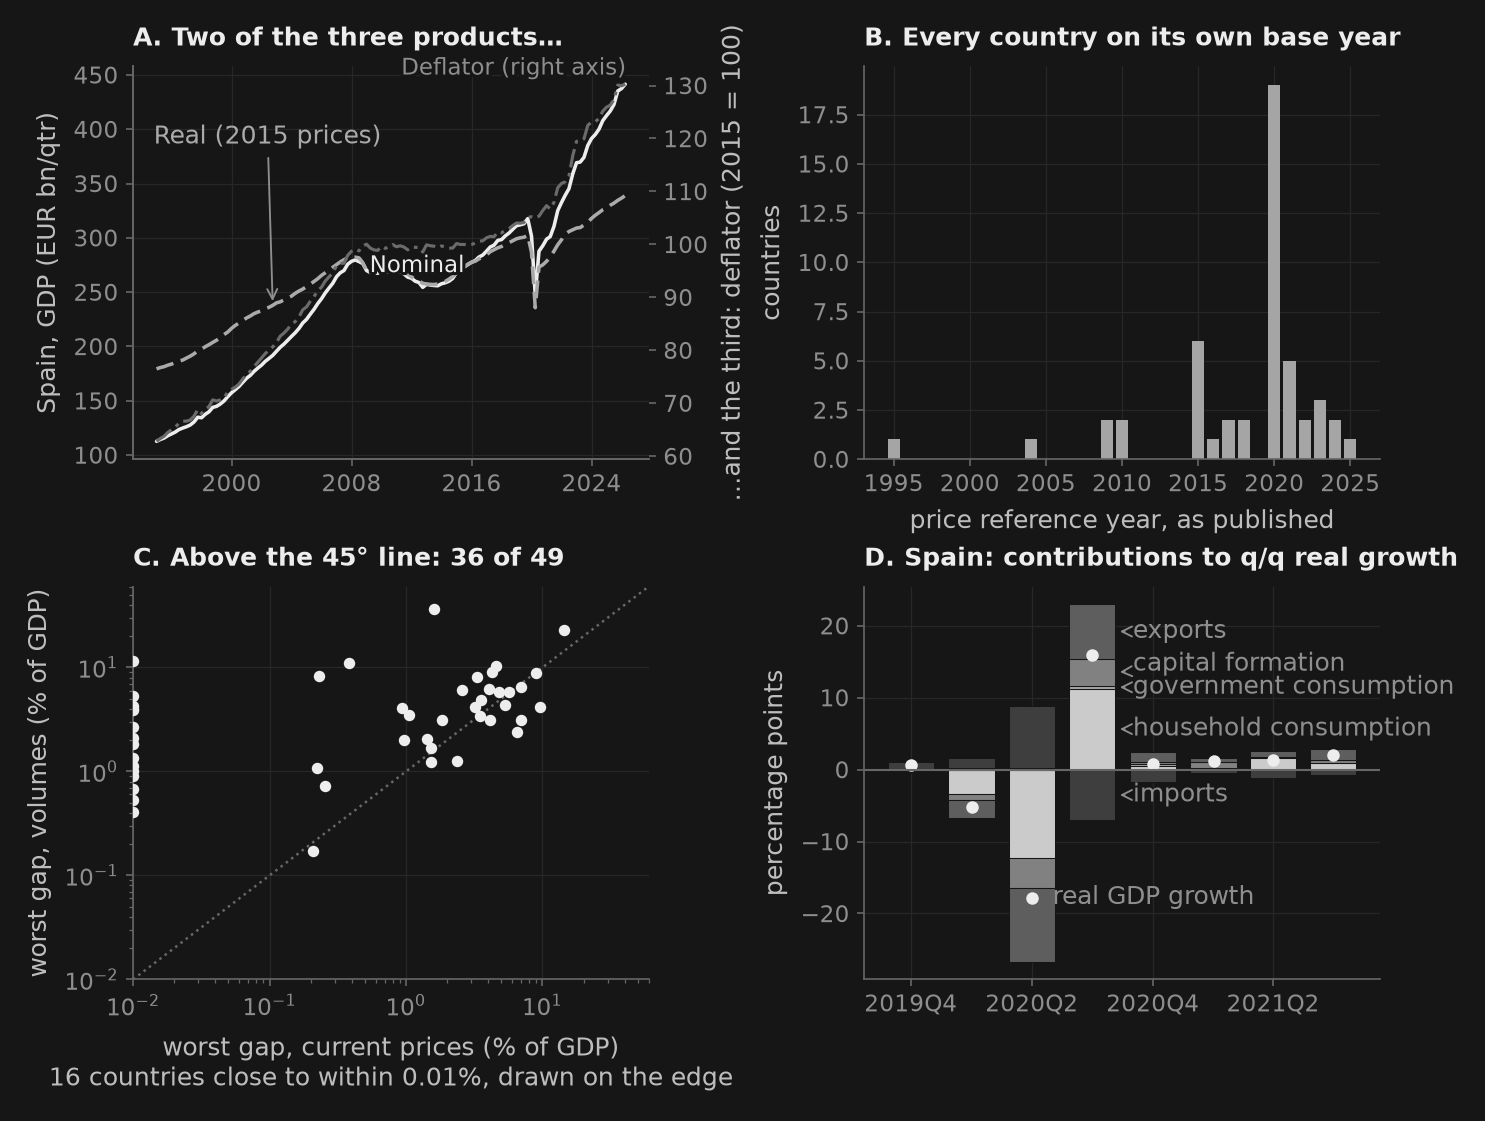

In [10]:
cols = _nbstyle.palette(5)                  # most prominent first
lss = _nbstyle.styles(5)

fig, axes = _nbstyle.figura(2, 2)
(axA, axB), (axC, axD) = axes

# A. The three products for one country: one object seen three ways. The
# deflator needs its own axis (it is an index, not a currency amount); each
# series carries its name next to it, and the deflator's says which axis to read.
g = qna15.loc["ESP"]
(ln_nom,) = axA.plot(g.index, g["gdp"] / 1e3, color=cols[0], lw=1.7, ls="-", label="Nominal")
axA.plot(g.index, g["gdp_real"] / 1e3, color=cols[2], lw=1.7, ls=lss[1],
         label="Real (2015 prices)")
axA.set_ylabel("Spain, GDP (EUR bn/qtr)")
axA.set_title("A. Two of the three products…")
# The panel is narrow: one tick every eight years keeps the years readable.
marcas = [t for t in g.index if t.year % 8 == 0 and t.quarter == 1]
axA.set_xticks(marcas); axA.set_xticklabels([str(t.year) for t in marcas])
axA2 = axA.twinx()
axA2.plot(g.index, g["gdp_defl"], color=_nbstyle.S3["color"], lw=1.5, ls=lss[2],
          label="Deflator (right axis)")
axA2.set_ylabel("…and the third: deflator (2015 = 100)")
axA2.grid(False)

# B. The reference years the source actually ships.
yrs = meta["price_ref_year"].dropna().astype(int).value_counts().sort_index()
axB.bar(yrs.index, yrs.values, color=_nbstyle.tono(0.7), width=0.8)
axB.set_title("B. Every country on its own base year")
axB.set_ylabel("countries")
axB.set_xlabel("price reference year, as published")

# C. The identity: exact in current prices, not in volumes. Log axes because
# the gaps span four orders of magnitude; the countries whose accounts
# close to *exactly* zero have no place on a log axis, so they are floored at
# the left edge and the caption says so rather than hiding them.
FLOOR = 0.01
gap_n = score["nominal_absmax"].clip(lower=FLOOR)
gap_r = score["real_absmax"].clip(lower=FLOOR)
# Everything at or below the floor lands on the left edge, not just the exact
# zeros — say how many, so the stack there is not read as scatter.
n_floored = int((score["nominal_absmax"] <= FLOOR).sum())
axC.scatter(gap_n, gap_r, s=20, color=_nbstyle.TINTA, zorder=3)
edge = [FLOOR, 60]
axC.plot(edge, edge, color=_nbstyle.SPINE, ls=":", lw=1.2, zorder=1)
axC.set_xscale("log"); axC.set_yscale("log")
axC.set_xlim(*edge); axC.set_ylim(*edge)
axC.set_xlabel(f"worst gap, current prices (% of GDP)\n"
               f"{n_floored} countries close to within {FLOOR}%, drawn on the edge")
axC.set_ylabel("worst gap, volumes (% of GDP)")
axC.set_title(f"C. Above the 45° line: "
              f"{(score['real_absmax'] > score['nominal_absmax']).sum()} of {len(score)}")

# D. The payoff — contributions to the 2020 collapse and rebound. Each segment
# is named with a leader from the tallest bar; the dot, next to the collapse.
NAMES = {"cons_hh": "household consumption", "cons_gov": "government consumption",
         "capform": "capital formation", "exports": "exports",
         "imports": "imports"}
sp = contrib.loc["ESP"]
win = sp[(sp.index >= "2019-10-01") & (sp.index <= "2021-07-01")]
bottom_pos = np.zeros(len(win)); bottom_neg = np.zeros(len(win))
shades = [_nbstyle.tono(t) for t in (0.86, 0.70, 0.54, 0.38, 0.22)]
centres = {}                                 # component -> centre of its segment, bar by bar
for k, name in enumerate(COMPS):
    v = win[name].to_numpy()
    base_ = np.where(v >= 0, bottom_pos, bottom_neg)
    axD.bar(win.index, v, bottom=base_, width=70, color=shades[k],
            edgecolor=_nbstyle.FONDO, linewidth=0.5)
    centres[name] = base_ + v / 2
    bottom_pos = bottom_pos + np.where(v >= 0, v, 0.0)
    bottom_neg = bottom_neg + np.where(v < 0, v, 0.0)
axD.plot(win.index, win["gdp"], color=_nbstyle.UNIVERSAL_COLORS[0], marker="o", ms=5, lw=0)
axD.axhline(0, color=_nbstyle.SPINE, lw=1.0)
axD.set_title("D. Spain: contributions to q/q real growth")
axD.set_ylabel("percentage points")
axD.set_xticks(win.index[::2])
axD.set_xticklabels([d.to_period("Q").strftime("%YQ%q") for d in win.index[::2]])
# The guide bar is the rebound (the tallest positive stack): to its right the
# bars are small and the names fit in a column, at least 3 pp apart.
guide = int(np.argmax(bottom_pos))
x_guide = win.index[guide]
heights = sorted((float(centres[n][guide]), n) for n in COMPS)
ys = [h for h, _ in heights]
for i in range(1, len(ys)):
    ys[i] = max(ys[i], ys[i - 1] + 3.2)
for (h, name), yt in zip(heights, ys):
    axD.annotate(NAMES[name], xy=(x_guide + pd.Timedelta(days=36), h),
                 xytext=(x_guide + pd.Timedelta(days=62), yt), textcoords="data",
                 ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
trough = int(np.argmin(win["gdp"].to_numpy()))
axD.annotate("real GDP growth", xy=(win.index[trough], float(win["gdp"].iloc[trough])),
             xytext=(10, 0), textcoords="offset points", ha="left", va="center",
             color=_nbstyle.NOTA)

# The real series is named in the empty band at the top, with a leader to its
# curve: next to the line the name ran off the axes and printed over the right
# axis' label. The nominal one does fit next to its line, mid-panel.
axA.annotate("Real (2015 prices)",
             xy=(g.index[len(g) // 4], float(g["gdp_real"].iloc[len(g) // 4]) / 1e3),
             xytext=(0.04, 0.82), textcoords="axes fraction", ha="left", va="center",
             color=cols[2], arrowprops=_nbstyle.FLECHA)
xA0, xA1 = axA.get_xlim()
_nbstyle.etiquetar(axA, artistas=[ln_nom], donde=xA0 + 0.55 * (xA1 - xA0))
_nbstyle.etiquetar(axA2)
plt.show()


### 1.8 Step 8 — The same GDP, measured two other ways

Everything so far has been the **expenditure** approach: GDP as the sum of what was bought. It is one of three, and a statistical office computes all three from largely independent source data:

| approach | the question it answers | the identity |
|---|---|---|
| **Expenditure** | who bought the output | $Y = C + G + I + X - M$ |
| **Output** (production) | which industries produced it | $Y = \sum_j \mathrm{VA}_j + (D21 - D31) + \mathrm{YA1}$ |
| **Income** | whom it was paid to | $Y = D1 + B2A3G + (D2 - D3)$ |

They are not three ways of looking at the same data. Expenditure comes from retail and trade surveys, output from production surveys and VAT records, income from payroll and tax data. That they largely agree is an achievement, but where they occasionally disagree there may be information worth having.

1. **Coverage is not universal.** Argentina, Iceland and — surprisingly — **the United States** publish nothing in the OECD's by-activity flow at all; the US industry accounts are a separate BEA release.  Four more countries publish value added only in volume terms.
2. **Two of the value-added columns are memo items, not addends.** `va_mfg` (manufacturing) sits *inside* `va_ind` (industry), and `va_services` is the sum of the seven service columns already listed separately. Summing every `va_*` column counts a large part of the economy twice — the cell below measures exactly how much. `QNA_VA_ADDITIVE` names the ten that actually add up.
3. **Each flow publishes its own GDP, and the numbers do not always match.**

In [11]:
from puremacro.fetch import QNA_VA_ADDITIVE, QNA_VA_MEMO, QNA_ACTIVITIES, QNA_INCOME

published = pd.DataFrame({
    "expenditure": panel["gdp"].groupby(level="code").count(),
    "output": panel["va_total"].groupby(level="code").count(),
    "income": panel["comp_emp"].groupby(level="code").count(),
}).gt(0)
n = published.sum()
print(f"Countries publishing each approach, of {len(published)}:")
print(f"  expenditure {n['expenditure']}   output {n['output']}   income {n['income']}"
      f"   all three {int(published.all(axis=1).sum())}\n")

# "No output" covers two different situations and they should not be printed as
# one list: a country can be absent from the flow entirely, or publish value
# added in volume terms only — in which case the series are here, just not in
# current prices, so the identity cannot be scored but the data is not lost.
vol_only = sorted(c for c in published.index[~published["output"]]
                  if panel.loc[c, "va_total_real"].notna().any())
absent_out = sorted(set(published.index[~published["output"]]) - set(vol_only))
print(f"  absent from the by-activity flow altogether: {', '.join(absent_out)}")
print(f"    (the US industry accounts are a separate BEA release, not OECD QNA)")
print(f"  value added in volume terms only, so no current-price identity: "
      f"{', '.join(vol_only)}")
print(f"  no income accounts: {', '.join(sorted(published.index[~published['income']]))}")

# The memo-column trap, measured rather than warned about.
va_add = panel[list(QNA_VA_ADDITIVE)].sum(axis=1, min_count=len(QNA_VA_ADDITIVE))
va_all = panel[list(QNA_VA_ADDITIVE) + list(QNA_VA_MEMO)].sum(axis=1)
print(f"\nSum of the {len(QNA_VA_ADDITIVE)} additive activities / va_total: "
      f"{float((va_add / panel['va_total']).mean()):.4f}  <- adds up")
print(f"Sum of ALL {len(QNA_VA_ADDITIVE) + len(QNA_VA_MEMO)} va_* columns / va_total: "
      f"{float((va_all / panel['va_total']).mean()):.4f}  <- the trap: "
      f"manufacturing is inside industry, and va_services aggregates seven of the others")

assert np.isclose(float((va_add / panel["va_total"]).mean()), 1.0, atol=2e-3)
assert float((va_all / panel["va_total"]).mean()) > 1.5

Countries publishing each approach, of 49:
  expenditure 49   output 42   income 39   all three 35

  absent from the by-activity flow altogether: ARG, AUS, CAN, ISL, ISR, NZL, USA
    (the US industry accounts are a separate BEA release, not OECD QNA)
  value added in volume terms only, so no current-price identity: 
  no income accounts: ARG, BRA, CHL, CHN, CRI, IDN, IND, ISL, NZL, SAU

Sum of the 10 additive activities / va_total: 1.0001  <- adds up
Sum of ALL 12 va_* columns / va_total: 1.8071  <- the trap: manufacturing is inside industry, and va_services aggregates seven of the others


In [12]:
score = qna_identity(panel)

print("How well each identity closes, in current prices (% of GDP, |mean| across quarters):")
summary = pd.DataFrame({
    stem: {"countries": int(score[f"{stem}_mean"].notna().sum()),
           "median |mean|": score[f"{stem}_mean"].abs().median(),
           "median absmax": score[f"{stem}_absmax"].median(),
           "worst": score[f"{stem}_absmax"].max()}
    for stem in ("nominal", "output", "income")}).T
summary.index = ["expenditure", "output", "income"]
print(summary.round(3).to_string())
print("All three are accounting identities and all three behave like it. The output")
print("and income sides close *more* tightly than the expenditure side here, which is")
print("mostly §1.6's seasonal-adjustment wobble: fewer components, fewer independent")
print("adjustments to fail to add up.")

print("\nWhere the flows disagree about GDP itself (max |difference|, % of GDP):")
cross = score[["crossflow_output", "crossflow_income"]].dropna(how="all")
agree = (cross < 1e-6).sum()
print(f"  identical in {agree['crossflow_output']} of {cross['crossflow_output'].notna().sum()} "
      f"countries (output) and {agree['crossflow_income']} of "
      f"{cross['crossflow_income'].notna().sum()} (income). The rest:")
print(cross[(cross > 1e-6).any(axis=1)].round(2).sort_values(
    "crossflow_income", ascending=False).head(6).to_string())
print("These come from different source tables inside the same publication. Charging")
print("them to a component would be a measurement claim about that component; they")
print("are reported separately precisely so nobody does that by accident.")

# The famous one.
usa = score.loc["USA"]
print(f"\nThe United States has no output-side accounts here at all, but its income "
      f"side\nis the interesting case: the identity misses by up to "
      f"{usa['income_absmax']:.2f}% of GDP. That residual has a name —\nthe "
      f"**GDP-GDI statistical discrepancy** — and a literature (Nalewaik 2010): two "
      f"independent\nmeasurements of the same quantity that do not agree, and whose "
      f"gap is itself informative\nabout the cycle. Most European offices force it to "
      f"zero, which is a presentation choice,\nnot better measurement.")

assert score["output_mean"].abs().median() < 0.05
assert score["income_mean"].abs().median() < 0.05
assert np.isnan(usa["output_mean"])          # not in the OECD by-activity flow
assert usa["income_absmax"] > 1.0            # the GDP-GDI discrepancy

How well each identity closes, in current prices (% of GDP, |mean| across quarters):
             countries  median |mean|  median absmax   worst
expenditure       48.0          0.013          1.235  14.452
output            41.0          0.001          0.238   8.454
income            37.0          0.003          0.629   4.593
All three are accounting identities and all three behave like it. The output
and income sides close *more* tightly than the expenditure side here, which is
mostly §1.6's seasonal-adjustment wobble: fewer components, fewer independent
adjustments to fail to add up.

Where the flows disagree about GDP itself (max |difference|, % of GDP):
  identical in 33 of 43 countries (output) and 32 of 40 (income). The rest:
      crossflow_output  crossflow_income
code                                    
MEX               1.57              2.04
DEU               0.00              1.77
RUS               1.71              1.71
FRA               0.00              0.77
COL        

### 1.9 Step 9 — What each approach sees that the others cannot

The three approaches agree about GDP. They disagree about *everything else*, which is the point of holding all three: each carries a decomposition the others simply do not contain.

**The output side carries industrial structure.** Nothing on the expenditure side tells you what fraction of an economy is manufacturing, and the answer moves: below, the manufacturing share of value added has fallen in almost every country since the late 1990s. The exceptions are as informative as the rule — **Ireland's rose by nine points**, which is the same multinational accounting that §2.1 flags when Ireland's consumption share looks implausibly low.

**The income side carries the labour share**, $D1 / Y$ — one of Kaldor's stylized facts, the $1-\alpha$ of the course's Cobb–Douglas technology, and the object §3 currently reaches for EU-KLEMS to get. Read it straight off the accounts and it runs from 27% to 57%, which is *not* a fact about technology.

**That range is the measurement problem, not the economics.** Compensation of employees `D1` covers **employees only**. The labour income of the self-employed is not in `D1` at all — it sits inside `surplus_mixed`, because `B2A3G` is gross operating surplus *and mixed income* together and the accounts do not split them. So an economy with many self-employed workers books their labour income as capital income by construction. That is exactly Gollin (2002), and it is why Mexico reads 27%, Turkey 30% and Italy 40% while Germany reads 53%. The raw ratio ranks countries by self-employment as much as by factor shares, which is why §3 reaches for `puremacro.labor_share.gollin_adjusted_ls` rather than reading this ratio off the accounts, and why the ranking below should never be quoted as a ranking of factor shares.

In [13]:
YEARS_EARLY, YEARS_LATE = range(1995, 2000), range(2021, 2026)


def va_share(col, years):
    s = 100 * panel[col] / panel["va_total"]
    return s[s.index.get_level_values("date").year.isin(years)].groupby(level="code").mean()


struct = pd.DataFrame({
    "mfg 95-99": va_share("va_mfg", YEARS_EARLY),
    "mfg 21-25": va_share("va_mfg", YEARS_LATE),
    "finance": va_share("va_fin", YEARS_LATE),
    "public": va_share("va_public", YEARS_LATE),
    "ICT": va_share("va_ict", YEARS_LATE),
}).dropna(subset=["mfg 21-25"])
struct["change"] = struct["mfg 21-25"] - struct["mfg 95-99"]
moved = struct.dropna(subset=["change"]).sort_values("change")

print(f"Manufacturing share of value added: fell in {(moved['change'] < 0).sum()} of "
      f"{len(moved)} countries, median {moved['change'].median():+.1f} pp")
print(f"Level today: median {struct['mfg 21-25'].median():.1f}%, from "
      f"{struct['mfg 21-25'].idxmin()} at {struct['mfg 21-25'].min():.1f}% to "
      f"{struct['mfg 21-25'].idxmax()} at {struct['mfg 21-25'].max():.1f}%.\n")
print("Fastest deindustrialisation, and the four that went the other way:")
print(pd.concat([moved.head(5), moved.tail(4)]).round(1).to_string())
print(f"\nLuxembourg is the clearest specialisation in the panel: finance is "
      f"{struct.loc['LUX', 'finance']:.1f}% of its value added against a panel median of "
      f"{struct['finance'].median():.1f}%,\nand manufacturing only "
      f"{struct.loc['LUX', 'mfg 21-25']:.1f}%. Ireland is the other pole — and its "
      f"+{struct.loc['IRL', 'change']:.0f} pp of manufacturing is\nintellectual "
      f"property booked onshore, the same artefact that distorts its expenditure shares.")

assert (moved["change"] < 0).sum() > 0.75 * len(moved)
assert struct.loc["IRL", "change"] > 0
assert struct.loc["LUX", "finance"] > 3 * struct["finance"].median()

Manufacturing share of value added: fell in 31 of 36 countries, median -3.7 pp
Level today: median 15.4%, from LUX at 4.5% to IRL at 33.6%.

Fastest deindustrialisation, and the four that went the other way:
      mfg 95-99  mfg 21-25  finance  public   ICT  change
code                                                     
ROU        24.6       15.1      3.5    13.8   7.6    -9.5
FIN        25.5       16.9      3.7    21.2   6.5    -8.6
LUX        12.2        4.5     26.5    18.2   5.5    -7.7
ZAF        21.5       13.9     23.4     8.5   7.7    -7.6
SWE        22.0       14.5      4.4    20.7   8.0    -7.5
KOR        28.1       28.7      6.0    17.4   4.9     0.6
CHE        19.3       20.1      8.7    18.1   4.8     0.8
BGR        12.2       14.0      6.5    16.5   8.1     1.8
IRL        24.6       33.6      4.3     9.4  19.9     9.0

Luxembourg is the clearest specialisation in the panel: finance is 26.5% of its value added against a panel median of 4.8%,
and manufacturing only 4.5%. 

In [14]:
labour = (100 * panel["comp_emp"] / panel["gdp_income"])
labour = (labour[labour.index.get_level_values("date").year >= 2015]
          .groupby(level="code").mean().dropna().sort_values())

print(f"Labour share D1/Y from the income accounts, {len(labour)} countries, 2015+:")
print(f"  median {labour.median():.1f}%, from {labour.index[0]} at {labour.iloc[0]:.1f}% "
      f"to {labour.index[-1]} at {labour.iloc[-1]:.1f}%")
print("\nBottom five and top five:")
print(pd.concat([labour.head(5), labour.tail(5)]).round(1).to_string())
low = [c for c in labour.head(6).index if c != "IRL"]
print(f"\nRead the bottom of that list as a warning, not a finding. "
      f"{', '.join(low[:-1])} and {low[-1]}\nare among the economies with the most "
      f"self-employment in the panel, and a self-employed\nworker's labour income is "
      f"booked in surplus_mixed, never in comp_emp. Ireland sits\nthere for the "
      f"opposite reason — the denominator, not the numerator: multinational\nprofits "
      f"inflate GDP without passing through any resident payroll. §4.3's unprotected\n"
      f"labour margin and §3.2's Gollin adjustment are both about exactly this — "
      f"and §3.2\ndoes it with the QUARTERLY informality rate too, the only "
      f"kind that can correct a trend.")

# The unadjusted labour share is not a technology parameter: its spread is far
# wider than any plausible spread in alpha.
assert 40.0 < labour.median() < 55.0
assert labour.max() - labour.min() > 20.0
assert labour["MEX"] < labour["DEU"]

Labour share D1/Y from the income accounts, 39 countries, 2015+:
  median 47.2%, from MEX at 26.8% to CHE at 57.3%

Bottom five and top five:
code
MEX    26.8
IRL    28.5
TUR    29.6
COL    34.0
GRC    36.6
SVN    51.1
FRA    51.7
USA    52.5
DEU    53.2
CHE    57.3

Read the bottom of that list as a warning, not a finding. MEX, TUR, COL, GRC and ROU
are among the economies with the most self-employment in the panel, and a self-employed
worker's labour income is booked in surplus_mixed, never in comp_emp. Ireland sits
there for the opposite reason — the denominator, not the numerator: multinational
profits inflate GDP without passing through any resident payroll. §4.3's unprotected
labour margin and §3.2's Gollin adjustment are both about exactly this — and §3.2
does it with the QUARTERLY informality rate too, the only kind that can correct a trend.


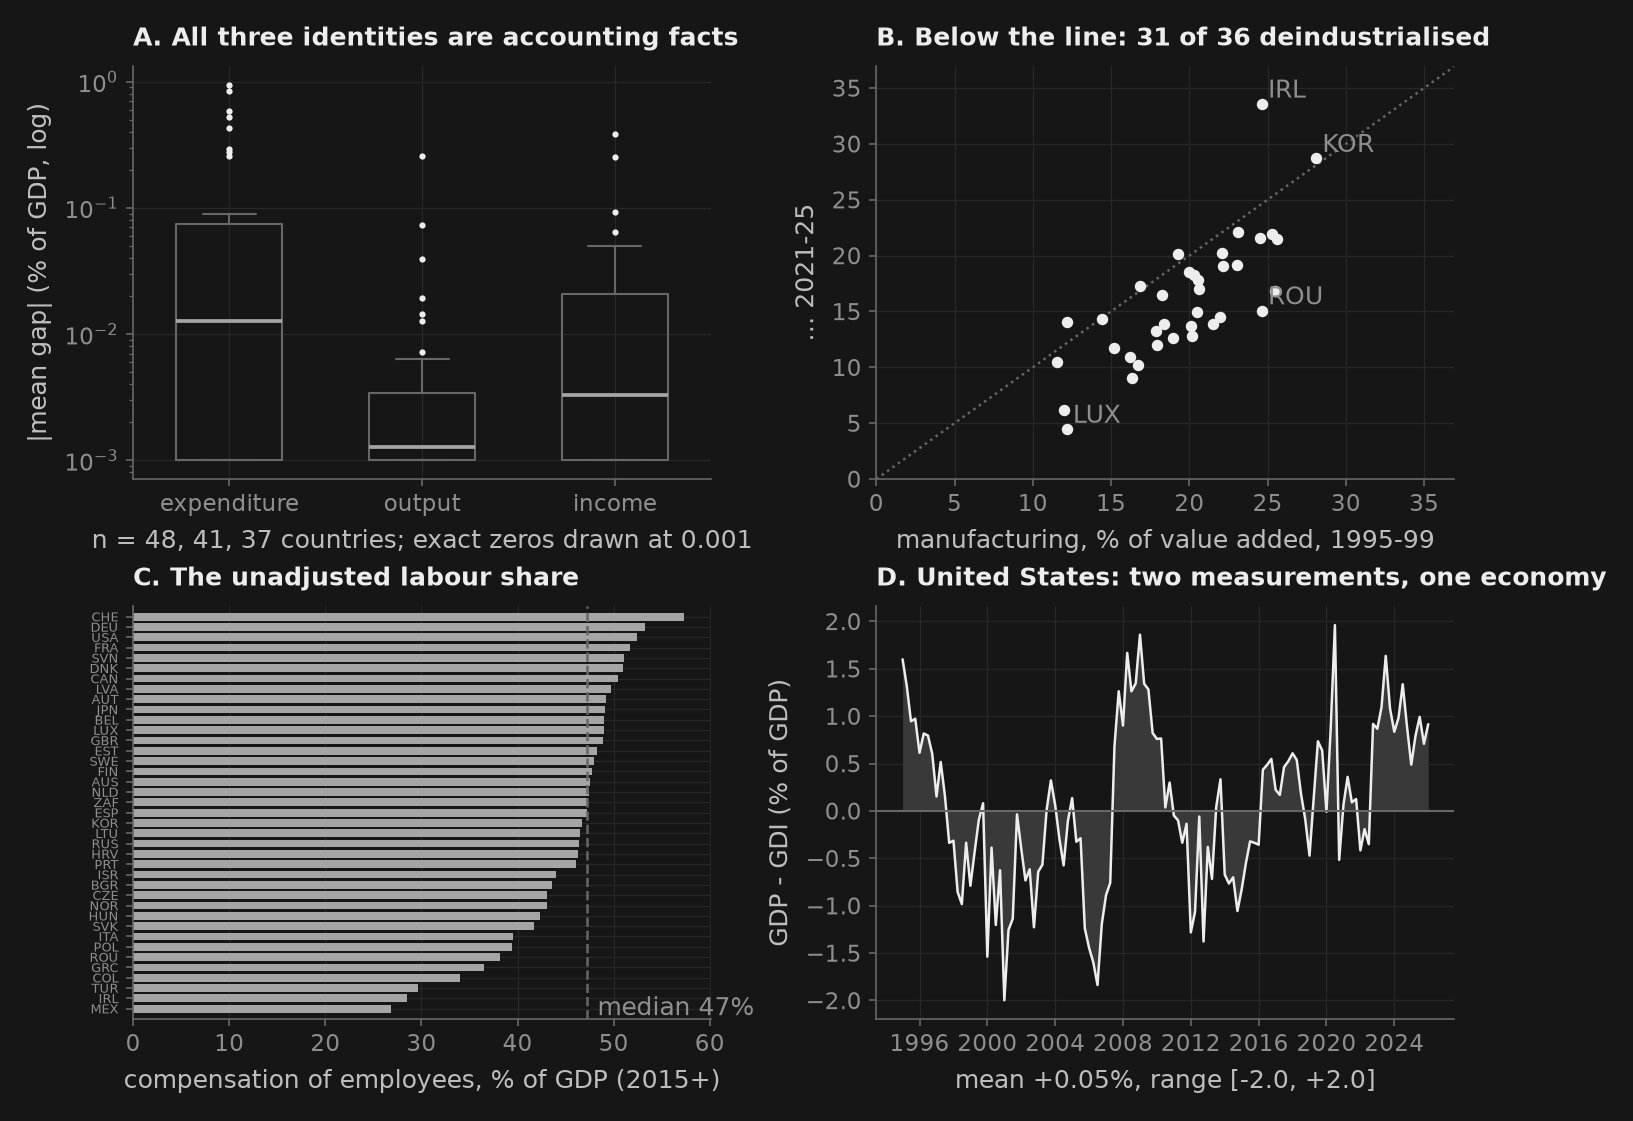

In [15]:
fig, axes = _nbstyle.figura(2, 2)
(axA, axB), (axC, axD) = axes

# A. How tightly each identity closes. Log axis: the distribution spans four
# orders of magnitude and a linear one would show a single spike at zero.
FLOOR_A = 1e-3
box = [score[f"{k}_mean"].abs().clip(lower=FLOOR_A).dropna()
       for k in ("nominal", "output", "income")]
axA.boxplot(box, tick_labels=["expenditure", "output", "income"],
            widths=0.55,
            boxprops=dict(color=_nbstyle.SPINE),
            whiskerprops=dict(color=_nbstyle.SPINE),
            capprops=dict(color=_nbstyle.SPINE),
            medianprops=dict(color=_nbstyle.UNIVERSAL_COLORS[1], lw=1.8),
            flierprops=dict(marker="o", ms=3, color=_nbstyle.TINTA, mfc=_nbstyle.TINTA, mec="none"))
axA.set_yscale("log")
axA.set_ylabel("|mean gap| (% of GDP, log)")
axA.set_title("A. All three identities are accounting facts")
axA.set_xlabel(f"n = {', '.join(str(len(b)) for b in box)} countries; "
               f"exact zeros drawn at {FLOOR_A:g}")

# B. Deindustrialisation: every country below the 45-degree line lost
# manufacturing share.
axB.scatter(struct["mfg 95-99"], struct["mfg 21-25"], s=20, color=_nbstyle.TINTA, zorder=3)
lim = (0, max(struct[["mfg 95-99", "mfg 21-25"]].max()) * 1.1)
axB.plot(lim, lim, color=_nbstyle.SPINE, ls=":", lw=1.2)
axB.set_xlim(*lim); axB.set_ylim(*lim)
for c in ("IRL", "LUX", "KOR", "ROU"):
    if c in struct.index:
        axB.annotate(c, (struct.loc[c, "mfg 95-99"], struct.loc[c, "mfg 21-25"]),
                     xytext=(3, 3), textcoords="offset points", color=_nbstyle.NOTA)
axB.set_xlabel("manufacturing, % of value added, 1995-99")
axB.set_ylabel("… 2021-25")
axB.set_title(f"B. Below the line: {(struct['change'] < 0).sum()} of "
              f"{struct['change'].notna().sum()} deindustrialised")

# C. The labour share, and why its spread is a measurement warning.
order = labour.sort_values()
axC.barh(np.arange(len(order)), order.to_numpy(), color=_nbstyle.tono(0.7), height=0.75)
axC.set_yticks(np.arange(len(order)))
axC.set_yticklabels(order.index, fontsize=6.0)
axC.axvline(order.median(), color=_nbstyle.SPINE, ls="--", lw=1.2)
axC.annotate(f"median {order.median():.0f}%", xy=(order.median(), 0), xytext=(5, 0),
             textcoords="offset points", ha="left", va="center", color=_nbstyle.NOTA)
axC.set_xlabel("compensation of employees, % of GDP (2015+)")
axC.set_title("C. The unadjusted labour share")
axC.set_ylim(-1, len(order))

# D. The one residual with a name: US GDP measured from expenditure against
# the same GDP measured from income.
us = panel.loc["USA"]
gdi_gap = (100 * (us["gdp_income"] - us["comp_emp"] - us["surplus_mixed"]
                  - us["taxes_prod_imp_net"]) / us["gdp_income"]).dropna()
axD.fill_between(gdi_gap.index, gdi_gap.to_numpy(), 0, color=_nbstyle.gris("0.75"), lw=0)
axD.plot(gdi_gap.index, gdi_gap.to_numpy(), color=_nbstyle.TINTA, lw=1.2, ls="-")
axD.axhline(0, color=_nbstyle.SPINE, lw=1.0)
axD.set_ylabel("GDP - GDI (% of GDP)")
axD.set_title("D. United States: two measurements, one economy")
axD.set_xlabel(f"mean {gdi_gap.mean():+.2f}%, range "
               f"[{gdi_gap.min():+.1f}, {gdi_gap.max():+.1f}]")

plt.show()


### 1.10 Step 10 — Check the three products

The build is finished. Before using it, one last control: separate the three product families and verify that the third rebuilds exactly from the other two. It is not tidiness — it is a statement about what is primary. The nominal frame and the deflator frame are the two you need; the volume frame is a convenience, which is why the course snapshot ships without it and §1.2 rebuilds it in one line.

**The files are written at the end, in §6**, not here, for two reasons. One is that the labour block §5 uses has not been squeezed yet, and freezing half the data halfway through is how you end up with two versions of one panel. The other is that what the next notebooks need is not the three *products* — nominal, deflators, volumes — but the four *blocks*: expenditure, income, output and labor market. §6 writes those four.

In [16]:
products = {"nominal": panel[NOMINAL],
            "deflators": panel[DEFL],
            "volumes": panel[REAL]}

print(f"The three products, {panel.index.get_level_values('code').nunique()} countries "
      f"x {dates.nunique()} quarters:")
for name, frame in products.items():
    obs = int(frame.notna().to_numpy().sum())
    print(f"  {name:15s} {frame.shape[1]:2d} series, {obs:>7,} observations")

# The volume frame is derivable from the other two — the whole point of §1. The
# deflator is only defined where both legs are strictly positive, so compare on
# the sample where all three products exist rather than on three separate
# dropna()s, which would silently align different quarters.
recovered = 100.0 * products["nominal"]["gdp"] / products["deflators"]["gdp_defl"]
both = pd.concat([recovered.rename("from_the_other_two"),
                  products["volumes"]["gdp_real"].rename("published")],
                 axis=1).dropna()
print(f"\nGDP volume rebuilt from nominal / deflator, checked on "
      f"{len(both):,} quarters: worst relative error "
      f"{float(((both['from_the_other_two'] - both['published']).abs() / both['published']).max()):.1e}")
assert np.allclose(both["from_the_other_two"], both["published"], rtol=1e-9)

The three products, 49 countries x 126 quarters:
  nominal         37 series, 180,417 observations
  deflators       31 series, 146,371 observations
  volumes         31 series, 146,371 observations

GDP volume rebuilt from nominal / deflator, checked on 5,812 quarters: worst relative error 0.0e+00


### 1.11 Step 11 — How far back? The accounts as a chain of vintages

The panel built above starts in 1995 because that is where the OECD's current tables start. It is not where the economies start, and it is not where their statistical offices start. Spain has published quarterly national accounts since 1970 and Japan since 1955 — in editions that were current once, and that the present one does not carry.

Reaching them means confronting something the lesson has so far been able to avoid. Every number in §1.1–§1.10 comes from a **single vintage**: one methodology, one price base, one set of source tables, applied uniformly across the sample. A history that reaches back fifty years cannot be that. It is a **chain** of vintages, and the joins are the interesting part.

**The join, and why it is a ratio.** Two vintages of the same accounts overlap for a stretch of quarters. Over that stretch the old series and the new one are two measurements of the same economy, so their ratio ought to be a constant — the old one is expressed in a base year since abandoned, in units since redefined, on a methodology since revised, and all of that is *level*. A **ratio splice** estimates that constant on the overlap, applies it to the whole older segment, and keeps the newer levels exactly as published. What survives from the old vintage is its **growth rates**; what is discarded is its levels, which were never comparable anyway.

That is the right operation, and it comes with its own test. If the ratio really is a constant, the two vintages agree about growth and the splice is innocuous. If the ratio **drifts** across the overlap, they do not, and then the spliced level depends on which quarter you happened to anchor to — which is another way of saying the answer is not determined by the data. So the ratio's stability is not a diagnostic printed alongside the result. It *is* the result's warranty, and `qna_long_panel` reports it seam by seam rather than presenting a joined series as though it were one measurement.

In [17]:
from puremacro.fetch import qna_long_panel
from puremacro.fetch.longpanel import KNOWN_GAPS, long_panel_residual

LARGO = DATA / "oecd_qna_largo.csv"
LARGO_SEAMS = DATA / "oecd_qna_largo_seams.csv"

if VIVO:
    largo, seams = qna_long_panel(["ESP", "JPN"], spine=panel, return_seams=True)
else:
    largo = (pd.read_csv(LARGO, parse_dates=["date"])
               .set_index(["code", "date"]).sort_index())
    seams = pd.read_csv(LARGO_SEAMS, parse_dates=["date"])

_val = [c for c in largo.columns if not c.startswith("src_")]
print("The two economies with an archived history the current tables do not carry:")
for code in largo.index.get_level_values("code").unique():
    s = largo.loc[code]
    add = int((s.index < pd.Timestamp("1995-01-01")).sum())
    print(f"  {code}: {s.index.min().to_period('Q')}-{s.index.max().to_period('Q')}, "
          f"{len(s)} quarters — {add} of them before the OECD tables begin")
    for src, n in s["src_gdp"].value_counts().items():
        span = s.index[s["src_gdp"] == src]
        print(f"       {n:>3d} from {src:<13s} {span.min().to_period('Q')}"
              f"-{span.max().to_period('Q')}")

print(f"\nEverything else that was checked and rejected, with the reason "
      f"({len(KNOWN_GAPS)} countries):")
for code, why in KNOWN_GAPS.items():
    print(f"  {code}: {why.split('.')[0]}.")

The two economies with an archived history the current tables do not carry:
  ESP: 1970Q1-2026Q2, 226 quarters — 100 of them before the OECD tables begin
       126 from oecd          1995Q1-2026Q2
        60 from ine_base1995  1980Q1-1994Q4
        40 from ine_base1986  1970Q1-1979Q4
  JPN: 1955Q2-2026Q2, 285 quarters — 159 of them before the OECD tables begin
       126 from oecd          1995Q1-2026Q2
        99 from jp_sna68      1955Q2-1979Q4
        60 from jp_sna93      1980Q1-1994Q4

Everything else that was checked and rejected, with the reason (7 countries):
  DEU: Pre-1991 German nominal accounts cover West Germany only.
  MEX: INEGI serves nothing before 1993 and is identical to the OECD after dividing by four.
  BRA: IBGE's quarterly accounts start 1996Q1, the same quarter as the OECD, across all seven candidate tables.
  CHL: Banco Central reaches 1990Q1, 24 quarters before the OECD, but only for gdp/inv/exports/imports and only NSA, via ~1 MB HTML scrapes with no JSON ro

#### The seam is the finding

Twenty-eight joins: two countries, seven expenditure columns, two seams each. The table below is the whole warranty, and it does not come back clean — **nine of the twenty-eight drift by more than the two per cent the splice is willing to certify.**

They are not scattered at random. Gross capital formation is unstable at every seam in both countries, which is what you would expect of the aggregate that carries the change in inventories: a small, violently moving component measured differently by every vintage that touches it. And the single worst join in the table is **Japanese government consumption at the 1968 SNA seam** — a ratio of 396 that ranges from 362 to 453 across the overlap. That is not a measurement error. The 1968 System of National Accounts drew the boundary of government in a different place, so the two series are not two estimates of one quantity; they are estimates of two quantities. A ratio splice cannot repair a definitional change, and the drift statistic is how it says so.

In [18]:
seams["drift %"] = 100.0 * seams["ratio_drift"]
show = seams[["code", "column", "older", "date", "overlap_n", "ratio",
              "drift %", "stable"]].copy()
show["date"] = show["date"].dt.to_period("Q")
print(f"Every join, and whether it is determined ({len(seams)} seams):\n")
print(show.sort_values(["code", "column"]).to_string(index=False,
                                                     float_format=lambda v: f"{v:.3f}"))

bad = seams[~seams["stable"]]
print(f"\n{len(bad)} of {len(seams)} seams drift by more than "
      f"{100 * 0.02:.0f}% and are reported unstable:")
for _, r in bad.sort_values("ratio_drift", ascending=False).iterrows():
    print(f"  {r['code']} {r['column']:<9s} {r['older']:<13s} "
          f"drift {100*r['ratio_drift']:5.2f}%  "
          f"ratio ranges {r['ratio_min']:.3f}-{r['ratio_max']:.3f} "
          f"over {int(r['overlap_n'])} quarters")
print("\nUnstable does not mean discarded — `drop_unstable=True` would blank those\n"
      "quarters, and it is off by default, because deleting data quietly is its own\n"
      "failure mode. It means the level of that column, that far back, is not pinned\n"
      "down by the overlap, and a reader who uses it should know that.")

assert len(bad) > 0
assert set(bad["column"]) >= {"capform"}

Every join, and whether it is determined (28 seams):

code   column        older   date  overlap_n   ratio  drift %  stable
 ESP  capform ine_base1995 1995Q1         40   1.096    3.314   False
 ESP  capform ine_base1986 1980Q1         76   1.196    5.125   False
 ESP cons_gov ine_base1995 1995Q1         40   1.010    0.942    True
 ESP cons_gov ine_base1986 1980Q1         76   1.128    2.607   False
 ESP  cons_hh ine_base1995 1995Q1         40   1.075    1.318    True
 ESP  cons_hh ine_base1986 1980Q1         76   1.081    0.995    True
 ESP  exports ine_base1995 1995Q1         40   1.007    1.617    True
 ESP  exports ine_base1986 1980Q1         76   0.995    2.555   False
 ESP      gdp ine_base1995 1995Q1         40   1.062    1.139    True
 ESP      gdp ine_base1986 1980Q1         76   1.103    0.865    True
 ESP  imports ine_base1995 1995Q1         40   1.033    1.471    True
 ESP  imports ine_base1986 1980Q1         76   1.033    2.389   False
 ESP      inv ine_base1995 1995Q1   

#### What a chain costs: the identity stops closing

§1.6 established that the expenditure identity closes **exactly** in current prices — to the last bit, because the office builds it that way. That is a property of a single vintage, and the cell below shows what happens to it along a chain.

The reason is worth seeing before the number. Each column is spliced **independently**, against its own overlap, with its own ratio. Consumption gets one constant, investment another, exports a third. Seven constants that are not equal cannot preserve a sum, so the identity that held to $10^{-16}$ inside one vintage cannot survive being assembled from three.

What is remarkable is how small the damage is, and how legibly it grows with distance. Inside the OECD segment the residual is **zero to the printed precision**, as it must be. One vintage back it is a few tenths of a percent of GDP; two vintages back, on Japan's 1968 SNA figures, it is about one per cent. That is the price of fifty extra years, denominated in the currency §1 taught you to read.

In [19]:
resid = long_panel_residual(largo)
rel = 100.0 * resid / largo["gdp"]

rows = []
for code in largo.index.get_level_values("code").unique():
    s, m = largo.loc[code], rel.loc[code]
    for src, g in m.groupby(s["src_gdp"]):
        span = s.index[s["src_gdp"] == src]
        rows.append({"code": code, "vintage": src, "quarters": len(g),
                     "from": span.min().to_period("Q"),
                     "to": span.max().to_period("Q"),
                     "mean |residual|, % of GDP": g.abs().mean(),
                     "worst": g.abs().max()})
by_src = pd.DataFrame(rows)
print("Y = C + G + I + X - M, in current prices, along the chain:\n")
print(by_src.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

_oecd = by_src[by_src["vintage"] == "oecd"]["mean |residual|, % of GDP"]
print(f"\nInside the OECD vintage the identity closes to "
      f"{_oecd.max():.4f}% of GDP — §1.6's exact zero, unchanged. Every older "
      f"segment\nis assembled from seven independent constants, and none of them "
      f"closes.")
assert float(_oecd.max()) < 1e-4      # floating point, not an economic gap
assert by_src["mean |residual|, % of GDP"].max() < 2.0

Y = C + G + I + X - M, in current prices, along the chain:

code      vintage  quarters   from     to  mean |residual|, % of GDP  worst
 ESP ine_base1986        40 1970Q1 1979Q4                      0.689  1.310
 ESP ine_base1995        60 1980Q1 1994Q4                      0.269  0.746
 ESP         oecd       126 1995Q1 2026Q2                      0.000  0.000
 JPN     jp_sna68        99 1955Q2 1979Q4                      0.950  2.336
 JPN     jp_sna93        60 1980Q1 1994Q4                      0.560  1.124
 JPN         oecd       126 1995Q1 2026Q2                      0.000  0.000

Inside the OECD vintage the identity closes to 0.0000% of GDP — §1.6's exact zero, unchanged. Every older segment
is assembled from seven independent constants, and none of them closes.


#### What fifty years show that twenty-five cannot

The archives are nominal — current prices, no deflators, no volumes — and that is not the limitation it sounds like. §1 spent ten steps establishing which statistics survive which transformation, and the **share of GDP** is the one that survives everything: a ratio of two current-price figures in the same currency in the same quarter, immune to the price base, immune to the reference year, immune to the exchange rate. It is exactly the statistic a chain of vintages can carry.

And it is enough for the two largest structural facts in these economies' postwar histories.

**Japan built and then stopped building.** Gross capital formation runs at 31% of GDP in the late 1950s, climbs to **42% at the peak of the high-growth era in the early 1970s**, and falls for forty years to 25%. That is a seventeen-point swing in the share of output going into capital — the investment boom that produced the growth miracle, and its unwinding. A sample beginning in 1995 sees the last third of the descent and nothing else.

**Spain built a state.** Government consumption is under 10% of GDP in the early 1970s and around 20% today: it doubles. The doubling is not gradual — it happens between 1975 and 1993, which is the period between the end of the dictatorship and the completion of the welfare state, and it is the single largest move in either country's table. Spain's capital formation tells the other Spanish story: 29% in the early 1970s, down to 23% by the early 1980s, back up to **28% in 2005–09**, and then a collapse to 19% — the construction boom and bust, visible as a nine-point round trip in a national accounts share.

In [20]:
SHARES = {"cons_hh": "household consumption", "cons_gov": "government consumption",
          "capform": "gross capital formation"}
blocks = {}
for code in largo.index.get_level_values("code").unique():
    s = largo.loc[code]
    sh = pd.DataFrame({k: 100.0 * s[k] / s["gdp"] for k in SHARES})
    sh["net exports"] = 100.0 * (s["exports"] - s["imports"]) / s["gdp"]
    blocks[code] = sh.groupby((sh.index.year // 5) * 5).mean()

for code, b in blocks.items():
    print(f"{code}: expenditure shares, % of GDP, five-year averages\n")
    print(b.round(1).to_string())
    for col in list(SHARES.values()) + ["net exports"]:
        c = b[col if col in b.columns else
              [k for k, v in SHARES.items() if v == col][0]]
        print(f"    {col:<26s} {c.min():5.1f} ({c.idxmin()}s) to "
              f"{c.max():5.1f} ({c.idxmax()}s), a swing of {c.max()-c.min():.1f} pp")
    print()

ESP: expenditure shares, % of GDP, five-year averages

      cons_hh  cons_gov  capform  net exports
date                                         
1970     63.3       9.8     29.1         -1.5
1975     63.9      11.8     27.2         -2.2
1980     64.6      14.2     22.9         -1.5
1985     61.9      15.0     24.1         -0.7
1990     61.2      17.0     24.6         -2.5
1995     60.2      17.1     23.4         -0.7
2000     58.8      16.7     27.1         -2.6
2005     57.7      18.3     28.5         -4.4
2010     58.9      20.0     19.5          1.6
2015     58.1      18.7     19.9          3.3
2020     55.9      20.4     21.5          2.3
2025     55.7      19.2     21.4          3.7
    household consumption       55.7 (2025s) to  64.6 (1980s), a swing of 8.9 pp
    government consumption       9.8 (1970s) to  20.4 (2020s), a swing of 10.6 pp
    gross capital formation     19.5 (2010s) to  29.1 (1970s), a swing of 9.7 pp
    net exports                 -4.4 (2005s) to   3.7 (20

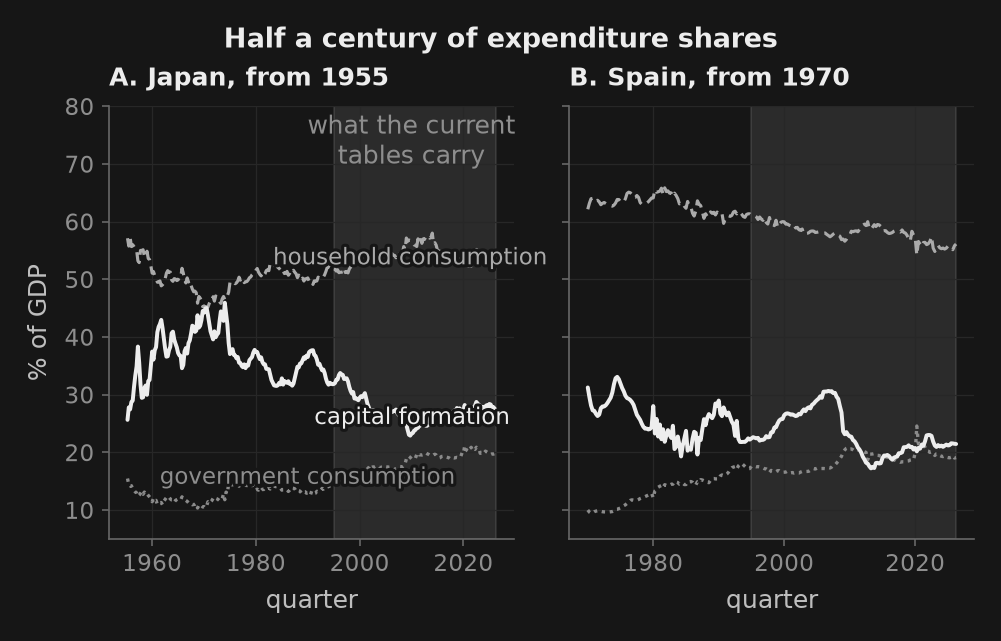

In [21]:
# The size comes from the profile: 6.4 x 4.0 in in the notebook, the slot on the slide.
fig, axes = _nbstyle.figura(1, 2, sharey=True, figsize=plt.rcParams["figure.figsize"])
for ax, code, title in zip(axes, ("JPN", "ESP"),
                           ("A. Japan, from 1955", "B. Spain, from 1970")):
    s = largo.loc[code]
    sh = pd.DataFrame({k: 100.0 * s[k] / s["gdp"] for k in SHARES})
    style = {"cons_hh": (cols[2], (0, (4, 2)), 1.5),
             "cons_gov": (cols[3], (0, (1, 1.4)), 1.6),
             "capform": (cols[0], "-", 1.9)}
    for key, label in SHARES.items():
        col, ls, lw = style[key]
        ax.plot(sh.index, sh[key], color=col, lw=lw, ls=ls, label=label)
    ax.axvspan(pd.Timestamp("1995-01-01"), sh.index.max(), color=_nbstyle.RECESION, zorder=0)
    ax.set_title(title)
    ax.set_xlabel("quarter")
    # One tick every 20 years: at 12 pt across half a panel, one per decade collides.
    years = [y for y in range(1960, 2021, 20) if sh.index.min().year <= y <= sh.index.max().year]
    ax.set_xticks(pd.to_datetime([f"{y}-01-01" for y in years]), [str(y) for y in years])
    # Up to 80 so the note on the shaded stretch lands on no line.
    ax.set_ylim(5, 80)
axes[0].set_ylabel("% of GDP")
# The note is written once: the shaded stretch is the same in both panels.
axes[0].annotate("what the current\ntables carry",
                 xy=(pd.Timestamp("2010-01-01"), 79),
                 color=_nbstyle.NOTA, ha="center", va="top")
fig.suptitle("Half a century of expenditure shares")
# The three names are written once, in the left panel: both panels carry the
# same series with the same stroke, and in the Spain one "capital formation"
# and "government consumption" land side by side.
_nbstyle.etiquetar(axes[0],
                   nombres={"gross capital formation": "capital formation"})
plt.show()


#### And what it cannot carry: an old edition is a different instrument

Everything above is a statement about **levels and shares**, and that is deliberate. The temptation with fifty extra years of quarterly data is to compute second moments on them — volatilities, correlations, persistence, the whole apparatus of business cycle measurement. The archive will not support it, and the demonstration is short enough to run here.

Take fifteen years that two different editions of the archive both cover, and compare them. Not two countries, not two methods: **the same quarters of the same economy, read from two vintages.** The disagreement is wildly uneven between the two things one might want from the series. On the *trend* the editions are close: they differ by a few tenths of a percentage point a year in cumulative growth. On the *quarter-to-quarter movements* they barely agree at all — the older edition's growth rates are around two-thirds as volatile, and the two vintages' quarterly movements correlate about a half, which for two measurements of one economy is a remarkable thing to have to report.

That asymmetry has a cause. Revisions accumulate into the level slowly and smoothly, so a level path is a robust thing to read from an old vintage. Quarterly *movements* are the first thing a statistical office improves and the last thing it gets right, so the second moments of an old edition are a property of the edition as much as of the economy. An archived vintage is a reliable witness to where an economy went and an unreliable one to how bumpy the ride was — which licenses the trends and shares above, and forbids computing volatilities, correlations or persistence on the spliced history.

In [22]:
# This archive is read three times in the lesson — here, in §4.1 and in §4.4 —
# and it is 1.25 million rows, so it is read once and remembered. The gzip is
# not what costs: `pd.read_csv` decompresses the 3.8 MB in 0.2 s. The dates
# are. `pd.PeriodIndex(col.astype(str), freq="Q")` parses 1.25 million strings
# one at a time and takes 3 s a call, and the column holds 318 distinct
# quarters — so parsing the DISTINCT ones and putting them back where they came
# from takes 20 ms and gives the same timestamps. Three hundred strings read
# four thousand times each is most of a minute on a tablet.
_ARCHIVES = {}


def archive(path):
    """The frozen real-time archive at `path`: read once, dated once, kept."""
    key = str(path)
    if key not in _ARCHIVES:
        s = pd.read_csv(path, dtype={"edition": str})
        where, quarters = pd.factorize(s["date"])
        _ARCHIVES[key] = pd.DataFrame({
            "code": s["code"], "variable": s["variable"],
            "date": pd.PeriodIndex(quarters.astype(str),
                                   freq="Q").to_timestamp()[where],
            "edition": s["edition"], "value": pd.to_numeric(s["value"])})
    return _ARCHIVES[key]


_arch = archive(DATA / "oecd_stes_vintages_gdp.csv.gz")


def edition(code, ed):
    d = _arch[(_arch["code"] == code) & (_arch["edition"] == ed)]
    return d.set_index("date")["value"].sort_index()


print("The same quarters of the same economy, read from two editions:\n")
for code, old, new, lo, hi in (("ESP", "199907", "200505", "1980", "1994"),
                               ("JPN", "199907", "201112", "1980", "1993")):
    # sort=True is concat's current default on date indexes; pandas 4 flips it.
    j = pd.concat([edition(code, old).rename("old"),
                   edition(code, new).rename("new")],
                  axis=1, sort=True).dropna().loc[f"{lo}-01-01":f"{hi}-12-31"]
    g_old = 100.0 * np.log(j["old"]).diff().dropna()
    g_new = 100.0 * np.log(j["new"]).diff().dropna()
    cum_old = 100.0 * float(np.log(j["old"].iloc[-1] / j["old"].iloc[0]))
    cum_new = 100.0 * float(np.log(j["new"].iloc[-1] / j["new"].iloc[0]))
    print(f"  {code} {lo}-{hi}, {len(g_old)} quarters, editions {old} vs {new}")
    _yrs = int(hi) - int(lo) + 1
    print(f"    cumulative growth      {cum_old:6.2f}%  vs {cum_new:6.2f}%   "
          f"-> {abs(cum_old-cum_new):.2f} pp apart over {_yrs} years "
          f"({abs(cum_old-cum_new)/_yrs:.2f} pp a year)")
    print(f"    sd of quarterly growth {g_old.std():6.3f}%  vs {g_new.std():6.3f}%   "
          f"-> the newer edition is {g_new.std()/g_old.std():.2f} times as volatile")
    print(f"    correlation of the quarterly growth rates: {g_old.corr(g_new):+.3f}\n")
    assert abs(cum_old - cum_new) < 7.0
    assert g_new.std() > 1.3 * g_old.std()

The same quarters of the same economy, read from two editions:

  ESP 1980-1994, 59 quarters, editions 199907 vs 200505
    cumulative growth       35.10%  vs  34.60%   -> 0.49 pp apart over 15 years (0.03 pp a year)
    sd of quarterly growth  0.539%  vs  0.952%   -> the newer edition is 1.76 times as volatile
    correlation of the quarterly growth rates: +0.477

  JPN 1980-1993, 55 quarters, editions 199907 vs 201112
    cumulative growth       44.97%  vs  50.88%   -> 5.91 pp apart over 14 years (0.42 pp a year)
    sd of quarterly growth  0.666%  vs  1.043%   -> the newer edition is 1.57 times as volatile
    correlation of the quarterly growth rates: +0.645



## 2. What the three products are good for

The accounts are built. From here on the panel is used rather than constructed, and the four subsections below are four different answers to "which of the three products does this question want".

- **§2.1 — the shares.** A *nominal* question: the identity closes exactly in current prices, so $C/Y$ and $I/Y$ are pure numbers needing no currency conversion.
- **§2.2 — the relative prices.** A *deflator* question: ratios of deflators are the relative prices macroeconomics cares about, and they exist in no other product. It is also where the denominator has to be chosen, and consumption net of durables is the one the theory asks for.
- **§2.3 — what the exchange rate contaminates.** A question about which of the first two survives contact with $E$, and which does not.
- **§2.4 — durables as capital.** A question that needs all three, on a finer cut of the same accounts.

### 2.1 The identity, and the expenditure shares it implies

In current prices the identity is an accounting fact rather than an approximation: whatever fails to add up is the published **statistical discrepancy**, and we print it instead of hiding it.

**Mind the concept.** The $C$ of the identity is *household* consumption (institutional sector `S1M` = households + NPISHs), 36-69% of GDP. National accounts also publish *total final consumption* (`S1`), which folds in the government and runs around 75% of GDP — a different object that the panel keeps in a separate column, `cons_gov`.

In [23]:
shares = pd.DataFrame({
    "C_hh/Y": 100 * panel["cons_hh"] / panel["gdp"],
    "G/Y":    100 * panel["cons_gov"] / panel["gdp"],
    "I/Y":    100 * panel["inv"] / panel["gdp"],
    "NX/Y":   100 * (panel["exports"] - panel["imports"]) / panel["gdp"],
    # Y - (C + G + gross capital formation + X - M): the statistical discrepancy
    "disc/Y": 100 * (panel["gdp"] - panel["cons_hh"] - panel["cons_gov"]
                     - panel["capform"] - panel["exports"] + panel["imports"]) / panel["gdp"],
})
tab = (shares.groupby(level="code").mean().round(1)
             .dropna(subset=["C_hh/Y"]).sort_values("C_hh/Y"))
print(f"Average expenditure shares since 1995 (nominal, % of GDP), {len(tab)} countries:")
print(tab.to_string())

missing = sorted(set(panel.index.get_level_values("code")) - set(tab.index))
if missing:
    print(f"\nNo household-consumption split published: {', '.join(missing)}")
print(f"C_hh/Y: median {tab['C_hh/Y'].median():.1f}%, "
      f"from {tab.index[0]} at {tab['C_hh/Y'].iloc[0]:.1f}% "
      f"to {tab.index[-1]} at {tab['C_hh/Y'].iloc[-1]:.1f}%.")
print("The bottom of that list is a warning about the *denominator*, not about "
      "thrifty households: Luxembourg and Ireland book multinational profits and\n"
      "intellectual property in GDP that never reaches a resident household, and "
      "Saudi Arabia and Norway book oil rents the same way. For those economies\n"
      "GNI, not GDP, is the sensible denominator.")

# Household consumption clusters around 55% of GDP; total final consumption
# (households + government) would be above 80% -- a different concept.
assert 48.0 < tab["C_hh/Y"].median() < 62.0
# The identity closes: what is left over is the statistical discrepancy.
assert tab["disc/Y"].abs().max() < 3.0

Average expenditure shares since 1995 (nominal, % of GDP), 48 countries:
      C_hh/Y   G/Y   I/Y  NX/Y  disc/Y
code                                  
LUX     36.3  16.3  18.8  28.1    -0.0
SAU     37.6  22.2  24.4  12.9     0.1
IRL     39.7  15.1  25.1  19.4    -0.0
NOR     43.7  21.2  22.9  11.2    -0.0
NLD     46.4  23.8  20.7   8.8     0.0
SWE     47.0  25.6  22.7   4.4     0.0
DNK     47.4  24.7  21.2   6.1     0.0
CZE     48.8  19.9  27.9   2.6     0.0
FIN     50.9  22.8  22.8   3.0    -0.1
KOR     51.4  13.7  30.9   2.7     0.0
RUS     51.8  18.0  20.9   8.2    -0.3
BEL     51.8  22.8  22.8   1.8    -0.0
HUN     52.2  21.0  23.4   1.5    -0.0
ISR     52.3  23.3  23.8  -0.3     0.0
AUT     52.6  20.1  24.1   2.3    -0.0
ISL     52.7  24.8  21.9   0.4    -0.0
CHE     53.1  11.7  26.6   7.6    -0.0
EST     53.5  19.4  27.8  -1.9     0.4
SVN     53.9  19.2  23.0   2.5     0.0
JPN     54.0  18.3  27.5   0.2     0.0
FRA     54.3  23.7  21.4   0.2    -0.0
DEU     54.5  19.9  20.6   4.2

### 2.2 What the deflators buy you: relative prices

Deflators are not just a device for getting to real magnitudes. Ratios of deflators *are* the relative prices macroeconomics cares about:
- **Relative price of investment** $P_I/P_C$ — capital goods in units of the consumption good. This is the object in Greenwood, Hercowitz & Krusell (1997): its inverse, $q_t = P_C/P_I$, *is* investment-specific technical change.
- **Terms of trade** $P_X/P_M$ — the dominant external shock for commodity exporters (Mendoza 1995; Kose 2002), moving in opposite directions for the country that exports copper and the one that transforms it.

**Two warnings about the numerator and the denominator, and both matter.**

*Denominator:* deflate by $P_C$, not by $P_Y$. The GDP deflator is an average that **contains $P_I$ itself**, so $P_I/P_Y$ shrinks the very movement you are trying to measure; and for a commodity exporter $P_Y$ also contains export prices, so $P_I/P_Y$ silently mixes in the terms of trade. The two disagree by 10-20 pp in exactly those countries.

*Denominator, again:* $P_C$ is itself an average, and one of the things inside it is **the price of consumer durables** — cars, computers, washing machines: manufactured goods whose prices fall for the same reason equipment's do. Leaving them in the denominator of a ratio built to measure investment-specific technical change nets part of the fact against itself. The consumption good of the model is the **non-durable** flow, which is why Greenwood, Hercowitz and Krusell deflate by non-durables and services, and why §2.4's reclassification $C^{*} = C - C_d$ belongs in the denominator here and not only in the volatility table there. `durability=True` already brought the split; the cell below turns it into one more (nominal, deflator) pair.

*Numerator:* total GFCF is **not one good**. It bundles *machinery, equipment and ICT* — manufactured, traded, and the assets Gordon (1990) and GHK actually measured — with *buildings and civil works*, which are poured on site out of local labour and cement and barely trade at all. The two have moved in opposite directions for thirty years, so the aggregate $P_I$ averages away the fact it is supposed to show. `qna_panel(..., assets=True)` splits GFCF by asset so we can look at each.

In [24]:
XDUR = ["cons_semidur", "cons_nondur", "cons_serv"]     # C* = C - C_d


def cons_ex_durables(g):
    """Household consumption net of durables, as a (nominal, deflator) pair.

    There is no published C* line to read off, so it is built the way §1 built
    every other deflator: add the components in current prices, add their
    volumes, and the implicit deflator is 100 x the ratio. Subtracting durables
    -- rather than keeping "non-durables" -- is what makes C* mean the same
    thing in all 37 countries: the United States and Chile classify household
    consumption in three buckets, not four, so they publish no semi-durables.
    """
    keep = [k for k in XDUR if k in g and not g[k].isna().all()]
    if not keep:
        return None
    nom = g[keep].dropna()
    vol = pd.concat([100.0 * g[k] / g[k + "_defl"] for k in keep],
                    axis=1, sort=True).dropna()
    idx = nom.index.intersection(vol.index)
    if len(idx) < 8:
        return None
    n, v = nom.loc[idx].sum(axis=1), vol.loc[idx].sum(axis=1)
    return pd.DataFrame({"cons_xdur": n, "cons_xdur_defl": 100.0 * n / v})


_xdur = {c: cons_ex_durables(panel.loc[c])
         for c in panel.index.get_level_values("code").unique()}
panel = panel.join(pd.concat({c: d for c, d in _xdur.items() if d is not None},
                             names=["code", "date"]))
print(f"C* = C - C_d built for "
      f"{int(panel['cons_xdur_defl'].notna().groupby(level='code').any().sum())} "
      f"of the {panel.index.get_level_values('code').nunique()} countries "
      f"(the rest publish no durability split).")
assert {"cons_xdur", "cons_xdur_defl"}.issubset(panel.columns)


def cum_change(num, den, over=None):
    """Cumulative % change of the deflator ratio num/den, by country.

    `over` restricts each country to the quarters where that column also
    exists. That is what makes two denominators comparable: the durability
    split starts later than the headline consumption deflator in several
    countries, and an extra decade of P_C is not evidence about P_C*.
    """
    out = {}
    for c in panel.index.get_level_values("code").unique():
        if num not in panel.columns:
            continue
        g = panel.loc[c]
        s = (g[num] / g[den]).dropna()
        if over is not None:
            s = s.reindex(g[over].dropna().index).dropna()
        if len(s) > 1:
            out[c] = 100.0 * (s.iloc[-1] / s.iloc[0] - 1.0)
    return pd.Series(out, dtype=float)


rel = pd.DataFrame({
    "P_I/P_C":     cum_change("inv_defl", "cons_hh_defl"),
    "P_eq/P_C":    cum_change("inv_equip_defl", "cons_hh_defl"),
    "P_st/P_C":    cum_change("inv_struct_defl", "cons_hh_defl"),
    "P_I/P_Y":     cum_change("inv_defl", "gdp_defl"),
    "P_X/P_M":     cum_change("exports_defl", "imports_defl"),
}).round(1).dropna(how="all").sort_values("P_eq/P_C")
print("Cumulative change since the first observation (%):")
print(rel.to_string())

both = rel.dropna(subset=["P_eq/P_C", "P_st/P_C"])
print(f"\nMedians across the {len(both)} countries with both assets — "
      f"equipment {both['P_eq/P_C'].median():+.0f}%, "
      f"structures {both['P_st/P_C'].median():+.0f}%, "
      f"total GFCF {both['P_I/P_C'].median():+.0f}%.")
print(f"Equipment got relatively cheaper in {(rel['P_eq/P_C'] < 0).sum()} of "
      f"{rel['P_eq/P_C'].notna().sum()} countries; structures in "
      f"{(rel['P_st/P_C'] < 0).sum()} of {rel['P_st/P_C'].notna().sum()}.")

gap = (rel["P_I/P_Y"] - rel["P_I/P_C"]).abs().nlargest(3)
print("Where the denominator matters most (P_I/P_C vs P_I/P_Y):",
      ", ".join(f"{c} {rel.loc[c, 'P_I/P_C']:+.0f} vs {rel.loc[c, 'P_I/P_Y']:+.0f}"
                for c in gap.index))

# The GHK fact is an *equipment* fact: it is far sharper in the traded asset
# than in the aggregate, and it reverses in the non-traded one.
assert both["P_eq/P_C"].median() < both["P_I/P_C"].median() < both["P_st/P_C"].median()
assert (rel["P_eq/P_C"].dropna() < 0).mean() > 0.85
# The copper exporter's terms of trade improved against those of the commodity
# importer that transforms them: the shock Mendoza (1995) puts at the centre of
# emerging-economy business cycles.
assert rel.loc["CHL", "P_X/P_M"] > rel.loc["JPN", "P_X/P_M"]

C* = C - C_d built for 37 of the 49 countries (the rest publish no durability split).
Cumulative change since the first observation (%):
     P_I/P_C  P_eq/P_C  P_st/P_C  P_I/P_Y  P_X/P_M
LTU    -41.2     -80.1       1.2    -50.4     39.8
EST    -43.5     -63.7     -24.6    -56.5     47.8
CZE    -29.6     -61.6      26.4    -29.7     13.1
AUS    -11.0     -60.8      24.5    -22.5     92.4
POL    -37.3     -57.6     -26.8    -34.7      2.0
USA    -15.1     -54.1      75.5    -17.7     17.3
PRT      1.2     -51.9      20.1     -7.9     17.1
CHL    -21.7     -51.2       3.5    -39.9    120.9
HRV     -9.7     -50.2      35.3    -18.2     20.8
HUN      2.1     -44.4      75.2    -15.4      2.3
ARG    -12.3     -43.7       NaN    -12.7     29.1
ITA    -17.4     -42.7       8.4    -16.9      2.5
ISR     12.4     -42.6      53.0      0.7     15.0
SVN      2.6     -42.5      72.1     -2.6     -0.2
NLD     -7.8     -41.2      13.0     -7.7      2.7
CAN     23.0     -40.6      57.5      5.2     2

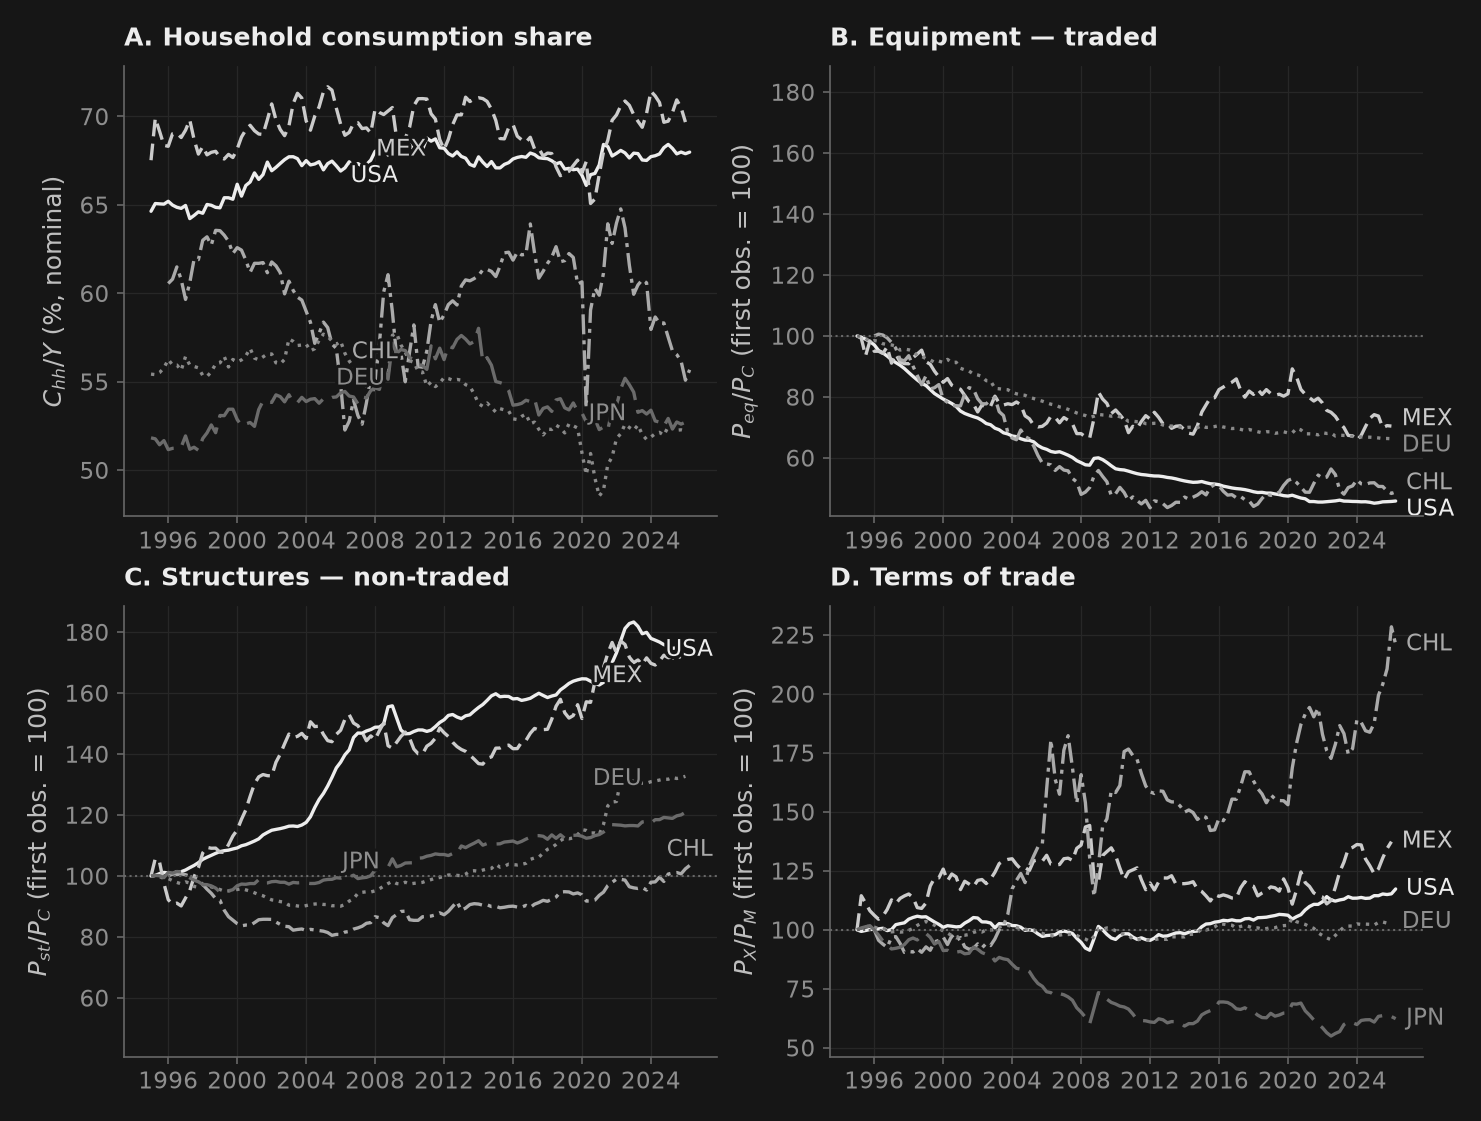

In [25]:
cols = _nbstyle.palette(5)                  # most prominent first
lss = _nbstyle.styles(5)
SHOW = ["USA", "MEX", "CHL", "DEU", "JPN"]

fig, axes = _nbstyle.figura(2, 2)
(axA, axB), (axC, axD) = axes
for k, c in enumerate(SHOW):
    g = panel.loc[c]
    kw = dict(color=cols[k], ls=lss[k], lw=1.6, label=c)
    axA.plot(g.index, 100 * g["cons_hh"] / g["gdp"], **kw)
    for ax, num, den in ((axB, "inv_equip_defl", "cons_hh_defl"),
                         (axC, "inv_struct_defl", "cons_hh_defl"),
                         (axD, "exports_defl", "imports_defl")):
        ratio = (g[num] / g[den]).dropna() if num in g else pd.Series(dtype=float)
        if len(ratio) > 1:
            ax.plot(ratio.index, 100 * ratio / ratio.iloc[0], **kw)

axA.set_title("A. Household consumption share")
axA.set_ylabel("$C_{hh}/Y$ (%, nominal)")
axB.set_title("B. Equipment — traded")
axB.set_ylabel("$P_{eq}/P_C$ (first obs. = 100)")
axC.set_title("C. Structures — non-traded")
axC.set_ylabel("$P_{st}/P_C$ (first obs. = 100)")
axD.set_title("D. Terms of trade")
axD.set_ylabel("$P_X/P_M$ (first obs. = 100)")
for ax in (axB, axC, axD):
    ax.axhline(100, color=_nbstyle.SPINE, ls=":", lw=1.0)
# same scale in B and C: the divergence is the whole point
lo = min(axB.get_ylim()[0], axC.get_ylim()[0])
hi = max(axB.get_ylim()[1], axC.get_ylim()[1])
axB.set_ylim(lo, hi); axC.set_ylim(lo, hi)
# Countries are named next to their line: inside in the left column, after
# the last point in the right one.
for ax in (axA, axC):
    _nbstyle.etiquetar(ax)
for ax in (axB, axD):
    _nbstyle.etiquetar(ax, donde="fin")
plt.show()


#### Consumption of *what*? The denominator, and one more numerator

Two changes to the same ratio, and they point the same way.

1. **The denominator.** Swap $P_C$ for $P_{C^{*}}$ — household consumption net of durables. Everything that made $P_I/P_Y$ the wrong ratio applies here in miniature: an index that contains the price you are measuring cannot measure it.
2. **One more numerator.** Add $P_{cd}$, the price of the durables themselves. §2.4 will argue from *volatility* that a car is household capital; if that is right, its **price** should behave like the price of capital. This is the same claim, made on the price side, and it can be tested before anything is filtered.

Both ratios are computed **on the same quarters** — `cum_change(..., over="cons_xdur_defl")` recomputes $P_{eq}/P_C$ over exactly the window where $P_{C^{*}}$ exists — so what changes between the two columns is the concept and not the sample.

In [26]:
OVER = "cons_xdur_defl"
relc = pd.DataFrame({
    "P_eq/P_C":  cum_change("inv_equip_defl", "cons_hh_defl", over=OVER),
    "P_eq/P_C*": cum_change("inv_equip_defl", OVER),
    "P_cd/P_C":  cum_change("cons_dur_defl", "cons_hh_defl", over=OVER),
    "P_cd/P_C*": cum_change("cons_dur_defl", OVER),
    "P_st/P_C*": cum_change("inv_struct_defl", OVER),
    "P_I/P_C*":  cum_change("inv_defl", OVER),
}).round(1).dropna(subset=["P_cd/P_C*"]).sort_values("P_cd/P_C*")
print("Cumulative change over the window where C* exists (%):")
print(relc.to_string())

eq = relc.dropna(subset=["P_eq/P_C", "P_eq/P_C*"])
print(f"\nDenominator, {len(eq)} countries: the median equipment fall goes from "
      f"{eq['P_eq/P_C'].median():+.0f}% against total consumption to "
      f"{eq['P_eq/P_C*'].median():+.0f}% against consumption net of durables, "
      f"and it deepens in {(eq['P_eq/P_C*'] < eq['P_eq/P_C']).sum()} of {len(eq)} "
      f"countries — every one of them.")
cd = relc.dropna(subset=["P_cd/P_C*"])
print(f"Numerator, {len(cd)} countries: durables themselves fell a median "
      f"{cd['P_cd/P_C*'].median():+.0f}% against C*, and fell in "
      f"{(cd['P_cd/P_C*'] < 0).sum()} of {len(cd)} — a cleaner sweep than "
      f"equipment's own.")
b = relc.dropna(subset=["P_eq/P_C*", "P_cd/P_C*"])
print(f"Where both exist ({len(b)}), the price of household capital fell at least "
      f"as much as the price of business equipment in "
      f"{int((b['P_cd/P_C*'] <= b['P_eq/P_C*']).sum())} of them "
      f"(cross-country correlation {b['P_eq/P_C*'].corr(b['P_cd/P_C*']):+.2f}).")

# Durables sit in the denominator of P_eq/P_C and pull it toward zero: taking
# them out cannot make the fall smaller, and in this panel it never does.
assert (eq["P_eq/P_C*"] <= eq["P_eq/P_C"]).all()
# The GHK ordering survives the better denominator, country by country.
o = relc.dropna(subset=["P_eq/P_C*", "P_I/P_C*", "P_st/P_C*"])
assert ((o["P_eq/P_C*"] < o["P_I/P_C*"]) & (o["P_I/P_C*"] < o["P_st/P_C*"])).all()
# The price of household capital falls, and it is not a rich-country story.
assert (cd["P_cd/P_C*"] < 0).all()
assert cd["P_cd/P_C*"].median() < eq["P_eq/P_C*"].median()

Cumulative change over the window where C* exists (%):
     P_eq/P_C  P_eq/P_C*  P_cd/P_C  P_cd/P_C*  P_st/P_C*  P_I/P_C*
LTU     -80.1      -83.2     -71.7      -76.2      -14.8     -50.5
HUN     -44.4      -53.1     -71.5      -76.0       47.9     -13.8
LVA     -31.2      -41.8     -70.5      -75.0      -16.3     -21.1
CZE     -61.6      -67.3     -70.7      -75.0        7.7     -40.0
SWE     -29.2      -37.1     -70.9      -74.2       36.7       0.3
IRL     -34.9      -44.3     -66.4      -71.3       56.1      11.6
JPN       NaN        NaN     -62.4      -65.6       10.5      -7.2
SVK     -40.0      -41.6     -64.4      -65.4       -6.5     -27.0
NZL       NaN        NaN     -58.0      -65.2       15.3     -22.0
KOR     -35.3      -42.1     -60.0      -64.3        NaN     -12.9
SVN     -42.5      -48.3     -59.5      -63.6       54.9      -7.6
ISR     -42.6      -49.6     -57.4      -62.6       34.3      -1.3
EST     -63.7      -67.4     -56.8      -61.2      -32.4     -49.3
FIN    

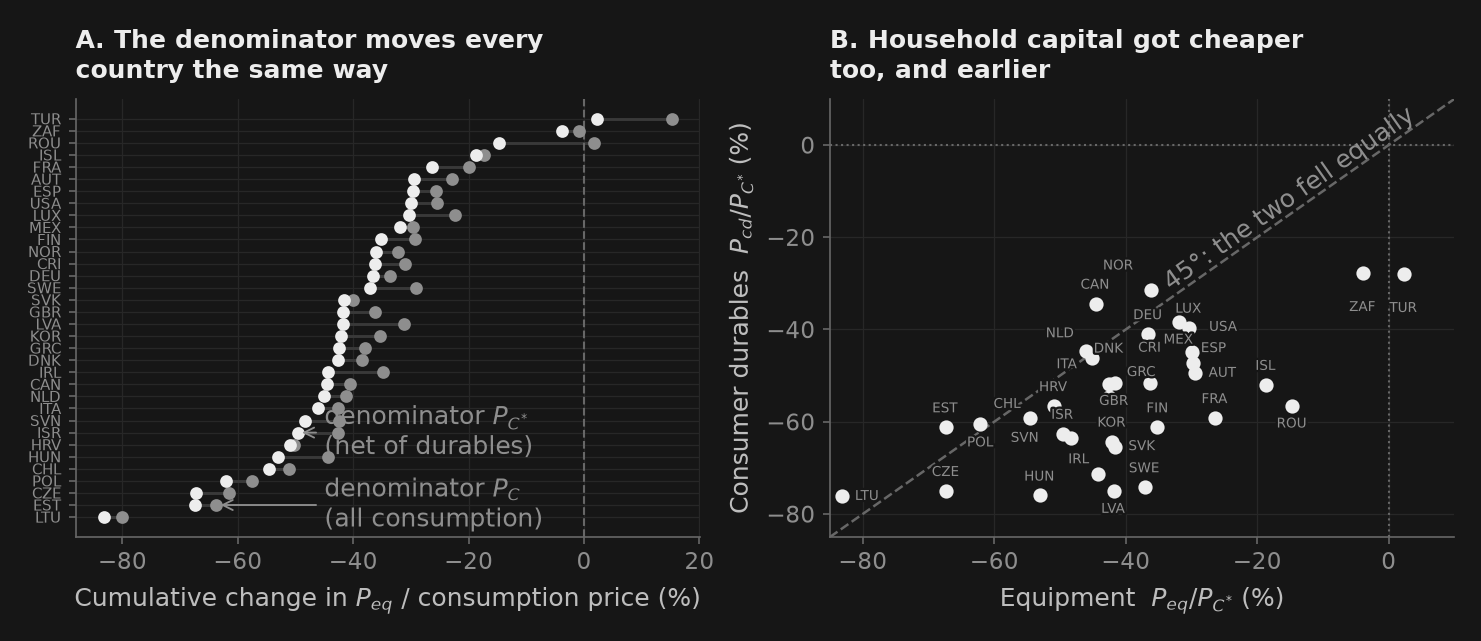

In [27]:
from matplotlib.patheffects import withStroke
from matplotlib.transforms import Bbox


def annotate_codes(ax, xs, ys, codes, *, fontsize=6.5, step=3.5):
    """Each code, next to its point, in the least obstructive of the sixteen
    positions around the marker: with the same offset for all of them they
    overprint each other as soon as the cloud tightens. The clouds in §2.4,
    §4.3 and §5.1 call it again."""
    fig = ax.figure
    fig.canvas.draw()                    # positions and transforms are final now
    ren = fig.canvas.get_renderer()
    frame = ax.patch.get_window_extent()
    pts = [ax.transData.transform((float(u), float(v))) for u, v in zip(xs, ys)]
    # The markers themselves and the labels already written take up room;
    # covering text costs three times covering a point, and leaving the axes,
    # far more.
    taken = [Bbox.from_bounds(px - 6, py - 6, 12, 12) for px, py in pts]
    taken += [t.get_window_extent(ren) for t in ax.texts]
    n_pts = len(pts)
    rounds = [(f, dx * f, dy * f, ha, va) for f in (1.0, 2.4)
              for dx, dy, ha, va in ((step, step, "left", "bottom"),
                                     (-step, step, "right", "bottom"),
                                     (step, -step, "left", "top"),
                                     (-step, -step, "right", "top"),
                                     (0, 1.6 * step, "center", "bottom"),
                                     (0, -1.6 * step, "center", "top"),
                                     (1.8 * step, 0, "left", "center"),
                                     (-1.8 * step, 0, "right", "center"))]
    placed = []
    for (u, v), lab in zip(zip(xs, ys), codes):
        best = box = score = None
        for f, dx, dy, ha, va in rounds:
            t = ax.annotate(str(lab), xy=(float(u), float(v)), xytext=(dx, dy),
                            textcoords="offset points", ha=ha, va=va,
                            fontsize=fontsize, color=_nbstyle.NOTA,
                            path_effects=[withStroke(linewidth=2.2,
                                                     foreground=_nbstyle.FONDO)])
            bb = t.get_window_extent(ren).expanded(1.35, 1.6)
            inside = (frame.containsx(bb.x0) and frame.containsx(bb.x1)
                      and frame.containsy(bb.y0) and frame.containsy(bb.y1))
            p = (0.0 if inside else 2000.0) + 30.0 * (f - 1.0)
            for j, box_j in enumerate(taken):
                cut = Bbox.intersection(bb, box_j)
                if cut is not None:
                    p += (1.0 if j < n_pts else 3.0) * cut.width * cut.height
            if score is None or p < score:
                if best is not None:
                    best.remove()
                best, box, score = t, bb, p
            else:
                t.remove()
            if score == 0.0:
                break
        taken.append(box)
        placed.append(best)
    return placed


fig, (axL, axR) = _nbstyle.figura(1, 2)

d = eq.sort_values("P_eq/P_C*")
y = np.arange(len(d))
axL.hlines(y, d["P_eq/P_C"], d["P_eq/P_C*"], color=_nbstyle.gris("0.75"), lw=1.4, zorder=1)
axL.scatter(d["P_eq/P_C"], y, s=26, color=_nbstyle.NOTA, zorder=3)
axL.scatter(d["P_eq/P_C*"], y, s=26, color=_nbstyle.TINTA, zorder=3)
axL.axvline(0, color=_nbstyle.SPINE, ls="--", lw=1.0)
axL.set_yticks(y); axL.set_yticklabels(d.index, fontsize=7)
axL.set_xlabel("Cumulative change in $P_{eq}$ / consumption price (%)")
axL.set_title("A. The denominator moves every\n"
              "country the same way")
# The two markers are named on two bottom rows, where there is room to the
# right: the text starts mid-scale and the leader goes back to its marker.
for row, col_, text in ((1, "P_eq/P_C", "denominator $P_C$\n(all consumption)"),
                        (7, "P_eq/P_C*", "denominator $P_{C^{*}}$\n(net of durables)")):
    axL.annotate(text, xy=(float(d[col_].iloc[row]), row), xytext=(-45.0, row),
                 textcoords="data", ha="left", va="center", color=_nbstyle.NOTA,
                 arrowprops=_nbstyle.FLECHA)

axR.scatter(b["P_eq/P_C*"], b["P_cd/P_C*"], s=34, color=_nbstyle.TINTA, zorder=3)
lim = [min(b.min().min(), -85), 10]
axR.plot(lim, lim, color=_nbstyle.SPINE, ls="--", lw=1.2)
axR.axhline(0, color=_nbstyle.SPINE, ls=":", lw=1.0); axR.axvline(0, color=_nbstyle.SPINE, ls=":", lw=1.0)
axR.set_xlim(lim); axR.set_ylim(lim)
axR.annotate("45°: the two fell equally", xy=(-14, -14), rotation=45, transform_rotates_text=True,
             rotation_mode="anchor", ha="center", va="bottom", color=_nbstyle.NOTA)
axR.set_xlabel("Equipment  $P_{eq}/P_{C^{*}}$ (%)")
axR.set_ylabel("Consumer durables  $P_{cd}/P_{C^{*}}$ (%)")
axR.set_title("B. Household capital got cheaper\n"
              "too, and earlier")
# The codes last: the panel is already at its final size when room is found
# for each one.
annotate_codes(axR, b["P_eq/P_C*"], b["P_cd/P_C*"], b.index)

plt.show()


**What the two panels are worth.** Panel A is a measurement result: the direction is not an empirical finding but arithmetic — durables are inside $P_C$ and their price falls, so removing them can only make the numerator's fall look larger — and what the data supply is the *size*: a median 4.6 pp per country, up to 16 pp in Romania, moving the panel median from $-35\%$ to $-42\%$. It is not a rounding error and it is not the headline either; the honest summary is that the GHK fact is robust to the choice of denominator and mildly understated by the usual one.

Panel B is an economic result, and it is the one to keep. Nothing forces the price of washing machines to track the price of machine tools: they are different goods, sold in different markets, to different buyers. They track anyway — and the goods households buy as capital got cheaper *faster* than the goods firms buy as capital in most of the panel. Investment-specific technical change, in other words, is not a fact about the corporate sector; it reaches the household's own capital stock, which is exactly the reading under which §2.4's reclassification stops being an accounting convention and becomes a statement about technology. The one caution is composition: `cons_dur` is a COICOP bucket whose contents (cars, furniture, electronics) differ across countries and drift within them, so the cross-country *ranking* in panel B is softer than the common sign.

### 2.3 A caveat before going on: exchange-rate contamination

The objects we just built react very differently to the nominal exchange rate $E$ (national currency per US dollar). Separating them is worth doing *before* any of them is used as evidence.

**The shares of §2.1 are immune.** They divide one current-price aggregate by another *in the same national currency*, so no conversion ever happens: Mexico's $C/Y$ is the same number whether the peso trades at 10 or at 20 per dollar. That immunity is the main reason to hold the panel in nominal local currency instead of converting it to a common currency first — a common-currency panel would have every country's series moving with its own bilateral rate.

**The relative prices of §2.2 are not.** An import deflator in local currency is, to a first approximation, a world price times the exchange rate, $P_M \approx E \cdot P_M^{*}$. Three consequences, and we measure all three:
1. **Pass-through.** $\Delta \log P_M$ co-moves with $\Delta \log E$, mechanically, with no economics being measured.
2. **The terms of trade largely survives it.** $P_X/P_M \approx (E P_X^{*}) / (E P_M^{*}) = P_X^{*}/P_M^{*}$ — a common $E$ cancels in the ratio. What correlation remains is not contamination but causation running the other way: for a copper or oil exporter, a commodity boom improves the terms of trade *and* appreciates the currency.
3. **The relative price of investment does not survive it — and §2.2's asset split turns that claim into a test.** If the channel is import content, the exchange rate must load on **equipment** (manufactured, imported) and *not* on **structures** (poured on site) — same country, same quarter, same consumption deflator in the denominator. That is a placebo, and it either works or it does not.

**Open-Economy Link: Terms-of-Trade Collapses and Sudden Stops.**  
In emerging open economies, movements in relative prices and the exchange rate are not merely statistical noise — they are central to macroeconomic crises. When an emerging economy experiences an adverse terms-of-trade shock or an external credit freeze (a *Sudden Stop*, Calvo 1998; Mendoza 2010), the nominal exchange rate depreciates sharply. Because capital equipment is overwhelmingly imported ($P_I \approx E \cdot P_I^*$), this depreciation drives up the domestic price of investment relative to consumption goods ($P_I/P_C$). Domestic firms face a collapse in their borrowing capacity just as the replacement cost of capital surges. Compounded by foreign-currency denominated debt ("original sin"), this balance-sheet channel forces a catastrophic compression in domestic absorption and investment that far exceeds the predictions of standard closed-economy business cycle models.

**Mind the extrapolation.** These are quarterly comovements. The short-run coefficient does not integrate up to a level decomposition: applied to Turkey's cumulative $+652$ log-point depreciation it would "explain" $+100$ pp of a relative price that actually moved $+15$ pp. Real exchange rates mean-revert; nominal pass-through coefficients do not.


In [28]:
from puremacro.fetch import fetch_xrate_monthly

fx = fetch_xrate_monthly(COUNTRIES, start_period="1995") if VIVO else pd.DataFrame()
if fx.empty and readable(DATA / "oecd_fx_lcu_usd_q.csv", "file"):
    print("Exchange rates: frozen course snapshot."
          if not VIVO else
          "No live exchange rates — using the frozen course snapshot.")
    e_q = (pd.read_csv(DATA / "oecd_fx_lcu_usd_q.csv", parse_dates=["date"])
             .set_index(["code", "date"])["e"])
else:
    fx["date"] = pd.to_datetime(fx["date"]).dt.to_period("Q").dt.to_timestamp(how="start")
    e_q = fx.groupby(["code", "date"])["value"].mean().rename("e")

# Which countries share a currency (or peg to one)? Rather than maintain a
# euro-area list by hand — membership changed seven times over this sample —
# read it off the data: a country whose dollar rate moves one-for-one with
# Germany's is not floating against the dollar on its own account. This picks
# up the euro area *and* Denmark's krone peg, and correctly leaves the late
# joiners (Slovakia, the Baltics) on the floating side for a sample in which
# they mostly had their own money.
_eur = np.log(e_q.loc["DEU"]).diff()


def moves_with_the_euro(code, threshold=0.95):
    d = pd.concat([np.log(e_q.loc[code]).diff().rename("x"),
                   _eur.rename("r")], axis=1, join="inner", sort=True).dropna()
    return len(d) >= 40 and d["x"].corr(d["r"]) > threshold


def corr_with_fx(d, num, den="pc"):
    """corr(D log(num/den), D log E) on the common non-missing sample."""
    sub = d[["e", num, den]].dropna()
    return (sub[num] - sub[den]).corr(sub["e"]) if len(sub) >= 40 else np.nan


from puremacro.regress import ols, add_constant


rows, pegged_hard = [], []
for c in sorted(set(e_q.index.get_level_values("code"))
                & set(panel.index.get_level_values("code"))):
    g = panel.loc[c]
    d = pd.DataFrame({
        "e":  np.log(e_q.loc[c]),
        "pm": np.log(g["imports_defl"]),
        "px": np.log(g["exports_defl"]),
        "pc": np.log(g["cons_hh_defl"]),
        "pi": np.log(g["inv_defl"]),
        "pe": np.log(g["inv_equip_defl"]),
        "ps": np.log(g["inv_struct_defl"]),
    }).diff()
    base = d[["e", "pm"]].dropna()
    if len(base) < 40:
        continue
    if 100 * base["e"].std() < 0.5:
        # A hard peg (Saudi Arabia) has no exchange-rate variation to regress
        # on: the correlation is noise and the slope divides by ~zero.
        pegged_hard.append(c)
        continue
    rows.append({
        "code": c, "n": len(base), "sd(dE)%": 100 * base["e"].std(),
        "corr(dPm,dE)":     base["pm"].corr(base["e"]),
        "beta(dPm,dE)":     float(ols(base["pm"], add_constant(base["e"]), cov_type="HC1").params.iloc[1]),
        "corr(dToT,dE)":    corr_with_fx(d, "px", "pm"),
        "corr(dPi/Pc,dE)":  corr_with_fx(d, "pi"),
        "corr(dPeq/Pc,dE)": corr_with_fx(d, "pe"),
        "corr(dPst/Pc,dE)": corr_with_fx(d, "ps"),
        "euro": moves_with_the_euro(c),
    })
fxc = pd.DataFrame(rows).set_index("code").sort_values("corr(dPeq/Pc,dE)", ascending=False)
print("Quarterly log changes against the nominal exchange rate (LCU per USD):")
print(fxc.drop(columns="euro").round(2).to_string())
if pegged_hard:
    print(f"\nDropped for having no exchange rate to speak of (hard dollar peg): "
          f"{', '.join(pegged_hard)}")

placebo = fxc.dropna(subset=["corr(dPeq/Pc,dE)", "corr(dPst/Pc,dE)"])
own = fxc[~fxc["euro"]]
print(f"\nPass-through into P_M, median correlation with dE — own currency: "
      f"{own['corr(dPm,dE)'].median():+.2f} ({len(own)} countries) | euro or pegged "
      f"to it: {fxc[fxc['euro']]['corr(dPm,dE)'].median():+.2f} "
      f"({int(fxc['euro'].sum())}). The second figure is low because the dollar "
      f"rate is not the rate most of their trade is priced in.")
print(f"Terms of trade: {fxc['corr(dToT,dE)'].median():+.2f} (median over all "
      f"{len(fxc)}) — the exchange rate cancels in the ratio.")
print(f"Placebo ({len(placebo)} countries) — equipment: "
      f"{placebo['corr(dPeq/Pc,dE)'].median():+.2f} | structures: "
      f"{placebo['corr(dPst/Pc,dE)'].median():+.2f} | total GFCF: "
      f"{placebo['corr(dPi/Pc,dE)'].median():+.2f}")
print(f"Equipment loads more than structures in "
      f"{(placebo['corr(dPeq/Pc,dE)'] > placebo['corr(dPst/Pc,dE)']).sum()} of {len(placebo)} countries.")

# 1. The exchange rate passes into import prices wherever it is the country's
#    own currency that is moving.
assert own["corr(dPm,dE)"].median() > 0.4
# 2. It broadly cancels in the terms of trade, a ratio of two local-currency deflators.
assert abs(fxc["corr(dToT,dE)"].median()) < 0.25
# 3. The placebo holds: it loads on the traded capital good, not the non-traded one.
assert placebo["corr(dPeq/Pc,dE)"].median() > placebo["corr(dPst/Pc,dE)"].median() + 0.15
assert (placebo["corr(dPeq/Pc,dE)"] > placebo["corr(dPst/Pc,dE)"]).mean() > 0.8

Exchange rates: frozen course snapshot.


Quarterly log changes against the nominal exchange rate (LCU per USD):
        n  sd(dE)%  corr(dPm,dE)  beta(dPm,dE)  corr(dToT,dE)  corr(dPi/Pc,dE)  corr(dPeq/Pc,dE)  corr(dPst/Pc,dE)
code                                                                                                              
CAN   124     3.13          0.76          0.46          -0.58             0.46              0.86             -0.16
CHL   121     4.67          0.76          0.73          -0.42             0.55              0.78             -0.13
MEX   124     4.64          0.83          0.66          -0.67             0.54              0.77             -0.08
KOR   124     5.54          0.73          0.74          -0.07             0.46              0.67               NaN
AUS   124     4.77          0.81          0.46          -0.12             0.32              0.62              0.01
CRI   125     2.42          0.51          0.85           0.00             0.26              0.62              0.05
TUR   124


Exchange Rate Pass-through OLS (HC1) for MEX:
OLS regression (HC1, z inference)
  n = 124, df_resid = 122, R^2 = 0.6910, adj R^2 = 0.6884
  llf = 306.1123, AIC = -608.2246, BIC = -602.5841
                coef     std err        z    P>|t|      [0.025      0.975]
const         0.0076      0.0019    4.011    0.000      0.0039      0.0114
e             0.6628      0.0358   18.516    0.000      0.5927      0.7330

Exchange Rate Pass-through OLS (HC1) for DEU:
OLS regression (HC1, z inference)
  n = 124, df_resid = 122, R^2 = 0.0641, adj R^2 = 0.0564
  llf = 349.8211, AIC = -695.6421, BIC = -690.0015
                coef     std err        z    P>|t|      [0.025      0.975]
const         0.0023      0.0013    1.764    0.078     -0.0003      0.0048
e             0.0982      0.0437    2.250    0.024      0.0126      0.1838


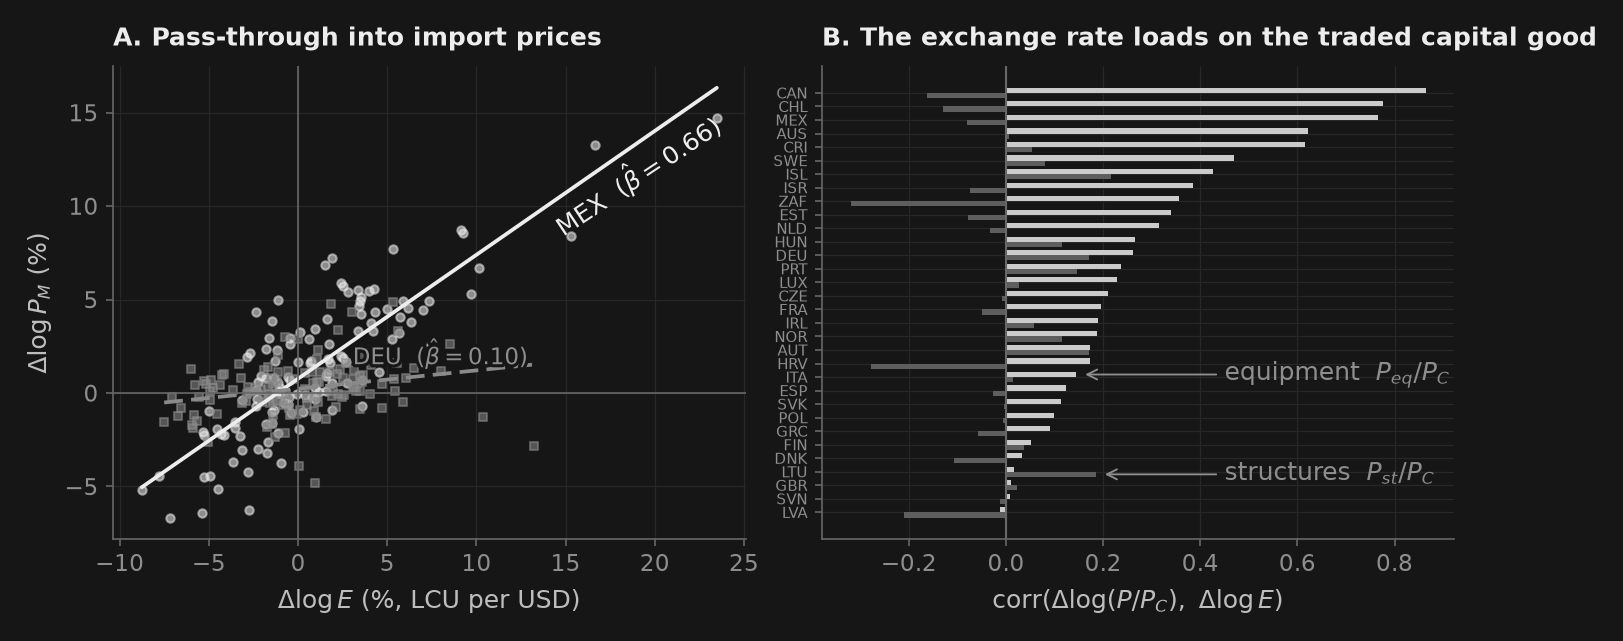

In [29]:
fig, (ax1, ax2) = _nbstyle.figura(1, 2)

# Panel A: pass-through into import prices, a floater vs a euro member
lines, slopes = [], {}
for k, c in enumerate(("MEX", "DEU")):
    g = panel.loc[c]
    d = pd.DataFrame({"e": np.log(e_q.loc[c]),
                      "pm": np.log(g["imports_defl"])}).dropna().diff().dropna()
    res_fx = ols(d["pm"], add_constant(d["e"]), cov_type="HC1")
    print(f"\nExchange Rate Pass-through OLS (HC1) for {c}:")
    print(res_fx.summary())
    a, b = float(res_fx.params.iloc[0]), float(res_fx.params.iloc[1])
    ax1.scatter(100 * d["e"], 100 * d["pm"], s=16, alpha=0.55, color=cols[k * 3],
                marker=("o", "s")[k])
    gx = np.linspace(100 * d["e"].min(), 100 * d["e"].max(), 50)
    lines += ax1.plot(gx, 100 * a + b * gx, color=cols[k * 3], lw=1.8, ls=lss[k],
                      label=f"{c}  ($\\hat\\beta = {b:.2f}$)")
    slopes[c] = b
ax1.axhline(0, color=_nbstyle.SPINE, lw=0.8); ax1.axvline(0, color=_nbstyle.SPINE, lw=0.8)
ax1.set_xlabel("$\\Delta \\log E$ (%, LCU per USD)")
ax1.set_ylabel("$\\Delta \\log P_M$ (%)")
ax1.set_title("A. Pass-through into import prices")

# Panel B: the placebo — traded capital good vs non-traded one
order = placebo.sort_values("corr(dPeq/Pc,dE)")
y = np.arange(len(order))
h = 0.38
EQ, ST = "corr(dPeq/Pc,dE)", "corr(dPst/Pc,dE)"
ax2.barh(y + h / 2, order[EQ], height=h, color=_nbstyle.BARRA_COLORES[0])
ax2.barh(y - h / 2, order[ST], height=h, color=_nbstyle.BARRA_COLORES[2])
ax2.set_yticks(y)
ax2.set_yticklabels(order.index, fontsize=7)
ax2.axvline(0, color=_nbstyle.SPINE, lw=1.0)
ax2.set_xlabel("$\\mathrm{corr}(\\Delta \\log (P/P_C),\\ \\Delta \\log E)$")
ax2.set_title("B. The exchange rate loads on the traded capital good")
# Each bar is named with a leader from a low row, where nothing long sits to
# the right: the longest structures bar and the longest equipment bar that
# still leaves room.
r_st = order.index.get_loc(order[ST].where(order[EQ] < 0.3).idxmax())
r_eq = order.index.get_loc(order[EQ].where(order[EQ] < 0.15).idxmax())
x_txt = 0.45
ax2.annotate("equipment  $P_{eq}/P_C$", xy=(float(order[EQ].iloc[r_eq]) + 0.01, r_eq + h / 2),
             xytext=(x_txt, r_eq + h / 2), textcoords="data", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax2.annotate("structures  $P_{st}/P_C$", xy=(float(order[ST].iloc[r_st]) + 0.01, r_st - h / 2),
             xytext=(x_txt, r_st - h / 2), textcoords="data", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

# The MEX line carries its name below it and turned like it, along the stretch
# where the cloud has ended: at the end of the line the label ran off the axes
# and floated in the corridor between the two panels. The DEU line, nearly
# flat, carries its name above its middle stretch.
x_mex = 18.5
ax1.annotate(lines[0].get_label(),
             xy=(x_mex, float(np.interp(x_mex, lines[0].get_xdata(), lines[0].get_ydata()))),
             xytext=(0, -5), textcoords="offset points",
             rotation=np.degrees(np.arctan(slopes["MEX"])), transform_rotates_text=True,
             rotation_mode="anchor", ha="center", va="top", color=cols[0])
_nbstyle.etiquetar(ax1, artistas=lines[1:], donde=8.0)
plt.show()


### 2.4 Consumer Durables: Consumption or Investment?

In the System of National Accounts, a household's purchase of a car, a sofa or a washing machine is booked entirely as **consumption ($C$)** in the quarter it happens.

Neoclassical theory (Cooley & Prescott 1995; Gomme & Rupert 2007) says that is the wrong home for it. A durable is a **household capital good ($K_d$)** bought once and consumed over years: the purchase is lumpy, postponable, credit-financed and forward-looking — an investment decision wearing a consumption label. So business-cycle work routinely re-cuts the accounts as
$$ C^{*} = C - C_d \quad(\text{non-durables} + \text{services}), \qquad I^{*} = I_{\text{fixed}} + C_d .$$

§2.2 has already put one piece of evidence on the table, on the price side: $P_{cd}/P_{C^{*}}$ fell in all 37 countries and by more than business equipment in 28 of 34, so durables are not merely *analogous* to capital, they are getting cheaper the way capital goods do. What follows is the quantity side of the same claim — and it is the one that moves the stylized facts.

The same panel answers this, because `qna_panel(..., durability=True)` pulls household consumption split by durability from the OECD's `DF_QNA_EXPENDITURE_DURABILITY` flow — durable, semi-durable, non-durable, services, each with its own deflator. §2.2 has already used three of those four lines, to build $C^{*}$ for the denominator of its relative prices.

Four things to keep straight, all visible in the code below:
- The split is published for institutional sector **`S14`** (households) while the headline `cons_hh` is **`S1M`** (households + NPISH), so the components sum to 95-106% of it. We therefore build the consumption total *from the components*, so numerator and denominator share a sector.
- The **United States and Chile publish no semi-durable category** (their classification has three buckets, not four); the code sums whatever exists.
- A few countries publish the split **unadjusted** even though their aggregates are seasonally adjusted. Rather than trust a country-level flag, we test each series (`residual_seasonality_F`) and only STL-adjust the ones that fail — an unadjusted series would inflate every volatility below.
- **What it gets compared against.** The question is whether the household durable moves like a capital good, and the capital good to compare it with is **equipment** — machinery, transport, ICT — not total GFCF. Total GFCF is roughly half dwellings and civil works: assets poured on site, taking quarters to erect and adjusting slowly, so the aggregate averages the right comparator with one that is not, and comes out artificially smooth. It is exactly the asset split §2.2 used on the price side (`inv_equip` against `inv_struct`), now on the quantity side, and it compares two objects of the same size and the same nature. The price is coverage: not every economy that publishes durability publishes GFCF by asset, and panel B names the ones that are missing.

In [30]:
from puremacro.sa import deseasonalize_x13, residual_seasonality_F

DURABILITY = ["cons_dur", "cons_semidur", "cons_nondur", "cons_serv"]
SAMPLE = ("1995", "2019-10-01")   # pre-COVID: 2020 alone would dominate every HP moment


def real(g, col):
    """Volume implied by the panel: 100 x current prices / implicit deflator."""
    if col not in g or g[col].isna().all():
        return None
    s = (100.0 * g[col] / g[col + "_defl"]).dropna()
    return s if len(s) else None


def deseasonalize_if_needed(s):
    """Adjust only a series that still fails an F-test for seasonality.

    `qna_panel(sa="x13")` already adjusted what the OECD published raw; this is
    the belt-and-braces check on the result, and on anything the source left
    seasonal. Same engine ladder — X-13 binary, else pure-Python X-11.
    """
    if s is None or len(s) < 24:
        return s, False
    _, pval, _, _ = residual_seasonality_F(np.log(s), freq="Q")
    if pval >= 0.01:
        return s, False
    d = pd.DataFrame({"date": s.index, "v": np.log(s.values), "grp": "x"})
    adj = deseasonalize_x13(d, "v", by="grp", date_col="date", freq="Q")
    return pd.Series(np.exp(adj.values), index=s.index, name=s.name), True


rows = []
for c in sorted(panel.index.get_level_values("code").unique()):
    g = panel.loc[c].loc[SAMPLE[0]:SAMPLE[1]]
    comps, stl = {}, False
    for k in DURABILITY:
        s, did = deseasonalize_if_needed(real(g, k))
        if s is not None:
            comps[k], stl = s, stl or did
    # Bulgaria and Portugal publish the durables line and nothing else, so
    # C* = C - C_d would be identically zero for them.
    if "cons_dur" not in comps or len(comps) < 2:
        continue
    # Chain-linked volumes are not exactly additive; the residual is well under
    # a percent here and does not move second moments.
    C = pd.concat([v.rename(k) for k, v in comps.items()], axis=1, sort=True).dropna()
    # Business equipment gets exactly the same treatment as the four durability
    # lines — F-test and, if it fails, X-13 — because it is the asset the
    # household durable is being compared against and it cannot arrive on a
    # different basis.
    i_eq, did_eq = deseasonalize_if_needed(real(g, "inv_equip"))
    stl = stl or did_eq
    df = pd.concat([real(g, "gdp").rename("y"), real(g, "inv").rename("i"),
                    C.sum(axis=1).rename("c_tot"), C["cons_dur"].rename("c_dur")],
                   axis=1, sort=True).dropna()
    if len(df) < 48:
        continue
    df["c_nd"] = df["c_tot"] - df["c_dur"]      # C* = C - C_d
    df["i_adj"] = df["i"] + df["c_dur"]         # I* = I_fixed + C_d
    cyc = {k: hp_filter(100.0 * np.log(df[k]))[0]
           for k in ("y", "i", "c_tot", "c_dur", "c_nd", "i_adj")}
    sy = np.std(cyc["y"], ddof=1)
    nom = g[list(comps)].dropna()
    row = {
        "code": c, "from": df.index.min().year, "n": len(df), "STL": stl,
        "sig_c/sig_y":    np.std(cyc["c_tot"], ddof=1) / sy,
        "sig_c*/sig_y":   np.std(cyc["c_nd"], ddof=1) / sy,
        "sig_cd/sig_y":   np.std(cyc["c_dur"], ddof=1) / sy,
        "sig_i/sig_y":    np.std(cyc["i"], ddof=1) / sy,
        "sig_i*/sig_y":   np.std(cyc["i_adj"], ddof=1) / sy,
        "C_d/C (%)": float((g["cons_dur"] / nom.sum(axis=1)).mean() * 100),
    }
    # Equipment has its own sample: not everyone who publishes durability
    # publishes GFCF by asset, and where they do it may start in a different
    # quarter. Its ratio is computed over the quarters where equipment AND
    # output both exist, so the denominator covers the same period as the
    # numerator.
    if i_eq is not None:
        eq_df = pd.concat([df["y"], i_eq.rename("i_eq")], axis=1, sort=True).dropna()
        if len(eq_df) >= 48:
            c_eq, _ = hp_filter(100.0 * np.log(eq_df["i_eq"]))
            c_ye, _ = hp_filter(100.0 * np.log(eq_df["y"]))
            row["sig_ieq/sig_y"] = (np.std(c_eq, ddof=1)
                                    / np.std(c_ye, ddof=1))
            row["n_eq"] = len(eq_df)
    rows.append(row)
dur = pd.DataFrame(rows).set_index("code").sort_values("sig_c/sig_y", ascending=False)
print(f"Durables as consumption vs as investment, HP-filtered, {SAMPLE[0]}-2019, "
      f"{len(dur)} countries:")
print(dur.round(2).to_string())

med = dur[["sig_c/sig_y", "sig_c*/sig_y", "sig_cd/sig_y", "sig_i/sig_y",
           "sig_i*/sig_y", "sig_ieq/sig_y"]].median()
print(f"\nMedians — consumption {med['sig_c/sig_y']:.2f} falls to {med['sig_c*/sig_y']:.2f} "
      f"once durables leave it; durables themselves run {med['sig_cd/sig_y']:.2f}, "
      f"as volatile as fixed investment ({med['sig_i/sig_y']:.2f}).")
# Total GFCF is the wrong comparator and its median says so: half of it is
# dwellings and structures, which move slowly, so the aggregate averages the
# comparable asset with one that is not. Equipment — machinery, transport and
# ICT, the same tradable asset as §2.2 — is what a household durable is the
# analogue of, and it runs nearly 60% above total GFCF.
eq = dur.dropna(subset=["sig_ieq/sig_y"])
print(f"The comparator that matters is not GFCF but EQUIPMENT, the asset the "
      f"household durable is the\nanalogue of: median "
      f"{eq['sig_ieq/sig_y'].median():.2f} against "
      f"{eq['sig_i/sig_y'].median():.2f} for total GFCF, across the {len(eq)} "
      f"economies publishing the\nasset split (missing "
      f"{', '.join(sorted(set(dur.index) - set(eq.index)))}). On that scale the "
      f"durable sits at {eq['sig_cd/sig_y'].median():.2f}: "
      f"{eq['sig_cd/sig_y'].median() / eq['sig_ieq/sig_y'].median():.2f} times "
      f"equipment\nand {eq['sig_cd/sig_y'].median() / eq['sig_c*/sig_y'].median():.1f} "
      f"times the consumption it is taken out of. Much closer to capital than "
      f"to consumption, and\nbelow equipment in "
      f"{int((eq['sig_cd/sig_y'] < eq['sig_ieq/sig_y']).sum())} of {len(eq)} "
      f"countries.")
crossers = dur[(dur["sig_c/sig_y"] > 1.0) & (dur["sig_c*/sig_y"] < 1.0)]
print(f"Countries whose σ(c)/σ(y) crosses below 1.0 on reclassification: "
      f"{', '.join(crossers.index) if len(crossers) else 'none'}")
risers = dur[dur["sig_c*/sig_y"] > dur["sig_c/sig_y"]]
print(f"Countries where it goes the other way: {', '.join(risers.index)} "
      f"(see exercise 15).")

# Durables move like capital, not like consumption...
assert (dur["sig_cd/sig_y"] > 1.5).mean() > 0.9
# ...so taking them out of C lowers measured consumption volatility almost everywhere.
assert (dur["sig_c*/sig_y"] < dur["sig_c/sig_y"]).mean() > 0.85
assert med["sig_cd/sig_y"] > med["sig_i/sig_y"] * 0.8
# Equipment is the volatile asset total GFCF dilutes, and the durable stays
# below it: the analogy with capital is one of order of magnitude, not identity.
assert med["sig_ieq/sig_y"] > med["sig_i/sig_y"]
assert len(eq) >= 25

Durables as consumption vs as investment, HP-filtered, 1995-2019, 35 countries:
      from    n    STL  sig_c/sig_y  sig_c*/sig_y  sig_cd/sig_y  sig_i/sig_y  sig_i*/sig_y  C_d/C (%)  sig_ieq/sig_y   n_eq
code                                                                                                                       
HRV   1995  100  False         1.81          1.85          2.44         3.47          3.15       6.36           6.46  100.0
ROU   1995  100  False         1.55          1.56          1.91         3.94          3.65       5.64           3.95  100.0
KOR   1995  100   True         1.28          1.16          4.63         2.48          2.54       9.70           5.43  100.0
CHL   1996   96  False         1.20          0.95          5.55         3.30          3.43       8.69           6.05   96.0
NZL   1995  100  False         1.15          1.09          2.53         4.85          4.00      17.20            NaN    NaN
ESP   1995  100  False         1.15          1.04   

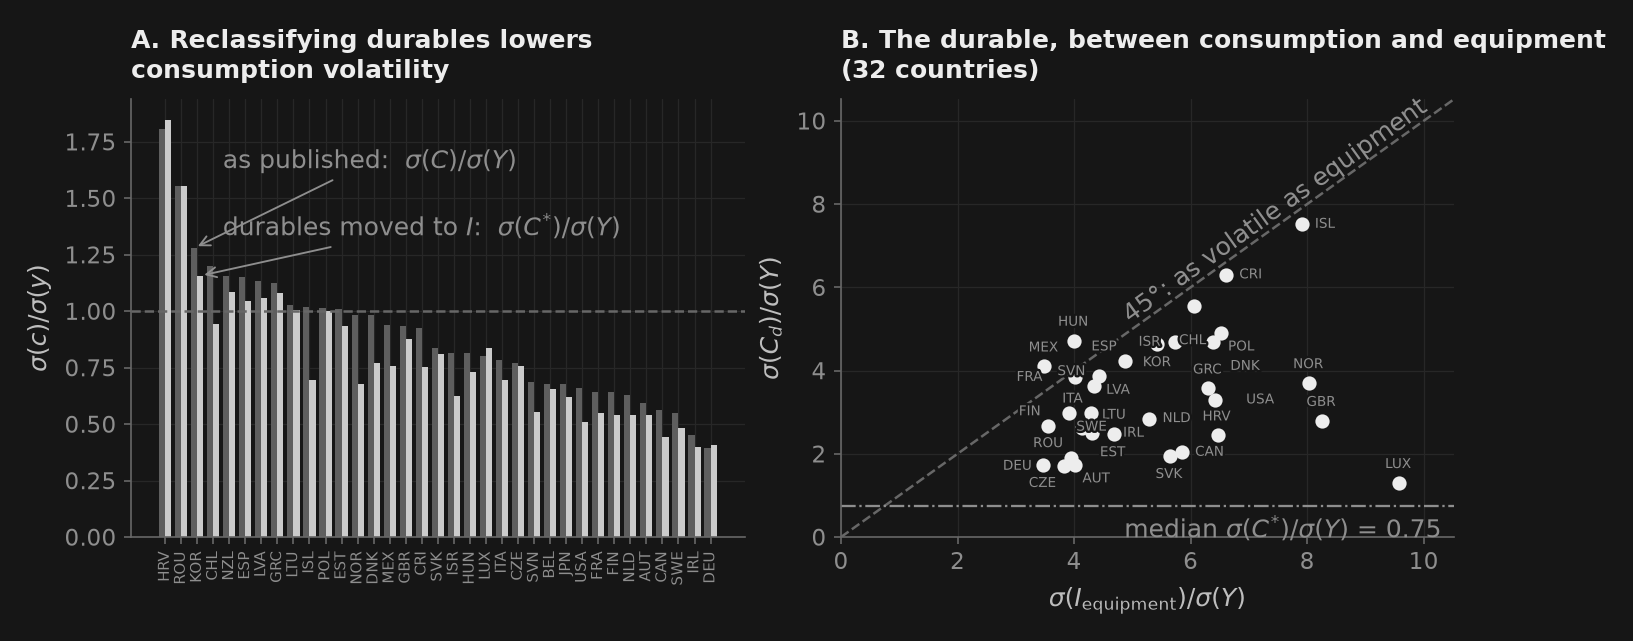

In [31]:
fig, (ax1, ax2) = _nbstyle.figura(1, 2)

x = np.arange(len(dur))
w = 0.38
ax1.bar(x - w / 2, dur["sig_c/sig_y"], w, color=_nbstyle.BARRA_COLORES[2])
ax1.bar(x + w / 2, dur["sig_c*/sig_y"], w, color=_nbstyle.BARRA_COLORES[0])
ax1.axhline(1.0, color=_nbstyle.SPINE, ls="--", lw=1.2)
ax1.set_xticks(x); ax1.set_xticklabels(dur.index, rotation=90, fontsize=7)
ax1.set_ylabel("$\\sigma(c)/\\sigma(y)$")
ax1.set_title("A. Reclassifying durables lowers\n"
              "consumption volatility")
# The two bars are named over the third country; to the right the bars are
# lower and the names fit above them.
i0, top = 2, float(dur["sig_c/sig_y"].max())
ax1.annotate("as published:  $\\sigma(C)/\\sigma(Y)$",
             xy=(i0 - w / 2, float(dur["sig_c/sig_y"].iloc[i0])),
             xytext=(i0 + 1.6, 0.92 * top), textcoords="data", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax1.annotate("durables moved to $I$:  $\\sigma(C^{*})/\\sigma(Y)$",
             xy=(i0 + w / 2, float(dur["sig_c*/sig_y"].iloc[i0])),
             xytext=(i0 + 1.6, 0.76 * top), textcoords="data", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

# The horizontal axis is EQUIPMENT, not total GFCF: comparing the household's
# capital good against an aggregate that is half dwellings and civil works
# mostly measures the composition of the denominator. `eq` is the sub-sample
# with the asset split, which the previous cell named.
ax2.scatter(eq["sig_ieq/sig_y"], eq["sig_cd/sig_y"], s=34, color=_nbstyle.TINTA, zorder=3)
lim = [0, max(eq["sig_ieq/sig_y"].max(), eq["sig_cd/sig_y"].max()) * 1.1]
ax2.plot(lim, lim, color=_nbstyle.SPINE, ls="--", lw=1.2)
median = float(eq["sig_c*/sig_y"].median())
ax2.axhline(median, color=_nbstyle.NOTA, ls="-.", lw=1.1)
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.annotate("45°: as volatile as equipment", xy=(0.72 * lim[1], 0.72 * lim[1]),
             rotation=45, transform_rotates_text=True, rotation_mode="anchor",
             ha="center", va="bottom", color=_nbstyle.NOTA)
ax2.annotate(f"median $\\sigma(C^{{*}})/\\sigma(Y)$ = {median:.2f}",
             xy=(0.98 * lim[1], median), xytext=(0, -4), textcoords="offset points",
             ha="right", va="top", color=_nbstyle.NOTA)
ax2.set_xlabel("$\\sigma(I_{\\mathrm{equipment}})/\\sigma(Y)$")
ax2.set_ylabel("$\\sigma(C_d)/\\sigma(Y)$")
ax2.set_title(f"B. The durable, between consumption and equipment\n({len(eq)} countries)")
# The codes last, placed the way §2.2 places them: in the central cluster they
# were overprinting each other.
annotate_codes(ax2, eq["sig_ieq/sig_y"], eq["sig_cd/sig_y"], eq.index)

plt.show()


## 3. Capital-Output Ratio ($K/Y$) and Labor Share

One of the "Kaldor Facts" (1957) states that the **capital-output ratio ($K/Y$)** and the **labor share** of national income remain relatively constant over time.

With the course's Cobb–Douglas technology, $Y_t = A_t K_{t-1}^{\alpha} L_t^{1-\alpha}$, the **capital** share is $\alpha$ and the **labor** share is $1-\alpha$.
Typically across advanced economies:
- $K/Y \approx 3$ (in annual terms)
- Labor Share $1-\alpha \approx 0.60 - 0.65$ (equivalently $\alpha \approx 0.35 - 0.40$)

The two facts are checked in very different ways. The first needs a capital stock, which quarterly accounts do not publish and which has to be fetched from outside. The second can be computed from what is already in the panel — and that is exactly why it deserves a close look, because the number the obvious formula produces **is not** the production-function parameter.

### 3.1 The capital stock: what EU-KLEMS can give

`puremacro` includes specific modules like `puremacro.klems` and `puremacro.labor_share` to study these dynamics in depth.

> **Measurement note.** EU-KLEMS only exposes the *equipment* capital stock (`k_equip` = machinery + transport + ICT), not the total stock, so the cell below prints `K_equipment/VA` (of order 0.5-1) and is **not** comparable with Kaldor's $K/Y \approx 3$, which refers to total capital.

In [32]:
try:
    from puremacro.klems import load_klems_panel
    from puremacro.labor_share import gollin_adjusted_ls

    # We attempt to load the local EU-KLEMS data if it exists in 'data/raw/euklems'
    # This dataset provides variables: comp_total, va, k_equip, among others.
    df_klems = load_klems_panel(codes=["USA", "ESP", "DEU"])

    if df_klems.empty:
        raise ValueError("Local EU-KLEMS data not found.")

    # NOTE: `k_equip` is ONLY equipment capital (machinery + transport + ICT),
    # not the total stock; its ratio to value added runs 0.5-1, so it is NOT
    # comparable with Kaldor's $K/Y \approx 3$. We label it accordingly.
    df_klems["K_equip_VA"] = df_klems["k_equip"] / df_klems["va"]

    # Raw Labor Share = Total Compensation / Value Added
    df_klems["labor_share_raw"] = df_klems["comp_total"] / df_klems["va"]

    print("Average data fetched from EU-KLEMS (2010+):")
    recent = df_klems[df_klems["year"] >= 2010]
    summary = recent.groupby("code")[["K_equip_VA", "labor_share_raw"]].mean().round(2)
    print(summary)
    # Sanity guards: the UNADJUSTED labor share sits comfortably in 0.40-0.80,
    # and equipment over value added in 0.2-1.5.
    assert 0.40 < summary["labor_share_raw"].min() and summary["labor_share_raw"].max() < 0.80
    assert 0.2 < summary["K_equip_VA"].min() and summary["K_equip_VA"].max() < 1.5

except (ImportError, OSError, ValueError, KeyError) as e:
    print(f"Offline fallback or data not found: {e}")
    # Offline simulation of Kaldor Facts (here K/Y IS the TOTAL stock)
    countries = ['USA', 'UK', 'JPN', 'DEU', 'FRA']
    k_y_ratio = [3.1, 2.9, 3.5, 3.2, 3.3]
    labor_share = [0.63, 0.64, 0.59, 0.62, 0.61]
    df_kaldor = pd.DataFrame({'K/Y': k_y_ratio, 'Labor Share': labor_share}, index=countries)
    print("\nKaldor Facts in Cross-Section (Representative Values):")
    print(df_kaldor)
    assert 2.0 < df_kaldor['K/Y'].mean() < 4.5
    assert 0.50 < df_kaldor['Labor Share'].mean() < 0.75

Offline fallback or data not found: Local EU-KLEMS data not found.

Kaldor Facts in Cross-Section (Representative Values):
     K/Y  Labor Share
USA  3.1         0.63
UK   2.9         0.64
JPN  3.5         0.59
DEU  3.2         0.62
FRA  3.3         0.61


### 3.2 The labor share: three numbers for one parameter

§1.9 left a warning unresolved: the *unadjusted* labor share — compensation of employees over output — ran from Mexico's 26.8% to Switzerland's 57.3% across 39 countries. Across the 32 economies that also publish the labour block, and measured against value added rather than GDP, it runs from Mexico's 28% to Germany's 59%: 31 points, far too many to be the dispersion of a technology parameter. The reason is accounting, not technology: **the labor income of anyone who is not an employee is not in `comp_emp` at all**. A shopkeeper's, a taxi driver's, a self-employed bricklayer's is booked inside `surplus_mixed` (B2A3G, "gross operating surplus *and mixed income*"), which the accounts do not split, and there it is indistinguishable from the return on their capital. A country with a lot of self-employment measures a low labor share even if its technology is identical to its neighbour's.

**The classic correction is Gollin (2002).** Of his three adjustments, the second is the one `puremacro.labor_share.gollin_adjusted_ls` implements: impute to every self-employed worker the average wage of an employee. With $D1$ compensation of employees, $N$ total employment and $N_e$ employees,

$$ \underbrace{LS^{\text{raw}}}_{D1/VA} \;\longrightarrow\; LS^{\text{Gollin}} \;=\; \frac{D1 + \frac{D1}{N_e}\,(N - N_e)}{VA} \;=\; LS^{\text{raw}}\cdot\frac{N}{N_e}. $$

The adjustment is the same $N/N_e$ ratio §5.1 will use as a labour margin, and **the §1 panel already carries it**: `emp` and `emp_employees` are two of the six columns of the labour block, so Gollin's correction needs no new database at all. It is computed on `va_total` — value added at basic prices — rather than on GDP, because net taxes on products are nobody's factor income; that is why the levels below are not §1.9's: on a different sample and against a different denominator the median rises from 47.2% to 52.8%, and those five and a half points are the weight of those taxes.

**But the group left off the payroll is larger than the self-employed.** An informal employee — no registered contract, no social contributions, paid in cash — appears on no payroll a firm declares either. Whether their wage is inside $D1$ depends entirely on the *exhaustiveness adjustment* each statistical office makes, which is an **estimate** of the unobserved sector and not a measurement. §4.3 will build exactly that set for the cross-section and call it the **unprotected margin**: with $s$ the self-employment share and $f_{\text{ees}}$ the informality rate *among employees*,

$$ U \;=\; \underbrace{s}_{\text{self-employed}} + \underbrace{(1-s)\,f_{\text{ees}}}_{\text{informal employees}}, \qquad LS^{\text{exposed}} \;=\; \frac{D1}{VA}\cdot\frac{1}{1-U} . $$

$U$ is a union, not a sum: an informally self-employed worker is counted once. And $LS^{\text{exposed}}$ is Gollin's exercise applied to the large group — impute to the whole margin the average wage of a **formal employee**, the only wage we know is inside $D1$.

**Why the rate has to be quarterly.** A constant correction cannot change a trend: it multiplies the series by a number and moves it whole. A correction that moves can. Mexican informality fell and Russian informality rose over these samples, so part of what the *raw* labor share records as redistribution between factors is in fact **formalization**: people whose labour income changed accounting box without any change in technology or bargaining power. ILOSTAT publishes the same `EMP_NIFL_RT` indicator with `FREQ = Q` for 52 economies, with the status-in-employment split the union needs, and that is the series downloaded here. It arrives **not seasonally adjusted**, like every labour force survey, while the panel's labour block is adjusted — so it goes through the same $F$-test and the same X-13 as §2.4 before it touches anything.

**How many countries.** The intersection is demanding: it needs the income approach (`comp_emp`), the labour block (`emp`, `emp_employees`, `emp_selfemp`) *and* quarterly informality. Gollin's correction comes out for around thirty countries; the informality one for the few that publish all three — which are, not coincidentally, the ones where the correction matters. The cell counts and names them rather than assuming them.

In [33]:
from puremacro.fetch import sdmx_get
from puremacro.labor_share import gollin_adjusted_ls

# Value added at basic prices, not GDP: net taxes on products are nobody's
# factor income, and the split between labour and capital is defined over what
# is.
LS_BASE = "va_total"


def from_source(filename, download, what):
    """The live source; if it does not answer, the course's frozen snapshot.

    With ``VIVO`` off — the normal case — the download is not even attempted:
    the lesson promises the default run touches no network, and every source of
    this kind is one more request per run. Downloading "just in case" also makes
    the frozen file depend on whether there was network: the live average and
    the snapshot's differ in the last bit.

    It lives here because §3.2 is the first thing that needs it; §4.3 reuses it
    for its other three sources.
    """
    path = DATA / filename
    if not VIVO and readable(path, "file"):
        return pd.read_csv(path), "course snapshot (MAV_QNA_VIVO=1 to download)"
    try:
        d = download()
        if len(d):
            return d, "live download"
        why = "empty response"
    except Exception as exc:                    # network down, WAF, tablet w/o http
        why = type(exc).__name__
    if readable(path, "file"):
        return pd.read_csv(path), f"course snapshot ({why})"
    raise RuntimeError(
        f"No {what}: the download failed ({why}) and there is no snapshot at "
        f"{path}. Copy the data_curso/ folder next to this notebook, or run "
        f"again with a connection.")


def download_informality_quarterly():
    """ILOSTAT over SDMX: informality by status in employment, QUARTERLY.

    The same indicator §4.3 will use — `EMP_NIFL_RT` split by `STE` — with the
    frequency dimension set to `Q` instead of `A`. 52 economies publish it,
    many fewer than the 146 of the annual series, and in exchange it gives the
    only thing a labor-share correction can use: a rate that moves within the
    sample.
    """
    raw = sdmx_get(provider="ilostat", dataflow="ILO,DF_EMP_NIFL_SEX_STE_RT,1.0",
                   key=".Q.EMP_NIFL_RT.SEX_T.")
    d = (raw.rename(columns={"REF_AREA": "code", "TIME_PERIOD": "quarter",
                             "STE": "status", "OBS_VALUE": "informal_rate"})
            [["code", "quarter", "status", "informal_rate"]].dropna())
    d = d[d["status"].isin(["STE_AGGREGATE_EES", "STE_AGGREGATE_SLF",
                            "STE_AGGREGATE_TOTAL"])].copy()
    d["status"] = d["status"].str.replace("STE_AGGREGATE_", "", regex=False)
    return d.sort_values(["code", "quarter", "status"]).reset_index(drop=True)


ilo_q, ilo_q_source = from_source("ilo_informalidad_trimestral.csv",
                                  download_informality_quarterly,
                                  "quarterly informality")
infq = (ilo_q.assign(date=pd.PeriodIndex(
            ilo_q["quarter"].astype(str).str.replace("-", "", regex=False),
            freq="Q").to_timestamp())
             .pivot_table(index=["code", "date"], columns="status",
                          values="informal_rate")
             .sort_index())

# --- The first two shares: no external source needed ------------------------
ls_raw = 100.0 * panel["comp_emp"] / panel[LS_BASE]
# `gollin_adjusted_ls` takes the package schema and returns the share already
# clipped at 1. It is the same arithmetic as ls_raw * emp / emp_employees, done
# by the library so the formula lives in one place and not in four notebooks.
ls_gollin = 100.0 * gollin_adjusted_ls(pd.DataFrame({
    "compensation_employees": panel["comp_emp"],
    "value_added":            panel[LS_BASE],
    "mixed_income":           panel["surplus_mixed"],
    "employment_employees":   panel["emp_employees"],
    "employment_self":        panel["emp_selfemp"]}))["ls_gollin"]
self_emp = 100.0 * panel["emp_selfemp"] / panel["emp"]

# --- The third: the one that needs informality, country by country ----------
# The requirement is hard, so it is checked rather than assumed: income
# approach, labour block and quarterly informality over the SAME quarters. The
# ILO rate arrives unadjusted and the panel's labour block is adjusted, so it
# goes through §2.4's F-test before entering any arithmetic.
MIN_Q_LS = 24
band, sa_done = {}, []
for c in sorted(set(panel.index.get_level_values("code"))
                & set(infq.index.get_level_values("code"))):
    f_ees, did = deseasonalize_if_needed(infq.loc[c, "EES"].dropna())
    if f_ees is None or not len(f_ees):
        continue
    j = pd.concat([ls_raw.loc[c].rename("raw"),
                   ls_gollin.loc[c].rename("gollin"),
                   self_emp.loc[c].rename("s"),
                   f_ees.rename("f_ees")], axis=1, sort=True).dropna()
    if len(j) < MIN_Q_LS:
        continue
    if did:
        sa_done.append(c)
    j["U"] = j["s"] + (100.0 - j["s"]) * j["f_ees"] / 100.0
    j["exposed"] = j["raw"] / (1.0 - j["U"] / 100.0)
    # theta: the relative wage of the exposed margin at which the union
    # correction and Gollin's would be the SAME correction. It translates an
    # accounting assumption into an assumption about wages, which is arguable.
    j["theta"] = (j["gollin"] - j["raw"]) / (j["exposed"] - j["raw"])
    band[c] = j

print(f"Quarterly informality: {ilo_q_source}.")
print(f"  {infq.index.get_level_values('code').nunique()} economies publish it "
      f"by status in employment; {len(band)} of those also have the income "
      f"approach and a labour\n  block in the §1 panel: {', '.join(band)}.")
if sa_done:
    print(f"  Seasonally adjusted here, because the published rate fails the "
          f"F-test: {', '.join(sa_done)}.")

# --- The cross-section: raw against Gollin, averaged over 2015 onwards ------
_recent = panel.index.get_level_values("date").year >= 2015
ls = pd.DataFrame({"raw": ls_raw[_recent], "gollin": ls_gollin[_recent],
                   "self_emp": self_emp[_recent]}
                  ).groupby(level="code").mean().dropna().sort_values("raw")
ls["correction"] = ls["gollin"] - ls["raw"]
places = (ls["gollin"].rank() - ls["raw"].rank())
who = places.abs().idxmax()

print(f"\nLabor share of value added, mean 2015+, {len(ls)} countries:")
print(ls.round(1).to_string())
print(f"\nMedian {ls['raw'].median():.1f}% unadjusted -> "
      f"{ls['gollin'].median():.1f}% with Gollin. The correction is nearly "
      f"proportional to self-employment\n(correlation "
      f"{ls['correction'].corr(ls['self_emp']):+.2f}), and so it does **not** "
      f"compress the dispersion, which is what is usually expected of it: the "
      f"cross-country\nstandard deviation stays put "
      f"({ls['raw'].std():.2f} -> {ls['gollin'].std():.2f} points) and the "
      f"range even widens ({ls['raw'].max() - ls['raw'].min():.0f} -> "
      f"{ls['gollin'].max() - ls['gollin'].min():.0f}). What changes\nis the "
      f"ordering — the rank correlation is "
      f"{ls['raw'].rank().corr(ls['gollin'].rank()):.2f} and {who} moves "
      f"{int(abs(places[who]))} places.")
print(f"Mexico stops being last: it goes from {ls.loc['MEX', 'raw']:.1f}% —the "
      f"panel minimum— to {ls.loc['MEX', 'gollin']:.1f}%, and the new minimum "
      f"is {ls['gollin'].idxmin()} at {ls['gollin'].min():.1f}%.\nThat the "
      f"bottom of the list is Ireland is §1.9's artefact read from the other "
      f"side: its problem is in the\nDENOMINATOR — multinational profits "
      f"inflate value added without passing through any payroll — and no\n"
      f"employment-side adjustment touches it.")

# --- The band, country by country, and what a quarterly rate buys -----------
def trend(y):
    """OLS slope in percentage points per decade."""
    return float(np.polyfit(np.arange(len(y)) / 4.0,
                            np.asarray(y, dtype=float), 1)[0] * 10.0)


band_df = pd.DataFrame([{
    "code": c, "n": len(j),
    "from": str(j.index.min().to_period("Q")),
    "to": str(j.index.max().to_period("Q")),
    "raw": j["raw"].mean(), "gollin": j["gollin"].mean(),
    "exposed": j["exposed"].mean(), "self_emp": j["s"].mean(),
    "U": j["U"].mean(), "theta": j["theta"].mean(),
    "d_raw": trend(j["raw"]), "d_gollin": trend(j["gollin"]),
    "d_exposed": trend(j["exposed"]), "d_U": trend(j["U"]),
} for c, j in band.items()]).set_index("code")

_th = ", ".join(f"{c} {v:.2f}" for c, v in band_df["theta"].items())
print(f"\nThe three shares, and their trends in pp per decade, over the "
      f"quarters where all three exist:")
print(band_df.round(2).to_string())
print(f"\n**The band is wider than the whole cross-section.** Mexico runs from "
      f"{band_df.loc['MEX', 'raw']:.0f}% to {band_df.loc['MEX', 'exposed']:.0f}% "
      f"depending on who gets\nimputed what: "
      f"{band_df.loc['MEX', 'exposed'] - band_df.loc['MEX', 'raw']:.0f} points, "
      f"more than the {ls['raw'].max() - ls['raw'].min():.0f} separating first "
      f"from last in the table above. The labor share of\na high-informality "
      f"economy is not measured: it is assumed.")
print(f"\nThe upper end is a CEILING, not an estimate — imputing the formal "
      f"employee's wage to the whole\nmargin assumes a street vendor earns what "
      f"a contracted employee earns. What is useful is to read\nit backwards: "
      f"theta is the relative wage at which Gollin and the union would be the "
      f"same\ncorrection, and it comes out at {_th} — the classic adjustment is "
      f"equivalent to assuming\nthe exposed margin earns about "
      f"{100 * band_df['theta'].median():.0f} cents on the formal employee's "
      f"peso.")
print(f"\nAnd this is what a QUARTERLY rate buys: a constant correction "
      f"multiplies the series by a number\nand cannot change a trend. Mexican "
      f"informality falls {-band_df.loc['MEX', 'd_U']:.1f} pp per decade, so of "
      f"the {band_df.loc['MEX', 'd_raw']:+.1f} pp per\ndecade the raw share "
      f"gains, the corrected version confirms only "
      f"{band_df.loc['MEX', 'd_exposed']:+.1f}; the rest is formalization — "
      f"labour\nincome changing accounting box with no change in technology.")
_up = band_df.index[band_df["d_U"] > 0]
if len(_up):
    c = _up[0]
    print(f"Where the margin grows the effect reverses, which is the check that "
          f"it is not mechanical: in {c}\nthe union rises "
          f"{band_df.loc[c, 'd_U']:+.1f} pp per decade and the fall in the "
          f"share goes from {band_df.loc[c, 'd_raw']:.1f} to "
          f"{band_df.loc[c, 'd_exposed']:.1f} pp.")

# The correction runs in the direction the accounting says and is monotone: the
# exposed margin contains the self-employed, so it never corrects less.
assert (ls["gollin"] > ls["raw"]).all()
assert ls["correction"].corr(ls["self_emp"]) > 0.8
assert (band_df["exposed"] > band_df["gollin"]).all()
assert (band_df["gollin"] > band_df["raw"]).all()
assert (band_df["U"] > band_df["self_emp"]).all()
# theta lands inside (0, 1): the classic adjustment is always LESS correction
# than imputing the formal wage to the whole margin, and always more than none.
assert (band_df["theta"] > 0).all() and (band_df["theta"] < 1).all()
# The unadjusted minimum is Mexico and stops being so under Gollin: the
# adjustment changes §1.9's headline, not just its level.
assert ls["raw"].idxmin() == "MEX" and ls["gollin"].idxmin() != "MEX"
assert len(band_df) >= 3 and len(ls) >= 28

Quarterly informality: course snapshot (MAV_QNA_VIVO=1 to download).
  52 economies publish it by status in employment; 3 of those also have the income approach and a labour
  block in the §1 panel: MEX, RUS, ZAF.
  Seasonally adjusted here, because the published rate fails the F-test: RUS.

Labor share of value added, mean 2015+, 32 countries:
       raw  gollin  self_emp  correction
code                                    
MEX   28.5    41.6      31.5        13.1
IRL   30.2    35.5      14.7         5.2
GRC   41.9    57.9      27.6        16.0
ROU   42.2    55.0      23.2        12.7
ITA   44.2    58.4      24.3        14.2
POL   44.6    55.8      20.0        11.2
SVK   46.4    53.9      13.9         7.5
CZE   47.4    55.4      14.3         7.9
NOR   47.8    50.1       4.7         2.4
HUN   49.7    54.0       7.9         4.3
BGR   50.3    67.0      24.9        16.7
KOR   50.6    66.9      24.3        16.3
RUS   51.7    55.5       6.9         3.8
LTU   51.9    58.8      11.8         6

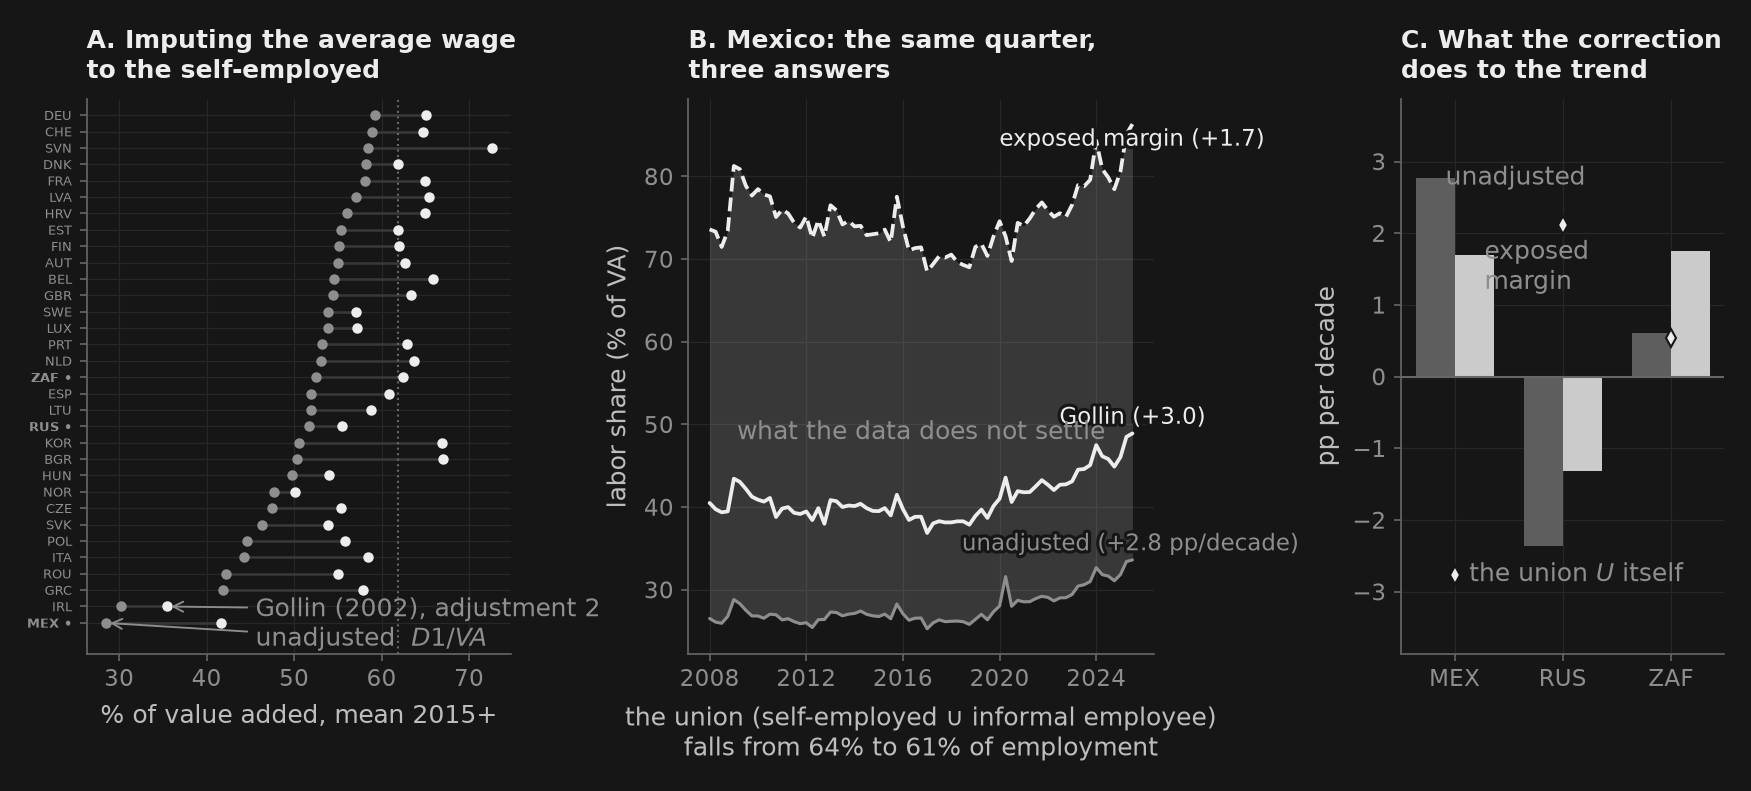

In [34]:
# 36 dumbbell rows in A: no TAMANO size gives the height, so it is set by hand
# (the width of "3", taller).
fig, (axA, axB, axC) = _nbstyle.figura(1, 3, figsize=(11.4, 5.0),
                                       gridspec_kw={"width_ratios": [1.05, 1.15, 0.8]})

# A. Gollin's correction, country by country. Dumbbells rather than bars: what
# has to be seen is the SHIFT, and its length is the self-employment share.
o = ls.sort_values("raw")
y = np.arange(len(o))
for i, (_, r) in enumerate(o.iterrows()):
    axA.plot([r["raw"], r["gollin"]], [i, i], color=_nbstyle.gris("0.75"), lw=1.2, ls="-", zorder=1)
axA.scatter(o["raw"], y, s=16, color=_nbstyle.NOTA, zorder=3)
axA.scatter(o["gollin"], y, s=16, color=_nbstyle.TINTA, zorder=3)
axA.set_yticks(y)
axA.set_yticklabels([c + (" •" if c in band_df.index else "") for c in o.index],
                    fontsize=6.0)
for i, c in enumerate(o.index):
    if c in band_df.index:
        axA.get_yticklabels()[i].set_fontweight("bold")
axA.set_ylim(-1.9, len(o))
axA.axvline(o["gollin"].median(), color=_nbstyle.SPINE, ls=":", lw=1.0)
axA.set_xlabel("% of value added, mean 2015+")
axA.set_title("A. Imputing the average wage\nto the self-employed")
# The two markers are named on the two lowest rows, where there is room to the right.
x_txt = float(o["gollin"].iloc[:2].max()) + 4.0
axA.annotate("Gollin (2002), adjustment 2", xy=(float(o["gollin"].iloc[1]), 1),
             xytext=(x_txt, 0.8), textcoords="data", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
axA.annotate("unadjusted  $D1/VA$", xy=(float(o["raw"].iloc[0]), 0),
             xytext=(x_txt, -1.0), textcoords="data", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

# B. The same question with the quarterly rate: Mexico, quarter by quarter.
# The grey band is everything the data does not settle.
j = band["MEX"]
axB.fill_between(j.index, j["raw"], j["exposed"], color=_nbstyle.BANDA, lw=0)
axB.plot(j.index, j["raw"], color=_nbstyle.NOTA, lw=1.5, ls="-",
         label=f"unadjusted ({band_df.loc['MEX', 'd_raw']:+.1f} pp/decade)")
axB.plot(j.index, j["gollin"], color=_nbstyle.TINTA, lw=1.8, ls="-",
         label=f"Gollin ({band_df.loc['MEX', 'd_gollin']:+.1f})")
axB.plot(j.index, j["exposed"], color=cols[0], lw=1.8, ls="--",
         label=f"exposed margin ({band_df.loc['MEX', 'd_exposed']:+.1f})")
mid = len(j) // 2
axB.annotate("what the data does not settle",
             xy=(j.index[mid], float((j["raw"].iloc[mid] + j["exposed"].iloc[mid]) / 2)),
             ha="center", va="center", color=_nbstyle.NOTA)
# One tick every four years: the panel is narrow for this many quarters.
marcas_b = [t for t in j.index if t.year % 4 == 0 and t.quarter == 1]
axB.set_xticks(marcas_b); axB.set_xticklabels([str(t.year) for t in marcas_b])
axB.set_ylabel("labor share (% of VA)")
axB.set_title("B. Mexico: the same quarter,\nthree answers")
axB.set_xlabel(f"the union (self-employed $\\cup$ informal employee)\nfalls from "
               f"{j['U'].iloc[0]:.0f}% to {j['U'].iloc[-1]:.0f}% of employment")

# C. Why the rate has to be quarterly: the correction moves the TREND, and it
# can only do that if it moves itself.
w, xb = 0.36, np.arange(len(band_df))
axC.bar(xb - w / 2, band_df["d_raw"], w, color=_nbstyle.BARRA_COLORES[2])
axC.bar(xb + w / 2, band_df["d_exposed"], w, color=_nbstyle.BARRA_COLORES[0])
axC.plot(xb, band_df["d_U"], marker="d", color=_nbstyle.TINTA, mec=_nbstyle.FONDO, linestyle="", ms=6)
axC.axhline(0, color=_nbstyle.SPINE, lw=1.0)
axC.set_xticks(xb); axC.set_xticklabels(band_df.index)
axC.set_ylabel("pp per decade")
axC.set_title("C. What the correction\ndoes to the trend")
axC.margins(y=0.2)
# The three marks are named on the first country, each to the right of its
# own: the three heights differ, so the names do not collide.
for dx, dy, text, v in ((-w / 2, 0, "unadjusted", float(band_df["d_raw"].iloc[0])),
                        (w / 2, -6, "exposed\nmargin", float(band_df["d_exposed"].iloc[0]))):
    axC.annotate(text, xy=(xb[0] + dx, v), xytext=(5, dy), textcoords="offset points",
                 ha="left", va="center", color=_nbstyle.NOTA)
axC.annotate("the union $U$ itself", xy=(xb[0], float(band_df["d_U"].iloc[0])), xytext=(7, 0),
             textcoords="offset points", ha="left", va="center", color=_nbstyle.NOTA)

_nbstyle.etiquetar(axB)
plt.show()


## 4. Real-Time National Accounts: Revisions, Vintages & SNA Methodology

Macroeconomic policy decisions and stylized facts depend crucially on the vintage of national accounts.
Here we examine two dimensions:
1. **Section 4.1**: The **Mankiw–Shapiro (1986)** news vs. noise test on preliminary vs. final growth — the pair of regressions $r_t = \alpha + \beta y^p_t + \varepsilon_t$ (news) and $r_t = \alpha + \beta y^f_t + \varepsilon_t$ (noise) — run on all 42 reference areas of the OECD revisions archive, first on GDP and then on every one of the nine measures the archive carries.
2. **Section 4.2**: The impact of **data vintages and SNA methodological changes** on second moments, specifically the **relative volatility of consumption $\sigma(c)/\sigma(y)$**.

### 4.1 The Mankiw–Shapiro (1986) News vs. Noise Test

Let $y^p_t$ be the preliminary release, $y^f_t$ the final release, and $r_t = y^f_t - y^p_t$ the revision.

**Mankiw & Shapiro (1986)** formulate two polar hypotheses, and — this is the part usually dropped — each one implies its *own* orthogonality condition, so the test is a **pair** of regressions on the same left-hand side:

| | the model | the regression | under it |
|---|---|---|---|
| **News** | $y^p_t = \mathbb{E}[y^f_t \mid \Omega_t]$: the preliminary release is an efficient forecast | $r_t = \alpha + \beta\, y^p_t + \varepsilon_t$ | $\beta = 0$, because a forecast error is orthogonal to the forecast |
| **Noise** | $y^p_t = y^f_t + \eta_t$: the preliminary release is the truth plus measurement error | $r_t = \alpha + \beta\, y^f_t + \varepsilon_t$ | $\beta = 0$, because $r_t = -\eta_t$ is orthogonal to the truth |

The two are not each other's null. Running only the first — which is what a one-line "test of the news hypothesis" does — leaves you unable to tell **noise** ($\beta_p < 0$, $\beta_f = 0$) from **neither** ($\beta_p < 0$ *and* $\beta_f \neq 0$), and the second is the common case: revisions that are part measurement error and part genuinely new information. `puremacro` runs both and reports the four-way verdict — `news`, `noise`, `indeterminate` (neither rejected: the sample is too short to say), `neither` (both rejected).

Under noise, $-\hat{\beta}_p$ estimates $\mathrm{Var}(\eta)/\mathrm{Var}(y^p)$ — the share of the preliminary estimate's variance that is measurement error — and real-time policy should use the **shrinkage estimator**
$$ \tilde{y}^p_t = \hat{\alpha} + (1 + \hat{\beta}_p)\, y^p_t. $$

**Two facts about growth rates before anything is estimated.** First, the regression must be run on **growth**, never on levels: a revision to an $I(1)$ level regressed on that level is a spurious regression, and $\hat{\beta}$ will look wonderfully significant for reasons that have nothing to do with either hypothesis. Second, running it on growth is also what makes the archive usable at all. Every edition sits on the price reference year and the vintage of the accounts current when it was published, so **levels are not comparable across editions** — Mexico's 2008-07 to 2009-11 editions carry the same quarter at about $4.5\times$ the value the editions on either side of them give it. A rescaling of a whole edition by any constant $k$ cancels out of that edition's growth rates, since $\log(k x_t) - \log(k x_{t-1})$ does not depend on $k$, so the transform that makes the regression legitimate is the same one that makes the rebasings disappear.

#### The panel: every archive there is

The test is nearly always run on one country, and nearly always on the United States, whose real-time dataset the Philadelphia Fed has maintained since 1996. That is a reasonable place to start and a poor place to stop. "GDP revisions are noise" is a claim about how a statistical office works, and one office is one observation: whether it describes measurement in general or the Bureau of Economic Analysis in particular cannot be settled from inside the United States. It can be settled by asking the same question of every office that keeps an archive.

`puremacro.fetch.vintage_panel` does that in one call. It reads the **OECD Short-Term Economic Statistics revisions archive** (`DSD_STES_REVISIONS`), the widest keyless cross-country vintage archive there is: **42 reference areas, monthly editions since February 1999**. One `VintagePanel` comes back, and it carries the operations that everyone otherwise rebuilds by hand — `coverage()`, the revision `triangle()`, `as_of()` (what the whole dataset looked like on a given day), `revisions()` and `news_or_noise()`.

> **What a vintage date means here.** The archive's `EDITION` is the month of the **OECD's snapshot** of the national series, not the date the national statistical office published it: the OECD ingests with a lag, so an edition can still carry the previous month's figure. That is fine for ordering editions and measuring revisions, and wrong if you want to use the date as an event date — for genuine national release dates `vintage_panel` also carries the Bundesbank (DE), ONS (UK) and StatCan (CA) providers, one country each. `VINTAGE_SEMANTICS` says this for every provider, and `vintage_panel` warns if a panel ends up mixing them.

In [35]:
from puremacro.fetch import vintage_panel
from puremacro.vintages import mankiw_shapiro
from puremacro.fetch.realtime import (VintagePanel, VINTAGE_SEMANTICS,
                                      seasonal_signature,
                                      drop_unadjusted_editions,
                                      SEASONAL_F_MIN, SEASONAL_RANGE_MIN,
                                      SEASONAL_MIN_OBS, SEASONAL_WINDOW)
from puremacro.fetch.realtime.oecd_stes import OECD_STES_COUNTRIES

# EA20 is the euro area, not a country: it is kept in the panel (its revisions
# are interesting in their own right) and excluded from every cross-country
# count and median below, on the same principle as §1.1.
AGGREGATES = {"EA20"}
VINTAGE_SNAPSHOT = DATA / "oecd_stes_vintages_gdp.csv.gz"


def vintages_from_snapshot(path):
    """Rebuild the VintagePanel from the frozen course file.

    The file stores the four columns that carry information — area, reference
    quarter, edition, value — and this puts back the four that are constant
    for it. Gzipped: 1.25 million rows is 23 MB as plain CSV and 3.8 MB this
    way, and `pd.read_csv` decompresses by extension with no extra package,
    which matters on a tablet. `archive` in §1.8 is what read it, so this is
    the second use of one parse rather than a second parse.
    """
    s = archive(path)
    return VintagePanel(df=pd.DataFrame({
        "country": s["code"],
        "variable": s["variable"],
        "date": s["date"],
        "vintage": pd.to_datetime(s["edition"], format="%Y%m"),
        "value": s["value"],
        # The three columns the panel requires and nobody groups on are
        # constant, or nearly: one string, another string, and 42 identifiers.
        # Stored as `object` they are 1.25 million pointers each — 220 MB of
        # the panel's 386 — and as `category` they are a dictionary of two or
        # forty-two entries plus a vector of codes. The archive goes from 386
        # to 170 MB, and §4.1 keeps two of these alive at once: on a desktop
        # that is a convenience, on a tablet it is the difference between
        # running and paging. `country` and `variable` deliberately stay
        # `object`, because puremacro groups on them and a categorical grouper
        # drags empty categories along.
        "provider": pd.Categorical(["oecd_stes"] * len(s)),
        "series_id": pd.Categorical(s["code"].map(
            {c: f"{c}.Q.B1GQ_Q..." for c in s["code"].unique()})),
        "units": pd.Categorical(["level"] * len(s)),
    }), metadata={"source": str(path)})


rev, rev_source = None, ""
if VIVO:
    try:
        # drop_unadjusted=False on purpose: since 1.8.0 vintage_panel screens
        # the raw editions out by itself, and this section exists to SHOW that
        # screen. We want the archive as it arrives and will run the screen
        # below, in the open. Every other use should take the default.
        rev = vintage_panel(list(OECD_STES_COUNTRIES), series="gdp_real",
                            freq="Q", drop_unadjusted=False)
        rev_source = "live download"
        if rev.is_empty():
            rev = None
    except Exception as exc:                    # rate limit, WAF, tablet w/o http
        print(f"Live vintage fetch failed ({type(exc).__name__}); "
              f"falling back to the snapshot.")
        rev = None
if rev is None:
    if not readable(VINTAGE_SNAPSHOT, "file"):
        raise RuntimeError(
            f"No real-time panel: no snapshot at {VINTAGE_SNAPSHOT} and no live "
            f"download. Copy the course's data_curso/ folder next to this "
            f"notebook, or re-run with MAV_QNA_VIVO=1 and a connection.")
    rev = vintages_from_snapshot(VINTAGE_SNAPSHOT)
    rev_source = "course snapshot (MAV_QNA_VIVO=1 to download)"

# The same treatment for the live path, which arrives with the columns as
# `object`, so the rest of §4 does not depend on where the panel came from.
for _col in ("provider", "series_id", "units"):
    if rev.df[_col].dtype == object:
        rev.df[_col] = rev.df[_col].astype("category")

# The raw archive has done its job here: §4.2 asks for it again and `archive`
# re-reads it from disk in 0.35 s. Releasing it now frees 225 MB over exactly
# the stretch where §4.1 has TWO vintage panels alive at once.
_ARCHIVES.clear()

cov = rev.coverage()
print(f"Real-time GDP panel [{rev_source}]")
print(f"  {len(rev.countries)} reference areas x {len(rev):,} "
      f"(reference quarter x edition) observations")
print(f"  editions {cov['first_vintage'].min():%Y-%m} to "
      f"{cov['last_vintage'].max():%Y-%m}, median "
      f"{int(cov['n_vintages'].median())} per area; reference periods reach "
      f"back to {cov['first_date'].min():%Y}")
print(f"  vintage date: {VINTAGE_SEMANTICS['oecd_stes']}")
print("\nThe five areas with the shortest archive — the ones a revision test "
      "can least afford:")
print(cov.nsmallest(5, "n_vintages")[
    ["country", "n_vintages", "n_periods", "first_vintage"]].to_string(index=False))

Real-time GDP panel [course snapshot (MAV_QNA_VIVO=1 to download)]
  42 reference areas x 1,249,388 (reference quarter x edition) observations
  editions 1999-02 to 2026-08, median 329 per area; reference periods reach back to 1947
  vintage date: Month of the OECD's snapshot of the national series (EDITION = YYYYMM), not the national statistical office's release date. The OECD ingests with a lag, so an edition can still carry the previous month's published figure. Fine for ordering editions and measuring revisions; not a release date.

The five areas with the shortest archive — the ones a revision test can least afford:
country  n_vintages  n_periods first_vintage
   EA20          41        126    2023-04-01
    CRI          66        142    2021-03-01
    COL          76         85    2020-05-01
    LTU          98        126    2018-07-01
    LVA         122        125    2016-07-01


#### The trap: not every edition is seasonally adjusted

Run the test on the panel exactly as it arrives and Sweden comes back with $\hat{\beta}_p = -0.96$ and a standard deviation of revisions of **5.1 pp per quarter**; Turkey with $\hat{\beta}_p = -0.96$ and **10.9 pp**. Taken at face value those say that essentially *all* of the variance of the Swedish and Turkish preliminary releases is measurement error — a spectacular finding, and a false one.

The `DSD_STES_REVISIONS` dataflow has six dimensions and none of them is seasonal adjustment. It carries whatever the OECD ingested at the time, and for twelve areas the early editions are the **unadjusted** series. Sweden's first releases say the economy grew $15.8\%$ in 2000Q4, $15.9\%$ in 2001Q4 and $16.1\%$ in 2002Q4; today's edition puts the same three quarters at $+0.13$, $+0.39$ and $+0.07$. What the regression would be calling a revision is a seasonal factor.

This is not a defect of `vintage_panel` — it is faithfully reporting what the archive holds — and it is not detectable from the metadata, because the archive does not record it. It is detectable from the **data**, and the screen below is deliberately blunt and deliberately visible. For each (area, edition) we take that edition's own quarterly log growth and ask two questions of the four quarterly means:

1. Is the quarterly pattern statistically there? — the $F$ statistic of quarterly dummies, which is $\approx 1$ under adjustment.
2. Is it *big*? — the peak-to-trough range across the four quarterly means, in percentage points of quarterly growth.

Both are computed **within** an edition, so a rebasing cancels, and both on 1995–2019, so the pandemic does not masquerade as a seasonal. An edition is called unadjusted when $F > 10$ **and** the range is at least $4.25$ pp. Panel B of the figure below is the justification: the two clouds are separated by more than an order of magnitude on both axes, and the threshold sits in the empty gap between them, not at a conventional critical value. The one judgement call is Iceland, whose adjusted editions keep a residual seasonal of $\approx 4$ pp — the largest of any area — and sit just inside the boundary.

#### Finding them is one thing; what to do with them is another

The immediate reaction is to **drop them**, and it is what this lesson did for several versions. It is defensible, and it has a serious problem that the row count hides.

`revisions()` pairs each reference quarter with the **first edition that contains it**. Removing Sweden's early editions does not erase quarters 2000Q4–2006Q4: it leaves them paired with the first surviving Swedish edition, which is February 2007. For twenty-five Swedish quarters — and as many Mexican and Turkish ones — the regression's "preliminary datum" becomes a figure the office had been publishing and revising for up to six years. The test still runs, still has 109 observations, and a quarter of them are no longer what the theory calls $y^p_t$. On top of that, in the areas where no early edition survives, quarters are genuinely lost: fifty-three pairs in all.

And there is an objection of principle: dropping leaves a panel that **still mixes two procedures**. Each area's later years were seasonally adjusted by its statistical office with some method and some calendar; the early years that get dropped, by nobody. The resulting archive is not homogeneous, it is only homogeneous *on average*.

The alternative this notebook uses from here on is to **seasonally adjust every edition with one filter** — all 11,503 of them, not the 501 flagged ones. The reason for running it over the ten thousand that already came adjusted is not that they need it: it is that applying it to some and not others is precisely the mixture we are trying to avoid. The test is estimated area by area, so what has to be homogeneous is each area with itself: that $y^p_t$ and $y^f_t$ come out of the same procedure.

**The filter and its three properties.** It is the reverse of the screen: each edition has its own four centred quarterly mean growth rates subtracted. (1) **It does not look ahead** — the May 2001 edition is adjusted with what was known in May 2001, the condition that makes any real-time exercise legitimate. (2) **It is invariant to rebasing**, for the same reason the regression runs on growth. (3) **It is a no-op where the office already did the work**: on the thirty clean areas it removes tenths of a point and moves the coefficient by a median 0.006, which the third cell checks one by one.

What the filter does **not** do is chase moving seasonality, calendar effects or outliers, which is X-13's business. That is why the next cell checks it against X-13 on the most seasonal edition of each affected area, and why the check is made on the observation the test actually uses — the growth rate of each edition's last quarter — and not on the whole series. That cell is the only one in the notebook whose numbers depend on the machine: `deseasonalize_x13` uses the X-13 binary where it is installed and its own pure-Python X-11/ARIMA where it is not — on a tablet, for instance — and the two engines do not give the same adjustment. The table says which one ran, in its header. What does not change is the conclusion: the dummy filter lands close to the full adjustment, and both land nowhere near not adjusting.

In [36]:
# The screen lives in puremacro, not here: T01_A §6 needs exactly the same
# one for the real-time output gap, and a numeric screen maintained in two
# notebooks and two languages is four copies that will drift.
# `seasonal_signature` scores every edition and `drop_unadjusted_editions`
# applies the old treatment — dropping them — which is kept here only to
# measure what it would have cost. The new treatment lives in the notebook
# and in plain sight, because the decision it encapsulates is what the
# section teaches.
def deseasonalize_editions(p, sig=None, window=SEASONAL_WINDOW,
                           min_obs=SEASONAL_MIN_OBS, receipt=True):
    """One and the same seasonal filter over EVERY edition of the archive.

    The filter is the exact reverse of the screen: `seasonal_signature` detects
    an unadjusted edition by comparing the four quarterly means of the log
    growth *of that same edition*, and this subtracts those four means. On the
    level it amounts to dividing by a multiplicative seasonal factor, because
    the running sum of four centred means is periodic with period four; on the
    growth rate — which is what the Mankiw-Shapiro regression uses — it amounts
    to a quarterly-dummy adjustment.

    Three properties make it admissible on a real-time archive:

    1. **It does not look ahead.** Each edition is adjusted with the quarters
       that edition contained, and none after. The May 2001 edition is
       deseasonalized with what was known in May 2001.
    2. **It is invariant to rebasing.** Multiplying a whole edition by a
       constant leaves its log growth unchanged, hence its quarterly means and
       the factor subtracted from it.
    3. **It is a no-op where the office already did the work.** Already
       adjusted editions keep a residual seasonal of tenths of a point;
       removing it moves them in the fourth decimal.

    It is deliberately blunt — it chases neither moving seasonality nor
    calendar effects nor outliers, which is what X-13 does — and deliberately
    cheap: eleven thousand editions in a couple of seconds, no external
    binaries, on a tablet. The next cell checks it against X-13 where most is
    at stake.

    Returns ``(VintagePanel, receipt)``; the receipt says, area by area, how
    much seasonality its worst edition carried before and after. It costs a
    second scoring pass, so the component sweep further down — which reads
    eight more archives and wants the panel, not the receipt — asks for
    ``receipt=False`` and gets ``(VintagePanel, None)``.
    """
    lo, hi = pd.Timestamp(window[0]), pd.Timestamp(window[1])
    pieces, short_n = [], 0
    for (country, var), sub in p.df.groupby(["country", "variable"], sort=True):
        piv = (sub.pivot_table(index="date", columns="vintage", values="value")
                  .sort_index())
        lg = np.log(piv)
        g = lg.diff()
        q = pd.Index(g.index.quarter)
        inside = (g.index >= lo) & (g.index < hi)
        qi = q[inside]
        m = g[inside].groupby(qi).mean().reindex([1, 2, 3, 4])
        n_q = g[inside].groupby(qi).count().reindex([1, 2, 3, 4]).fillna(0)
        # The very few editions that do not reach min_obs inside the window —
        # the earliest ones, ending in 1998 — are estimated on their whole
        # sample, which for them is entirely pre-pandemic anyway.
        short = n_q.sum() < min_obs
        if short.any():
            whole = g.groupby(q).mean().reindex([1, 2, 3, 4])
            mask = short.to_numpy()
            m.loc[:, mask] = whole.loc[:, mask]
            short_n += int(short.sum())
        m = m.fillna(0.0)
        m = m - m.mean(axis=0)      # centred: the profile goes, the mean stays
        factor = m.cumsum()          # periodic by construction: factor[4] = 0
        key = pd.MultiIndex.from_arrays(
            [sub["date"].dt.quarter, sub["vintage"]])
        pieces.append(sub.assign(
            value=sub["value"].to_numpy()
            * np.exp(-factor.stack().reindex(key).to_numpy())))
    out = pd.concat(pieces, ignore_index=True)
    adjusted = VintagePanel(df=out,
                            metadata={**p.metadata,
                                      "seasonal": "quarterly dummies within edition",
                                      "short_editions": short_n})
    if not receipt:
        return adjusted, None
    # `sig` arrives ready-made because the cell already computed it for the
    # screen: scoring eleven thousand editions twice is a quarter of a second on
    # a desktop and considerably more on a tablet, for exactly the same numbers.
    before = seasonal_signature(p) if sig is None else sig
    after = seasonal_signature(adjusted)
    receipt = pd.concat(
        [before.groupby("country")["seasonal_range"].max().rename("range_before"),
         after.groupby("country")["seasonal_range"].max().rename("range_after"),
         before.groupby("country")["unadjusted"].sum().rename("flagged")],
        axis=1)
    return adjusted, receipt


# The screen first: who is unadjusted and how strongly.
F_MIN, RANGE_MIN = SEASONAL_F_MIN, SEASONAL_RANGE_MIN
sig = seasonal_signature(rev)

# And the treatment: ONE filter over all 11,503 editions, not a filter on some
# and the statistical office on the rest. `drop_unadjusted_editions` — the
# alternative, and what earlier versions of this lesson did — is kept only to
# measure what it would have cost, which is the business of two cells below.
rev_sa, receipt = deseasonalize_editions(rev, sig=sig)
# The affected areas come straight out of the screen, so dropping only has to
# be done over them: `drop_unadjusted_editions` over the whole archive returns
# the same table and leaves a second copy of 1.25 million rows in a tablet's
# memory along the way.
AFFECTED = sorted(sig.loc[sig["unadjusted"], "country"].unique())
rev_drop, dropped = drop_unadjusted_editions(rev.filter(countries=AFFECTED))

print(f"Editions carrying an unadjusted series: "
      f"{int(sig['unadjusted'].sum())} of {len(sig):,} scored, in "
      f"{len(dropped)} of {len(rev.countries)} areas.")
print(dropped.assign(first=dropped["first"].dt.strftime("%Y-%m"),
                     last=dropped["last"].dt.strftime("%Y-%m"),
                     median_range=dropped["median_range"].round(1))
      .to_string())

print(f"\nThe filter runs over all {len(rev.df):,} rows of the archive and "
      f"throws none away. Maximum seasonality\nby area, before and after (range "
      f"between strongest and weakest quarter, pp of growth):")
_r = receipt.sort_values("range_before", ascending=False)
print(_r.head(14).round(3).to_string())
print(f"  ... and {len(_r) - 14} more areas, all below "
      f"{_r['range_before'].iloc[14]:.2f} pp before the filter.")
print(f"\nThat the right-hand column is zero **proves nothing**: the filter "
      f"subtracts exactly the quarterly\nmeans the screen measures, so zeroing "
      f"them is its definition, not a result. The real check is\nexternal, and "
      f"it is the next two cells — against X-13, and against today's edition "
      f"of the very\nstatistical office that produced the test's $y^f_t$.")
print(f"\nWhere the office had already done the work the filter is a no-op: "
      f"across the {int((receipt['flagged'] == 0).sum())} areas with no\n"
      f"flagged edition the seasonality it removes is "
      f"{receipt.loc[receipt['flagged'] == 0, 'range_before'].median():.2f} pp "
      f"at the median — tenths of a point of quarterly\ngrowth — and §4.1 "
      f"checks below that their coefficients do not move.")

# Guards: the screen has to separate, not shave; and the filter has to leave
# the whole archive standing, not just what it does not want.
assert sig["unadjusted"].sum() > 0
assert float(sig.loc[sig["unadjusted"], "seasonal_range"].min()) >= RANGE_MIN
assert len(rev_sa.countries) == len(rev.countries)
assert len(rev_sa.df) == len(rev.df)
assert float(receipt["range_after"].max()) < 1e-6
assert set(dropped.index) == set(AFFECTED)

Editions carrying an unadjusted series: 501 of 11,434 scored, in 12 of 42 areas.
         editions    first     last  median_range
country                                          
AUT            48  1999-04  2003-10          13.2
CZE            38  1999-05  2003-09          12.6
HUN            24  2003-04  2005-06          13.3
IRL             4  2004-07  2004-10           5.9
ISL            30  2003-04  2005-09          13.8
LUX             8  2006-06  2007-01           7.9
MEX            72  2000-10  2006-09           9.8
POL            53  2002-09  2007-01          22.5
PRT            16  1999-05  2000-08           4.5
SVK            56  2001-02  2005-09          12.4
SWE            76  2000-10  2007-01          27.5
TUR            76  2000-10  2007-01          60.0

The filter runs over all 1,249,388 rows of the archive and throws none away. Maximum seasonality
by area, before and after (range between strongest and weakest quarter, pp of growth):
         range_before  range_after

In [37]:
# The external check on the filter: X-13 on the worst edition of each affected
# area. X-13 does what quarterly dummies do not — moving seasonality, calendar
# effects, outliers — so if the two agree on the observation the test cares
# about, the cheap filter will do. Twelve runs, not eleven thousand: the X-13
# binary takes ~0.1 s each on a desktop and considerably more on a tablet, and
# there is no reason to pay that eleven thousand times when twelve answer the
# question.
from puremacro.sa import x13_available

# The engine matters here and only here. `deseasonalize_x13` uses the X-13
# binary if it is installed and its own pure-Python X-11/ARIMA if not — which
# is what runs on a tablet — and the two do not give the same adjustment. This
# table, the only one in the notebook that compares one adjustment against
# another, therefore changes in the second digit depending on the machine; the
# verdict it supports does not.
ENGINE = "X-13 binary" if x13_available() else "pure-Python X-11/ARIMA"

worst = (sig[sig["unadjusted"]]
         .sort_values("seasonal_range", ascending=False)
         .drop_duplicates("country").set_index("country"))

rows = []
for c in AFFECTED:
    ed = worst.loc[c, "vintage"]
    def _series(p):
        d = p.df
        s = d[(d["country"] == c) & (d["vintage"] == ed)]
        return s.set_index("date")["value"].sort_index()
    raw_s, ours = _series(rev), _series(rev_sa)
    if len(raw_s) < 24:
        continue
    d13 = pd.DataFrame({"date": raw_s.index, "v": np.log(raw_s.to_numpy()),
                        "grp": "x"})
    x13 = np.exp(np.asarray(deseasonalize_x13(d13, "v", by="grp",
                                              date_col="date", freq="Q")))
    g = lambda v: 100.0 * np.diff(np.log(np.asarray(v)))
    gb, gn, gx = g(raw_s), g(ours), g(x13)
    rows.append({"area": c, "edition": f"{ed:%Y-%m}", "quarters": len(gb),
                 "last raw": gb[-1], "last dummies": gn[-1], "last X-13": gx[-1],
                 "median |diff|": float(np.median(np.abs(gn - gx))),
                 "corr": float(np.corrcoef(gn, gx)[0, 1])})
x13_vs = pd.DataFrame(rows).set_index("area")

print(f"The cheap filter against X-13 ({ENGINE}), on the most seasonal "
      f"edition of each affected area.\n'Last' is the growth rate of that "
      f"edition's most recent quarter — the test's $y^p_t$:")
print(x13_vs.round(2).to_string())
_d = (x13_vs["last dummies"] - x13_vs["last X-13"]).abs()
_b = (x13_vs["last raw"] - x13_vs["last X-13"]).abs()
print(f"\nOn the observation the test uses, the two filters differ by a median "
      f"{_d.median():.2f} pp (worst case\n{_d.max():.2f}, {_d.idxmax()}), while "
      f"the unadjusted series is {_b.median():.1f} pp from X-13 at the median "
      f"and up to\n{_b.max():.0f}. Choosing between the two adjustments matters "
      f"{_b.median() / _d.median():.0f} times less than choosing between "
      f"adjusting\nand not, and that is all this test needs to be true.")
print(f"Over the whole series they diverge more — median correlation "
      f"{x13_vs['corr'].median():.2f} — as expected: X-13 chases moving\n"
      f"seasonality and outliers that fixed dummies cannot follow. Anyone who "
      f"needs the level of a specific\nquarter of a specific edition should use "
      f"X-13; anyone who needs the test does not.")

# The two adjustments agree where it matters and both part company with the raw.
assert (_d < _b).all()
assert _d.median() < 1.0

The cheap filter against X-13 (X-13 binary), on the most seasonal edition of each affected area.
'Last' is the growth rate of that edition's most recent quarter — the test's $y^p_t$:
      edition  quarters  last raw  last dummies  last X-13  median |diff|  corr
area                                                                           
IRL   2004-07        28     -1.75          0.65       0.98           0.35  0.98
ISL   2004-06        27      4.09          1.29       1.12           0.40  0.94
LUX   2006-09        44     -1.44          1.02       1.00           0.39  0.92
MEX   2000-12        81      2.65          2.21       1.32           0.96  0.74
POL   2005-05        39     10.08          1.73      -0.09           0.45  0.92
PRT   1999-05        35      2.38          0.24       0.40           0.38  0.77
SVK   2005-09        61      9.54          1.55       1.20           0.81  0.79
SWE   2000-10        29      3.98          1.66       0.74           0.51  0.83
TUR   2000-11    

In [38]:
# The test, on every area. `news_or_noise_panel` runs BOTH regressions per area
# and reports countries it cannot estimate rather than dropping them.
#
# Newey-West rather than White errors: annual benchmark revisions arrive on a
# fixed calendar and put serial correlation into r_t, which plain OLS standard
# errors would read as precision. `hac_lags="auto"` is the floor(4(n/100)^(2/9))
# plug-in rule, four lags at n = 109.
#
# One area at a time, and all forty-two cut in a single pass. Every call that
# names a country has to find its rows, and finding them in a 1.2-million-row
# frame means comparing 1.2 million strings -- 24 ms, paid several times per
# area. A `groupby` cuts all forty-two in 0.06 s and leaves everything that
# follows working on ~30,000 rows; going area by area with `filter` costs three
# seconds, which on a tablet is fifteen.
#
# The bias leg -- is the MEAN revision zero? -- is Mankiw and Shapiro's third
# diagnostic and the only one `news_or_noise_panel` carries no p-value for, so
# each area's result object is needed as well. Asking for both separately --
# `news_or_noise_panel` and `news_or_noise` -- builds the area's revision
# triangle TWICE, and the triangle is 98% of the cost: 1.6 s of the 1.7 the
# forty-two take. Building it once and estimating on it gives both objects for
# the price of one. `_row` copies `news_or_noise_panel`'s schema and the assert
# at the end checks it against the library on one area, so the shortcut cannot
# drift in silence. Only one slice is alive at a time: keeping all forty-two
# would be a second copy of the panel, and on a tablet memory is scarcer than
# time.
MIN_OBS_MS = 12


def _row(code, r):
    return {"country": code, "variable": "gdp_real", "n_obs": r.n_obs,
            "mean_revision": r.mean_revision, "std_revision": r.std_revision,
            "beta_on_preliminary": r.beta_on_preliminary,
            "se_beta_on_preliminary": r.se_beta_on_preliminary,
            "p_beta_on_preliminary": r.p_beta_on_preliminary,
            "beta_on_final": r.beta_on_final,
            "se_beta_on_final": r.se_beta_on_final,
            "p_beta_on_final": r.p_beta_on_final,
            "noise_share": r.noise_share, "verdict": r.verdict,
            "ok": True, "note": ""}


_rows, _res = [], {}
for c, _g in rev_sa.df.groupby("country", sort=True):
    one = VintagePanel(df=_g, metadata=rev_sa.metadata)
    _fr = one.revisions(c)
    if len(_fr) < MIN_OBS_MS:      # the library reports them, does not drop them
        _rows.append({"country": c, "variable": "gdp_real", "n_obs": len(_fr),
                      "ok": False, "note": f"only {len(_fr)} revision pairs"})
        continue
    _res[c] = mankiw_shapiro(_fr["preliminary"], _fr["final"], hac_lags="auto",
                             transform="log_diff_pct")
    _rows.append(_row(c, _res[c]))

ms = pd.DataFrame(_rows)

# The shortcut gives exactly what the library gives. Checked on one area -- one
# extra call, not forty-two -- and over every column this section uses.
_c0 = ms["country"].iloc[0]
_ref = (VintagePanel(df=rev_sa.df[rev_sa.df["country"] == _c0],
                     metadata=rev_sa.metadata)
        .news_or_noise_panel(hac_lags="auto", min_obs=MIN_OBS_MS).iloc[0])
for _k in ("n_obs", "mean_revision", "std_revision", "beta_on_preliminary",
           "se_beta_on_preliminary", "p_beta_on_preliminary", "beta_on_final",
           "p_beta_on_final", "verdict", "ok"):
    _a, _b = ms.loc[0, _k], _ref[_k]
    assert _a == _b or abs(float(_a) - float(_b)) < 1e-12, (_k, _a, _b)
ms["is_aggregate"] = ms["country"].isin(AGGREGATES)
ms["p_bias"] = ms["country"].map({c: r.p_mean_revision for c, r in _res.items()})

print(ms.loc[~ms["is_aggregate"],
             ["country", "n_obs", "mean_revision", "p_bias", "std_revision",
              "beta_on_preliminary", "se_beta_on_preliminary",
              "p_beta_on_preliminary", "beta_on_final", "p_beta_on_final",
              "verdict"]].round(3).to_string(index=False))

ok = ms[ms["ok"] & ~ms["is_aggregate"]]
n_neg = int((ok["beta_on_preliminary"] < 0).sum())
n_signeg = int(((ok["beta_on_preliminary"] < 0)
                & (ok["p_beta_on_preliminary"] < 0.05)).sum())
n_sigpos = int(((ok["beta_on_preliminary"] > 0)
                & (ok["p_beta_on_preliminary"] < 0.05)).sum())
print(f"\nEstimated for {int(ms['ok'].sum())} of {len(ms)} areas "
      f"({len(ok)} countries plus {int(ms['is_aggregate'].sum())} aggregate); "
      f"median sample {int(ok['n_obs'].median())} quarters.")
print(f"  beta on the preliminary: median {ok['beta_on_preliminary'].median():+.3f}, "
      f"negative in {n_neg}/{len(ok)}, significantly negative in {n_signeg}, "
      f"significantly positive in {n_sigpos}.")
print(f"  mean revision: positive in {int((ok['mean_revision'] > 0).sum())}/{len(ok)} "
      f"countries, median {ok['mean_revision'].median():+.3f} pp per quarter "
      f"({4 * ok['mean_revision'].median():+.2f} pp a year), significantly "
      f"non-zero in {int((ok['p_bias'] < 0.05).sum())}.")
print("  verdicts: " + ", ".join(f"{k} {v}" for k, v
                                 in ms["verdict"].value_counts().items()))

# The direction is the finding, and it is one-sided: significantly negative
# coefficients outnumber positive ones by more than an order of magnitude, and
# the positives do not exceed what 41 tests at the 5% level throw up by chance.
# (With the archive treated by dropping the flagged editions rather than
# adjusting them, the positive count was exactly zero; the one that appears now
# is Portugal at p = 0.045, and §4.1 names it rather than hiding it.)
assert n_sigpos <= 0.05 * len(ok) + 1
assert n_signeg > 8 * max(n_sigpos, 1)
assert n_neg > len(ok) / 2
assert float(ms.loc[ms["country"] == "USA", "beta_on_preliminary"].iloc[0]) < 0

country  n_obs  mean_revision  p_bias  std_revision  beta_on_preliminary  se_beta_on_preliminary  p_beta_on_preliminary  beta_on_final  p_beta_on_final       verdict
    AUS    108          0.087   0.002         0.322               -0.058                   0.037                  0.119          0.044            0.298 indeterminate
    AUT    109          0.066   0.215         0.797               -0.033                   0.086                  0.703          0.151            0.005          news
    BEL    109          0.137   0.003         0.404               -0.065                   0.026                  0.013         -0.010            0.825         noise
    BRA     86          0.130   0.015         0.609               -0.047                   0.029                  0.103          0.075            0.257 indeterminate
    CAN    109          0.051   0.056         0.344               -0.072                   0.015                  0.000         -0.030            0.562         noise
    

In [39]:
# What the alternative cost. Dropping the flagged editions -- what earlier
# versions of this lesson did -- leaves an archive that still mixes two things,
# in two ways, only one of which shows up in the row count:
#
#   1. Whole quarters are lost wherever an area keeps no early edition.
#   2. And where it does keep a later one, that quarter's "preliminary" stops
#      being a first release and becomes the estimate the office held YEARS
#      later. The regression still calls it y^p_t and the observation count
#      gives no warning.
#
# The cell walks the archive ONCE. Each area needs four things here -- two
# regressions, two revision triangles and two first-edition maps -- and asking
# the full frame for them, as the first version of this cell did, is four
# sweeps of 1.25 million rows per area: fifteen seconds on a desktop and over a
# minute on a tablet. Pre-cut with a `groupby`, the same thing costs two.
ms_i = ms.set_index("country")
_drop_cuts = {c: g for c, g in rev_drop.df.groupby("country", sort=False)}


def _first_edition(g):
    """Earliest edition containing each reference quarter."""
    return g[g["value"].notna()].groupby("date")["vintage"].min()


rows, beta_others, n_others = [], {}, {}
for c, g in rev.df.groupby("country", sort=True):
    # One triangle per (area, treatment), not two: `news_or_noise_panel` would
    # build its own and `revisions` an identical one, and the triangle is
    # almost the whole cost. Same shortcut as the test cell, already checked
    # against the library there.
    p_raw = VintagePanel(df=g, metadata=rev.metadata)
    pa = p_raw.revisions(c)
    r_raw = mankiw_shapiro(pa["preliminary"], pa["final"], hac_lags="auto",
                           transform="log_diff_pct")
    if c not in AFFECTED:
        # The thirty the office had already adjusted: all that is needed is
        # their beta on the raw archive, to show that running the filter over
        # them did nothing.
        beta_others[c] = float(r_raw.beta_on_preliminary)
        n_others[c] = int(r_raw.n_obs)
        continue
    p_drop = VintagePanel(df=_drop_cuts[c], metadata=rev.metadata)
    pd_ = p_drop.revisions(c)
    r_drop = mankiw_shapiro(pd_["preliminary"], pd_["final"], hac_lags="auto",
                            transform="log_diff_pct")
    common = pa.index.intersection(pd_.index)
    stale = ((pa.loc[common, "preliminary"]
              - pd_.loc[common, "preliminary"]).abs() > 1e-9)
    lag = ((_first_edition(_drop_cuts[c]) - _first_edition(g)).dt.days
           / 365.25).reindex(common[stale])
    rows.append({
        "area": c,
        "n dropping": int(r_drop.n_obs),
        "n adjusting": int(ms_i.loc[c, "n_obs"]),
        "stale prelim.": int(stale.sum()),
        "lag (years)": float(lag.median()) if len(lag) else 0.0,
        "sd rev. raw": float(r_raw.std_revision),
        "sd rev. adj.": float(ms_i.loc[c, "std_revision"]),
        "beta raw": float(r_raw.beta_on_preliminary),
        "beta dropping": float(r_drop.beta_on_preliminary),
        "beta adjusting": float(ms_i.loc[c, "beta_on_preliminary"]),
    })
three = pd.DataFrame(rows).set_index("area")
three["quarters lost"] = three["n adjusting"] - three["n dropping"]

print("The three ways of treating the archive, on the twelve areas that need "
      "it:")
print(three[["n dropping", "n adjusting", "quarters lost", "stale prelim.",
             "lag (years)", "sd rev. raw", "sd rev. adj.", "beta raw",
             "beta dropping", "beta adjusting"]].round(2).to_string())

lost, stale_n = int(three["quarters lost"].sum()), int(three["stale prelim."].sum())
with_stale = three.index[three["stale prelim."] > 0]
detail = ", ".join(f"{c} {int(three.loc[c, 'stale prelim.'])}" for c in with_stale)
d_adj = (three["beta adjusting"] - three["beta dropping"]).abs()
d_raw = (three["beta raw"] - three["beta adjusting"]).abs()
print(f"\nDropping costs {lost} (area, quarter) pairs and — this is what shows "
      f"up in no row count — turns the\npreliminary of another {stale_n} into a "
      f"later estimate: {detail}, with median lags of\nup to "
      f"{three['lag (years)'].max():.1f} years. A revisions test whose "
      f"'preliminary datum' has been published for three\nyears does not "
      f"measure what it claims to.")
print(f"\nThe coefficients, by contrast, barely distinguish dropping from "
      f"adjusting: the median difference is\n{d_adj.median():.3f} and the "
      f"largest {d_adj.max():.2f} ({d_adj.idxmax()}), against the "
      f"{d_raw.median():.2f} median separating either of them from\nthe raw "
      f"archive. The two corrections agree on the diagnosis; they differ in "
      f"what they leave standing.")

# And the thirty areas the office had already adjusted: the filter runs over
# them too and it has to be shown that it did nothing, because applying it to
# ALL of the archive is exactly what stops the panel mixing procedures.
OTHERS = sorted(beta_others)
d_others = (ms_i.loc[OTHERS, "beta_on_preliminary"]
            - pd.Series(beta_others)).abs()
same_n = bool((ms_i.loc[OTHERS, "n_obs"] == pd.Series(n_others)).all())
print(f"\nAcross the other {len(OTHERS)} areas the filter is harmless: the "
      f"coefficient moves a median {d_others.median():.3f}\nand at most "
      f"{d_others.max():.3f} ({d_others.idxmax()}), and the number of "
      f"observations {'changes in none' if same_n else 'changes somewhere'}. "
      f"That is the point of\napplying it to the whole archive rather than to "
      f"the twelve: the panel stops mixing two procedures\nat essentially no "
      f"cost where none was needed.")

# Adjusting dominates dropping on coverage and ties on diagnosis.
assert lost > 0 and stale_n > 0
assert (three["quarters lost"] >= 0).all()
assert d_adj.median() < 0.15
assert d_others.max() < 0.10 and same_n
assert three["sd rev. adj."].median() < three["sd rev. raw"].median()

# The raw archive and its trimmed version have said everything they had to say;
# what follows reads only `rev_sa`. They are two frames of hundreds of MB, and
# on a tablet memory is scarcer than time.
del _drop_cuts, rev, rev_drop

The three ways of treating the archive, on the twelve areas that need it:
      n dropping  n adjusting  quarters lost  stale prelim.  lag (years)  sd rev. raw  sd rev. adj.  beta raw  beta dropping  beta adjusting
area                                                                                                                                        
AUT          109          109              0             15         1.34         1.72          0.80     -0.45          -0.02           -0.03
CZE          109          109              0             12         1.62         1.73          0.73     -0.61          -0.19           -0.16
HUN           92           93              1              6         0.91         1.47          0.67     -0.27           0.00           -0.01
IRL           94           94              0              2         0.21         3.32          3.21     -0.13          -0.13           -0.01
ISL           79           92             13              0         0.00        

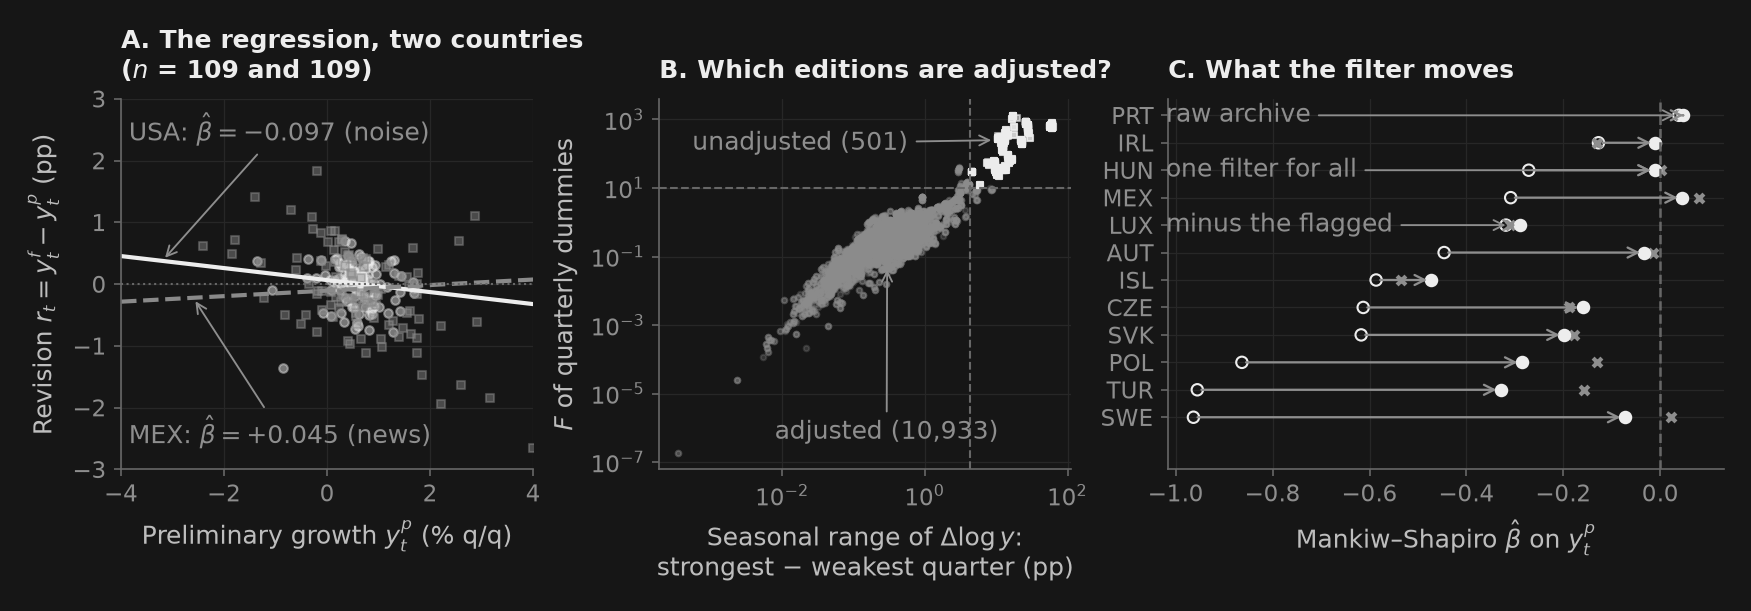

In [40]:
_VERDICT = {"noise": "noise", "news": "news", "indeterminate": "indeterminate",
            "neither": "neither"}
# C carries the names next to its markers and needs the width; A and B are
# point clouds and give it up without losing anything.
fig, (axA, axB, axC) = _nbstyle.figura(1, 3,
                                       gridspec_kw={"width_ratios": [1.0, 1.0, 1.35]})

# A. the regression itself, for the two countries this course keeps comparing
n_obs, fit_lines = {}, []
for code, col, mk, ls in (("USA", _nbstyle.UNIVERSAL_COLORS[0], "o", "-"), ("MEX", cols[3], "s", "--")):
    fr = rev_sa.revisions(code)
    r = _res[code]
    n_obs[code] = r.n_obs
    axA.scatter(fr["preliminary"], fr["revision"], s=17, alpha=0.45,
                color=col, marker=mk)
    gx = np.linspace(-4, 4, 50)
    fit_lines += axA.plot(gx, r.alpha_on_preliminary + r.beta_on_preliminary * gx,
                          color=col, lw=2.0, ls=ls,
                          label=f"{code}: $\\hat{{\\beta}}={r.beta_on_preliminary:+.3f}$ "
                                f"({_VERDICT[r.verdict]})")
axA.axhline(0, color=_nbstyle.SPINE, ls=":", lw=1.0)
axA.set_xlim(-4, 4); axA.set_ylim(-3.0, 3.0)
axA.set_xlabel("Preliminary growth $y^p_t$ (% q/q)")
axA.set_ylabel("Revision $r_t = y^f_t - y^p_t$ (pp)")
axA.set_title("A. The regression, two countries\n($n$ = " + " and ".join(str(v) for v in n_obs.values()) + ")")

# B. the screen, and why its thresholds are where they are
adjusted, unadjusted = sig[~sig["unadjusted"]], sig[sig["unadjusted"]]
axB.scatter(adjusted["seasonal_range"], adjusted["F"], s=7, alpha=0.25, color=_nbstyle.NOTA)
axB.scatter(unadjusted["seasonal_range"], unadjusted["F"], s=9, alpha=0.6, color=cols[0],
            marker="s")
axB.axhline(F_MIN, color=_nbstyle.SPINE, ls="--", lw=1.0)
axB.axvline(RANGE_MIN, color=_nbstyle.SPINE, ls="--", lw=1.0)
axB.set_xscale("log"); axB.set_yscale("log")
axB.set_xlabel("Seasonal range of $\\Delta\\log y$:\nstrongest $-$ weakest quarter (pp)")
axB.set_ylabel("$F$ of quarterly dummies")
axB.set_title("B. Which editions are adjusted?")
# Each cloud is named from the free space: top left the flagged ones, bottom
# right the rest.
axB.annotate(f"unadjusted ({len(unadjusted)})",
             xy=(float(unadjusted["seasonal_range"].quantile(0.1)), float(unadjusted["F"].median())),
             xytext=(0.08, 0.88), textcoords="axes fraction", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
axB.annotate(f"adjusted ({len(adjusted):,})",
             xy=(float(adjusted["seasonal_range"].median()), float(adjusted["F"].quantile(0.1))),
             xytext=(0.28, 0.10), textcoords="axes fraction", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

# C. what the filter moves, and how little separates the two treatments
mv = three.sort_values("beta raw").reset_index()
yv = np.arange(len(mv))
for i in yv:
    axC.annotate("", xy=(mv.loc[i, "beta adjusting"], i),
                 xytext=(mv.loc[i, "beta raw"], i),
                 arrowprops=dict(arrowstyle="->", color=_nbstyle.NOTA, lw=1.1))
axC.scatter(mv["beta raw"], yv, s=30, facecolors="none", edgecolors=cols[0])
axC.scatter(mv["beta dropping"], yv, s=18, color=_nbstyle.NOTA, marker="x")
axC.scatter(mv["beta adjusting"], yv, s=30, color=_nbstyle.TINTA)
axC.axvline(0, color=_nbstyle.SPINE, ls="--", lw=1.2)
axC.set_yticks(yv); axC.set_yticklabels(mv["area"])
axC.set_ylim(-1.9, len(mv) - 0.4)
axC.set_xlabel("Mankiw–Shapiro $\\hat{\\beta}$ on $y^p_t$")
axC.set_title("C. What the filter moves")
# The three markers are named on high, alternating rows, on the left, where
# there are no points: on a single row the three names collide.
for _yrow, _col, _txt in ((len(mv) - 1, "beta raw", "raw archive"),
                          (len(mv) - 3, "beta adjusting", "one filter for all"),
                          (len(mv) - 5, "beta dropping", "minus the flagged")):
    axC.annotate(_txt, xy=(float(mv.loc[_yrow, _col]), _yrow), xytext=(-1.02, _yrow),
                 textcoords="data", ha="left", va="center", color=_nbstyle.NOTA,
                 arrowprops=_nbstyle.FLECHA)

# The two names go to the empty space at the top and at the bottom, each with a
# leader to its line: in the middle of the cloud the white line struck one of
# them through and the zero line the other.
for _line, _y_txt, _x_lead in zip(fit_lines, (2.5, -2.4), (-3.2, -2.6)):
    axA.annotate(_line.get_label(),
                 xy=(_x_lead, float(np.interp(_x_lead, _line.get_xdata(),
                                              _line.get_ydata()))),
                 xytext=(-3.85, _y_txt), textcoords="data", ha="left", va="center",
                 color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
plt.show()


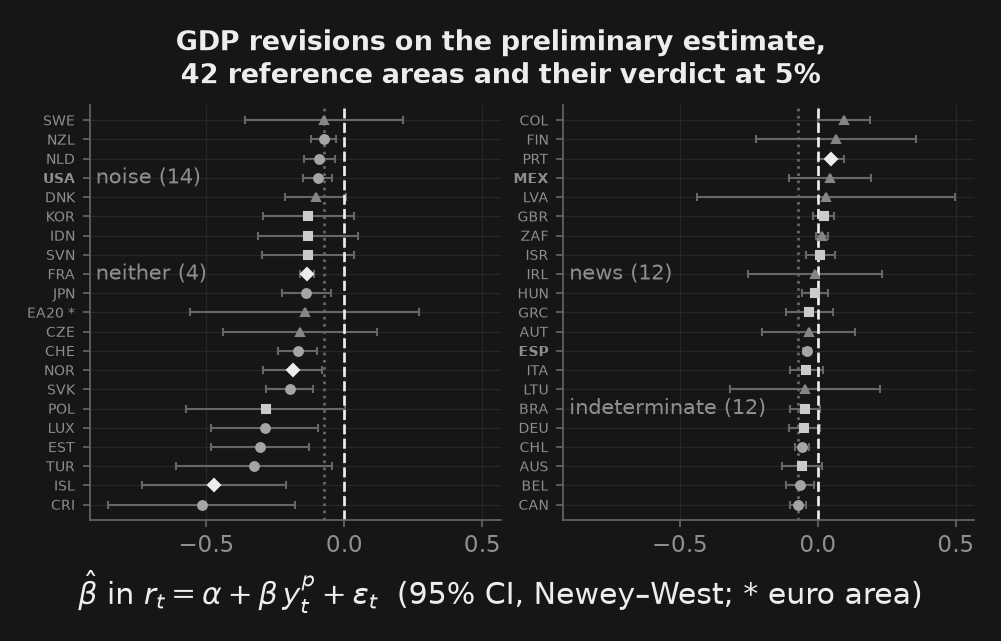

In [41]:
_MARK = {"noise": ("o", _nbstyle.UNIVERSAL_COLORS[1]), "news": ("^", _nbstyle.UNIVERSAL_COLORS[4]),
         "indeterminate": ("s", _nbstyle.UNIVERSAL_COLORS[3]), "neither": ("D", _nbstyle.UNIVERSAL_COLORS[0])}
_NAME = {"noise": "noise", "news": "news", "indeterminate": "indeterminate",
         "neither": "neither"}
forest = ms[ms["ok"]].sort_values("beta_on_preliminary").reset_index(drop=True)
forest["lo"] = forest["beta_on_preliminary"] - 1.96 * forest["se_beta_on_preliminary"]
forest["hi"] = forest["beta_on_preliminary"] + 1.96 * forest["se_beta_on_preliminary"]

# 42 rows in a single column fit neither the notebook nor the slot: they go in
# two columns of 21, from the most negative beta to the most positive.
ROWS = 21
fig, axes = _nbstyle.figura(1, 2, sharex=True, figsize=plt.rcParams["figure.figsize"])
slack = 0.05 * (forest["hi"].max() - forest["lo"].min())
median = float(forest["beta_on_preliminary"].median())
for j, ax in enumerate(axes):
    block = forest.iloc[j * ROWS:(j + 1) * ROWS]
    yf = np.arange(len(block))
    for verdict, (mk, col) in _MARK.items():
        m = (block["verdict"] == verdict).to_numpy()
        if not m.any():
            continue
        ax.errorbar(block.loc[m.nonzero()[0] + j * ROWS, "beta_on_preliminary"], yf[m],
                    xerr=1.96 * block.loc[m.nonzero()[0] + j * ROWS, "se_beta_on_preliminary"],
                    fmt=mk, color=col, ecolor=_nbstyle.SPINE, elinewidth=1.0, capsize=1.8,
                    ms=4.2, lw=0)
    ax.axvline(0, color=_nbstyle.TINTA, ls="--", lw=1.3)
    ax.axvline(median, color=_nbstyle.SPINE, ls=":", lw=1.3)
    ax.set_yticks(yf)
    ax.set_yticklabels([c + (" *" if c in AGGREGATES else "")
                        for c in block["country"]], fontsize=6.5)
    for i, c in enumerate(block["country"]):
        if c in ("USA", "MEX", "ESP"):
            ax.get_yticklabels()[i].set_fontweight("bold")
    ax.set_ylim(-0.8, ROWS - 0.2)
    ax.set_xlim(forest["lo"].min() - slack, forest["hi"].max() + slack)

# Each verdict is named at the height of its middle row, against the left
# margin: that is where the room is, and the four middle rows do not collide.
for verdict, (mk, col) in _MARK.items():
    rows = np.flatnonzero((forest["verdict"] == verdict).to_numpy())
    if not len(rows):
        continue
    i0 = int(rows[len(rows) // 2])
    axes[i0 // ROWS].annotate(f"{_NAME[verdict]} ({len(rows)})",
                              xy=(0.015, i0 % ROWS),
                              xycoords=("axes fraction", "data"),
                              ha="left", va="center", color=_nbstyle.NOTA,
                              fontsize="small")
fig.supxlabel("$\\hat{\\beta}$ in $r_t = \\alpha + \\beta\\, y^p_t + "
              "\\varepsilon_t$  (95% CI, Newey–West; * euro area)")
fig.suptitle(f"GDP revisions on the preliminary estimate,\n"
             f"{len(forest)} reference areas and their verdict at 5%")
plt.show()


#### Reading the cross-section

**The sign is a fact; the verdict in general is not.** $\hat{\beta}_p$ is negative in 33 of 41 countries and significantly negative in 17 — and significantly *positive* in **one**, Portugal, at $p = 0.045$: exactly what 41 tests at the 5% level produce by chance, and fewer than the two one would expect. That is the Mankiw–Shapiro result surviving a twentyfold increase in the number of countries asked, and what makes it convincing is precisely that it is one-sided: if the negative coefficients were sampling noise around zero we would expect about as many significant positives, and it is seventeen against one. What does *not* survive is the clean dichotomy. Only 14 areas come back as `noise` and 12 as `news`; **12 are `indeterminate`** — neither hypothesis is rejected, which with 108 quarters means the data cannot separate them, not that both are true — and **4 are `neither`**, where both regressions reject and the revision is demonstrably part measurement error and part genuine news. The honest summary of the literature's question is that most countries' revisions are a mixture, and the polar cases are the exception.

**The United States is the textbook case and is representative of nothing.** $\hat{\beta}_p = -0.097$ ($p < 0.001$), $\hat{\beta}_f = -0.012$ ($p = 0.88$): the cleanest `noise` verdict in the panel, and almost exactly what the same regression gives on the Philadelphia Fed's own real-time dataset, which the cell below checks — two archives built by different institutions on different principles, agreeing to the second decimal. Spain ($-0.040$), Canada ($-0.072$) and the Netherlands ($-0.091$) keep it company. But outside that group the verdict dissolves: only 17 of the 41 coefficients are significantly negative at the 5% level, and apart from Portugal's positive the rest have a confidence interval that crosses zero. The panel median, $-0.072$, says where the centre is, not what any one country rejects. And the largest coefficients in the panel — Costa Rica $-0.52$, Iceland $-0.47$, Estonia $-0.31$, Luxembourg $-0.29$ — belong to small, volatile economies with short archives, where a handful of quarters move the estimate.

**Mexico is where the filter earns its place.** Read off the archive as it arrives, Mexico's coefficient is $-0.31$ — three times the US figure, comfortably inside `noise`, and an open invitation to explain the gap by informal-sector imputation and survey timing. That explanation is available, it is plausible, and it is about a number that is not there. The OECD carried INEGI's unadjusted series from 2000-10 to 2006-09, and once those 72 editions are seasonally adjusted the coefficient is $+0.045$ with $p = 0.56$: indistinguishable from zero and, if anything, on the *news* side. The institutional story would have been fitted to a seasonal factor. That is §4's general lesson arriving in the very section that teaches it, and the reason the filter is in the notebook and not in a preprocessing script nobody reads.

**The bias nobody tests.** Mankiw and Shapiro's third diagnostic is the simplest: is the *mean* revision zero? It is positive in 37 of 41 countries, with a median of $+0.075$ pp per quarter — about $+0.30$ pp a year — and significantly different from zero in 16. First GDP estimates are not just noisy: they are **systematically low**, by a magnitude comparable to what macroeconomists argue about. Anyone reading a first release of $+0.3\%$ is looking, on the median country's record, at a $+0.4\%$.

**What dropping cost and what adjusting buys.** The treatment changes the diagnosis of the twelve affected areas in almost identical ways: the median standard deviation of their revisions falls from $2.21$ pp to $0.98$ pp, and six coefficients move by more than $0.4$ relative to the raw archive — Sweden $0.89$, Turkey $0.63$, Poland $0.57$, Czechia $0.45$, Austria and Slovakia $0.42$. Dropping the flagged editions would have produced coefficients a median $0.03$ away from these. The difference between the two treatments is not in the coefficient: it is that dropping costs **53 (area, quarter) pairs** and, above all, turns the "preliminary" of another **110** into an estimate the office had been publishing for up to six years — 25 Mexican quarters, 25 Swedish, 25 Turkish, 15 Austrian, 12 Czech, 6 Hungarian and 2 Irish. And across the thirty areas the office had already adjusted, running the same filter over them moves their coefficient a median $0.006$ and at most $0.055$ (Greece) without losing a single observation: the price of a homogeneous archive is essentially zero. A cross-country table built with none of this would have put Sweden, Turkey and Poland at the "noise" end of the panel and invited exactly the kind of institutional explanation exercise 11 asks for.

#### One country, two archives

The United States is the one economy where this test can be run twice on independent material. The OECD's archive is a monthly snapshot of what the OECD had ingested; the **Philadelphia Fed's Real-Time Data Set** is a separate construction, assembled from the vintages the Bureau of Economic Analysis itself published, on its own release calendar, going back to 1965. Different institution, different definition of a vintage, different sample by a factor of three.

If the coefficient is a property of how the BEA measures output, the two archives should agree. If it is a property of how one archive was assembled, they should not.

In [42]:
_phil = pd.read_csv(DATA / "philfed_routputMvQd.csv")
_vints = [c for c in _phil.columns if c.startswith("ROUTPUT")]
_p, _f = [], []
for i in range(1, len(_phil)):
    now, before = _phil.iloc[i][_vints], _phil.iloc[i - 1][_vints]
    live = ((~now.isna()) & (~before.isna())
            & (now != "NA") & (before != "NA"))
    if not live.any():
        continue
    first, last = live.idxmax(), _vints[-1]
    try:
        a, b = float(now[first]), float(before[first])
        c, d = float(now[last]), float(before[last])
    except (TypeError, ValueError):
        continue
    if b > 0 and d > 0:
        _p.append(100.0 * np.log(a / b))
        _f.append(100.0 * np.log(c / d))

phil = mankiw_shapiro(pd.Series(_p), pd.Series(_f), hac_lags="auto")
oecd_us = _res["USA"]
print("The same regression, the same country, two independent archives:\n")
print(f"  {'':22s}{'n':>6s}{'beta_p':>10s}{'se':>8s}{'p':>9s}{'verdict':>16s}")
for name, r in (("OECD STES revisions", oecd_us),
                ("Philadelphia Fed RTDS", phil)):
    print(f"  {name:22s}{r.n_obs:6d}{r.beta_on_preliminary:+10.3f}"
          f"{r.se_beta_on_preliminary:8.3f}{r.p_beta_on_preliminary:9.4f}"
          f"{r.verdict:>16s}")
print(f"\nThey differ by {abs(phil.beta_on_preliminary - oecd_us.beta_on_preliminary):.3f} "
      f"— less than either standard error — on samples of "
      f"{oecd_us.n_obs} and {phil.n_obs} quarters that\noverlap only in part and were "
      f"assembled by different institutions from different vintages.\nThe United "
      f"States' coefficient is a fact about the BEA, not about an archive.")

assert phil.verdict == oecd_us.verdict == "noise"
assert abs(phil.beta_on_preliminary - oecd_us.beta_on_preliminary) < 0.05

The same regression, the same country, two independent archives:

                             n    beta_p      se        p         verdict
  OECD STES revisions      109    -0.097   0.027   0.0005           noise
  Philadelphia Fed RTDS    316    -0.115   0.028   0.0001           noise

They differ by 0.017 — less than either standard error — on samples of 109 and 316 quarters that
overlap only in part and were assembled by different institutions from different vintages.
The United States' coefficient is a fact about the BEA, not about an archive.


#### What else the panel is for

The revision triangle is the object underneath all of this, and it is worth looking at once directly: the rows are reference quarters, the columns are editions, and reading across a row is watching one quarter's history get rewritten. The cell below prints the corner of the US triangle covering the 2008–09 recession, in the growth rates the test actually uses.

In [43]:
tri = rev_sa.triangle("USA", transform="log_diff_pct")
# The first edition that could contain 2008Q4, then 3, 6, 18 and 78 months
# later, then today's. Chosen by nearest available edition rather than by
# hard-coded dates, so a refreshed archive still lands somewhere sensible.
_want = [pd.Timestamp("2009-02-01") + pd.DateOffset(months=m)
         for m in (0, 3, 6, 18, 78)]
_sel = sorted({min(tri.columns, key=lambda c: abs(c - w)) for w in _want}
              | {tri.columns.max()})
corner = tri.loc["2008-04-01":"2009-07-01", _sel]
print("US real GDP, % q/q, as it stood in each edition (last column = latest):")
print(corner.round(2).to_string())
q4 = rev_sa.revisions("USA").loc["2008-10-01"]
print(f"\n2008Q4 was first published as {q4['preliminary']:+.2f}% and now stands "
      f"at {q4['final']:+.2f}% — a revision of {q4['revision']:+.2f} pp, "
      f"{abs(q4['revision']) / _res['USA'].std_revision:.1f} times the standard "
      f"deviation of US revisions and {abs(q4['revision']) / abs(q4['preliminary']):.1f} "
      f"times the number first announced. The depth of the worst quarter of the "
      f"Great Recession was not known in real time, and the row above shows it "
      f"still moving in 2015.")

US real GDP, % q/q, as it stood in each edition (last column = latest):
vintage     2009-02-01  2009-05-01  2009-08-01  2010-08-01  2015-08-01  2026-08-01
date                                                                              
2008-04-01        0.51        0.46        0.23        0.03        0.32        0.48
2008-07-01       -0.18       -0.23       -0.71       -1.00       -0.53       -0.55
2008-10-01       -0.85       -1.52       -1.41       -1.81       -2.18       -2.22
2009-01-01         NaN       -1.36       -1.46       -1.09       -1.14       -1.00
2009-04-01         NaN         NaN       -0.39       -0.30       -0.31       -0.29
2009-07-01         NaN         NaN         NaN        0.42        0.28        0.32



2008Q4 was first published as -0.85% and now stands at -2.22% — a revision of -1.36 pp, 3.6 times the standard deviation of US revisions and 1.6 times the number first announced. The depth of the worst quarter of the Great Recession was not known in real time, and the row above shows it still moving in 2015.


#### Every component, not just the headline

Everything above tests **one series**. `DSD_STES_REVISIONS` carries **nine**: the two faces of GDP with the deflator between them, five expenditure components, and employment. The other eight have never been put through this test across countries, and there are two reasons they should be.

The first is that GDP is an **aggregate**, and an aggregate of imperfectly correlated measurement errors is quieter than the errors it aggregates. If $y = \sum_i s_i x_i$ and each $x_i$ carries its own noise $\eta_i$, the aggregate's noise variance is $\sum_i s_i^2 \sigma_i^2 + \sum_{i \neq j} s_i s_j \sigma_{ij}$: the weights enter **squared**, and with uncorrelated errors the cross terms vanish altogether. "GDP revisions are noise" is therefore the *mildest* form of the claim available — it is tested on the one object in the accounts that averaging protects.

The second is that nothing in macroeconomics is calibrated to GDP alone. $\sigma(c)/\sigma(y)$ — the stylized fact §4.2 is about to take apart — needs consumption. The investment volatility RBC models are judged on needs GFCF. Fiscal multipliers need government consumption. §2.2 and §2.4 of this notebook are built on deflators and on the durables split. Every one of those is a component, and the revision properties of components are simply not known.

So: the same test, the same screen, the same filter, over all nine. One archive at a time and each released before the next is read — together they are eight million rows, and nothing here needs two of them alive at once.

In [44]:
# The nine measures the revisions archive carries, with the frozen archive and
# the published units of each. GDP's is §4.1's, already used above; the other
# eight were pulled the same way on the same day and are trimmed to reference
# quarters from 1994Q4 on.
#
# The trim is not a shortcut. `revisions()` drops every quarter that ended
# before the archive's first edition — that is `require_observable_first`, and
# without it a quarter of 1975 would be paired with a "preliminary" published
# in 1999 — and the seasonal window opens in 1995Q1, so nothing below can see
# a quarter earlier than 1994Q4 anyway. Checked against the untrimmed
# download: not one coefficient moves, and the screen flags the same editions.
# What it buys is a third off the disk and a third off the peak, which on a
# tablet is the binding constraint and not a convenience.
STES_COMPONENTS = {
    "gdp_real":     ("GDP, volume",            "level",
                     "oecd_stes_vintages_gdp.csv.gz"),
    "gdp_nom":      ("GDP, current prices",    "level",
                     "oecd_stes_comp_gdp_nom.csv.gz"),
    "deflator":     ("GDP deflator",           "index",
                     "oecd_stes_comp_deflator.csv.gz"),
    "con_real":     ("Household consumption",  "level",
                     "oecd_stes_comp_con_real.csv.gz"),
    "govcon_real":  ("Government consumption", "level",
                     "oecd_stes_comp_govcon_real.csv.gz"),
    "gfcf_real":    ("Fixed investment",       "level",
                     "oecd_stes_comp_gfcf_real.csv.gz"),
    "exports_real": ("Exports",                "level",
                     "oecd_stes_comp_exports_real.csv.gz"),
    "imports_real": ("Imports",                "level",
                     "oecd_stes_comp_imports_real.csv.gz"),
    "employment":   ("Employment",             "level",
                     "oecd_stes_comp_employment.csv.gz"),
}
#: The expenditure components proper — the ones that add up to GDP. The two
#: faces of GDP, its deflator and employment are in the sweep for their own
#: sake and would make the "do the errors cancel?" question circular.
EXPENDITURE = ("con_real", "govcon_real", "gfcf_real", "exports_real",
               "imports_real")


def component_panel(variable):
    """One measure's archive as a `VintagePanel`, ready for the same filter.

    Returns ``(panel, n_masked)``. Two details that only surface outside GDP.

    **A zero is not a level.** A few editions pad the start of a series with a
    literal ``0`` — one December-2014 edition of UK household consumption does
    it for eight quarters — and ``log(0)`` is ``-inf``, which would poison
    that edition's four quarterly means and through them every quarter the
    filter touches in it. They are masked to missing *before* anything takes a
    logarithm, and counted, so the masking is visible rather than tacit. The
    GDP archive contains none, which is why §4.1 never had to say this.

    **Units decide the transform.** Eight of the nine are levels and one, the
    deflator, is an index. `UNITS_TRANSFORM` sends both to `log_diff_pct`, so
    the deflator enters the regression as an inflation rate — the right
    object, and worth declaring rather than inheriting by accident.
    """
    _label, units, fname = STES_COMPONENTS[variable]
    s = archive(DATA / fname)
    v = s["value"]
    return VintagePanel(df=pd.DataFrame({
        "country": s["code"], "variable": variable, "date": s["date"],
        "vintage": pd.to_datetime(s["edition"], format="%Y%m"),
        "value": v.where(v > 0),
        "provider": pd.Categorical(["oecd_stes"] * len(s)),
        "series_id": pd.Categorical(s["code"]),
        "units": pd.Categorical([units] * len(s)),
    })), int((v <= 0).sum())


_rows_c, revs, _cover = [], {}, []
for _v in STES_COMPONENTS:
    _p, _bad = component_panel(_v)
    _sig = seasonal_signature(_p)
    _sa, _ = deseasonalize_editions(_p, receipt=False)
    _cover.append({"component": STES_COMPONENTS[_v][0],
                   "areas": _sa.df["country"].nunique(),
                   "editions": len(_sig),
                   "flagged": int(_sig["unadjusted"].sum()),
                   "zeros masked": _bad})
    del _p, _sig
    for _c, _g in _sa.df.groupby("country", sort=True):
        _fr = VintagePanel(df=_g, metadata=_sa.metadata).revisions(_c)
        if len(_fr) < MIN_OBS_MS:
            _rows_c.append({"variable": _v, "country": _c, "n_obs": len(_fr),
                            "ok": False, "note": f"only {len(_fr)} pairs"})
            continue
        _r = mankiw_shapiro(_fr["preliminary"], _fr["final"], hac_lags="auto",
                            transform="log_diff_pct")
        # Same schema as `ms` above, plus the two columns this part needs:
        # the bias p-value, and the dispersion of y^p itself — because beta_p
        # is a variance RATIO, and a small coefficient on a wild series is not
        # a small error.
        _rows_c.append({**_row(_c, _r), "variable": _v,
                        "p_bias": _r.p_mean_revision,
                        "sd_prelim": float(np.std(_fr["preliminary"], ddof=1))})
        revs[(_v, _c)] = _fr["revision"]
    del _sa
    # `archive` memoizes by path: a help when one frame is read twice, a leak
    # when nine are read once.
    _ARCHIVES.clear()

comp_ms = pd.DataFrame(_rows_c)
comp_ms["is_aggregate"] = comp_ms["country"].isin(AGGREGATES)
LAB = {v: t[0] for v, t in STES_COMPONENTS.items()}

print("The revisions archive, measure by measure. Same screen as above, and "
      "it has to be run\nagain for each: the archive switched over to "
      "adjusted series at its own pace for every\nmeasure separately.\n")
print(pd.DataFrame(_cover).set_index("component").to_string())

okc = comp_ms[comp_ms["ok"] & ~comp_ms["is_aggregate"]].copy()
okc["neg"] = okc["beta_on_preliminary"] < 0
okc["signeg"] = okc["neg"] & (okc["p_beta_on_preliminary"] < 0.05)
okc["sigpos"] = ~okc["neg"] & (okc["p_beta_on_preliminary"] < 0.05)
okc["sigbias"] = okc["p_bias"] < 0.05
_g = okc.groupby("variable", sort=False)
summary = pd.DataFrame({
    "areas": _g.size(),
    "n": _g["n_obs"].median(),
    "sd(y^p)": _g["sd_prelim"].median(),
    "sd(r)": _g["std_revision"].median(),
    "beta_p": _g["beta_on_preliminary"].median(),
    "<0": _g["neg"].sum(),
    "sig-": _g["signeg"].sum(),
    "sig+": _g["sigpos"].sum(),
    "bias": _g["mean_revision"].median(),
    "sig bias": _g["sigbias"].sum(),
}).rename(index=LAB)
print(f"\nThe Mankiw–Shapiro pair on each: {len(okc)} (component, area) "
      f"regressions, countries only.\n'sd(y^p)' is the dispersion of the "
      f"preliminary growth rate itself; 'bias' is the mean revision,\nin pp "
      f"per quarter.\n")
print(summary.round(3).to_string())
print("\nVerdicts at 5%:")
print(pd.crosstab(okc["variable"].map(LAB), okc["verdict"]).to_string())

# GDP is not merely one of these: it is the mildest of them.
assert float(summary.loc[LAB["gdp_real"], "beta_p"]) > float(
    summary.drop(index=LAB["gdp_real"])["beta_p"].max())

The revisions archive, measure by measure. Same screen as above, and it has to be run
again for each: the archive switched over to adjusted series at its own pace for every
measure separately.

                        areas  editions  flagged  zeros masked
component                                                     
GDP, volume                42     11434      501             0
GDP, current prices        42     11500      668             0
GDP deflator               39     10563      162             0
Household consumption      42     11334      649             8
Government consumption     42     11333      569             0
Fixed investment           41     11089      470             0
Exports                    42     11342      454             0
Imports                    42     11343      512             0
Employment                 31      6744      104             0

The Mankiw–Shapiro pair on each: 347 (component, area) regressions, countries only.
'sd(y^p)' is the dispersion 

In [45]:
# The aggregation argument, made to answer. Two facts, and the second is what
# turns the first from a curiosity into a mechanism.
beta_c = okc.pivot(index="country", columns="variable",
                   values="beta_on_preliminary")
sd_c = okc.pivot(index="country", columns="variable", values="std_revision")
OTHERS_C = [v for v in STES_COMPONENTS if v != "gdp_real"]

print("Is GDP revised less than the things it is made of? Area by area, on "
      "the two scales\nthat matter — how big the revision is, and how much of "
      "the first release's variance the\ntest charges to measurement error:\n")
print(pd.DataFrame({
    "sd(r) smaller for GDP": [
        f"{int((sd_c['gdp_real'] < sd_c[v]).sum())}/"
        f"{int(sd_c[v].notna().sum())}" for v in OTHERS_C],
    "|beta_p| smaller for GDP": [
        f"{int((beta_c['gdp_real'].abs() < beta_c[v].abs()).sum())}/"
        f"{int(beta_c[v].notna().sum())}" for v in OTHERS_C],
    "median sd(r)": [float(sd_c[v].median()) for v in OTHERS_C],
    "median beta_p": [float(beta_c[v].median()) for v in OTHERS_C],
}, index=[LAB[v] for v in OTHERS_C]).round(3).to_string())
print(f"\nGDP itself: median sd(r) {float(sd_c['gdp_real'].median()):.3f} pp, "
      f"median beta_p {float(beta_c['gdp_real'].median()):+.3f}.")
print(f"\nEmployment is the exception on the first column and the argument "
      f"for the second. Its revision is\nSMALLER than GDP's in "
      f"{int((sd_c['employment'] < sd_c['gdp_real']).sum())} of "
      f"{int(sd_c['employment'].notna().sum())} areas — "
      f"{float(sd_c['employment'].median()):.3f} pp against "
      f"{float(sd_c['gdp_real'].median()):.3f} — and yet its coefficient is "
      f"worse,\n{float(beta_c['employment'].median()):+.3f} against "
      f"{float(beta_c['gdp_real'].median()):+.3f}, because employment growth "
      f"barely moves: sd(y^p) of "
      f"{float(okc.loc[okc['variable'] == 'employment', 'sd_prelim'].median()):.3f} "
      f"pp\nagainst GDP's "
      f"{float(okc.loc[okc['variable'] == 'gdp_real', 'sd_prelim'].median()):.3f}. "
      f"A small error on a placid series is still most of its variance. It is "
      f"also not an\nexpenditure component — it comes from the labour force "
      f"survey and the payroll registers, not from\nthe accounts — so it is "
      f"outside the averaging argument, which is exactly why it behaves "
      f"differently.")

# And the reason. If the component errors moved together the aggregate would
# inherit all of their noise instead of averaging it away, so the mechanism is
# checkable: pairwise, area by area, on the quarters each pair shares.
_pairs = []
for _c in sorted(set(okc["country"])):
    _have = {v: revs[(v, _c)] for v in EXPENDITURE if (v, _c) in revs}
    _keys = sorted(_have)
    for _i, _a in enumerate(_keys):
        for _b in _keys[_i + 1:]:
            _j = pd.concat({"a": _have[_a], "b": _have[_b]}, axis=1,
                           sort=True).dropna()
            if len(_j) >= 40:
                _pairs.append({"pair": f"{_a} | {_b}",
                               "corr": float(_j["a"].corr(_j["b"]))})
pairw = pd.DataFrame(_pairs)
_notxm = pairw[pairw["pair"] != "exports_real | imports_real"]
print(f"\nCorrelation between two expenditure components' revisions, over "
      f"{len(pairw)} (area, pair) samples:\n  median "
      f"{pairw['corr'].median():+.3f} — {_notxm['corr'].median():+.3f} "
      f"once the one correlated pair below is set aside — and |corr| under "
      f"0.3\n  in {(_notxm['corr'].abs() < 0.3).mean():.0%} of the rest. "
      f"Nearly orthogonal, which is exactly the condition under which the\n"
      f"  aggregate is quieter than its parts, and the reason the "
      f"literature's headline result is the\n  weakest one the accounts can "
      f"be asked for.")
print("\n  by pair (median across areas):")
_bypair = pairw.groupby("pair")["corr"].median().sort_values()
print(_bypair.rename(index=lambda k: " | ".join(LAB[v] for v in k.split(" | ")))
      .round(3).to_string())

# One pair does move together, and it is the one where that HELPS. Net exports
# enter GDP as s_X x - s_M m, with opposite signs, so a positive covariance
# between their two measurement errors is SUBTRACTED from the aggregate's
# variance instead of added to it. Customs data arrive late for both legs at
# once; the accounting then cancels most of what that costs.
_xm = float(_bypair.get("exports_real | imports_real", float("nan")))
print(f"\n  The one exception is exports against imports, at {_xm:+.3f} — and "
      f"it is the pair where correlation\n  helps rather than hurts: net "
      f"exports enter GDP as $s_X x - s_M m$, so that covariance is "
      f"subtracted,\n  not added. Late customs returns move both legs "
      f"together and the identity cancels most of it.")

# GDP is the quietest of the things it is MADE of; employment, which it is
# not made of, is quieter still in levels and worse as a ratio.
for _v in EXPENDITURE:
    assert (sd_c["gdp_real"] < sd_c[_v]).mean() > 0.75, _v
assert (sd_c["employment"] < sd_c["gdp_real"]).sum() > 0.8 * int(
    sd_c["employment"].notna().sum())
assert abs(pairw["corr"].median()) < 0.15
assert _xm == max(_bypair)      # and it is the largest of the ten

Is GDP revised less than the things it is made of? Area by area, on the two scales
that matter — how big the revision is, and how much of the first release's variance the
test charges to measurement error:

                       sd(r) smaller for GDP |beta_p| smaller for GDP  median sd(r)  median beta_p
GDP, current prices                    37/41                    24/41         0.906         -0.125
GDP deflator                           20/38                    29/38         0.766         -0.319
Household consumption                  33/41                    26/41         0.915         -0.120
Government consumption                 36/41                    38/41         1.508         -0.624
Fixed investment                       40/40                    33/40         2.415         -0.263
Exports                                41/41                    25/41         2.177         -0.111
Imports                                41/41                    24/41         2.087         -0.114
E

In [46]:
# Volume or price: which side of the nominal figure gets rewritten?
#
# Within an edition B1GQ_V ~ B1GQ_Q x B1GQ_D, so in log growth the nominal
# revision splits into a volume revision and a price revision,
#
#     r_V = r_Q + r_D,   Var(r_V) = Var(r_Q) + Var(r_D) + 2 Cov(r_Q, r_D),
#
# and the covariance is the interesting term. The textbook intuition is that
# an office measures the nominal total well — VAT and payroll records — and
# then argues about how to split it, which would make the covariance strongly
# negative and the nominal figure the STABLE one. The identity is not exact in
# this archive (three measures, each published rounded, each on its own base),
# so the cell measures the residual first and reports it instead of assuming
# it away.
_dec = []
for _c in sorted(set(okc["country"])):
    if not all((v, _c) in revs for v in ("gdp_real", "deflator", "gdp_nom")):
        continue
    _q = pd.concat({v: revs[(v, _c)]
                    for v in ("gdp_real", "deflator", "gdp_nom")},
                   axis=1, sort=True).dropna()
    if len(_q) < 40:
        continue
    _vq, _vd = _q["gdp_real"].var(ddof=1), _q["deflator"].var(ddof=1)
    _cv = float(_q[["gdp_real", "deflator"]].cov().iloc[0, 1])
    _tot = _vq + _vd + 2 * _cv
    _dec.append({
        "area": _c, "n": len(_q),
        "sd r_V": _q["gdp_nom"].std(ddof=1),
        "sd r_Q": _q["gdp_real"].std(ddof=1),
        "sd r_D": _q["deflator"].std(ddof=1),
        "residual": float((_q["gdp_nom"] - _q["gdp_real"]
                           - _q["deflator"]).std(ddof=1)),
        "corr(r_Q,r_D)": float(_q["gdp_real"].corr(_q["deflator"])),
        "volume": _vq / _tot, "price": _vd / _tot, "2cov": 2 * _cv / _tot})
vp_all = pd.DataFrame(_dec).set_index("area")
vp_all["resid share"] = vp_all["residual"] / vp_all["sd r_V"]
# Where the residual is a quarter of the nominal revision or more, the three
# series are not three views of one number and the split cannot be read. Four
# areas fail, and they are named rather than quietly dropped: Greece is the
# extreme, its three measures sitting on bases that disagree by 16% inside a
# single edition. The rest of the cell uses the areas where the identity holds.
BAD_ID = 0.25
vp = vp_all[vp_all["resid share"] < BAD_ID].drop(columns="resid share")
_out = vp_all[vp_all["resid share"] >= BAD_ID]

print(f"The nominal revision split into volume and price, for the "
      f"{len(vp_all)} areas publishing all three\n(the twelve with the "
      f"largest nominal revisions):\n")
print(vp_all.sort_values("sd r_V", ascending=False).head(12)
      .round(3).to_string())
print(f"\nFirst, does the identity hold? r_V - r_Q - r_D has a standard "
      f"deviation of {vp_all['residual'].median():.3f} pp against a\nnominal "
      f"revision of {vp_all['sd r_V'].median():.3f} pp — "
      f"{vp_all['resid share'].median():.0%} of it at the median, which is "
      f"rounding. It does NOT hold for\n{len(_out)} areas ("
      + ", ".join(f"{c} {vp_all.loc[c, 'resid share']:.0%}"
                  for c in _out.index) +
      f"), whose three measures are\nnot three views of one number; they are "
      f"named here and left out of the split below.")
print(f"\nVolume and price revisions ARE negatively correlated, in "
      f"{int((vp['corr(r_Q,r_D)'] < 0).sum())} of {len(vp)} areas, median "
      f"{vp['corr(r_Q,r_D)'].median():+.3f}:\nthe office does move the "
      f"deflator against the volume. But only a little. Var(r_V) splits into "
      f"volume\n{vp['volume'].median():.2f}, price "
      f"{vp['price'].median():.2f} and twice the covariance "
      f"{vp['2cov'].median():+.2f} at the median — an offset of a fifth, not "
      f"the\nreallocation of a known total. And the nominal figure ends up "
      f"revised MORE than the volume\nin {int((vp['sd r_V'] > vp['sd r_Q']).sum())} "
      f"of {len(vp)} areas, not less. Whatever the office knows first, it is "
      f"not nominal GDP.")

assert (vp["residual"] / vp["sd r_V"]).median() < 0.25
assert (vp["corr(r_Q,r_D)"] < 0).mean() > 0.6

The nominal revision split into volume and price, for the 34 areas publishing all three
(the twelve with the largest nominal revisions):

        n  sd r_V  sd r_Q  sd r_D  residual  corr(r_Q,r_D)  volume  price   2cov  resid share
area                                                                                         
TUR   108   3.393   1.987   2.774     0.321          0.009   0.336  0.655  0.009        0.094
IRL    93   3.233   3.228   2.052     1.501         -0.239   0.909  0.367 -0.276        0.464
ISL    92   2.852   2.671   2.120     0.380         -0.326   0.898  0.566 -0.464        0.133
GRC    88   2.131   1.262   0.925     1.879         -0.399   1.050  0.564 -0.615        0.882
LUX    79   1.940   1.421   1.455     0.296         -0.119   0.554  0.580 -0.135        0.152
NOR   108   1.610   0.729   1.553     0.018         -0.154   0.205  0.929 -0.135        0.011
EST    60   1.379   0.931   0.923     0.935         -0.137   0.585  0.574 -0.159        0.678
HUN    92   1.28

In [47]:
# Nine measures times forty-odd areas is a great many tests, and §4.1 has so
# far argued from one-sidedness alone — seventeen significant negatives
# against one positive. On this grid the argument can be made properly.
# Benjamini and Hochberg (1995) control the expected share of FALSE
# discoveries among the rejections, which is the relevant quantity when the
# question is "how many of these are real?" rather than "is this particular
# country's coefficient real?". Six lines of numpy: no extra package, and none
# would be available on a tablet anyway.
def bh_reject(p, q=0.05):
    """Benjamini–Hochberg step-up. True where the null is rejected at FDR q."""
    p = np.asarray(p, dtype=float)
    order = np.argsort(p)
    m = len(p)
    below = p[order] <= q * np.arange(1, m + 1) / m
    out = np.zeros(m, dtype=bool)
    if below.any():
        out[order[:int(np.nonzero(below)[0].max()) + 1]] = True
    return out


grid = okc.dropna(subset=["p_beta_on_preliminary"]).copy()
grid["bh"] = bh_reject(grid["p_beta_on_preliminary"])
kept = grid[grid["bh"]]
print(f"{len(grid)} news regressions, one per (component, area).")
print(f"  p < 0.05 unadjusted: "
      f"{int((grid['p_beta_on_preliminary'] < 0.05).sum())}, against the "
      f"{0.05 * len(grid):.0f} the null alone would produce.")
print(f"  surviving Benjamini–Hochberg at FDR 5%: {len(kept)} — "
      f"{int((kept['beta_on_preliminary'] < 0).sum())} negative, "
      f"{int((kept['beta_on_preliminary'] > 0).sum())} positive.")
print("  by component: " + ", ".join(
    f"{LAB[v]} {n}/{int((grid['variable'] == v).sum())}"
    for v, n in kept.groupby("variable").size().items()))
print(f"\nAt most {0.05 * len(kept):.0f} of those {len(kept)} are expected to "
      f"be false. Whatever is wrong with the first\nrelease of the national "
      f"accounts is not confined to one economy, not confined to GDP, and "
      f"not\na multiple-comparisons artefact.")

assert len(kept) > 100
assert int((kept["beta_on_preliminary"] < 0).sum()) > 20 * max(
    int((kept["beta_on_preliminary"] > 0).sum()), 1)

347 news regressions, one per (component, area).
  p < 0.05 unadjusted: 196, against the 17 the null alone would produce.
  surviving Benjamini–Hochberg at FDR 5%: 176 — 174 negative, 2 positive.
  by component: Household consumption 20/41, GDP deflator 26/38, Employment 9/23, Exports 15/41, GDP, current prices 20/41, GDP, volume 17/41, Fixed investment 24/40, Government consumption 31/41, Imports 14/41

At most 9 of those 176 are expected to be false. Whatever is wrong with the first
release of the national accounts is not confined to one economy, not confined to GDP, and not
a multiple-comparisons artefact.


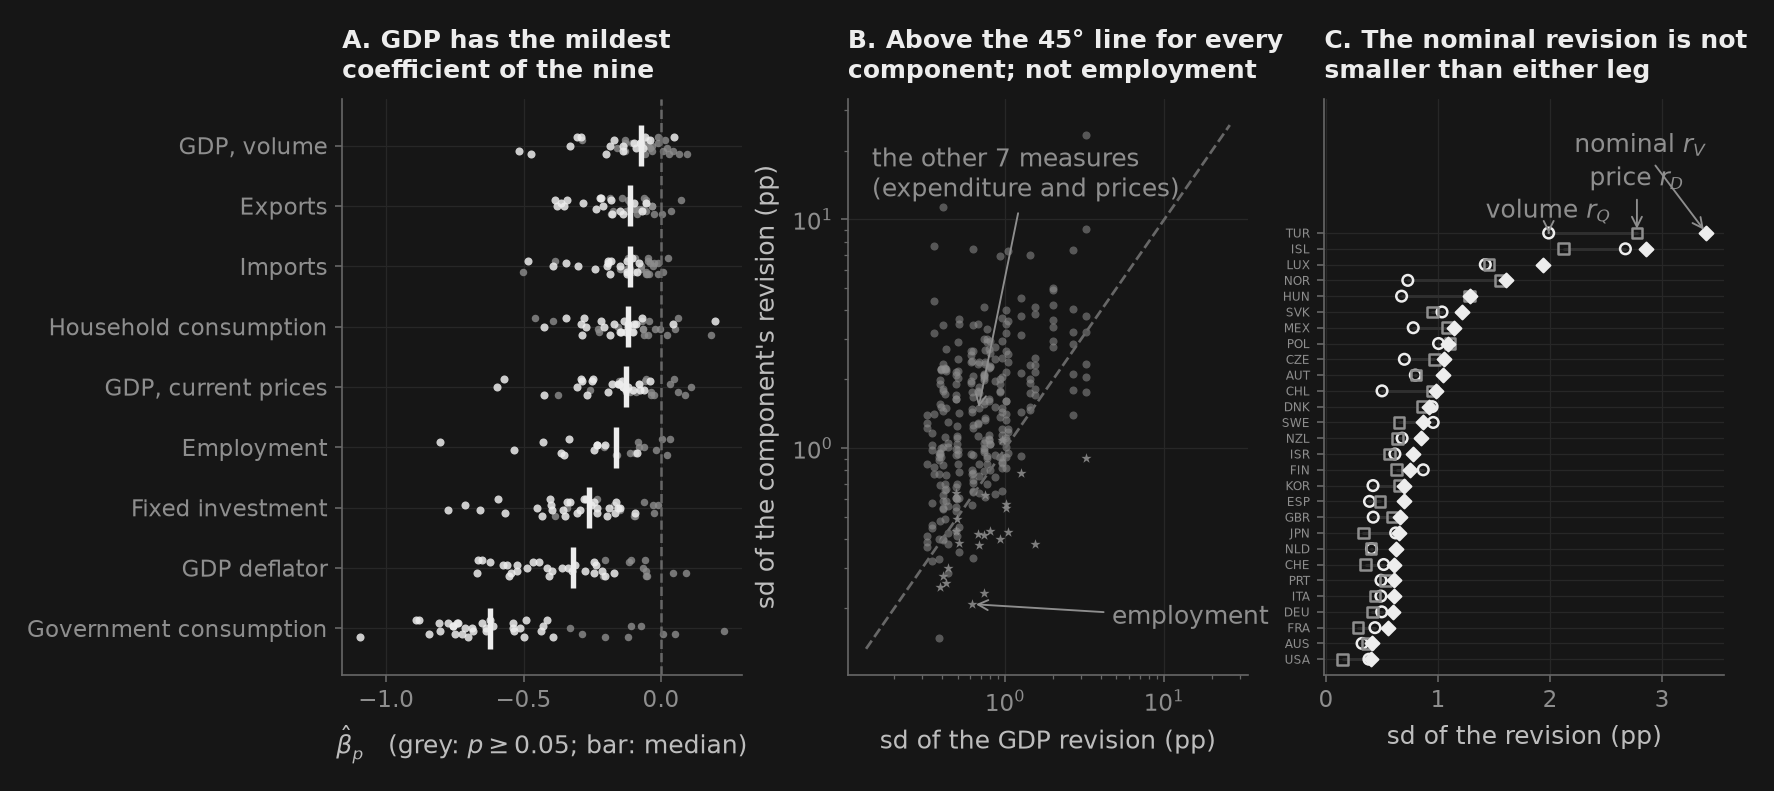

In [48]:
# 33 dumbbell rows in C: no TAMANO size gives the height, so it is set by hand
# (the width of "3", taller).
fig, (axA, axB, axC) = _nbstyle.figura(1, 3, figsize=(11.4, 5.0))
_order = (okc.groupby("variable")["beta_on_preliminary"].median()
          .sort_values().index.tolist())

# A. every (component, area) coefficient, component by component
for _i, _v in enumerate(_order):
    _d = okc[okc["variable"] == _v]
    _jit = (np.arange(len(_d)) % 7 - 3) / 22.0
    _sg = (_d["p_beta_on_preliminary"] < 0.05).to_numpy()
    _bp = _d["beta_on_preliminary"].to_numpy()
    axA.scatter(_bp[~_sg], _i + _jit[~_sg], s=13, color=_nbstyle.NOTA, alpha=.8, lw=0)
    axA.scatter(_bp[_sg], _i + _jit[_sg], s=15, color=cols[0], alpha=.85, lw=0)
    axA.plot([np.median(_bp)] * 2, [_i - 0.34, _i + 0.34], color=_nbstyle.TINTA,
             lw=2.6, ls="-", solid_capstyle="butt")
axA.axvline(0, color=_nbstyle.SPINE, ls="--", lw=1.2)
axA.set_yticks(range(len(_order)))
axA.set_yticklabels([LAB[v] for v in _order])
axA.set_xlabel("$\\hat{\\beta}_p$   (grey: $p \\geq 0.05$; bar: median)")
axA.set_title("A. GDP has the mildest\ncoefficient of the nine")

# B. the same claim without a coefficient in it: how big the revisions are.
# Employment gets a star and a name; the other measures share one marker,
# because what has to be seen is that all of them sit above the line.
for _v in [v for v in _order if v != "gdp_real"]:
    _j = sd_c[["gdp_real", _v]].dropna()
    _emp = _v == "employment"
    axB.scatter(_j["gdp_real"], _j[_v], s=26 if _emp else 15,
                alpha=0.9 if _emp else 0.55, marker="*" if _emp else "o", lw=0,
                color=cols[3] if _emp else _nbstyle.NOTA, zorder=3 if _emp else 2)
_hi = float(np.nanmax(sd_c.to_numpy())) * 1.1
_lo = float(np.nanmin(sd_c.to_numpy())) * 0.9
axB.plot([_lo, _hi], [_lo, _hi], color=_nbstyle.SPINE, ls="--", lw=1.3)
axB.set_xscale("log"); axB.set_yscale("log")
axB.set_xlabel("sd of the GDP revision (pp)")
axB.set_ylabel("sd of the component's revision (pp)")
axB.set_title("B. Above the 45° line for every\ncomponent; not employment")
_e = sd_c[["gdp_real", "employment"]].dropna()
_k = _e["employment"].idxmin()
axB.annotate("employment", xy=(float(_e.loc[_k, "gdp_real"]), float(_e.loc[_k, "employment"])),
             xytext=(0.66, 0.10), textcoords="axes fraction", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
_others = sd_c[[v for v in _order if v not in ("gdp_real", "employment")]].stack()
_x_others = sd_c["gdp_real"].reindex(_others.index.get_level_values(0))
axB.annotate(f"the other {len(_order) - 2} measures\n(expenditure and prices)",
             xy=(float(_x_others.median()), float(_others.median())),
             xytext=(0.06, 0.92), textcoords="axes fraction", ha="left", va="top",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

# C. the nominal figure against the two legs it is made of. If the office knew
# the nominal total first and only argued about the split, the solid dot would
# sit to the LEFT of both open ones in every row. It sits to the right.
_s = vp.sort_values("sd r_V")
_y = np.arange(len(_s))
for _i, (_a, _r) in enumerate(_s.iterrows()):
    axC.plot([min(_r["sd r_Q"], _r["sd r_D"]), max(_r["sd r_Q"], _r["sd r_D"])],
             [_i, _i], color=_nbstyle.gris("0.82"), lw=1.4, ls="-", zorder=1)
axC.scatter(_s["sd r_Q"], _y, s=26, facecolors="none", edgecolors=cols[0], lw=1.2, zorder=2)
axC.scatter(_s["sd r_D"], _y, s=26, facecolors="none", edgecolors=_nbstyle.NOTA,
            lw=1.2, marker="s", zorder=2)
axC.scatter(_s["sd r_V"], _y, s=22, color=_nbstyle.TINTA, marker="D", zorder=3)
axC.set_yticks(_y); axC.set_yticklabels(_s.index, fontsize=5.8)
axC.set_ylim(-1, len(_s) + 7.5)
axC.set_xlabel("sd of the revision (pp)")
axC.set_title("C. The nominal revision is not\nsmaller than either leg")
# The three markers are named over the top row, the most spread-out one, each
# name on its own line: on a single line the three collide.
_top = _s.iloc[-1]
for _dy, _ha, _col, _txt in ((4, "center", "sd r_Q", "volume $r_Q$"),
                             (20, "center", "sd r_D", "price $r_D$"),
                             (36, "right", "sd r_V", "nominal $r_V$")):
    axC.annotate(_txt, xy=(float(_top[_col]), len(_s) - 1), xytext=(0, _dy),
                 textcoords="offset points", ha=_ha, va="bottom", color=_nbstyle.NOTA,
                 arrowprops=_nbstyle.FLECHA)
plt.show()


#### Reading the component sweep

**GDP is the quietest of the things it is made of, and that is a fact about averaging rather than about care.** The median $\hat{\beta}_p$ is $-0.072$ for GDP volume — the mildest of all nine — against $-0.62$ for government consumption, $-0.32$ for the deflator, $-0.26$ for fixed investment, $-0.17$ for employment, $-0.13$ for nominal GDP, $-0.12$ for household consumption and $-0.11$ for each leg of trade. On the scale that needs no coefficient at all the ordering among the expenditure components is starker still: GDP's revision is smaller than fixed investment's in **40 of 40** areas, than exports' in **41 of 41**, than imports' in **41 of 41**, than government consumption's in 36 of 41, than nominal GDP's in 37 of 41 and than household consumption's in 33 of 41. Panel B is that fact. So the twenty years of literature that tested the aggregate and found modest measurement error were testing the *mildest* claim the accounts support.

**And the mechanism is checkable, not rhetorical.** An average is quieter than its parts only if the parts' errors fail to move together, and they fail: the median correlation between two expenditure components' revisions is $+0.035$ across 366 (area, pair) samples, $+0.019$ once the single correlated pair is set aside, with 90% of the rest inside $\pm 0.3$. The one exception is exports against imports, and it is the pair where a correlation *helps*: net exports enter GDP as $s_X x - s_M m$, so a positive covariance between two late-arriving customs series is subtracted from the aggregate's variance rather than added to it. The accounts are protected twice, and neither protection is available to anyone who needs a component on its own.

**Government consumption is the extreme, and its verdict is the interesting one.** $\hat{\beta}_p = -0.62$ at the median, significantly negative in **32 of 41** areas, with a revision standard deviation of $1.51$ pp against a preliminary series whose own standard deviation is $1.46$ — the revision is as large as the thing being revised. Nineteen of 41 areas come back **`neither`**: both nulls rejected, so the first estimate is neither an efficient forecast nor the truth plus noise. That is exactly what an *extrapolation* looks like. Quarterly $G$ is built from appropriations, cash-execution reports and public-payroll indicators, and is replaced later by audited general-government outturn, which is annual — so the first figure is a projection that is later swapped for a measurement, and the swap carries both error and news. Anyone identifying a fiscal multiplier from real-time $G$ innovations is regressing on a series whose innovation is, at the median, more measurement than policy.

**It is the deflator that gets rewritten, not the volume.** $\hat{\beta}_p = -0.32$ against GDP volume's $-0.072$, significant in 27 of 38 areas, and 18 of 38 verdicts are `neither` — the largest share of any measure. The textbook intuition says the opposite should hold: an office knows nominal output early, from VAT and payroll records, and only argues later about how to split it into a quantity and a price. That story makes a prediction, and the archive rejects it. Volume and price revisions *are* negatively correlated — in 29 of 34 areas, median $-0.17$, so some deliberate offsetting is going on — but $\mathrm{Var}(r_V)$ splits into volume $0.61$, price $0.60$ and twice the covariance $-0.19$ at the median. A fifth of an offset is not the reallocation of a known total, and the consequence shows up directly: **nominal GDP is revised more than real GDP in 30 of 34 areas**, not less. Panel C is the same statement without any variance decomposition: the solid diamond sits to the right of both open markers.

**Employment is the exception, and it is the one that shows why $\hat{\beta}_p$ has to be read next to a standard deviation.** Its revision is *smaller* than GDP's in 21 of 23 areas — $0.42$ pp against $0.67$ — and its coefficient is nevertheless worse, $-0.165$ against $-0.072$. The reason is the denominator: employment growth has a standard deviation of $0.73$ pp against GDP's $1.76$, so a small absolute error is still most of the variance of what was published. It is also the one measure in the sweep that is not an expenditure component — it comes from the labour force survey and the payroll registers rather than from the accounts — so the averaging argument does not cover it, which is precisely why it behaves differently. Eleven of the 42 areas, the United States and Japan among them, publish no employment vintages at all.

**The bias is worse in the components too.** The median mean revision runs $+0.20$ pp per quarter for imports, $+0.19$ for fixed investment and $+0.15$ for exports, against $+0.075$ for GDP — three quarters of a percentage point a year on the first estimate of investment and of trade, always in the same direction. The first print of an investment boom systematically understates it.

**None of it is a multiple-comparisons artefact.** Across the 347 regressions the unadjusted count of $p<0.05$ is 196 against the 17 the null alone would produce, and after Benjamini–Hochberg at a 5% false-discovery rate 176 survive — 174 negative and 2 positive, with at most 9 expected false. The one-sidedness that §4.1 argued for GDP holds across the accounts.

**What this costs the rest of the course.** §4.2, on the next slide, asks how much the *edition* moves $\sigma(c)/\sigma(y)$ while holding the sample fixed. It is now clear that both of its ingredients are noisier at first release than the aggregate is — consumption in 33 of 41 areas — so part of what it will find is this. Not all of it, and exercise 22(d) is about the difference. The same applies to §2.4's durables split, to the investment volatility RBC models are calibrated against, and to every second moment in §2: they are computed on components, and components are where the measurement error lives.

### 4.2 Vintages, SNA Methodology & Relative Volatility $\sigma(c)/\sigma(y)$

In international business cycle theory (Aguiar & Gopinath 2007; Mendoza 1991), a canonical stylized fact is that emerging markets have $\sigma(c)/\sigma(y) > 1$ (excess consumption volatility), whereas advanced economies exhibit consumption smoothing with $\sigma(c)/\sigma(y) < 1$.

**How fragile is this stylized fact to data vintages and System of National Accounts (SNA) revisions?**

The way to find out is to hold the *sample* completely still — the same 100 quarters, 1995Q1 to 2019Q4 — and recompute $\sigma(c)/\sigma(y)$ in every monthly edition of the accounts that contains them. Anything that moves is then the statistical office rewriting those quarters, and nothing else. §4.1's archive carries the consumption leg for all **42 areas**, and 36 of them have at least one edition covering the whole window, so the question can be put to a cross-section rather than to a single country: the answer is that the vintage moves the ratio by a median of $0.040$ and by as much as $0.32$, but it changes the *verdict* — is consumption more volatile than output? — for only two of the 36. Which is the more useful finding, because it locates the fragility exactly where it lives: not in countries whose ratio moves a lot, but in countries whose ratio moves *across one*.

Four institutional channels alter $\sigma(c)/\sigma(y)$:
1. **SNA 2008 / NIPA 2013 Intangibles Capitalization**: Reclassifying R&D and intellectual property from intermediate consumption to fixed investment ($I$) mechanically raises $\sigma(y)$ while leaving $\sigma(c)$ unchanged, lowering $\sigma(c)/\sigma(y)$.
2. **Staggered Revisions (e.g., Mexico Oct-2023 vs Jan-2024)**: Statistical agencies often revise consumption months before GDP. In Oct-2023, $\sigma(c)/\sigma(y)$ jumped to $1.051$ (affirming the stylized fact for 90 days!), but when the GDP revision arrived in Jan-2024, it dropped back to $0.959$.
3. **Fixed-Base Laspeyres vs. Chained Volumes**: In fixed-base series (like Mexico, base 2018), relative prices from the base year age and distort aggregate variances far from the base year.
4. **Consumption Perimeter**: Household consumption ($S1M$, $\sim 65\%$ of GDP) vs. Total Final Consumption ($S1$, including government collective/individual spending, $\sim 80\%$ of GDP). Total consumption dampens volatility, dropping $\sigma(c)/\sigma(y)$ from $0.96$ to $0.85$.

In [49]:
# The consumption leg of the same archive: P3_S1M_Q, household final
# consumption, for all 42 reference areas — the very file §4.1's component
# sweep just ran the news/noise test on, read a second time here for a
# different question. There is one consumption archive in the course and both
# sections use it, because two downloads of the same series is how a project
# ends up with two versions of the same numbers.
CONS_SNAPSHOT = DATA / "oecd_stes_comp_con_real.csv.gz"
FIXED_WINDOW = ("1995-01-01", "2019-10-01")     # 100 quarters, held fixed
N_FIXED = 100


def vintages_long(path, variable):
    s = archive(path)                   # §1.8: one read and one date parse
    return pd.DataFrame({
        "code": s["code"],
        "variable": variable,
        "date": s["date"],
        "edition": pd.to_datetime(s["edition"], format="%Y%m"),
        "value": s["value"]})


if not readable(CONS_SNAPSHOT, "file"):
    raise RuntimeError(
        f"No consumption vintages at {CONS_SNAPSHOT}. It travels in the "
        f"course's data_curso/ folder next to the GDP archive of §4.1.")
def _in_window(d):
    """The fixed window, applied BEFORE crossing the two archives.

    Trimming after the join means joining 318 quarters to keep 100, and
    repeating the trim inside each of the ~2,000 groups. Doing it first leaves
    the join a third of the size and the loop free of masks.
    """
    return d[(d["date"] >= FIXED_WINDOW[0]) & (d["date"] <= FIXED_WINDOW[1])]


pair = (_in_window(vintages_long(VINTAGE_SNAPSHOT, "gdp_real"))
        .merge(_in_window(vintages_long(CONS_SNAPSHOT, "con_real")),
               on=["code", "date", "edition"], suffixes=("_y", "_c"))
        .dropna(subset=["value_y", "value_c"])
        .sort_values(["code", "edition", "date"]))

# The HP filter on a fixed sample length is a fixed LINEAR OPERATOR: the cycle
# is C x for a 100x100 C that depends only on 100 and on lambda, not on the
# data. It has to be applied ~3,800 times here at that same length, so it is
# built once -- column j = the cycle of the j-th basis vector -- and each
# series is then a matrix-vector product. The check below is what makes this
# legitimate: if `hp_filter` stopped being linear, or changed lambda, the
# assert says so instead of returning plausible numbers.
_C_HP = np.column_stack([hp_filter(np.eye(N_FIXED)[:, j])[0]
                         for j in range(N_FIXED)])

# One sigma(c)/sigma(y) per (area, edition), always on the SAME 100 quarters.
# Holding the window fixed is the whole design: any movement left is the
# statistical office rewriting those quarters, not the sample changing.
rows = []
for (code, ed), g in pair.groupby(["code", "edition"], sort=False):
    if len(g) != N_FIXED:
        continue
    cy = _C_HP @ (100.0 * np.log(g["value_y"].to_numpy()))
    cc = _C_HP @ (100.0 * np.log(g["value_c"].to_numpy()))
    sy, sc = float(np.std(cy, ddof=1)), float(np.std(cc, ddof=1))
    rows.append({"code": code, "edition": ed,
                 "sigma_y": sy, "sigma_c": sc, "ratio": sc / sy})
vint_ratio = pd.DataFrame(rows)

# The operator reproduces `hp_filter` exactly, not approximately.
_g0 = next(g for _, g in pair.groupby(["code", "edition"], sort=False)
           if len(g) == N_FIXED)
_x0 = 100.0 * np.log(_g0["value_y"].to_numpy())
assert float(np.abs(_C_HP @ _x0 - hp_filter(_x0)[0]).max()) < 1e-9

by_area = vint_ratio.groupby("code").agg(
    editions=("ratio", "size"), lo=("ratio", "min"), hi=("ratio", "max"),
    median=("ratio", "median"))
by_area["range"] = by_area["hi"] - by_area["lo"]
by_area["verdict flips"] = (by_area["lo"] < 1.0) & (by_area["hi"] > 1.0)

print(f"sigma(c)/sigma(y) on a FIXED 1995Q1-2019Q4 window, recomputed in every "
      f"edition\nthat contains it: {len(vint_ratio):,} estimates across "
      f"{vint_ratio['code'].nunique()} areas, "
      f"{int(by_area['editions'].median())} editions each.\n")
print(by_area.sort_values("range", ascending=False).round(3).to_string())

flip = by_area.index[by_area["verdict flips"]]
print(f"\nThe stylized fact — is consumption more volatile than output? — "
      f"changes its ANSWER\nwith the download date in {len(flip)} of "
      f"{len(by_area)} areas: {', '.join(flip)}.")
print(f"  median within-area range {by_area['range'].median():.3f}; "
      f"largest {by_area['range'].max():.3f} ({by_area['range'].idxmax()}), "
      f"smallest {by_area['range'].min():.3f} ({by_area['range'].idxmin()}).")
print(f"  Mexico runs {by_area.loc['MEX', 'lo']:.3f} to "
      f"{by_area.loc['MEX', 'hi']:.3f} — the Oct-2023 to Jan-2024 episode "
      f"charted above.")

# Vintage risk and proximity to the threshold are different things, and the
# verdict only flips where they coincide: Luxembourg's ratio moves six times as
# much as Mexico's and never crosses anything, because it lives at 0.79.
_far = by_area[(~by_area["verdict flips"]) & (by_area["range"] > 0.1)]
print(f"\n  Not the same as fragility: {len(_far)} areas move more than 0.10 "
      f"across editions\n  without ever changing side "
      f"({', '.join(f'{c} ~{by_area.loc[c, chr(109)+chr(101)+chr(100)+chr(105)+chr(97)+chr(110)]:.2f}' for c in _far.index)}).\n"
      f"  A fact is fragile where the movement and the threshold meet.")

assert len(by_area) > 20
assert by_area["verdict flips"].any()
assert (by_area["editions"] > 30).all()

# The archives have done their work. The two long frames and their merge are a
# few hundred MB that nothing below reads, and letting them go means what
# follows reuses that memory instead of asking for more. Re-running this cell
# rebuilds them: `archive` reads from disk again when its cache is empty.
del pair, _C_HP, _g0, _x0
_ARCHIVES.clear()

sigma(c)/sigma(y) on a FIXED 1995Q1-2019Q4 window, recomputed in every edition
that contains it: 2,681 estimates across 36 areas, 78 editions each.

      editions     lo     hi  median  range  verdict flips
code                                                      
LUX         77  0.474  0.790   0.786  0.316          False
POL         78  1.074  1.248   1.235  0.174          False
ISL         78  1.295  1.442   1.403  0.147          False
GBR         78  0.833  0.971   0.924  0.138          False
NOR         79  0.938  1.075   0.975  0.137           True
GRC         78  1.080  1.212   1.098  0.132          False
IRL         78  0.503  0.611   0.573  0.109          False
AUT         71  0.561  0.654   0.617  0.093          False
MEX         75  0.959  1.051   0.965  0.093           True
AUS         78  1.354  1.443   1.429  0.089          False
CHE         77  0.362  0.445   0.368  0.083          False
FIN         76  0.606  0.666   0.657  0.060          False
BEL         78  0.627  0.

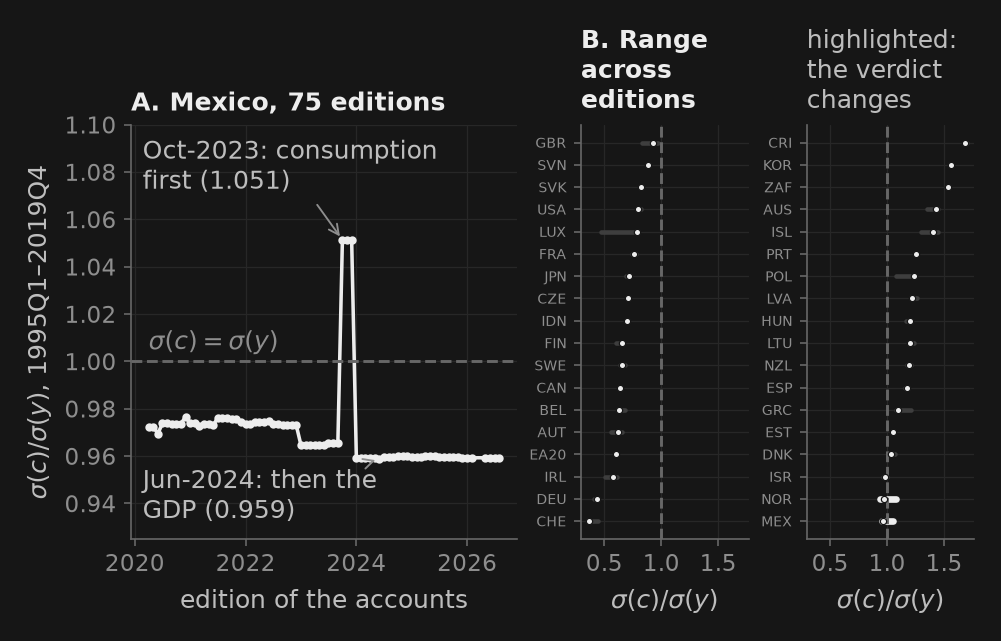

In [50]:
# Three panels: the Mexican series and, to its right, the 36 areas in two
# columns (in a single one they fit neither the notebook nor the slot).
fig, (ax1, axb1, axb2) = _nbstyle.figura(
    1, 3, figsize=plt.rcParams["figure.figsize"],
    gridspec_kw={"width_ratios": [2.3, 1, 1]})

mex = vint_ratio[vint_ratio["code"] == "MEX"].sort_values("edition")
ax1.plot(mex["edition"], mex["ratio"], color=_nbstyle.TINTA, lw=1.7, ls="-", marker="o", ms=3.0)
ax1.axhline(1.0, color=_nbstyle.SPINE, ls="--", lw=1.4)
# Air above and below: the two notes fit whole, clear of the series.
ax1.set_ylim(0.925, 1.100)
_years = list(range(2020, 2027, 2))
ax1.set_xticks(pd.to_datetime([f"{y}-01-01" for y in _years]), [str(y) for y in _years])
ax1.annotate("$\\sigma(c)=\\sigma(y)$", xy=(mex["edition"].min(), 1.0), xytext=(0, 3),
             textcoords="offset points", ha="left", va="bottom", color=_nbstyle.NOTA)
_hi = mex.loc[mex["ratio"].idxmax()]
_lo_late = mex[mex["edition"] > _hi["edition"]]
ax1.annotate(f"{_hi['edition']:%b-%Y}: consumption\nfirst (${_hi['ratio']:.3f}$)",
             xy=(_hi["edition"], _hi["ratio"]), xytext=(0.03, 0.97),
             textcoords="axes fraction", ha="left", va="top", color=_nbstyle.TEXTO,
             arrowprops=_nbstyle.FLECHA)
if len(_lo_late):
    _after = _lo_late.iloc[(_lo_late["ratio"] - _lo_late["ratio"].min()).abs()
                           .argmin()]
    ax1.annotate(f"{_after['edition']:%b-%Y}: then the\nGDP (${_after['ratio']:.3f}$)",
                 xy=(_after["edition"], _after["ratio"]), xytext=(0.03, 0.03),
                 textcoords="axes fraction", ha="left", va="bottom", color=_nbstyle.TEXTO,
                 arrowprops=_nbstyle.FLECHA)
ax1.set_ylabel("$\\sigma(c)/\\sigma(y)$, 1995Q1–2019Q4")
ax1.set_xlabel("edition of the accounts")
# The panel labels go in as axes-fraction annotations and not as titles: the
# slide export drops the titles, and with them would go the only mention of
# Mexico and the only key to the highlighted bar.
ax1.annotate(f"A. Mexico, {len(mex)} editions", xy=(0.0, 1.02),
             xycoords="axes fraction", ha="left", va="bottom",
             fontweight="bold", color=_nbstyle.TINTA)

o = by_area.sort_values("median")
ROWS = -(-len(o) // 2)
_width = float(o["hi"].max() - o["lo"].min())
for j, ax in enumerate((axb1, axb2)):
    block = o.iloc[j * ROWS:(j + 1) * ROWS]
    for i, (code, r) in enumerate(block.iterrows()):
        ax.plot([r["lo"], r["hi"]], [i, i],
                color=cols[0] if r["verdict flips"] else _nbstyle.gris("0.72"),
                lw=3.2 if r["verdict flips"] else 2.2, ls="-", solid_capstyle="round",
                zorder=2)
    ax.scatter(block["median"], np.arange(len(block)), s=9, color=_nbstyle.TINTA,
               edgecolors=_nbstyle.FONDO, linewidths=0.6, zorder=3)
    ax.axvline(1.0, color=_nbstyle.SPINE, ls="--", lw=1.4)
    ax.set_yticks(np.arange(len(block)))
    ax.set_yticklabels(block.index, fontsize=6.5)
    ax.set_ylim(-0.8, ROWS - 0.2)
    ax.set_xlim(float(o["lo"].min()) - 0.05 * _width, float(o["hi"].max()) + 0.05 * _width)
    ax.set_xlabel("$\\sigma(c)/\\sigma(y)$")
# B's label and its key go one over each column: in a single one they do not
# fit (each column is barely an inch wide and the text would overflow it).
axb1.annotate("B. Range\nacross\neditions", xy=(0.0, 1.02), xycoords="axes fraction",
              ha="left", va="bottom", fontweight="bold", color=_nbstyle.TINTA)
axb2.annotate("highlighted:\nthe verdict\nchanges", xy=(0.0, 1.02),
              xycoords="axes fraction", ha="left", va="bottom",
              color=_nbstyle.TEXTO)
plt.show()


### 4.3 Structural Determinants: Trade Openness, the Unprotected Labour Margin & Financial Depth

What structural features explain the systematic differences in $\sigma(c)/\sigma(y)$ across countries?

Open-economy macro names three empirical mechanisms:
1. **Trade openness ($(X+M)/Y$)**: open economies reach international goods and capital markets to diversify domestic shocks ($\mathrm{Corr} < 0$), though concentrated commodity exports expose them to severe terms-of-trade volatility.
2. **Work outside a protected employee relationship**: no unemployment insurance, no formal credit. Liquidity-constrained (*hand-to-mouth*), these households' consumption collapses with their income in a recession, driving up $\sigma(c)/\sigma(y)$ ($\mathrm{Corr} > 0$).
3. **Financial depth (credit/GDP)**: a developed financial system lets households borrow and refinance through a downturn, smoothing consumption intertemporally ($\mathrm{Corr} < 0$).

**The Theoretical Open-Economy Debate: Shocks to Trend vs. Financial Frictions and Sudden Stops.**  
Why is consumption volatility so high relative to output ($\sigma(c)/\sigma(y) \approx 1.0$ or higher) and why is the trade balance persistently countercyclical ($\mathrm{corr}(nx/y, y) < 0$) across emerging markets, whereas advanced small open economies display smooth consumption ($\sigma(c)/\sigma(y) < 1$) and procyclical or acyclical trade balances?

Two competing paradigms organize modern open-economy macroeconomics:
1. **The "Cycle is the Trend" Hypothesis (Aguiar & Gopinath 2007)**:  
   In emerging market economies, business cycles are driven predominantly by permanent stochastic shocks to the trend growth rate ($\Gamma_t = e^{g + z_t}$) rather than transitory, mean-reverting shocks around a stationary path. Under the Permanent Income Hypothesis (PIH), when an emerging market experiences a favorable trend shock, permanent income increases by *more* than current output. Expecting to be substantially richer in future periods, households consume aggressively today, causing consumption to surge more than one-for-one with current output ($\sigma(c)/\sigma(y) > 1$). To finance this consumption boom, the country borrows heavily from abroad, generating large trade deficits in booms. When the growth trend stalls, expected permanent income collapses, consumption plummets, and the trade balance violently swings into surplus.
2. **Financial Frictions, Sovereign Spreads & Sudden Stops (Neumeyer & Perri 2005; Garcia-Cicco, Pancrazi & Uribe 2010)**:  
   Evaluating historical century-long data (Argentina and Canada, 1900–2005), Garcia-Cicco et al. (2010) show that trend shocks alone cannot generate the observed persistence of the trade balance and real interest rates. Instead, the central transmission mechanism is **credit market frictions, working capital constraints, and countercyclical country risk premia** ($R_t = R^* + s_t$).  
   In emerging markets, the sovereign spread $s_t$ rises sharply in slumps. During a **Sudden Stop** (Calvo 1998; Mendoza 2010), international liquidity evaporates and credit constraints bind ($B_{t+1}^* \ge -\kappa Y_t$). Domestic agents cannot borrow to smooth consumption because global capital markets are closed to them. Rationed households and firms are forced into fire-sales, steep consumption drops, and emergency import compression. The resulting countercyclical trade balance is not a benign intertemporal choice, but an involuntary reflection of binding external financing constraints. In contrast, advanced commodity exporters (e.g., Canada) retain global credit access during recessions, enabling true intertemporal smoothing and procyclical trade balances.

**The second mechanism is one mechanism, and the data offer two names for it.** ILOSTAT's **informal employment rate** counts everyone in an informal job — employees with no social protection *and* own-account workers in unregistered units. The accounts' **self-employment rate** counts everyone who is not an employee, registered or not. These are two overlapping sets, not two variables: the unregistered street vendor is in both, the salaried worker paid off the books is only in the first, the incorporated consultant only in the second.

So they cannot simply be added — that double counts the intersection, by 28 points of total employment in Mexico and 13 in the United Kingdom. What the mechanism is about is the **union**: a household is exposed if it is self-employed *or* informally employed. The union needs the intersection, and the intersection is exactly what ILOSTAT publishes alongside the headline rate — the same informality rate, broken down by **status in employment**. With $s$ the self-employment share and $f_{\text{ees}}, f_{\text{slf}}$ the informality rates *within* employees and within the self-employed,

$$\underbrace{F}_{\text{informal}} \;=\; \underbrace{s\,f_{\text{slf}}}_{\text{informal self-employed}} \;+\; \underbrace{(1-s)\,f_{\text{ees}}}_{\text{informal employees}}, \qquad\qquad \underbrace{U}_{\text{exposed}} \;=\; \underbrace{s}_{\text{self-employed}} \;+\; \underbrace{(1-s)\,f_{\text{ees}}}_{\text{informal employees}} .$$

$U$ is the variable the mechanism predicts, it is a genuine share of employment, and $U \le F + s$ with the shortfall being precisely the double count. The first identity is not needed to build $U$ — it is the **check**: assembled from two databases that never spoke to each other, $s\,f_{\text{slf}} + (1-s)f_{\text{ees}}$ has to reproduce the informality rate ILOSTAT publishes, and where it does not, the two are counting different populations.

**Not one number in the charts below is typed here.** They come from four databases, and where each one comes from matters as much as the mechanism it illustrates:

| Variable | Source | What it is, exactly |
|---|---|---|
| $\sigma(c)/\sigma(y)$ | the `panel` from §1 | standard deviations of the HP cycles of $\log$ GDP and $\log$ household consumption, **in volume** |
| Openness | the `panel` from §1 | $(X+M)/Y$ **in current prices**, which §2.3 established is immune to the exchange rate |
| Informality $F$ | **ILOSTAT**, `EMP_NIFL_RT` | informal employment rate, both sexes, 15+, latest available year |
| $f_{\text{ees}}$, $f_{\text{slf}}$ | **ILOSTAT**, same rate by `STE` | the same indicator split by status in employment — employees, self-employed |
| Self-employment $s$ | the `panel` from §1 | `emp_selfemp / emp`, the labour block §5 uses in earnest |
| Private credit | **World Bank**, `FS.AST.PRVT.GD.ZS` | domestic credit to the private sector, % of GDP, 1995–2019 average |

**Why the union and not either half.** The ILO rate is the right *concept* and a badly compared *series*: each national office operationalizes "informal" its own way, which is why the United Kingdom reads 19.8% against Spain's 3.8% — the reverse of what anyone would expect. The status split shows what that disagreement is made of: Britain's statisticians classify 98% of the country's self-employed as informal, Spain's classify 14% of theirs. Self-employment, in turn, is measured the same way everywhere and comes out of the accounts we have just built, but it is silent about employees with no protection — which is most of what the margin means in Russia or South Africa. The union is the only one of the three that means the same thing in all 35 countries *and* covers both halves of the margin.

**The window is 1995Q1–2019Q4**, the same as §4.2, and for the same reason: 2020 puts into $\sigma(c)$ an administrative shutdown of contact services, which is not a business cycle, and which hit countries in proportion to their tourism rather than to their financial structure.


In [51]:
import json

WINDOW = ("1995-01-01", "2019-10-01")   # the same as §4.2, and for the same reason


def facts_from_panel(p):
    """σ(c)/σ(y), openness and self-employment — all three from the §1 panel."""
    rows = []
    for code, g in p.groupby(level="code"):
        g = g.droplevel("code").loc[WINDOW[0]:WINDOW[1]]
        vol = g[["gdp_real", "cons_hh_real"]].dropna()
        if len(vol) < 60:                      # under 15 years: not in
            continue
        cy, _ = hp_filter(100.0 * np.log(vol["gdp_real"]))
        cc, _ = hp_filter(100.0 * np.log(vol["cons_hh_real"]))
        sy, sc = float(np.std(cy, ddof=1)), float(np.std(cc, ddof=1))
        trade = g[["exports", "imports", "gdp"]].dropna()
        se = ((g["emp_selfemp"] / g["emp"]).dropna()
              if {"emp", "emp_selfemp"}.issubset(g.columns) else pd.Series(dtype=float))
        rows.append({
            "code": code, "n_q": len(vol), "sigma_y": sy, "sigma_c": sc,
            "ratio_c_y": sc / sy,
            "openness": (100.0 * float(((trade["exports"] + trade["imports"])
                                        / trade["gdp"]).mean()) if len(trade) else np.nan),
            "self_emp": 100.0 * float(se.mean()) if len(se) else np.nan})
    return pd.DataFrame(rows).set_index("code").sort_index()


def download_informality():
    """ILOSTAT over SDMX: informal employment rate, both sexes, 15+."""
    raw = sdmx_get(provider="ilostat", dataflow="ILO,DF_EMP_NIFL_SEX_AGE_RT,1.0",
                   key=".A.EMP_NIFL_RT.SEX_T.AGE_YTHADULT_YGE15")
    return (raw.rename(columns={"REF_AREA": "code", "TIME_PERIOD": "year",
                                "OBS_VALUE": "informal_rate"})
               [["code", "year", "informal_rate"]].dropna())


def download_informality_by_status():
    """ILOSTAT over SDMX: the same rate, split by status in employment.

    `STE_AGGREGATE_EES` is the informality rate *among employees* and
    `STE_AGGREGATE_SLF` the rate *among the self-employed* — the two numbers
    the union needs, and the two the headline rate averages away.
    """
    raw = sdmx_get(provider="ilostat", dataflow="ILO,DF_EMP_NIFL_SEX_STE_RT,1.0",
                   key=".A.EMP_NIFL_RT.SEX_T.")
    d = (raw.rename(columns={"REF_AREA": "code", "TIME_PERIOD": "year",
                             "STE": "status", "OBS_VALUE": "informal_rate"})
            [["code", "year", "status", "informal_rate"]].dropna())
    d = d[d["status"].isin(["STE_AGGREGATE_EES", "STE_AGGREGATE_SLF",
                            "STE_AGGREGATE_TOTAL"])].copy()
    d["status"] = d["status"].str.replace("STE_AGGREGATE_", "", regex=False)
    return d.reset_index(drop=True)


def download_credit():
    """World Bank (public API, no key): private credit, % of GDP."""
    from puremacro._http import safe_get_bytes
    url = ("https://api.worldbank.org/v2/country/all/indicator/"
           "FS.AST.PRVT.GD.ZS?format=json&per_page=20000&date=1990:2025")
    rows = json.loads(safe_get_bytes(url, timeout=120).decode("utf-8"))[1]
    return pd.DataFrame([{"code": r["countryiso3code"], "year": int(r["date"]),
                          "credit_gdp": r["value"]} for r in rows
                         if r["value"] is not None
                         and len(r["countryiso3code"] or "") == 3])


# `from_source` — live source or frozen snapshot, depending on VIVO — was
# defined in §3.2, the first section that needed it. These three sources are
# its second use, not a second copy.

est = facts_from_panel(panel)
ilo, ilo_source = from_source("ilo_informalidad.csv", download_informality,
                              "informality")
ste, ste_source = from_source("ilo_informalidad_por_situacion.csv",
                              download_informality_by_status,
                              "informality by status in employment")
wb, wb_source = from_source("wb_credito_privado.csv", download_credit,
                            "private credit")

# Informality is published with gaps: take the latest year available since 2010,
# not an average, because an average over different years per country is not
# comparable. Credit is averaged, over the same cycle window.
ilo_year = pd.to_numeric(ilo["year"], errors="coerce")
est["informality"] = (ilo[ilo_year.between(2010, 2030)].sort_values("year")
                         .groupby("code")["informal_rate"].last())
wb_year = pd.to_numeric(wb["year"], errors="coerce")
est["credit"] = (wb[wb_year.between(1995, 2019)]
                   .groupby("code")["credit_gdp"].mean())

# The union, cell by cell. The ILO gives informality *within* each status, so
# multiplying by that status's share of employment puts both halves on one
# base -- total employment -- and nothing is counted twice.
ste_year = pd.to_numeric(ste["year"], errors="coerce")
f = (ste[ste_year.between(2010, 2030)].sort_values("year")
        .groupby(["code", "status"])["informal_rate"].last().unstack())
est["informal_selfemp"] = est["self_emp"] * f["SLF"] / 100.0      # the overlap
est["informal_employees"] = (100.0 - est["self_emp"]) * f["EES"] / 100.0
est["unprotected"] = est["self_emp"] + est["informal_employees"]   # the union U
est["informal_implied"] = est["informal_selfemp"] + est["informal_employees"]

u = est.dropna(subset=["unprotected"])
check = (u["informal_implied"] - u["informality"]).abs()
print(f"Informality: {ilo_source}. By status: {ste_source}. "
      f"Private credit: {wb_source}.")
print(f"\nThe union, {len(u)} countries. Rebuilding ILOSTAT's headline rate out "
      f"of its own status split and the accounts' self-employment share misses "
      f"by a median {check.median():.2f} pp (worst {check.idxmax()} "
      f"{check.max():.1f} pp) — two databases, one population.")
print(f"Adding the two rates instead of taking their union would double count "
      f"the informal self-employed: a median {u['informal_selfemp'].median():.1f} "
      f"pp of employment, {u['informal_selfemp'].max():.1f} pp in "
      f"{u['informal_selfemp'].idxmax()}, {u.loc['GBR', 'informal_selfemp']:.1f} "
      f"pp in the United Kingdom.")
print(u[["informality", "self_emp", "informal_selfemp", "informal_employees",
         "unprotected"]].round(1).sort_values("unprotected").to_string())

REGRESSORS = {
    "openness":     ("Trade openness $(X+M)/Y$, %", "OECD QNA (§1)", "A"),
    "informality":  ("Informal employment rate, %", "ILOSTAT", "B"),
    "credit":       ("Private credit / GDP, %", "World Bank", "C"),
    "unprotected":  ("Self-employed or informal employee, % of employment",
                     "OECD QNA + ILOSTAT", "D"),
}


def corr_pack(d, x, y="ratio_c_y"):
    """Pearson, Spearman and the correlation's t. Spearman because Luxembourg
    is 288% open and should not get to set the slope on its own."""
    s = d[[y, x]].dropna()
    n = len(s)
    r = float(s[y].corr(s[x]))
    return {"variable": x, "n": n, "pearson": r,
            "spearman": float(s[y].rank().corr(s[x].rank())),
            "t": r * np.sqrt((n - 2) / max(1e-12, 1.0 - r ** 2))}


# The union goes in the chart; its two halves and the two published rates stay
# in the table, because the comparison between them is half the lesson. `same`
# scores every one of them on the 35 countries where all of them exist -- a
# variable measured on a different set of countries is not a rival hypothesis.
EXTRA = ["self_emp", "informal_selfemp", "informal_employees"]
corr = pd.DataFrame([corr_pack(est, x) for x in list(REGRESSORS) + EXTRA]
                    ).set_index("variable")
same = pd.DataFrame([corr_pack(est.loc[u.index], x)
                     for x in list(REGRESSORS) + EXTRA]).set_index("variable")

print(f"\nσ(c)/σ(y) over {WINDOW[0][:7]}–{WINDOW[1][:7]}, {len(est)} countries: "
      f"median {est['ratio_c_y'].median():.2f}, "
      f"{int((est['ratio_c_y'] > 1).sum())} above 1 "
      f"(min {est['ratio_c_y'].idxmin()} {est['ratio_c_y'].min():.2f}, "
      f"max {est['ratio_c_y'].idxmax()} {est['ratio_c_y'].max():.2f}).")
print(f"United States {est.loc['USA', 'ratio_c_y']:.2f} and Mexico "
      f"{est.loc['MEX', 'ratio_c_y']:.3f} — the same {est.loc['MEX', 'ratio_c_y']:.3f} "
      f"as §4.2's Jan-2024 vintage, now computed here.")
print("\nCorrelation with σ(c)/σ(y), one variable at a time:")
print(corr.round(3).to_string())
print(f"\nAnd on the {len(u)} countries that have all of them:")
print(same.round(3).to_string())
print(f"\nOn its own sample informality reads r={corr.loc['informality', 'pearson']:+.2f} "
      f"(t={corr.loc['informality', 't']:+.1f}); on the common sample "
      f"r={same.loc['informality', 'pearson']:+.2f} "
      f"(t={same.loc['informality', 't']:+.1f}). The six countries that drop out "
      f"— ARG, BRA, COL, IDN, IND, TUR — are the most informal in the file and "
      f"have no self-employment line in the OECD accounts, so most of the gap "
      f"between the two labour variables is a difference of sample, not of "
      f"measurement.")

# The three named mechanisms come out with the sign they predict; only the
# labour margin has a t that tells it from zero, and it does so measured as the
# union -- better than either half of it, on the same countries.
assert corr.loc["openness", "pearson"] < 0
assert corr.loc["credit", "pearson"] < 0
assert corr.loc["unprotected", "pearson"] > 0
assert same.loc["unprotected", "pearson"] > same.loc["self_emp", "pearson"]
assert same.loc["unprotected", "pearson"] > same.loc["informality", "pearson"]
# The union contains both halves and is smaller than their sum: the difference
# is the double count, and it is never negative.
assert (u["unprotected"] >= u[["self_emp", "informal_implied"]].max(axis=1) - 1e-9).all()
assert (u["unprotected"] <= u["self_emp"] + u["informal_implied"] + 1e-9).all()
# Two databases, one population: the rebuilt rate tracks the published one.
assert check.median() < 1.0
assert est["ratio_c_y"].notna().sum() >= 40

Informality: course snapshot (MAV_QNA_VIVO=1 to download). By status: course snapshot (MAV_QNA_VIVO=1 to download). Private credit: course snapshot (MAV_QNA_VIVO=1 to download).

The union, 35 countries. Rebuilding ILOSTAT's headline rate out of its own status split and the accounts' self-employment share misses by a median 0.30 pp (worst HRV 3.5 pp) — two databases, one population.
Adding the two rates instead of taking their union would double count the informal self-employed: a median 2.2 pp of employment, 28.0 pp in MEX, 13.5 pp in the United Kingdom.
      informality  self_emp  informal_selfemp  informal_employees  unprotected
code                                                                          
ISL           2.0       6.8               0.5                 0.9          7.7
DNK           2.2       7.0               0.6                 1.6          8.6
NOR           3.2       6.5               0.7                 2.3          8.8
SWE           3.2       7.1               0


Consumption-Output Ratio Regression (HC1) on Trade openness $(X+M)/Y$, % (OECD QNA (§1)):
OLS regression (HC1, z inference)
  n = 47, df_resid = 45, R^2 = 0.0433, adj R^2 = 0.0220
  llf = -19.2490, AIC = 42.4980, BIC = 46.1983
                coef     std err        z    P>|t|      [0.025      0.975]
const         1.1578      0.0774   14.950    0.000      1.0060      1.3096
openness     -0.0017      0.0007   -2.235    0.025     -0.0031     -0.0002

Consumption-Output Ratio Regression (HC1) on Informal employment rate, % (ILOSTAT):
OLS regression (HC1, z inference)
  n = 41, df_resid = 39, R^2 = 0.0011, adj R^2 = -0.0245
  llf = -18.8373, AIC = 41.6745, BIC = 45.1017
                   coef     std err        z    P>|t|      [0.025      0.975]
const            1.0211      0.0838   12.178    0.000      0.8567      1.1854
informality      0.0006      0.0022    0.272    0.786     -0.0037      0.0048

Consumption-Output Ratio Regression (HC1) on Private credit / GDP, % (World Bank):
OLS re

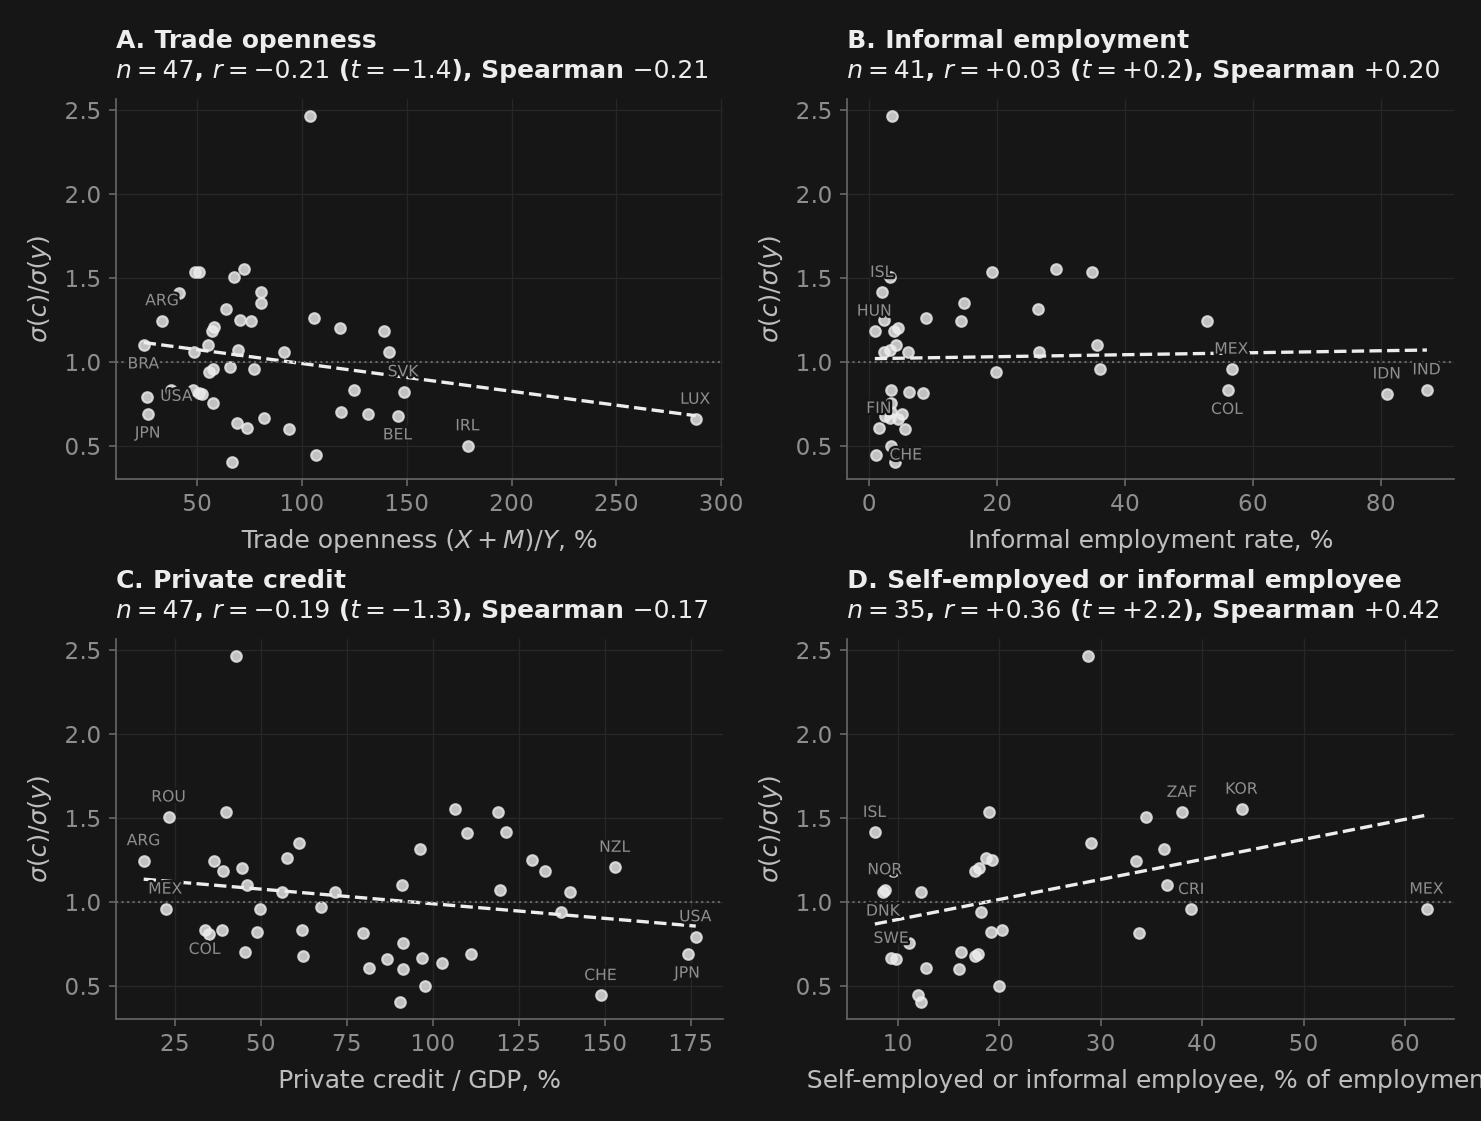

In [52]:
TITLES = {"openness": "Trade openness", "informality": "Informal employment",
          "credit": "Private credit", "unprotected": "Self-employed or informal employee"}
fig, axes = _nbstyle.figura(2, 2)
panels = []
for ax, (x, (label, source, letter)) in zip(axes.ravel(), REGRESSORS.items()):
    s = est[["ratio_c_y", x]].dropna()
    ax.scatter(s[x], s["ratio_c_y"], color=_nbstyle.TINTA, alpha=0.8, s=26)
    res_s = ols(s["ratio_c_y"], add_constant(s[x]), cov_type="HC1")
    print(f"\nConsumption-Output Ratio Regression (HC1) on {label} ({source}):")
    print(res_s.summary())
    a, b = float(res_s.params.iloc[0]), float(res_s.params.iloc[1])
    gx = np.linspace(s[x].min(), s[x].max(), 50)
    ax.plot(gx, a + b * gx, color=_nbstyle.TINTA, lw=1.6, ls="--")
    ax.axhline(1.0, color=_nbstyle.SPINE, ls=":", lw=1.0)
    c = corr.loc[x]
    ax.set_title(f"{letter}. {TITLES[x]}\n$n={int(c['n'])}$, $r={c['pearson']:+.2f}$ "
                 f"($t={c['t']:+.1f}$), Spearman ${c['spearman']:+.2f}$")
    ax.set_xlabel(label)
    ax.set_ylabel("$\\sigma(c)/\\sigma(y)$")
    order = s[x].sort_values()
    panels.append((ax, list(order.index[:4]) + list(order.index[-4:]), s, x))
# The eight extremes of each panel last, placed the way §2.2 places them: the
# four panels are already at their final size when room is looked for.
for ax, sel, s, x in panels:
    annotate_codes(ax, s.loc[sel, x], s.loc[sel, "ratio_c_y"], sel, fontsize=7.5)
plt.show()


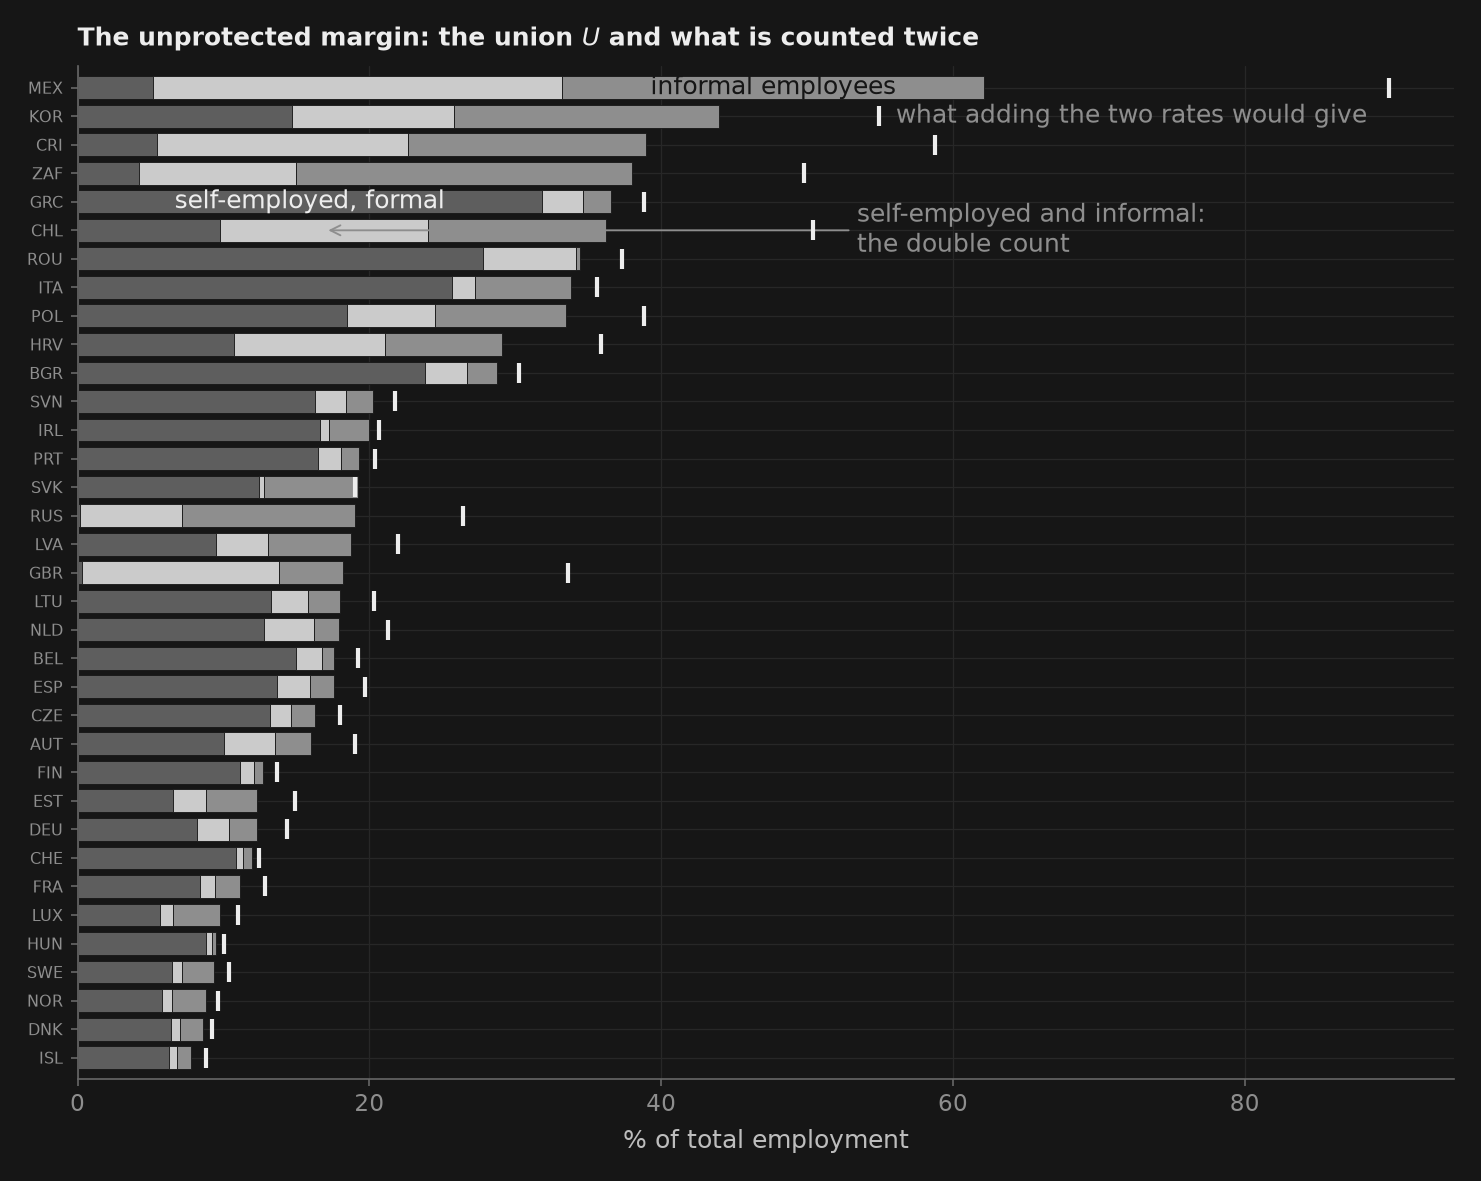

In [53]:
d = u.sort_values("unprotected")
y = np.arange(len(d))
formal_se = d["self_emp"] - d["informal_selfemp"]

# 36 stacked rows: no TAMANO size gives the height, so it is set by hand.
fig, ax = _nbstyle.figura(figsize=(9.6, 7.6))
ax.barh(y, formal_se, color=_nbstyle.BARRA_COLORES[2], edgecolor=_nbstyle.FONDO, lw=0.4)
ax.barh(y, d["informal_selfemp"], left=formal_se, color=_nbstyle.BARRA_COLORES[0],
        edgecolor=_nbstyle.FONDO, lw=0.4)
ax.barh(y, d["informal_employees"], left=d["self_emp"], color=_nbstyle.BARRA_COLORES[1],
        edgecolor=_nbstyle.FONDO, lw=0.4)
ax.scatter(d["self_emp"] + d["informality"], y, marker="|", s=90,
           color=_nbstyle.TINTA, zorder=4)
ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=7.5)
ax.set_xlabel("% of total employment")
ax.set_title("The unprotected margin: the union $U$ and what is counted twice")
ax.margins(y=0.01)
# Each name goes where its block is widest, and each on a different row:
# inside the block if it fits, and if not, with a leader into the room to the right.
i_top = len(d) - 1
r_top = d.iloc[i_top]
ax.text(float(r_top["self_emp"] + r_top["informal_employees"] / 2), i_top,
        "informal employees", ha="center", va="center", color=_nbstyle.FONDO)
i_formal = int(np.argmax(formal_se.to_numpy()))
ax.text(float(formal_se.iloc[i_formal]) / 2, i_formal, "self-employed, formal",
        ha="center", va="center", color=_nbstyle.TINTA)
# Four rows further down: the block is still one of the wide ones and the room
# to its right no longer collides with the tick's name.
i_dup = int(np.argmax(d["informal_selfemp"].to_numpy()[:len(d) - 4]))
r_dup = d.iloc[i_dup]
ax.annotate("self-employed and informal:\nthe double count",
            xy=(float(formal_se.iloc[i_dup] + r_dup["informal_selfemp"] / 2), i_dup),
            xytext=(float(r_dup["self_emp"] + r_dup["informality"]) + 3.0, i_dup),
            textcoords="data", ha="left", va="center", color=_nbstyle.NOTA,
            arrowprops=_nbstyle.FLECHA)
i_mark = i_top - 1
r_mark = d.iloc[i_mark]
ax.annotate("what adding the two rates would give",
            xy=(float(r_mark["self_emp"] + r_mark["informality"]), i_mark),
            xytext=(8, 0), textcoords="offset points", ha="left", va="center",
            color=_nbstyle.NOTA)
plt.show()


**How to read this without overclaiming.** All four clouds are simple cross-country correlations, with $n$ between 35 and 47 and no controls whatsoever: they identify nothing. What they do fix is the order of magnitude. Openness and financial depth come out with the sign the theory predicts and with $|t|$ under 1.5 — indistinguishable from zero in this sample. The labour margin is the only one that clears $|t| = 2$, and it does so **as the union**: $r = +0.36$ against $+0.34$ for self-employment alone and $+0.22$ for informality alone, on the same 35 countries. That is a small improvement, and it is the improvement one should expect from repairing a definition rather than finding a new variable — the union is not a better proxy for the mechanism, it *is* the mechanism, and its two halves are each a partial view of it.

**What the joint measure settles, and what it does not.** It settles the arithmetic: informality and self-employment overlap, the overlap is large where it matters most (28 points of Mexican employment, 13 of British), and adding them is not an option. It also disciplines an earlier temptation. Read on their own samples, informality gives $t = +0.2$ and self-employment $t = +2.0$, which invites the conclusion that the harmonized measure beats the unharmonized one. Hold the sample fixed and informality moves to $t = +1.3$: most of that contrast was the six countries with an ILO rate and no OECD self-employment line — ARG, BRA, COL, IDN, IND, TUR — which are also the six most informal economies in the file. Comparability is still a real problem, and the status split shows exactly where it bites (Britain classifies 98% of its self-employed as informal; Spain, 14%), but it was doing less of the work than the raw contrast suggested.

**Three residual caveats.** The self-employment share is a 1995–2019 average from the national accounts while the ILO rates are a single recent year, so $U$ mixes two vintages of one structure — defensible for a variable that moves slowly, wrong if the country reformed its labour market in between. The two sources also count different populations: the accounts' employment is *domestic* (§5), the ILO's is resident, which is part of why the rebuilt rate misses the published one by 3.5 pp in Croatia and 1.9 in the United Kingdom, the two places where $f_{\text{slf}}$ and $f_{\text{ees}}$ are furthest apart and the composition therefore matters most. And Romania is worth staring at: informality of 3.2% with self-employment of 34.2%, so its union is almost entirely *formal* self-employment — subsistence agriculture, registered and unprotected in every economically meaningful sense, which no informality statistic will ever pick up.

### 4.4 Macroeconomic Experiment 2: Terms-of-Trade, Sudden Stops & Trade Balance Countercyclicality Stress Test

**Macroeconomic Motivation & Policy Question.**  
A core prediction of standard open-economy Real Business Cycle (RBC) models is that small open economies use international capital markets as an intertemporal shock absorber: when adverse output or terms-of-trade shocks occur, households borrow from abroad to smooth consumption, running a trade deficit ($\mathrm{corr}(nx/y, y) > 0$), and consumption remains smoother than output ($\sigma(c)/\sigma(y) < 1$).

Yet across emerging markets (e.g., Mexico, Chile, Argentina), empirical data persistently contradict this benchmark:
1. **Excess consumption volatility**: $\sigma(c)/\sigma(y) \approx 1.0$ (or $> 1$).
2. **Violently countercyclical trade balances**: $\mathrm{corr}(nx/y, y) < 0$. During severe downturns, trade deficits turn into emergency trade surpluses.

As established by Neumeyer & Perri (2005) and Garcia-Cicco, Pancrazi & Uribe (2010), this divergence is driven by **financial frictions and sudden stops**. When an emerging market suffers an external shock, sovereign risk spreads spike, the real exchange rate depreciates, and foreign investors refuse to roll over credit. Constrained by binding borrowing limits, the country cannot borrow; it is forced to compress imports and slash consumption, generating an involuntary trade surplus. Conversely, advanced open economies with deep capital markets (e.g., Canada, Norway) maintain access to global credit during recessions, preserving consumption smoothing and procyclical trade balances.

**Guided Student Tasks:**
1. **Data Extraction**: Using `_datos.gasto()`, extract quarterly real GDP ($Y = \text{gdp}/\text{gdp\_defl}$), real household consumption ($C = \text{cons\_hh}/\text{cons\_hh\_defl}$), and the net exports share ($NX/Y = (\text{exports} - \text{imports})/\text{gdp}$) for an emerging market (**Mexico, MEX**) and an advanced peer commodity exporter (**Canada, CAN**) over the pre-COVID sample 1995Q1–2019Q4.
2. **Hodrick-Prescott Filtering**: Compute the cyclical components of $\log(Y)$, $\log(C)$, and the ratio $NX/Y$ using `hp_filter` with standard quarterly smoothing parameter $\lambda = 1600$.
3. **Second Moments**: Compute relative consumption volatility $\sigma(c)/\sigma(y) = \mathrm{std}(\tilde{c})/\mathrm{std}(\tilde{y})$ and trade balance cyclicality $\mathrm{corr}(\widetilde{nx/y}, \tilde{y})$ for both countries.
4. **Crisis Stress Test**: Contrast the trade balance swing ($\Delta (NX/Y)$) between 2008Q3 (pre-crisis) and 2009Q4 (trough of the Great Recession). Verify whether Mexico experienced sudden-stop import compression while Canada absorbed the shock through credit.
5. **Structural Verification**: Evaluate automated assertions verifying that $\sigma(c)/\sigma(y)_{\text{MEX}} > \sigma(c)/\sigma(y)_{\text{CAN}}$, $\mathrm{corr}(nx/y, y)_{\text{MEX}} < 0$, and $\mathrm{corr}(nx/y, y)_{\text{CAN}} > 0$.


In [54]:
# ==============================================================================
# Macroeconomic Experiment 2: Terms-of-Trade & Sudden Stop Stress Test
# Comparing Emerging Market (Mexico) vs. Advanced Open Economy (Canada)
# ==============================================================================
import numpy as np
import pandas as pd
from puremacro.data import hp_filter
import _datos

g = _datos.gasto()

def open_economy_cyclicality(code, start_date="1995-01-01", end_date="2019-12-31"):
    """
    Computes relative consumption volatility sigma(c)/sigma(y) and
    trade balance cyclicality corr(nx/y, y) for a small open economy.
    """
    sub = g.xs(code)
    y_real = sub["gdp"] / sub["gdp_defl"]
    c_real = sub["cons_hh"] / sub["cons_hh_defl"]
    nx_ratio = (sub["exports"] - sub["imports"]) / sub["gdp"]

    # Detrend using HP filter (lambda = 1600 for quarterly data)
    y_cyc = hp_filter(100.0 * np.log(y_real.loc[start_date:end_date]), lamb=1600)[0]
    c_cyc = hp_filter(100.0 * np.log(c_real.loc[start_date:end_date]), lamb=1600)[0]
    nx_cyc = hp_filter(nx_ratio.loc[start_date:end_date], lamb=1600)[0]

    vol_ratio = float(c_cyc.std() / y_cyc.std())
    corr_nx_y = float(np.corrcoef(nx_cyc, y_cyc)[0, 1])

    return vol_ratio, corr_nx_y

def trade_balance_swing(code, t_pre="2008-07-01", t_trough="2009-10-01"):
    """Calculates trade balance to GDP percentage point swing during crisis."""
    sub = g.xs(code)
    nx_ratio = (sub["exports"] - sub["imports"]) / sub["gdp"]
    return float(100.0 * (nx_ratio.loc[t_trough] - nx_ratio.loc[t_pre]))

# 1. Compute empirical business cycle moments
mex_vol, mex_nx = open_economy_cyclicality("MEX")
can_vol, can_nx = open_economy_cyclicality("CAN")

print("=" * 72)
print(f"{'Country':<10} | {'sigma(c)/sigma(y)':<18} | {'corr(nx/y, y)':<16} | {'Regime'}")
print("-" * 72)
print(f"{'Mexico':<10} | {mex_vol:<18.2f} | {mex_nx:<16.2f} | Emerging / Sudden Stop (Countercyclical NX)")
print(f"{'Canada':<10} | {can_vol:<18.2f} | {can_nx:<16.2f} | Advanced / Consumption Smoothing (Procyclical NX)")
print("=" * 72)

# 2. Stress Test: 2008Q3 to 2009Q4 Great Recession External Freeze
mex_swing = trade_balance_swing("MEX")
can_swing = trade_balance_swing("CAN")

print(f"\n2008-2009 Crisis Trade Balance Swing (2008Q3 -> 2009Q4):")
print(f"  Mexico (MEX) NX/Y Swing: {mex_swing:+.2f} pp of GDP (Forced surplus / import compression)")
print(f"  Canada (CAN) NX/Y Swing: {can_swing:+.2f} pp of GDP (External deficit / buffer smoothing)")

# 3. Structural verification assertions
assert mex_vol > can_vol, f"Expected MEX vol ({mex_vol:.2f}) > CAN vol ({can_vol:.2f})"
assert mex_nx < 0, f"Expected MEX trade balance to be countercyclical, got {mex_nx:.2f}"
assert can_nx > 0, f"Expected CAN trade balance to be procyclical, got {can_nx:.2f}"
print("\n✓ Macroeconomic Experiment 2 passed all structural verification checks successfully!")

Country    | sigma(c)/sigma(y)  | corr(nx/y, y)    | Regime
------------------------------------------------------------------------
Mexico     | 0.96               | -0.29            | Emerging / Sudden Stop (Countercyclical NX)
Canada     | 0.64               | 0.55             | Advanced / Consumption Smoothing (Procyclical NX)

2008-2009 Crisis Trade Balance Swing (2008Q3 -> 2009Q4):
  Mexico (MEX) NX/Y Swing: +1.43 pp of GDP (Forced surplus / import compression)
  Canada (CAN) NX/Y Swing: -3.76 pp of GDP (External deficit / buffer smoothing)

✓ Macroeconomic Experiment 2 passed all structural verification checks successfully!


## 5. The labor market inside the national accounts

The same quarterly accounts measure the **labour input**, and `qna_panel(..., labor=True)` brings it into the same panel: persons employed and hours worked, each split into employees and the self-employed, on the **domestic** concept — employment in resident production units, which is the concept GDP is measured on, so `gdp_real / hours` is productivity and not a ratio of two different populations.

Coverage is ragged again, and in the same shape as §1.8: **the United States and Japan publish nothing** in this flow, Australia publishes heads without hours and Canada hours without heads. That is 38 countries with heads and 34 with hours, out of the panel's 49.

Two subsections. **§5.1** uses the block as it comes: how many hours one employed person works, and which of the two margins — heads or hours — absorbs a recession. **§5.2** steps out of the national accounts into vacancy surveys to draw the **Beveridge curve**, the other stylized fact of the labor market and the one that connects to the Diamond–Mortensen–Pissarides matching function.

### 5.1 Heads and hours: the two margins of labour input

Labour input adjusts along two margins, and the difference between them is the difference between laying off and sending home early:

$$H_t \;=\; \underbrace{N_t}_{\text{extensive}} \times \underbrace{h_t}_{\text{intensive}}$$

**First, the level.** Hours per employed person per week run from 26 to 43 inside the OECD — Germany and Denmark at the bottom, Mexico at the top. A model calibrated to "a working day" is a model calibrated to one country.

**Mind the time base, and then repair it.** The accounts guarantee that hours are hours, not that everyone publishes them per quarter: divided by employment and by the thirteen weeks in a quarter, Chile arrives at 3.2 hours a week and Costa Rica at 166. Nothing in the metadata says so; the numbers simply arrive. Setting the two aside is the cautious answer and it is the wrong one, because the repair is **identified rather than chosen**: a wrong time base can only be one of four calendar ratios, and requiring the repaired week to land in a band wide enough to hold every other country in the panel picks exactly one of them — and the two repaired weeks then agree with each other at 41.4 hours, which nothing in the procedure could have arranged. The criterion is not invented here: it is the one `qna_panel(hours_rescale=True)` applies at download, and the cell below imports its constants rather than retyping them, so a panel read from disk and a panel fetched live cannot end up on different rules. The repaired hours are what §6 writes, and `hours_factor` travels with them so the correction is visible in the file rather than living in whoever's script applied it. T01_A §1.2 re-derives it from scratch, on a different band, as a check.

**Then, the recession.** In 2008–2010 Germany held employment flat and cut $3.7\%$ of hours (*Kurzarbeit*: the whole adjustment on the intensive margin); Spain cut $9.9\%$ of employment and $9.8\%$ of hours (all extensive). In 2020 almost all of Europe behaved like Germany in 2009 — furlough schemes are, literally, adjustment through hours — and the exception is **Mexico**, where employment fell $19\%$: with no short-time work scheme, and with §4.3's informality, the only margin left is the extensive one.

In [55]:
LABOR_COLS = [c for c in QNA_LABOR if c in panel.columns]
lab_raw = panel[LABOR_COLS].dropna(how="all").copy()

# The criterion is the library's, not ours. `qna_panel(hours_rescale=True)` has
# applied it at fetch time since 1.5.0 — but the course's frozen snapshot was
# taken with 1.4.0, so the file on disk still carries the raw units and the
# offline run has to redo it. Importing the constants rather than retyping them
# keeps one definition: a median outside _HOURS_IMPLAUSIBLE is suspicious, and
# a candidate factor is accepted only if it lands the median inside the
# narrower _HOURS_PLAUSIBLE.
from puremacro.fetch.oecd_qna_panel import (_HOURS_IMPLAUSIBLE,
                                            _HOURS_PLAUSIBLE,
                                            _HOURS_SCALES)

_hq = ((lab_raw["hours"] * 1e3) / lab_raw["emp"]).groupby(level="code").median()
base = []
for code, r in _hq.dropna().items():
    factor, why = 1.0, ""
    if not (_HOURS_IMPLAUSIBLE[0] <= r <= _HOURS_IMPLAUSIBLE[1]):
        for f, label in _HOURS_SCALES.items():
            if _HOURS_PLAUSIBLE[0] <= r * f <= _HOURS_PLAUSIBLE[1]:
                factor, why = f, label
                break
    base.append({"code": code, "hours_per_quarter": r, "factor": factor,
                 "repaired": r * factor, "reason": why,
                 "ok": factor == 1.0})
base = pd.DataFrame(base).set_index("code").sort_values("hours_per_quarter")

lab = lab_raw.copy()
# 1.0 wherever hours exist and were left as published — Canada publishes hours
# but no heads, so the ratio cannot be formed and nothing is checked, which is
# a factor of one and not a missing value. Blank only where there are no hours
# at all, because then there is no factor to record.
_f = lab.index.get_level_values("code").map(base["factor"]).astype(float)
_f = pd.Series(_f, index=lab.index).where(lab["hours"].isna(), _f.fillna(1.0))
for _col in ("hours", "hours_employees", "hours_selfemp"):
    if _col in lab.columns:
        lab[_col] = lab[_col] * _f
lab["hours_factor"] = _f

# Persons in thousands, hours in millions (QNA_LABOR_UNITS), 13 weeks a quarter.
lab["hours_week"] = (lab["hours"] * 1e6) / (lab["emp"] * 1e3) / 13.0
lab["self_emp_share"] = 100.0 * lab["emp_selfemp"] / lab["emp"]

with_emp = int(lab["emp"].notna().groupby(level="code").any().sum())
with_hours = int(lab["hours"].notna().groupby(level="code").any().sum())
print(f"Labour block: {with_emp} countries with heads, {with_hours} with hours, "
      f"out of the panel's {panel.index.get_level_values('code').nunique()}.")
print(f"No head count in this flow: "
      f"{', '.join(sorted(set(panel.index.get_level_values('code').unique()) - set(lab['emp'].dropna().index.get_level_values('code').unique())))}.")

fixed = base[~base["ok"]]
print(f"\nTime base: {int(base['ok'].sum())} of {len(base)} countries publish "
      f"hours per quarter as declared. A normal quarter is about 430 hours per "
      f"worker;\nanything outside {_HOURS_IMPLAUSIBLE[0]:.0f}-"
      f"{_HOURS_IMPLAUSIBLE[1]:.0f} is not a labour market, it is a unit.")
if len(fixed):
    print(f"  repaired, the factor accepted only because it lands the median "
          f"inside {_HOURS_PLAUSIBLE[0]:.0f}-{_HOURS_PLAUSIBLE[1]:.0f}:")
    for code, r in fixed.iterrows():
        print(f"    {code}: {r['hours_per_quarter']:8.1f} h/quarter x "
              f"{r['factor']:g} -> {r['repaired']:.0f}   "
              f"({r['reason']} filed as a quarterly total)")
    # The check nothing in the procedure could arrange: two unrelated errors,
    # two different factors, and the same working week at the end of it.
    assert float((fixed["repaired"] / 13.0).max()
                 - (fixed["repaired"] / 13.0).min()) < 1.0
assert (base.loc[base.index.isin(fixed.index), "repaired"]
        .between(*_HOURS_PLAUSIBLE)).all()

hours = (lab.loc[lab.index.get_level_values("date").year == 2019, "hours_week"]
            .groupby(level="code").mean().dropna().sort_values())
print(f"\nHours per employed person per week (2019 average), after the repair: "
      f"{len(hours)} countries between {hours.min():.1f} ({hours.idxmin()}) and "
      f"{hours.max():.1f} ({hours.idxmax()}).")


def margins(code, y0, y1):
    """Peak-to-trough fall in heads and in hours from the window's first quarter."""
    g = panel.loc[code]
    g = g[(g.index.year >= y0) & (g.index.year <= y1)]
    e, h = g["emp"].dropna(), g["hours"].dropna()
    if len(e) < 4 or len(h) < 4:
        return None
    return {"code": code,
            "employment_%": 100.0 * (e.min() / e.iloc[0] - 1.0),
            "hours_%": 100.0 * (h.min() / h.iloc[0] - 1.0)}


MARGIN_COUNTRIES = ["DEU", "AUT", "BEL", "NLD", "SWE", "FRA", "GBR", "ITA",
                    "PRT", "GRC", "ESP", "IRL", "MEX"]
gfc = pd.DataFrame([r for r in (margins(c, 2008, 2010) for c in MARGIN_COUNTRIES)
                    if r]).set_index("code")
cov = pd.DataFrame([r for r in (margins(c, 2020, 2020) for c in MARGIN_COUNTRIES)
                    if r]).set_index("code")
for t in (gfc, cov):
    # How much of the fall in hours is NOT explained by the fall in heads.
    t["intensive_pp"] = t["hours_%"] - t["employment_%"]

print("\n2008Q1–2010Q4, peak-to-trough fall (%):")
print(gfc.round(1).to_string())
print("\n2020, peak-to-trough fall (%):")
print(cov.round(1).to_string())
print(f"\nIn 2008–2010 the intensive margin contributes a median of "
      f"{gfc['intensive_pp'].median():.1f} pp; in 2020, "
      f"{cov['intensive_pp'].median():.1f} pp. Mexico in 2020: employment "
      f"{cov.loc['MEX', 'employment_%']:.1f}%, hours {cov.loc['MEX', 'hours_%']:.1f}% "
      f"— the only economy in the group where the extensive margin rules.")

assert gfc.loc["DEU", "employment_%"] > gfc.loc["ESP", "employment_%"]
assert cov["intensive_pp"].median() < gfc["intensive_pp"].median()

Labour block: 38 countries with heads, 34 with hours, out of the panel's 49.
No head count in this flow: ARG, BRA, CAN, CHN, COL, IDN, IND, JPN, SAU, TUR, USA.

Time base: 31 of 33 countries publish hours per quarter as declared. A normal quarter is about 430 hours per worker;
anything outside 150-1000 is not a labour market, it is a unit.
  repaired, the factor accepted only because it lands the median inside 250-700:
    CHL:     41.4 h/quarter x 13 -> 538   (weekly filed as a quarterly total)
    CRI:   2155.2 h/quarter x 0.25 -> 539   (annual rate filed as a quarterly total)

Hours per employed person per week (2019 average), after the repair: 33 countries between 26.4 (DNK) and 42.8 (MEX).

2008Q1–2010Q4, peak-to-trough fall (%):
      employment_%  hours_%  intensive_pp
code                                     
DEU            0.0     -3.7          -3.7
AUT           -0.6     -3.6          -3.0
BEL            0.0     -1.6          -1.6
NLD           -1.7     -3.2          -1.5
SWE

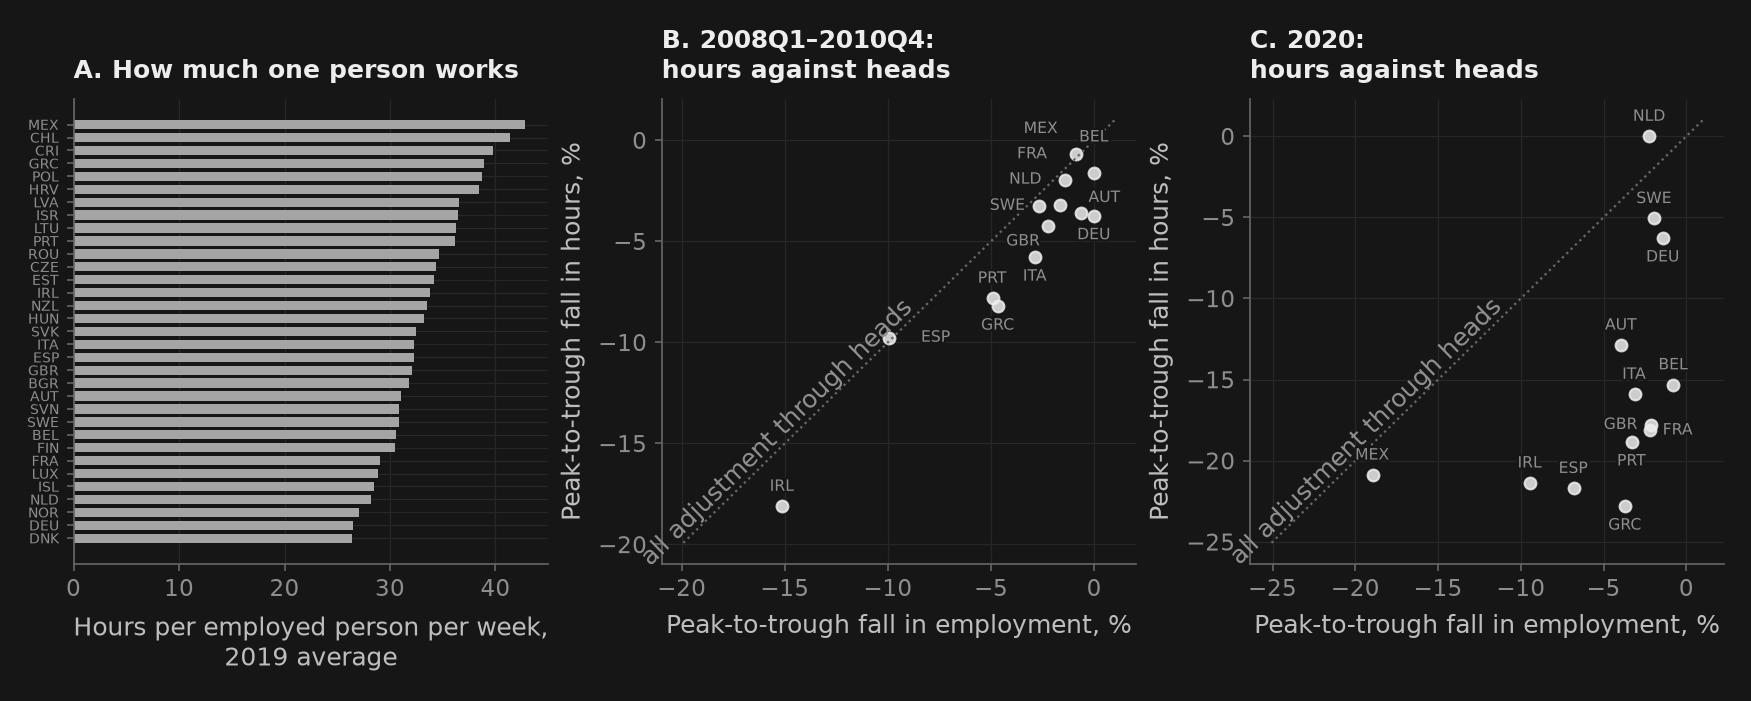

In [56]:
# 35 bar rows in A: the "3" size is too low, so it is set by hand.
fig, axes = _nbstyle.figura(1, 3, figsize=(11.4, 4.4))

ax = axes[0]
ax.barh(np.arange(len(hours)), hours.to_numpy(), color=_nbstyle.tono(0.7), height=0.72)
ax.set_yticks(np.arange(len(hours)))
ax.set_yticklabels(hours.index, fontsize=6.5)
ax.set_xlabel("Hours per employed person per week,\n2019 average")
ax.set_title("A. How much one person works")
ax.set_xlim(0, max(45.0, float(hours.max()) * 1.05))

panels = []
for ax, (t, title) in zip(axes[1:], ((gfc, "B. 2008Q1–2010Q4"), (cov, "C. 2020"))):
    ax.scatter(t["employment_%"], t["hours_%"], color=_nbstyle.TINTA, s=32, alpha=0.85)
    lo = 1.1 * min(t["employment_%"].min(), t["hours_%"].min())
    ax.plot([lo, 1], [lo, 1], color=_nbstyle.SPINE, ls=":", lw=1.1)
    ax.annotate("all adjustment through heads", xy=(lo * 0.75, lo * 0.75),
                color=_nbstyle.NOTA, rotation=45, transform_rotates_text=True,
                rotation_mode="anchor", ha="center", va="bottom")
    ax.set_xlabel("Peak-to-trough fall in employment, %")
    ax.set_ylabel("Peak-to-trough fall in hours, %")
    ax.set_title(f"{title}:\nhours against heads")
    panels.append((ax, t))
# The codes last, placed the way §2.2 places them: the three panels are already
# at their final size when room is looked for.
for ax, t in panels:
    annotate_codes(ax, t["employment_%"], t["hours_%"], t.index, fontsize=7.5)
plt.show()


### 5.2 The Beveridge curve

Unemployment and vacancies move in opposite directions: when the economy cools there are more jobless workers and fewer unfilled posts. That locus — the **Beveridge curve** — is the stylized fact that search-and-matching theory exists to explain.

With a Cobb–Douglas matching function $m = \mu\, u^{\alpha} v^{1-\alpha}$ and the steady state $s(1-u) = m$,

$$\log v \;=\; \text{const} + \tfrac{1}{1-\alpha}\big(\log s - \log \mu\big) \;-\; \tfrac{\alpha}{1-\alpha}\log u,$$

so the **slope** $b$ of a regression of $\log v$ on $\log u$ identifies $\alpha = b/(b-1)$, and an **outward shift** of the curve is — inside the model — either more separations $s$ or less matching efficiency $\mu$: more vacancies coexisting with the same unemployment because putting the two together got harder.

**Where $u$ and $v$ come from.** The national accounts do not publish vacancies, so three sources join here: the **Eurostat** vacancy rate (`jvs_q_nace2`, `JVR`, NACE sections B–S, seasonally adjusted) for 29 European countries, **JOLTS** for the United States, and unemployment rates from the **European LFS** (`une_rt_m`) and FRED (`UNRATE`).

**A units trap, and it is a real one:** Eurostat ships the unemployment rate as a *fraction* ($0.052$) and the vacancy rate in *percent* ($2.9$). Mixing them without looking gives Austrian tightness $\theta = v/u$ of 41 instead of $0.42$. Nothing warns you; the number simply comes out absurd, and you have to notice.

**And a comparability warning:** Eurostat's $v$ is vacancies over total posts in NACE B–S and JOLTS' is openings over employment plus openings in total nonfarm. **Levels are not comparable across the two sources**; the shape of each curve and its shift over time are.

In [57]:
def download_beveridge():
    """Quarterly u (LFS/FRED) and quarterly v (Eurostat JVS / JOLTS)."""
    from puremacro.fetch import (fetch_eurostat_lfs_panel,
                                 fetch_eurostat_vacancies, fetch_fred,
                                 fetch_jolts)

    jv = fetch_eurostat_vacancies(indicator="JVR", nace="B-S", s_adj="SA")
    u = fetch_eurostat_lfs_panel(sexes=("_T",))
    u = u[u["age"] == "Y_GE15"][["code", "date", "urate"]].copy()
    u["urate"] = 100.0 * u["urate"]        # Eurostat ships a fraction, not a %
    u["date"] = u["date"].dt.to_period("Q").dt.to_timestamp()
    eur = (jv.merge(u.groupby(["code", "date"], as_index=False)["urate"].mean(),
                    on=["code", "date"], how="inner")
             .rename(columns={"jvr": "vrate"}))
    eur["fuente"] = "eurostat"

    j = fetch_jolts(elements=("openings",), industries=("total",))[["date", "rate"]].copy()
    j["date"] = j["date"].dt.to_period("Q").dt.to_timestamp()
    fu = fetch_fred("UNRATE").rename("urate").to_frame().reset_index()
    fu.columns = ["date", "urate"]
    fu["date"] = pd.to_datetime(fu["date"]).dt.to_period("Q").dt.to_timestamp()
    us = (j.groupby("date", as_index=False)["rate"].mean()
           .rename(columns={"rate": "vrate"})
           .merge(fu.groupby("date", as_index=False)["urate"].mean(), on="date"))
    us["code"], us["fuente"] = "USA", "jolts+fred"
    return pd.concat([eur, us[eur.columns]], ignore_index=True)


bev, bev_source = from_source("beveridge_uv.csv", download_beveridge,
                              "vacancies and unemployment")
bev["date"] = pd.to_datetime(bev["date"])
bev = (bev.dropna(subset=["urate", "vrate"]).query("urate > 0 and vrate > 0")
          .sort_values(["code", "date"]).reset_index(drop=True))
print(f"Vacancies and unemployment: {bev_source}. {bev['code'].nunique()} "
      f"countries, {bev['date'].min().to_period('Q')}–"
      f"{bev['date'].max().to_period('Q')}, {len(bev):,} country-quarters.")


def beveridge_fit(g, cut="2020-01-01", back="2021-01-01"):
    """log v = a + b log u before 2020; average shift from 2021 on."""
    pre, post = g[g["date"] < cut], g[g["date"] >= back]
    if len(pre) < 12 or len(post) < 8:
        return None
    x, y = np.log(pre["urate"].to_numpy()), np.log(pre["vrate"].to_numpy())
    b, a = np.polyfit(x, y, 1)
    resid = np.log(post["vrate"].to_numpy()) - (a + b * np.log(post["urate"].to_numpy()))
    return {"b": float(b),
            # α only means anything where the slope is negative; where it comes
            # out positive the cloud is not a Beveridge curve, and saying so
            # with a NaN beats printing an α of 6.6.
            "alpha": float(b / (b - 1.0)) if b < 0 else np.nan,
            "R2": float(np.corrcoef(x, y)[0, 1] ** 2),
            "shift": float(np.mean(resid)),
            "theta_pre": float((pre["vrate"] / pre["urate"]).mean()),
            "theta_post": float((post["vrate"] / post["urate"]).mean()),
            "a": float(a), "n": len(g)}


fits = {code: r for code, g in bev.groupby("code")
        if (r := beveridge_fit(g)) is not None}
bevfit = pd.DataFrame(fits).T
neg = bevfit[bevfit["b"] < 0]

print(f"\nFit log v = a + b log u before 2020, {len(bevfit)} countries "
      f"(no GBR: Eurostat stops receiving its data in 2020Q3).")
print(f"  Median slope {bevfit['b'].median():+.2f}; negative in "
      f"{int((bevfit['b'] < 0).sum())} of {len(bevfit)} — the curve slopes down.")
print(f"  Implied matching-function α: median {neg['alpha'].median():.2f}, "
      f"interquartile range {neg['alpha'].quantile(.25):.2f}–"
      f"{neg['alpha'].quantile(.75):.2f}. Petrongolo & Pissarides (2001) put "
      f"the literature at 0.5–0.7.")
print(f"  Shift after 2021: median {bevfit['shift'].median():+.3f} log points, "
      f"that is {100 * (np.exp(bevfit['shift'].median()) - 1):+.0f}% more "
      f"vacancies at the same unemployment; outward in "
      f"{int((bevfit['shift'] > 0).sum())} of {len(bevfit)}.")
print(f"  Tightness θ = v/u: median {bevfit['theta_pre'].median():.2f} before, "
      f"{bevfit['theta_post'].median():.2f} after.")
print("\n" + bevfit[["b", "alpha", "R2", "shift", "theta_pre", "theta_post"]]
      .sort_values("shift", ascending=False).round(3).to_string())

assert (bevfit["b"] < 0).mean() > 0.8          # the curve slopes down nearly everywhere
assert bevfit["theta_post"].median() > bevfit["theta_pre"].median()

Vacancies and unemployment: course snapshot (MAV_QNA_VIVO=1 to download). 30 countries, 2000Q4–2026Q2, 1,928 country-quarters.

Fit log v = a + b log u before 2020, 29 countries (no GBR: Eurostat stops receiving its data in 2020Q3).
  Median slope -0.75; negative in 27 of 29 — the curve slopes down.
  Implied matching-function α: median 0.44, interquartile range 0.38–0.54. Petrongolo & Pissarides (2001) put the literature at 0.5–0.7.
  Shift after 2021: median +0.154 log points, that is +17% more vacancies at the same unemployment; outward in 21 of 29.
  Tightness θ = v/u: median 0.18 before, 0.34 after.

         b  alpha     R2  shift  theta_pre  theta_post
GRC  1.179    NaN  0.285  1.297      0.035       0.133
AUT -0.755  0.430  0.108  0.606      0.416       0.807
LUX  2.436    NaN  0.322  0.603      0.183       0.341
SWE -2.470  0.712  0.938  0.531      0.254       0.311
SVN -0.635  0.388  0.148  0.397      0.213       0.654
CHE -1.080  0.519  0.234  0.373      0.266       0.437
US

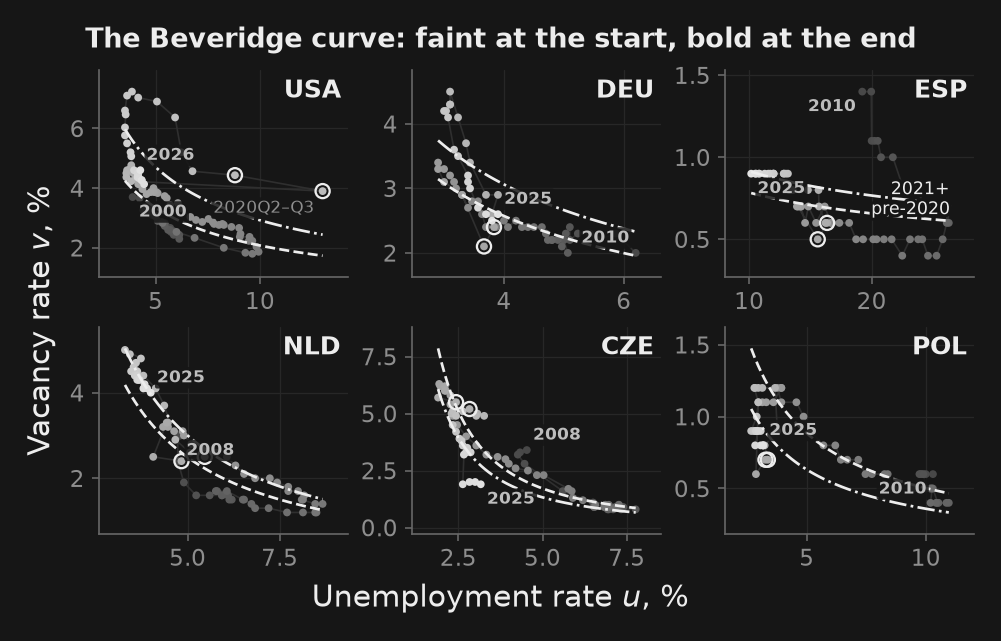

In [58]:
SAMPLE = ["USA", "DEU", "ESP", "NLD", "CZE", "POL"]
# The fit figures are already in the table above: the panel only needs the area
# code, inside it, and the two fits named once.
_PLATE = dict(boxstyle="round,pad=0.12", facecolor=_nbstyle.FONDO, edgecolor="none",
              alpha=0.85)
fig, axes = _nbstyle.figura(2, 3, figsize=plt.rcParams["figure.figsize"])
for k, (ax, code) in enumerate(zip(axes.ravel(), SAMPLE)):
    g = bev[bev["code"] == code].sort_values("date").reset_index(drop=True)
    # Faint for the first quarters, full ink for the last: the cloud reads as
    # a trajectory instead of a cloud.
    ax.plot(g["urate"], g["vrate"], color=_nbstyle.gris("0.82"), lw=0.8, ls="-", zorder=1)
    ax.scatter(g["urate"], g["vrate"], c=np.linspace(0.22, 0.95, len(g)),
               cmap="mav_seq", vmin=0, vmax=1, s=14, zorder=2,
               edgecolor="none")
    covid = g[(g["date"] >= "2020-04-01") & (g["date"] <= "2020-07-01")]
    ax.scatter(covid["urate"], covid["vrate"], facecolor="none",
               edgecolor=_nbstyle.TINTA, s=46, lw=1.1, zorder=3)
    r = fits.get(code)
    if r:
        gx = np.linspace(g["urate"].min(), g["urate"].max(), 60)
        # the two fits are named once, in the ESP panel
        ax.plot(gx, np.exp(r["a"] + r["b"] * np.log(gx)), color=_nbstyle.TINTA, lw=1.3,
                ls="--", label="pre-2020" if k == 2 else None)
        ax.plot(gx, np.exp(r["a"] + r["shift"] + r["b"] * np.log(gx)),
                color=_nbstyle.TINTA, lw=1.3, ls="-.",
                label="2021+" if k == 2 else None)
    ax.margins(0.13)
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()

    def _inwards(x, y, d=4.0, above=None):
        """Offset that pushes the label towards the middle of the panel."""
        fx, fy = (x - x0) / (x1 - x0), (y - y0) / (y1 - y0)
        dx, ha = (-d, "right") if fx > 0.5 else (d, "left")
        if above is None:
            above = fy <= 0.5
        # against the edge there is no room: the label goes to the other side
        above = True if fy < 0.12 else (False if fy > 0.88 else above)
        dy, va = (d, "bottom") if above else (-d, "top")
        return (dx, dy), ha, va

    if k == 0 and len(covid):
        xc, yc = float(covid["urate"].iloc[0]), float(covid["vrate"].iloc[0])
        # below the point: at its own height the label would cover the other
        # circled quarter
        off, ha, va = _inwards(xc, yc, above=False)
        ax.annotate("2020Q2–Q3", xy=(xc, yc), xytext=off, textcoords="offset points",
                    ha=ha, va=va, color=_nbstyle.NOTA, fontsize="x-small", bbox=_PLATE)
    # the higher point carries its year above and the lower one below: in several
    # panels the start and the end of the trajectory land at almost the same height
    _v0, _v1 = float(g["vrate"].iloc[0]), float(g["vrate"].iloc[-1])
    for pos, above in ((0, _v0 >= _v1), (-1, _v1 > _v0)):
        xp, yp = float(g["urate"].iloc[pos]), float(g["vrate"].iloc[pos])
        off, ha, va = _inwards(xp, yp, d=3.0, above=above)
        ax.annotate(str(g["date"].iloc[pos].year), xy=(xp, yp), xytext=off,
                    textcoords="offset points", ha=ha, va=va, fontsize="x-small",
                    color=_nbstyle.TEXTO, fontweight="bold", bbox=_PLATE)
    # The area code goes inside: the top-right corner is free on a downward
    # sloping curve, so the slide keeps it even when it drops the titles.
    ax.annotate(code, xy=(0.97, 0.96), xycoords="axes fraction", ha="right", va="top",
                fontweight="bold", color=_nbstyle.TINTA)
fig.supxlabel("Unemployment rate $u$, %")
fig.supylabel("Vacancy rate $v$, %")
fig.suptitle("The Beveridge curve: faint at the start, bold at the end")
_nbstyle.etiquetar(axes[0, 2], donde="fin", fuera=False, fontsize="x-small")
plt.show()


**What to look at in each panel.** *The United States* traces the textbook loop: in 2020Q2 it jumps to $u \approx 13\%$ with vacancies barely touched — an administrative shutdown, not a fall in labor demand — and comes back above the old curve, with $\theta$ going from $0.60$ to $1.34$: more open posts than jobless workers, which had never happened in the JOLTS series. *Germany* and *the Netherlands* do the same thing in miniature. *Spain* is the case where the curve barely exists: $R^2 = 0.03$, because its vacancy rate moves between $0.4$ and $1.4$ while unemployment runs from $8$ to $26\%$ — all Spanish adjustment happens in $u$, and $\theta$ goes from $0.035$ to $0.07$, two orders of magnitude below Czechia. *Czechia* and *Poland* shift the curve **inward**, and are the reminder that "the curve shifted out" is a fact about 21 countries out of 29, not a law.

### 5.3 The branch that has to go, and the country that is missing

Everything above is the labour block of the whole economy, and that is a decision rather than a datum: the `DF_QNA_BY_ACTIVITY_EMPDC` flow publishes **every ISIC section** and `qna_panel` had been pinning `ACTIVITY=_T` and throwing the other eleven away. `labor_activities=True` asks for them, and exactly two are worth having separately.

**Agriculture (A)**, because nearly all of its labour is self-employed and much of its year-to-year output is the weather. And **public administration, education and health (O–Q)**, for a reason that is accounting and not economics: the SNA *defines* general government value added as compensation plus consumption of fixed capital, so its measured productivity growth is near zero **by construction and not by finding** — and it drags the aggregate down in proportion to the size of the sector and nothing else. Subtracting the two from the whole economy is what turns a country-wide $Y/H$ into the **market sector**, which is exactly the concept the United States publishes as its nonfarm business sector. Both columns reach §6's file and T01_A §1.4 uses them for that.

**And now the missing country, which is two of them.** §5 has been saying from the start that the United States and Japan publish nothing in this flow, and it is worth being precise about what "nothing" means: with the key left open in all thirteen dimensions and starting in 1990, the OECD returns **zero rows** for both. Not an absent branch, not a short sample. There is no quarterly output-by-activity for the United States either. So no quarterly national-accounts denominator exists for either of them, and dividing their GDP by a labour input taken from somewhere else is precisely the mismatch §1 spent ten steps avoiding.

The **annual** tables do have them. `DSD_NAMAIN10@DF_TABLE3_EMPDC` publishes hours worked *by employees* on the same twelve ISIC groupings — the whole-economy total back to 1970 for the United States and 1980 for Japan, the branches from 1998 and 1994 — and `DF_TABLE6` publishes value added by ISIC section for both. `ana_by_activity` joins the two into an annual panel, and there the United States and Japan can be measured on the same concept as everyone else. It is the only frequency where they can, and saying so is more honest than a quarterly panel with two borrowed rows.

Two mechanics worth knowing before reading any number. The value-added table publishes **sections** rather than the groupings the labour table uses, so `public` is O+P+Q summed. And every aggregate comes out **by subtraction from `_T`, never by addition**, because Japan does not publish sections E, N, S, T or U: summing what is kept drops Japan and subtracting what is removed keeps it. Same arithmetic where both work, and only one of the two answers for every country. Volumes do not arrive chain-linked: they arrive at current prices and at the previous year's prices — which *are* additive within a year — and `chain_volume` links them.

In [59]:
from puremacro.fetch import ana_by_activity, ana_meta, chain_volume, qna_labor

BRANCHES = ["agri", "public"]

# Quarterly: the same six series again for A and for O-Q. Asked for with
# hours_rescale=False on purpose — the time-base factor is applied by this
# notebook a few cells up, and one single definition of the fix is what stops
# the total from being repaired while its branches are not.
_branch_cols = [f"{s}_{r}" for r in BRANCHES
                for s in ("emp", "emp_employees", "emp_selfemp",
                          "hours", "hours_employees", "hours_selfemp")]


def _download_branches():
    long = qna_labor(COUNTRIES, start="1995", sa="x13", activities=True,
                     hours_rescale=False)
    if long.empty:
        return pd.DataFrame()
    wide = long.pivot_table(index=["code", "date"], columns="variable",
                            values="value")
    return wide[[c for c in _branch_cols if c in wide.columns]].reset_index()


branches_q, branch_source = from_source("oecd_qna_labor_ramas.csv",
                                        _download_branches,
                                        "the labour block by branch")
branches_q = (branches_q.assign(date=pd.to_datetime(branches_q["date"]))
                        .set_index(["code", "date"]).sort_index())

# The same _f as §5.1, on the same hours columns. A branch arriving without its
# total repaired would make T01_A's `hours - hours_agri` a number that looks
# like a number.
_fr = pd.Series(branches_q.index.get_level_values("code").map(base["factor"]),
                index=branches_q.index).astype(float).fillna(1.0)
for _col in [c for c in branches_q.columns if c.startswith("hours")]:
    branches_q[_col] = branches_q[_col] * _fr
lab = lab.join(branches_q, how="left")

_with_branches = sorted({c for c in lab.index.get_level_values("code").unique()
                         if lab.loc[c, ["hours", "hours_agri", "hours_public"]]
                               .notna().all(axis=1).any()})
print(f"Quarterly, by branch ({branch_source}): {len(_with_branches)} countries "
      f"have hours for the total, for A and\nfor O-Q at once, which are the ones "
      f"that admit a market sector by subtraction. Neither the\nUS nor Japan, "
      f"who are not in the flow at all.")
_weight = (100.0 * (lab["hours_agri"] + lab["hours_public"]) / lab["hours"]
           ).groupby(level="code").median().dropna().sort_values()
print(f"  What gets removed is between {_weight.min():.0f}% of hours "
      f"({_weight.idxmin()}) and {_weight.max():.0f}% ({_weight.idxmax()}), "
      f"median {_weight.median():.0f}%.")

# The part can never exceed the total. Mind the NaN: a pandas comparison
# returns False — not NaN — when one side is missing, so .dropna() on the
# boolean removes nothing and the guard would fire on countries with no hours
# at all. Compare where both exist, which is where the claim exists.
_have = lab[["hours", "hours_agri", "hours_public"]].notna().all(axis=1)
assert (lab.loc[_have, "hours_agri"] <= lab.loc[_have, "hours"]).all()
assert (lab.loc[_have, "hours_public"] <= lab.loc[_have, "hours"]).all()
assert (lab.loc[_have, "hours_agri"] + lab.loc[_have, "hours_public"]
        <= lab.loc[_have, "hours"]).all()

Quarterly, by branch (course snapshot (MAV_QNA_VIVO=1 to download)): 34 countries have hours for the total, for A and
for O-Q at once, which are the ones that admit a market sector by subtraction. Neither the
US nor Japan, who are not in the flow at all.
  What gets removed is between 19% of hours (LUX) and 40% (ROU), median 29%.


In [60]:
# Annual: the same breakdown, at the only frequency that covers the US and
# Japan. About 18 SDMX requests, so only with VIVO on.
def _download_annual():
    p = ana_by_activity(COUNTRIES, start="1970")
    if p.empty:
        return pd.DataFrame()
    out = p.reset_index()
    out.attrs["meta"] = p.attrs.get("meta", ())
    return out


annual, annual_source = from_source("oecd_ana_actividad.csv", _download_annual,
                                    "the annual block by branch")
annual = annual.set_index(["code", "year"]).sort_index()

# The annual block's record is recomputed from the frame itself rather than
# riding in attrs: attrs does not survive a round trip to CSV, and a record
# that exists live and vanishes frozen is a record you cannot trust.
_NEEDED = (["va_total", "va_total_py"]
           + [f"va_{r}{t}" for r in BRANCHES for t in ("", "_py")]
           + ["hours_employees"]
           + [f"hours_employees_{r}" for r in BRANCHES])
_have = annual[_NEEDED].notna().all(axis=1)
annual_meta = pd.DataFrame([
    {"code": code,
     "n_obs": len(g),
     "first": int(g.index.get_level_values("year").min()),
     "last": int(g.index.get_level_values("year").max()),
     # hours for ALL employed persons by branch, or employees only?
     "hours_by_activity": bool(
         g[["hours"] + [f"hours_{r}" for r in BRANCHES]].notna().all(axis=1).any())
         if "hours" in g.columns else False,
     "market_n": int(_have.loc[code].sum()),
     "market_first": (int(_have.loc[code].index[_have.loc[code]].min())
                      if _have.loc[code].any() else None),
     "market_last": (int(_have.loc[code].index[_have.loc[code]].max())
                     if _have.loc[code].any() else None)}
    for code, g in annual.groupby(level="code")])

_mkt = annual_meta[annual_meta["market_n"] >= 15]
print(f"Annual, by branch ({annual_source}): {len(_mkt)} countries have value "
      f"added and employee hours\nfor the total, for A and for O-Q over at least "
      f"fifteen years, which is the raw material for\nT01_A §1.4's market "
      f"sector — it applies its own window on top and keeps fewer.")
for c in ("USA", "JPN"):
    if c in set(annual_meta["code"]):
        r = annual_meta.set_index("code").loc[c]
        print(f"  {c}: {int(r['market_n'])} years, {int(r['market_first'])}–"
              f"{int(r['market_last'])}; hours for all employed persons by branch: "
              f"{'yes' if r['hours_by_activity'] else 'no, employees only'}.")
print(f"  With hours for ALL employed persons by branch: "
      f"{int(annual_meta['hours_by_activity'].sum())} of {len(annual_meta)}. The "
      f"gap between those two counts is\n  why T01_A §1.4 measures with employee "
      f"hours and puts a number on what that costs.")

assert {"USA", "JPN"}.issubset(set(_mkt["code"])), \
    "the annual block exists to bring in the US and Japan; without them it is useless"

Annual, by branch (course snapshot (MAV_QNA_VIVO=1 to download)): 34 countries have value added and employee hours
for the total, for A and for O-Q over at least fifteen years, which is the raw material for
T01_A §1.4's market sector — it applies its own window on top and keeps fewer.
  USA: 26 years, 1998–2023; hours for all employed persons by branch: no, employees only.
  JPN: 30 years, 1995–2024; hours for all employed persons by branch: no, employees only.
  With hours for ALL employed persons by branch: 37 of 46. The gap between those two counts is
  why T01_A §1.4 measures with employee hours and puts a number on what that costs.


**Where these two blocks end up.** The quarterly branch columns are joined onto `lab` right here, so they travel inside `qna_mercado_laboral.csv` when §6 writes it — they are part of the labour block, not a new one. The annual panel is **not rewritten**: its snapshot `oecd_ana_actividad.csv` is already exactly what the next notebook needs, and `notebooks/_datos.py` reads it with `actividad_anual()` and assembles the market sector with `sector_mercado()`. Copying 1,700 rows from one file into another under a different name would be creating the second version of the same numbers that §6 exists to prevent.

## 6. Freezing the four blocks

The lesson ends where it started: with files. §1.10 checked that the three products are consistent; here they get written, and they get written **by block, not by product**, because that is how the next notebooks use them.

| File | What it carries | Coverage |
|---|---|---|
| `qna_gasto.csv` | $C$, $G$, $I$, $X$, $M$, GDP, the GFCF split by asset and the consumption split by durability — **plus one deflator for each** | 49 countries |
| `qna_renta.csv` | compensation of employees, gross operating surplus and mixed income, net taxes on production and imports | 40 |
| `qna_produccion.csv` | value added by ISIC Rev.4 activity, net taxes on products, chain-linking discrepancy, **with their deflators** | 43 |
| `qna_mercado_laboral.csv` | heads and hours, split into employees and self-employed; hours per worker per week; the self-employment share; §5.2's unemployment and vacancy rates; and §5.3's same heads and hours again for agriculture (`_agri`) and for public administration, education and health (`_public`) | 42 in the file (heads: 38, hours: 34; u and v: 30) |

Three decisions, and all three are §1's lesson applied:

1. **Levels and deflators, no volumes.** Volume is $100\times$ nominal/deflator, exact to the last bit — §1.2 checks it at $10^{-16}$ — so storing it would store the same information twice and risk the three copies drifting apart. The income block carries no deflators because none exist: there are no "wages at constant prices" in the accounts.
2. **Everything seasonally adjusted**, with the provenance written down: `sa="x13"` took the official adjustment where there is one and applied X-13/X-11 here where there is not (Brazil, China and Saudi Arabia in the aggregates; Mexico, Japan and Turkey among others in the detailed splits; eleven countries in the labour block, from Australia to South Africa). The `qna_meta.csv` that travels with them says, country by country, who adjusted what.
3. **As the source publishes them**, each country on its own price reference year. Nothing is re-referenced on the way out: `qna_rebase(gasto, 2015)` does that in one line when the next notebook needs it, and §1.5 already demonstrated that it touches no growth rate.

In [61]:
# The labour block picks up what §5.1 derived and §5.2's u and v, which is what
# makes the file usable without redoing this lesson's work.
labor_market = lab.join(
    bev.set_index(["code", "date"])[["urate", "vrate", "fuente"]]
       .rename(columns={"fuente": "uv_source"}), how="outer").sort_index()

# The five derived columns are rounded BEFORE writing, and theta is computed
# from the already-rounded ones. Not cosmetic: u and v come from averaging
# months, and the live download's average differs from the snapshot's in the
# LAST bit (4e-16). Without this the frozen file's hash depends on whether the
# run had network, and the `figuras_curso.py --verificar-datos` guard — which
# compares sha256 — fires with no number having changed. Nine decimals sit
# three orders below what the source publishes (JOLTS and Eurostat give one or
# two decimal places).
_DERIVED = ["hours_week", "self_emp_share", "urate", "vrate"]
labor_market[_DERIVED] = labor_market[_DERIVED].round(9)
labor_market["theta"] = (labor_market["vrate"]
                         / labor_market["urate"]).round(9)

BLOCKS = {
    "qna_gasto": [c for c in panel.columns
                  if c.split("_defl")[0] in
                  (list(QNA_COMPONENTS) + list(QNA_ASSETS) + list(QNA_DURABILITY))
                  and not c.endswith("_real")],
    "qna_renta": [c for c in panel.columns
                  if c.split("_defl")[0] in QNA_INCOME and not c.endswith("_real")],
    "qna_produccion": [c for c in panel.columns
                       if c.split("_defl")[0] in QNA_ACTIVITIES
                       and not c.endswith("_real")],
}
products = {n: panel[cs].dropna(how="all") for n, cs in BLOCKS.items()}
products["qna_mercado_laboral"] = labor_market.dropna(how="all")

summary = pd.DataFrame([
    {"file": f"{n}.csv", "series": f.shape[1],
     "countries": f.index.get_level_values("code").nunique(),
     "quarters": f.index.get_level_values("date").nunique(),
     "observations": int(f.select_dtypes("number").notna().to_numpy().sum())}
    for n, f in products.items()])
print("The four blocks of quarterly national accounts, seasonally adjusted:")
print(summary.to_string(index=False))

written = []
try:
    for name, frame in products.items():
        frame.to_csv(DATA / f"{name}.csv")
        written.append(f"{name}.csv")
    meta.to_csv(DATA / "qna_meta.csv", index=False)
    written.append("qna_meta.csv")
except OSError as exc:
    print(f"\nNot written ({type(exc).__name__}): {DATA} is not writable here. "
          f"The four frames are complete in memory and nothing that follows "
          f"needs the files.")
else:
    print(f"\nWritten to {DATA}/: {', '.join(written)}")

# Round trip: what the next notebook will read is what is here. And the volume
# we did not store is rebuilt from the two we did.
if written:
    reread = (pd.read_csv(DATA / "qna_gasto.csv", parse_dates=["date"])
                .set_index(["code", "date"]).sort_index())
    pd.testing.assert_frame_equal(reread, products["qna_gasto"], check_freq=False)
    rebuilt = 100.0 * reread["gdp"] / reread["gdp_defl"]
    both = pd.concat([rebuilt.rename("from_the_file"),
                      panel["gdp_real"].rename("from_the_panel")], axis=1).dropna()
    print(f"Round trip verified on {products['qna_gasto'].shape[1]} series; GDP "
          f"volume rebuilt from the file over {len(both):,} quarters, worst "
          f"relative error "
          f"{float(((both['from_the_file'] - both['from_the_panel']).abs() / both['from_the_panel']).max()):.1e}")
    assert np.allclose(both["from_the_file"], both["from_the_panel"], rtol=1e-9)

assert set(products) == {"qna_gasto", "qna_renta", "qna_produccion",
                         "qna_mercado_laboral"}

The four blocks of quarterly national accounts, seasonally adjusted:
                   file  series  countries  quarters  observations
          qna_gasto.csv      30         49       126        154160
          qna_renta.csv       6         40       126         26182
     qna_produccion.csv      32         43       126        146446
qna_mercado_laboral.csv      25         42       126         92274



Written to data_curso/bundle_2026A/: qna_gasto.csv, qna_renta.csv, qna_produccion.csv, qna_mercado_laboral.csv, qna_meta.csv
Round trip verified on 30 series; GDP volume rebuilt from the file over 5,812 quarters, worst relative error 0.0e+00


## 7. Exercises
1. **Two of three.** The course snapshot ships nominal levels and deflators but no volumes, and §1.2 rebuilds the volumes in one line. Write down the algebra that makes that lossless. Then ask whether every pair works: if a file shipped volumes and deflators, could you always recover the nominal levels? (Hint: look at which components §1 declines to build a deflator for at all, and why.)
2. **Why the identity has to be nominal.** §1.6 finds the median country's current-price gap at $0.013\%$ of GDP and its chain-linked-volume gap at $0.492\%$, with the US volume gap 502 times larger fifteen years from its base year than at it. (a) Explain, from the construction of a chain-linked index, why the volume gap must be zero at the reference year and must grow in *both* directions away from it. (b) A colleague proposes fixing it by re-referencing the panel to the middle of the sample with `qna_rebase`. Show, using the invariance test in §1.5, why this cannot work — and say precisely what re-referencing *does* change.
3. **Reading a residual.** In §1.7 Brazil has the largest mean $|$residual$|$ in the panel at $5.98$ pp, yet its current-price identity gap has a mean of $-0.001\%$ of GDP, a standard deviation of $0.74\%$, and flips sign in half of consecutive quarters. (a) What is generating it? (b) Why does a gap that averages to zero in *levels* still produce a large residual in a decomposition of *growth*? (c) Would the residual shrink if you rebuilt the panel with `sa="prefer"` instead of `sa="x13"`? Predict, then check.
4. **Double counting by construction.** §1.8 finds that summing all twelve `va_*` columns gives 1.81 times value added, while summing the ten in `QNA_VA_ADDITIVE` gives 1.0001. (a) Name the two offending columns and say exactly what each one duplicates. (b) The additive sum is 1.0001, not 1.0000 — a hundredth of a percent. Where does that come from, given that these are current-price figures and §1.6 established the current-price identity is exact? (c) Construct the plausible mistake: compute manufacturing's "share of the economy" as `va_mfg / sum(all va_*)` and as `va_mfg / va_total` for Germany. How large is the error, and in which direction?
5. **Three measurements, three residuals.** §1.8 scores the median country's identity at 0.013% of GDP on the expenditure side, 0.001% on the output side and 0.003% on the income side. (a) Why should the output side close *more* tightly than the expenditure side when all three are accounting identities? (Hint: count the independently seasonally adjusted components in each.) (b) Mexico's expenditure identity misses by 0.94% on average while its output and income identities close to zero. What does that pattern tell you about where INEGI books its statistical discrepancy, and does it make Mexico's expenditure components more or less trustworthy?
6. **The residual with a name.** The United States income identity misses by up to 2.0% of GDP — the GDP–GDI statistical discrepancy — while Spain's, Italy's and Korea's close to exactly zero. (a) Is the US measuring worse than Spain? Argue both sides, then say which you believe and why. (b) Nalewaik (2010) argues GDI is the *better* cyclical indicator despite being the noisier-looking series. Sketch the argument, and say what you would need from the panel to test it. (c) §1.8 also reports that Germany's income-flow GDP differs from its expenditure-flow GDP by 1.77% — a different phenomenon from the GDP–GDI gap. Explain the difference between the two, and why `qna_identity` reports them in separate columns.
7. **Nominal vs. real shares.** Using `panel`, compute Mexico's consumption share both ways: nominal, $\frac{P_C C}{P_Y Y}$ = `cons_hh / gdp`, and real, $\frac{C}{Y}$ = `(cons_hh / cons_hh_defl) / (gdp / gdp_defl)`. Plot them together. At which date do the two coincide, and why? What does the gap between them measure as you move away from that date?
8. **Which deflator, and which capital good?** (a) Recompute the relative price of investment for Chile and Turkey as $P_I/P_Y$ instead of $P_I/P_C$: the answers differ by ~18 and ~19 pp. What is inside $P_Y$ that is not inside $P_C$, and why does it bite hardest in a commodity exporter? (b) Across the 35 countries with both assets, $P_{eq}/P_C$ fell by a median 38% while $P_{st}/P_C$ *rose* by 24%, leaving the aggregate at −4%. If you only had total GFCF, what would you have concluded about investment-specific technical change, and how wrong would you have been? (c) Now the denominator once more: taking consumer durables out of it deepens the equipment fall in 34 of 34 countries, by a median 4.6 pp. Explain why that *direction* is arithmetic rather than a finding — and then say what in the same table is one, given that $P_{cd}/P_{C^{*}}$ fell in 37 of 37 countries and fell by more than equipment in 28 of 34. What does that second fact commit you to that §2.4's volatility evidence does not?
9. **Exchange-rate contamination.** Section 2.3 finds $\mathrm{corr}(\Delta\log(P_{eq}/P_C), \Delta\log E) = 0.80$ for Mexico against $-0.09$ for its *structures*, and $+0.31$ vs $-0.01$ at the panel median. Explain why the structures column is the right placebo — what exactly does it hold fixed that a cross-country comparison does not? Then explain why the *same* exercise on $P_X/P_M$ returns roughly zero for Korea but $-0.67$ for Mexico, and why only one of those two numbers is evidence of a measurement problem.
10. **Shrinking a first release.** §4.1 estimates $\hat{\alpha} = 0.065$, $\hat{\beta}_p = -0.097$ for the United States. (a) The BEA announces $y^p_t = -2.0\%$: what is the shrunk estimate $\tilde{y}^p_t = \hat{\alpha} + (1 + \hat{\beta}_p)y^p_t$, and in which direction did it move? (b) Mexico's deseasonalized coefficient is $\hat{\beta}_p = +0.045$ with $\hat{\alpha} = -0.105$. Apply the same formula to the same $-2.0\%$ and explain why the answer moves the *other* way — then say whether you would actually use it, given $p = 0.56$. (c) The shrinkage formula is the conditional-mean correction under the **noise** model. What does applying it to a country whose verdict is `news` amount to assuming, and what does it cost if you are wrong?
11. **An explanation waiting for a number.** Read from the unscreened archive, §4.1's table puts Mexico at $\hat{\beta}_{\text{MEX}} = -0.31$ against the United States' $-0.099$ — three times as much measurement error, and an obvious invitation to explain the gap by informal-sector imputation and survey timing. The deseasonalized figure is $+0.045$ ($p = 0.56$), because 72 OECD editions (2000-10 to 2006-09) carried INEGI's **unadjusted** series. (a) Suppose the preliminary observation is $y^p_t = \tilde{y}_t + s_{q(t)}$ with a seasonal $s$ and the final one is $y^f_t = \tilde{y}_t$. Work out $\mathrm{plim}\,\hat{\beta}_p$ and show it is driven towards $-1$ as $\mathrm{Var}(s)/\mathrm{Var}(\tilde{y})$ grows — then check it against Sweden's $-0.963$ and Turkey's $-0.955$ in the unscreened table. (b) The screen flags an edition only when the seasonal pattern is both significant ($F > 10$) **and** large (range $\ge 4.25$ pp). Which condition does the work? Say what would go wrong with each one on its own. (c) Iceland fails the screen in its early editions and comes close in its recent ones. Inspect `sig[sig.country == "ISL"]` and decide whether the threshold classifies it correctly; the notebook deseasonalizes every edition, so the question is no longer which ones to cut, but whether a fixed quarterly-dummy filter is enough for a series whose residual seasonality is the largest in the panel. (d) The notebook deseasonalizes all editions rather than dropping the flagged ones, and argues that dropping turns the "preliminary" of 110 quarters into an estimate up to six years later. Write down what happens to $\mathrm{plim}\,\hat{\beta}_p$ when a fraction $\lambda$ of observations has an already-revised estimate as its $y^p_t$ instead of the first release, and say which way it biases the verdict.
12. **Staggered Revisions**: In October 2023, why did Mexico's relative volatility ratio $\sigma(c)/\sigma(y)$ jump above $1.0$? What happened in January 2024 when the GDP revision was published?
13. **SNA 2008 Intangibles Capitalization**: Explain why capitalizing R&D and software into Investment ($I$) under SNA 2008 mechanically lowers $\sigma(c)/\sigma(y)$.
14. **Perimeter of Consumption**: Why does switching from household consumption ($S1M$) to total final consumption ($S1$) drop $\sigma(c)/\sigma(y)$ from $0.96$ to $0.85$?
15. **Consumer Durables as Investment**: Durables run 1.3 to 7.5 times as volatile as output — median 3.1 across the 32 economies with the asset split, against 5.1 for business equipment, which is the capital good they should be compared with — and moving them out of $C$ lowers $\sigma(c)/\sigma(y)$ in 31 of the 35 countries in §2.4 — Chile, Iceland, Poland and Estonia cross below the threshold, so the "excess consumption volatility" of an emerging economy can be a classification choice. Explain the mechanism. Then explain **Germany**, one of the four where the ratio does *not* fall — Croatia, Romania and Luxembourg are the others, Germany the cleanest case ($0.40 \to 0.41$): removing a component three times as volatile as the rest *raised* the ratio. Write $\sigma^2(c) = \omega^2\sigma^2(c^{*}) + (1-\omega)^2\sigma^2(c_d) + 2\omega(1-\omega)\rho\,\sigma(c^{*})\sigma(c_d)$ with $\omega = C^{*}/C$, and find the condition on $\rho$ under which durables *reduce* the volatility of total consumption. Finally, panel B of §2.4 plots $\sigma(C_d)/\sigma(Y)$ against **equipment** rather than total GFCF, and the durable sits below the diagonal in 30 of 32 countries. Does that weaken the analogy with capital? Compare the two reference lines — equipment above, $\sigma(C^{*})/\sigma(Y) \approx 0.75$ below — and argue on a log scale, not in levels; then say what it would do to the result that equipment includes transport equipment, whose purchases are as lumpy and postponable as a household car.
16. **Trade openness and the unprotected margin**: contrast the theoretical mechanisms through which higher trade openness and a larger unprotected labour margin affect $\sigma(c)/\sigma(y)$. Then look at what §4.3 finds. (a) ILOSTAT's informality rate and the accounts' self-employment rate cannot be added. Say exactly which workers would be counted twice; write the union $U$ in terms of $s$, $f_{\text{ees}}$ and $f_{\text{slf}}$; and show that $\max(s, F) \le U \le s + F$ when $F$ is the rate the identity reproduces. Which country makes the gap between those bounds widest, and why is it that one? (b) On their own samples informality gives $t = +0.2$ and self-employment $t = +2.0$; on the 35 countries that have both, $+1.3$ and $+2.0$. Which countries drop out, what did they do to the first number, and what does that cost the claim that the harmonized measure beats the unharmonized one? (c) The rebuilt informality rate matches the published one to a median 0.30 pp but misses by 3.5 pp in Croatia and 1.9 pp in the United Kingdom — the two countries where $f_{\text{slf}}$ and $f_{\text{ees}}$ are furthest apart, and the United Kingdom is also the one country whose published $F$ exceeds its $U$. Why must the discrepancy concentrate there, and which of the two inputs would you suspect first?
17. **The sample window is not a detail**: §4.3 computes $\sigma(c)/\sigma(y)$ over 1995Q1–2019Q4. Recompute it including 2020–2025. The panel median moves from $0.97$ to $1.11$, the countries above 1 from 23 to 35, and the United States from $0.79$ to $1.05$, crossing the threshold that separates "advanced" from "emerging" in the Aguiar–Gopinath taxonomy. (a) Which component of consumption generates that jump, and why is it not a business cycle? (b) Does this justify excluding 2020, or is it exactly the kind of discretionary decision §4.2 complains about? Argue it and decide.
18. **The two margins**: in 2008–2010 Germany held employment flat and cut $3.7\%$ of hours; Spain cut $9.9\%$ of employment and $9.8\%$ of hours. In 2020 the median of the European group adjusted almost $13$ pp more through hours than through heads, and Mexico adjusted through heads ($-19\%$ of employment). (a) Write labor productivity as $Y/N$ and as $Y/H$ and explain why the two series tell different stories about Germany's 2009 recession. (b) Which of the two would you use to calibrate the Frisch elasticity, and which to measure technical change? (c) Mexico had no short-time work scheme. Connect that to §4.3's informality and to the self-employment share in the same series.
19. **From the slope to the parameter**: with $m = \mu\,u^{\alpha}v^{1-\alpha}$ and $s(1-u) = m$, derive $\log v = \text{const} - \frac{\alpha}{1-\alpha}\log u$ and check that $\alpha = b/(b-1)$. (a) §5.2 gets a median $\alpha \approx 0.44$ against the $0.5$–$0.7$ of Petrongolo and Pissarides (2001). Name two reasons why a regression through the $(u,v)$ cloud does **not** estimate the matching function, even though the relation between the two is the one you just derived. (b) Greece and Luxembourg come out with a *positive* slope. What happens to identification when $s$ and $\mu$ trend inside the sample?
20. **An inward shift**: Czechia, Poland and Romania shifted their Beveridge curve inward after 2021, while 21 of 29 countries shifted it outward. Inside the model, an inward shift is $\Delta\log\mu > \Delta\log s$. (a) What economic story fits those three countries in particular? (b) Czechia's tightness $\theta = v/u$ *rose* from $0.81$ to $1.41$ at the same time as its curve moved inward. Explain how both can hold, and what distinguishes a movement **along** the curve from a movement **of** the curve.
21. **Three labor shares, one parameter.** §3.2 computes, for Mexico, $LS^{\text{raw}} = 27.8\%$, $LS^{\text{Gollin}} = 41.1\%$ and $LS^{\text{exposed}} = 74.9\%$ of value added. (a) Write all three as the same estimator $LS(\theta) = \frac{D1}{VA}\left[1 + \theta\,\frac{U}{1-U}\right]$ with $\theta$ the exposed margin's wage relative to a formal employee's, and identify which $\theta$ each corresponds to. Check that the $\theta$ implicit in Gollin's adjustment comes out at $0.28$–$0.33$ in all three panel countries and explain why it lands so close when their informality rates run from 19% to 63%. (b) The upper end assumes a street vendor earns what a contracted employee earns. Find an estimate of the formal–informal wage gap in Mexico, substitute it as $\theta$, and report the resulting share. Does it fall inside the 0.60–0.65 range the course calls typical? (c) Mexico's raw trend is $+2.8$ pp per decade and its exposed-margin trend $+1.7$. Prove that a **constant** correction cannot produce that difference, and say what would happen to the conclusion if §4.3's ANNUAL informality rate were interpolated to quarters instead. (d) South Africa goes the other way — the correction *amplifies* its trend, from $+0.6$ to $+1.8$. What must its exposed margin be doing for that to happen, and does it?

22. **The aggregate is the easy case.** §4.1's component sweep puts the median $\hat{\beta}_p$ at $-0.072$ for GDP volume against $-0.62$ for government consumption, $-0.32$ for the deflator and $-0.26$ for fixed investment; GDP's revision is smaller than fixed investment's in 40 of 40 areas and smaller than exports' in 41 of 41. (a) Write GDP growth as $y = \sum_i s_i x_i$ with each component measured with error $\eta_i$, so the aggregate's error is $\eta = \sum_i s_i \eta_i$. Show that with uncorrelated $\eta_i$ the aggregate's error variance cannot exceed the largest component's, and find the condition under which it *can* — then note that imports enter with $s_M < 0$, so $\sum_i |s_i| > 1$ for every country in the panel, and say which of the two regimes the measured median pairwise correlation of $-0.011$ puts us in. (b) $-\hat{\beta}_p$ is a variance *ratio*, so a component could score badly simply by being placid. Check that this is not what is happening: government consumption's sd$(y^p)$ is $1.46$ pp against GDP's $1.76$, but its sd$(r)$ is $1.51$ against GDP's $0.67$. Which of the two comparisons is doing the work, and why does the cell print both? (c) Government consumption comes back `neither` in 19 of 41 areas, with a revision standard deviation as large as the series' own variation. Name the collection mechanism that produces that, and say what it does to a fiscal multiplier identified from $G$ innovations measured in real time. (d) §4.2 is about to show $\sigma(c)/\sigma(y)$ moving with the edition, and the sweep says $C$'s first release is noisier than $Y$'s in 33 of 41 areas. Do the two facts point the same way? What would you have to assume for §4.2's vintage sensitivity to be *entirely* the first-release error measured here?

## 8. Explore with AI
Try this with the offline tutor (or any AI assistant):
- "Why should consumer durables be treated as investment rather than consumption in macroeconomic models?"
- "Explain how staggered revisions of national accounts can temporarily create or destroy stylized facts like excess consumption volatility."

In [62]:
print(tutor("Explain why consumer durables behave like investment in 2 sentences."))

[offline tutor] No local LLM engine is installed on this machine. Install one with `pip install "puremacro[local-llm]"` along with a small model (for example via Ollama or MLX), or use the AI-exploration questions below with your preferred assistant. The rest of the notebook works without the tutor.
(engine detail: LocalLLMUnavailable)


**Summary.** We built the accounts from scratch for all **49 countries** the OECD publishes them for — discovering the list with `qna_countries()` rather than typing it — and came out with the **three products** of a national accounts build: nominal levels, implicit deflators and volume measures, tied by $\text{nominal} = \text{real}\times\text{deflator}/100$ to a worst relative error of $10^{-16}$ across the panel. Along the way we found the fourteen different price reference years the source ships and put every country on one with `qna_rebase`; established that the identity $Y = C+I+G+NX$ is an **accounting fact in current prices** (median $|$mean gap$|$ of 0.013% of GDP) and **simply false in chain-linked volumes** (a US gap 502 times larger fifteen years from the base than at it); separated the quarter-to-quarter wobble that independent seasonal adjustment leaves behind from a genuine statistical discrepancy; and decomposed real growth with previous-period weights, which is the one calculation that needs all three products at once.

We then built the **other two approaches to the same GDP** — output for 42 countries, income for 39, all three for 35. Each closes as tightly as an accounting identity should (median $|$mean gap$|$ of 0.001% and 0.003% of GDP), but only after three traps are avoided: two of the twelve value-added columns are memo items that inflate the total to $1.81\times$ if summed; each flow publishes its **own** GDP and they disagree by up to 2.15%, so each identity is scored inside its own flow; and a country that does not publish an approach must read NaN, not a fake gap. What the residuals are worth is the payoff — the United States income identity misses by $\pm2\%$ of GDP, which is the **GDP–GDI statistical discrepancy** and a literature rather than an error. The output side then gave us industrial structure (manufacturing's share of value added fell in 31 of 36 countries, Ireland's rising nine points on intellectual property booked onshore) and the income side the **unadjusted labour share**, running 27% to 57% — a spread that ranks countries by self-employment, not by technology, which is exactly Gollin (2002).

On that panel we split GFCF into traded equipment (median $-38\%$ against consumption) and non-traded structures ($+24\%$), and used that split as a placebo to separate what the exchange rate contaminates from what it does not; took consumer durables out of the denominator to measure those relative prices against the consumption good the theory names — which deepens the equipment fall in 34 of 34 countries, to a median $-42\%$ — and put durables in the *numerator* as well, where their own price falls in 37 of 37 countries and faster than equipment's in 28 of 34; re-cut household consumption by durability to show that durables move like capital ($\sigma(C_d)/\sigma(Y)$ of 1.3-7.5; across the 32 economies with the asset split, median 3.1 against 0.75 for the consumption they are taken out of and 5.1 for **business equipment**, which is the asset they should be compared with rather than total GFCF, whose 3.2 blends equipment with dwellings and civil works) and that reclassifying them pushes Chile's excess consumption volatility below one; corrected the **labor share** for self-employment (Gollin 2002: the median of 32 countries goes from 52.8% to 61.9% of value added, and Mexico stops being last) and, where ILOSTAT publishes informality **quarterly**, for the exposed margin too — which opens a 28%-to-75% band for Mexico and eats four tenths of every point its raw share appears to gain per decade, because that part is formalization; ran both **Mankiw–Shapiro (1986)** regressions on real-time GDP vintages for all **42 reference areas** of the OECD revisions archive — seasonally adjusting all 11,503 of its editions with one filter, because in 501 of them the archive carries the raw series and that is what had been making Mexico look four times noisier than the United States, and because dropping them would have turned the "preliminary" of 110 quarters into an estimate up to six years later — and found $\hat{\beta}_p < 0$ in 33 of 41 countries, significantly so in 17 and significantly positive in 1, with first releases biased **downward** by a median $+0.30$ pp a year — and then ran the same pair over **every one of the nine measures the archive carries**, where GDP turns out to be the *quietest* of the things it is made of: its revision is smaller than fixed investment's in 40 of 40 areas and than exports' in 41 of 41, government consumption's median $\hat{\beta}_p$ is $-0.62$ against GDP's $-0.072$, and the expenditure components' revisions are close to orthogonal to one another, which is the mechanism — an average of imperfectly correlated errors is quieter than the errors; audited how **SNA vintages and methodological revisions** alter second moments ($\sigma(c)/\sigma(y)$); and tested Kaldor's stylized fact for $K/Y$.

We then asked **what explains $\sigma(c)/\sigma(y)$ running from 0.41 in Germany to 2.47 in Bulgaria**, and asked it with data from four databases — the panel itself, ILOSTAT, the World Bank — rather than with a hand-written table. Openness and financial depth come out with the sign they predict and with $|t|$ under 1.5. The only variable that clears $|t|=2$ is the **unprotected labour margin**, and getting it required not adding informality to self-employment but taking their **union**: the two overlap in the informal self-employed, by 28 points of employment in Mexico and 13 in the United Kingdom, and ILOSTAT's split of the same rate by status in employment is what makes the overlap observable. Rebuilt from two databases that never spoke to each other, the identity $F = sf_{\text{slf}} + (1-s)f_{\text{ees}}$ reproduces ILOSTAT's published rate to a median 0.30 pp. The measurement lesson arrives with the economic one, and it cuts both ways: informality is measured differently in Britain than in Spain — 98% of the British self-employed are classified informal against 14% of the Spanish — but the $t=+0.2$ that made it look worthless was mostly the six high-informality countries the OECD accounts have no labour block for; on the same 35 countries it reads $+1.3$.

The last block of the accounts is the **labour input**: heads and hours, employees and self-employed, for 38 countries. With it we separated the two margins of a recession — Germany 2009 cut $3.7\%$ of hours with employment flat, Spain $9.9\%$ of employment; in 2020 almost all of Europe behaved like Germany in 2009 and Mexico could not — and stepped out of the accounts into vacancy surveys to draw the **Beveridge curve** for 29 countries: negative slope in 27 of them, a matching $\alpha$ with median 0.44, and an outward shift after 2021 of $+17\%$ more vacancies at the same unemployment in 21 countries — with Czechia and Poland moving the other way, in case anyone wanted a law.

And we finished by writing what comes next: **four quarterly, seasonally adjusted files** — expenditure with its deflators, income, output and labor market — with their provenance sheet alongside, which are the input to the notebooks that follow.